# Higuchi Fractal Dimension

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:22px;border-radius:10px;margin:10px;line-height:1.55;">
<div style="border-bottom:1px solid #404040;margin-bottom:16px;padding-bottom:10px;">
<h2 style="color:#E8E8E8;margin:0;">Higuchi Fractal Dimension Analysis of EEG Signals</h2>
<p style="margin:8px 0 0 0;">This section explains the code used to calculate the <b>Higuchi Fractal Dimension</b>, or <b>HFD</b>, for each EEG channel. The goal is to estimate how geometrically complex each EEG signal is during the selected time segment. In simple terms, we are asking whether the EEG trace behaves like a smooth, orderly curve, or whether it bends, fluctuates, and varies in a more irregular and richly structured way.</p>
</div>
<div style="display:flex;flex-wrap:wrap;gap:18px;">
<div style="flex:1;min-width:320px;">
<h3 style="color:#E8E8E8;margin-top:0;">1. Why Fractal Dimension Is Useful</h3>
<p>EEG signals are not only important because of their amplitude or frequency content. Their <b>shape</b> also matters. Some signals look relatively smooth and regular, while others contain many small fluctuations across multiple time scales. The fractal dimension gives us a mathematical way to describe this kind of structural complexity.</p>
<p>For a one-dimensional time series plotted as a curve, the Higuchi Fractal Dimension usually lies between about <b>1</b> and <b>2</b>. A value closer to <b>1</b> means the signal behaves more like a smooth line. A value closer to <b>2</b> means the signal is more irregular, more jagged, and more space-filling.</p>
<p>This is useful in EEG analysis because two channels can have similar voltage amplitude but very different internal structure. HFD helps measure that structure directly. It can therefore be used to compare neural complexity across electrodes, brain regions, time windows, or experimental conditions.</p>
<h3 style="color:#E8E8E8;">2. What the Code Does</h3>
<p>The code loads a multichannel EEG array, extracts a selected time interval, optionally speeds up the calculation using downsampling or truncation, and then computes one Higuchi Fractal Dimension value for each channel. Each channel is normalized before analysis so that the HFD is driven more by the <b>shape</b> of the signal than by its raw voltage scale.</p>
<p>The final results are stored in a summary table, saved as CSV files, and visualized using several plots: a channel-wise HFD bar plot, log-log Higuchi fit plots, scalp-layout maps, regional summaries, left-right asymmetry plots, and rolling-window stability maps.</p>
</div>
<div style="flex:1;min-width:320px;">
<h3 style="color:#E8E8E8;margin-top:0;">3. The Main Idea of the Higuchi Method</h3>
<p>The Higuchi method measures the apparent length of the signal at different time scales. The scale is controlled by the integer <b>k</b>. When <b>k = 1</b>, the algorithm walks through the signal point by point. When <b>k = 2</b>, it skips every other point. When <b>k = 3</b>, it steps through every third point, and so on.</p>
<p>The important idea is that a smooth curve does not change its measured length very much when we measure it with different step sizes. An irregular curve behaves differently. When measured with small steps, many small fluctuations become visible. When measured with large steps, those small fluctuations are skipped. Therefore, the measured curve length depends strongly on the scale used to measure it.</p>
<p>This scale-dependence is exactly what the Higuchi Fractal Dimension captures. It tells us how much hidden detail appears as we inspect the signal more finely.</p>
<p>For each value of <b>k</b>, the algorithm does not start from only one point. It tries several starting offsets, called <b>m</b>. This prevents the result from depending too much on whether we happened to begin measuring at a peak, a trough, or a quieter part of the waveform. The different curve lengths are then averaged to obtain one length estimate, <b>L(k)</b>, for that scale.</p>
<h3 style="color:#E8E8E8;">4. Higuchi Curve-Length Formula</h3>
<p>For a time series \(x[0],x[1],...,x[N-1]\), the code constructs sub-curves using a scale \(k\) and starting offset \(m\). The number of valid steps in that sub-curve is:</p>
<p style="text-align:center;">\(n_{\max}=\left\lfloor\frac{N-m-1}{k}\right\rfloor\)</p>
<p>The normalized length of one sub-curve is:</p>
<p style="text-align:center;">\(L_m(k)=\frac{N-1}{n_{\max}k^2}\sum_{i=1}^{n_{\max}}\left|x[m+i k]-x[m+(i-1)k]\right|\)</p>
<p>The average length for scale \(k\) is then:</p>
<p style="text-align:center;">\(L(k)=\frac{1}{k}\sum_{m=0}^{k-1}L_m(k)\)</p>
<p>This normalization is important because different values of \(k\) create sub-curves with different numbers of points. Without normalization, the curve lengths would not be fairly comparable across scales.</p>
</div>
</div>
<div style="margin-top:18px;border-top:1px solid #404040;padding-top:16px;">
<h3 style="color:#E8E8E8;margin-top:0;">5. From Curve Length to Fractal Dimension</h3>
<p>The Higuchi method assumes that the curve length follows an approximate power-law relationship with scale:</p>
<p style="text-align:center;">\(L(k)\propto k^{-D}\)</p>
<p>Here, \(D\) is the fractal dimension. Taking the logarithm of both sides turns the power law into a straight-line problem:</p>
<p style="text-align:center;">\(\log(L(k))\approx -D\log(k)+C\)</p>
<p>So the code calculates \(L(k)\) for several values of \(k\), plots \(\log(L(k))\) against \(\log(k)\), and fits a straight line. The slope of this line is negative, and the Higuchi Fractal Dimension is:</p>
<p style="text-align:center;">\(\mathrm{HFD}=-\mathrm{slope}\)</p>
<p>This is the central mathematical idea. Instead of judging the EEG waveform by eye, the algorithm measures how its apparent length changes across scales. The stronger this scale-dependence is, the higher the estimated fractal dimension becomes.</p>
</div>
<div style="display:flex;flex-wrap:wrap;gap:18px;margin-top:12px;">
<div style="flex:1;min-width:320px;">
<h3 style="color:#E8E8E8;">6. Why the Code Normalizes Each Channel</h3>
<p>Before computing HFD, each channel is transformed into a z-scored signal:</p>
<p style="text-align:center;">\(x_{\mathrm{norm}}=\frac{x-\mu_x}{\sigma_x+\epsilon}\)</p>
<p>This subtracts the channel mean and divides by its standard deviation. The small \(\epsilon\) prevents division by zero. This step is important because HFD should describe the <b>geometry and roughness</b> of the waveform, not simply whether one electrode has larger voltage amplitude than another.</p>
<p>After this normalization, the algorithm compares channels more fairly. A frontal channel, central channel, and occipital channel are all placed onto a comparable scale before their complexity is estimated.</p>
<h3 style="color:#E8E8E8;">7. The Meaning of k_max</h3>
<p>The parameter <b>k_max</b> controls the largest time step used in the Higuchi calculation. A small \(k_{\max}\) focuses on short-scale structure. A larger \(k_{\max}\) includes broader temporal scales. However, increasing \(k_{\max}\) also increases computation time and may introduce instability if the signal segment is too short.</p>
<p>This is why the code includes different speed modes. In <b>normal</b> mode, the calculation uses higher fidelity. In <b>fast</b> mode, it uses moderate downsampling and a smaller \(k_{\max}\). In <b>ultrafast</b> mode, it sacrifices detail for a quick exploratory scan.</p>
</div>
<div style="flex:1;min-width:320px;">
<h3 style="color:#E8E8E8;">8. Fit Diagnostics: Trust the Number Only After Checking the Fit</h3>
<p>A Higuchi value is only meaningful if the log-log relationship is reasonably linear. Therefore, the code also calculates diagnostic values for each channel: the fitted slope, intercept, HFD, \(R^2\), and RMSE.</p>
<p>The \(R^2\) value tells us how well the straight line explains the log-log data. A high \(R^2\) means the Higuchi scaling relationship is clean and consistent. A low \(R^2\) means the estimated HFD should be interpreted with caution, because the signal may not follow a simple scaling law across the selected \(k\) values.</p>
<p>The RMSE tells us how far the log-log points are, on average, from the fitted line. Smaller RMSE means a cleaner fit. The HFD value is the main result, but the fit diagnostics tell us how much confidence we should have in that result.</p>
<h3 style="color:#E8E8E8;">9. Interpreting the Output</h3>
<p>A channel with a higher HFD has a more irregular and complex waveform during the analyzed segment. A channel with a lower HFD has a smoother or less geometrically complex waveform. However, HFD should not be interpreted as “better” or “worse” by itself. It is a mathematical descriptor of signal structure.</p>
<p>For example, if occipital channels show higher HFD than frontal channels, this suggests that the occipital EEG traces have richer scale-dependent structure in this segment. If left-right asymmetry is present, it suggests that homologous electrode pairs differ in complexity. If rolling HFD varies strongly over time, then the channel’s complexity is not stable across the segment.</p>
</div>
</div>
<div style="margin-top:18px;border-top:1px solid #404040;padding-top:16px;">
<h3 style="color:#E8E8E8;margin-top:0;">10. Summary of the Full Pipeline</h3>
<ol style="margin-top:6px;">
<li><b>Load EEG data:</b> The code loads the multichannel EEG array from disk.</li>
<li><b>Select a time segment:</b> It extracts the interval from the specified start and end times.</li>
<li><b>Handle channel orientation:</b> It checks whether the array is stored as time-by-channel or channel-by-time.</li>
<li><b>Apply speed mode:</b> It optionally downsamples or truncates the signal for faster computation.</li>
<li><b>Normalize each channel:</b> Each channel is z-scored before HFD calculation.</li>
<li><b>Compute Higuchi FD:</b> The code calculates \(L(k)\), fits \(\log(L(k))\) versus \(\log(k)\), and takes \(-\mathrm{slope}\) as HFD.</li>
<li><b>Save numeric results:</b> It writes the HFD summary, fit diagnostics, regional summaries, asymmetry values, and rolling-window HFD values to CSV files.</li>
<li><b>Create visual diagnostics:</b> It generates bar plots, per-channel log-log fits, scalp maps, regional plots, asymmetry plots, ranking plots, and temporal stability heatmaps.</li>
</ol>
</div>
<div style="margin-top:18px;background-color:#222222;border-left:4px solid #D0D0D0;padding:12px 14px;border-radius:6px;">
<h3 style="color:#E8E8E8;margin-top:0;">Core Intuition</h3>
<p style="margin-bottom:0;">HFD can be understood as measuring an EEG curve with rulers of different sizes. A smooth curve gives nearly the same story no matter which ruler we use. A jagged, complex curve reveals more hidden detail when the ruler becomes smaller. Higuchi Fractal Dimension summarizes this behavior. It tells us how strongly the signal’s apparent length depends on the scale at which we inspect it.</p>
</div>
</div>



Running Higuchi FD in ULTRAFAST mode
k_max=6, decimate=5, max_samples=20000
Loaded EEG segment: 106944 samples x 32 channels
Segment: [814.571, 921.515] sec
After ULTRAFAST mode preprocessing:
  Segment shape: 20000 samples x 32 channels
  Effective sampling rate: 200.00 Hz
  Effective duration: 100.00 sec

Higuchi Fractal Dimensions:
   channel  higuchi_fd
0      CP1    1.983047
1      CP2    1.982897
2       Cz    1.975438
3       Pz    1.974625
4       C3    1.973510
5       P4    1.970642
6       P3    1.970531
7       C4    1.969251
8      FC5    1.965699
9       O2    1.965386
10     FC1    1.961269
11     CP5    1.959291
12      O1    1.959224
13     FC2    1.959112
14      F7    1.958739
15     CP6    1.958385
16     FC6    1.957220
17      M2    1.956001
18      Oz    1.955315
19      F3    1.954214
20      F8    1.949826
21      T8    1.949810
22      F4    1.947634
23      M1    1.941122
24     POz    1.939636
25      P8    1.931873
26      Fz    1.930274
27      T7    1.92

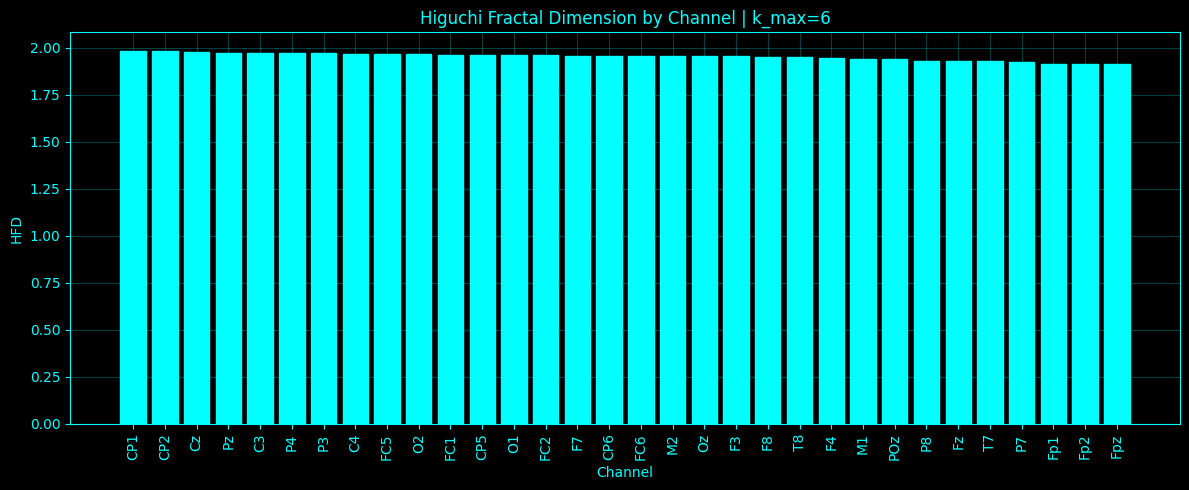


PLOT 2 — Log-Log Higuchi Fit for All Channels

What you are seeing:
  - Each small panel shows one EEG channel.
  - The dots are the measured log(L(k)) values for different k values.
  - The dashed line is the linear fit through those log-log points.
  - The HFD is calculated as the negative slope of this fitted line.
  - A clean straight-line pattern means the Higuchi scaling assumption is working well for that channel.

Patterns to look for:
  - Look for panels where the dots fall close to the dashed line; these channels have more trustworthy HFD estimates.
  - Look for panels where the dots curve strongly instead of forming a line; these channels may not follow one clean scaling law.
  - Look for panels where one dot is far away from the line; this can indicate instability at a particular k value.
  - Look for channels with steep downward slopes; these produce higher HFD values.
  - Look for channels with flatter slopes; these produce lower HFD values.
  - Look for systematic diffe

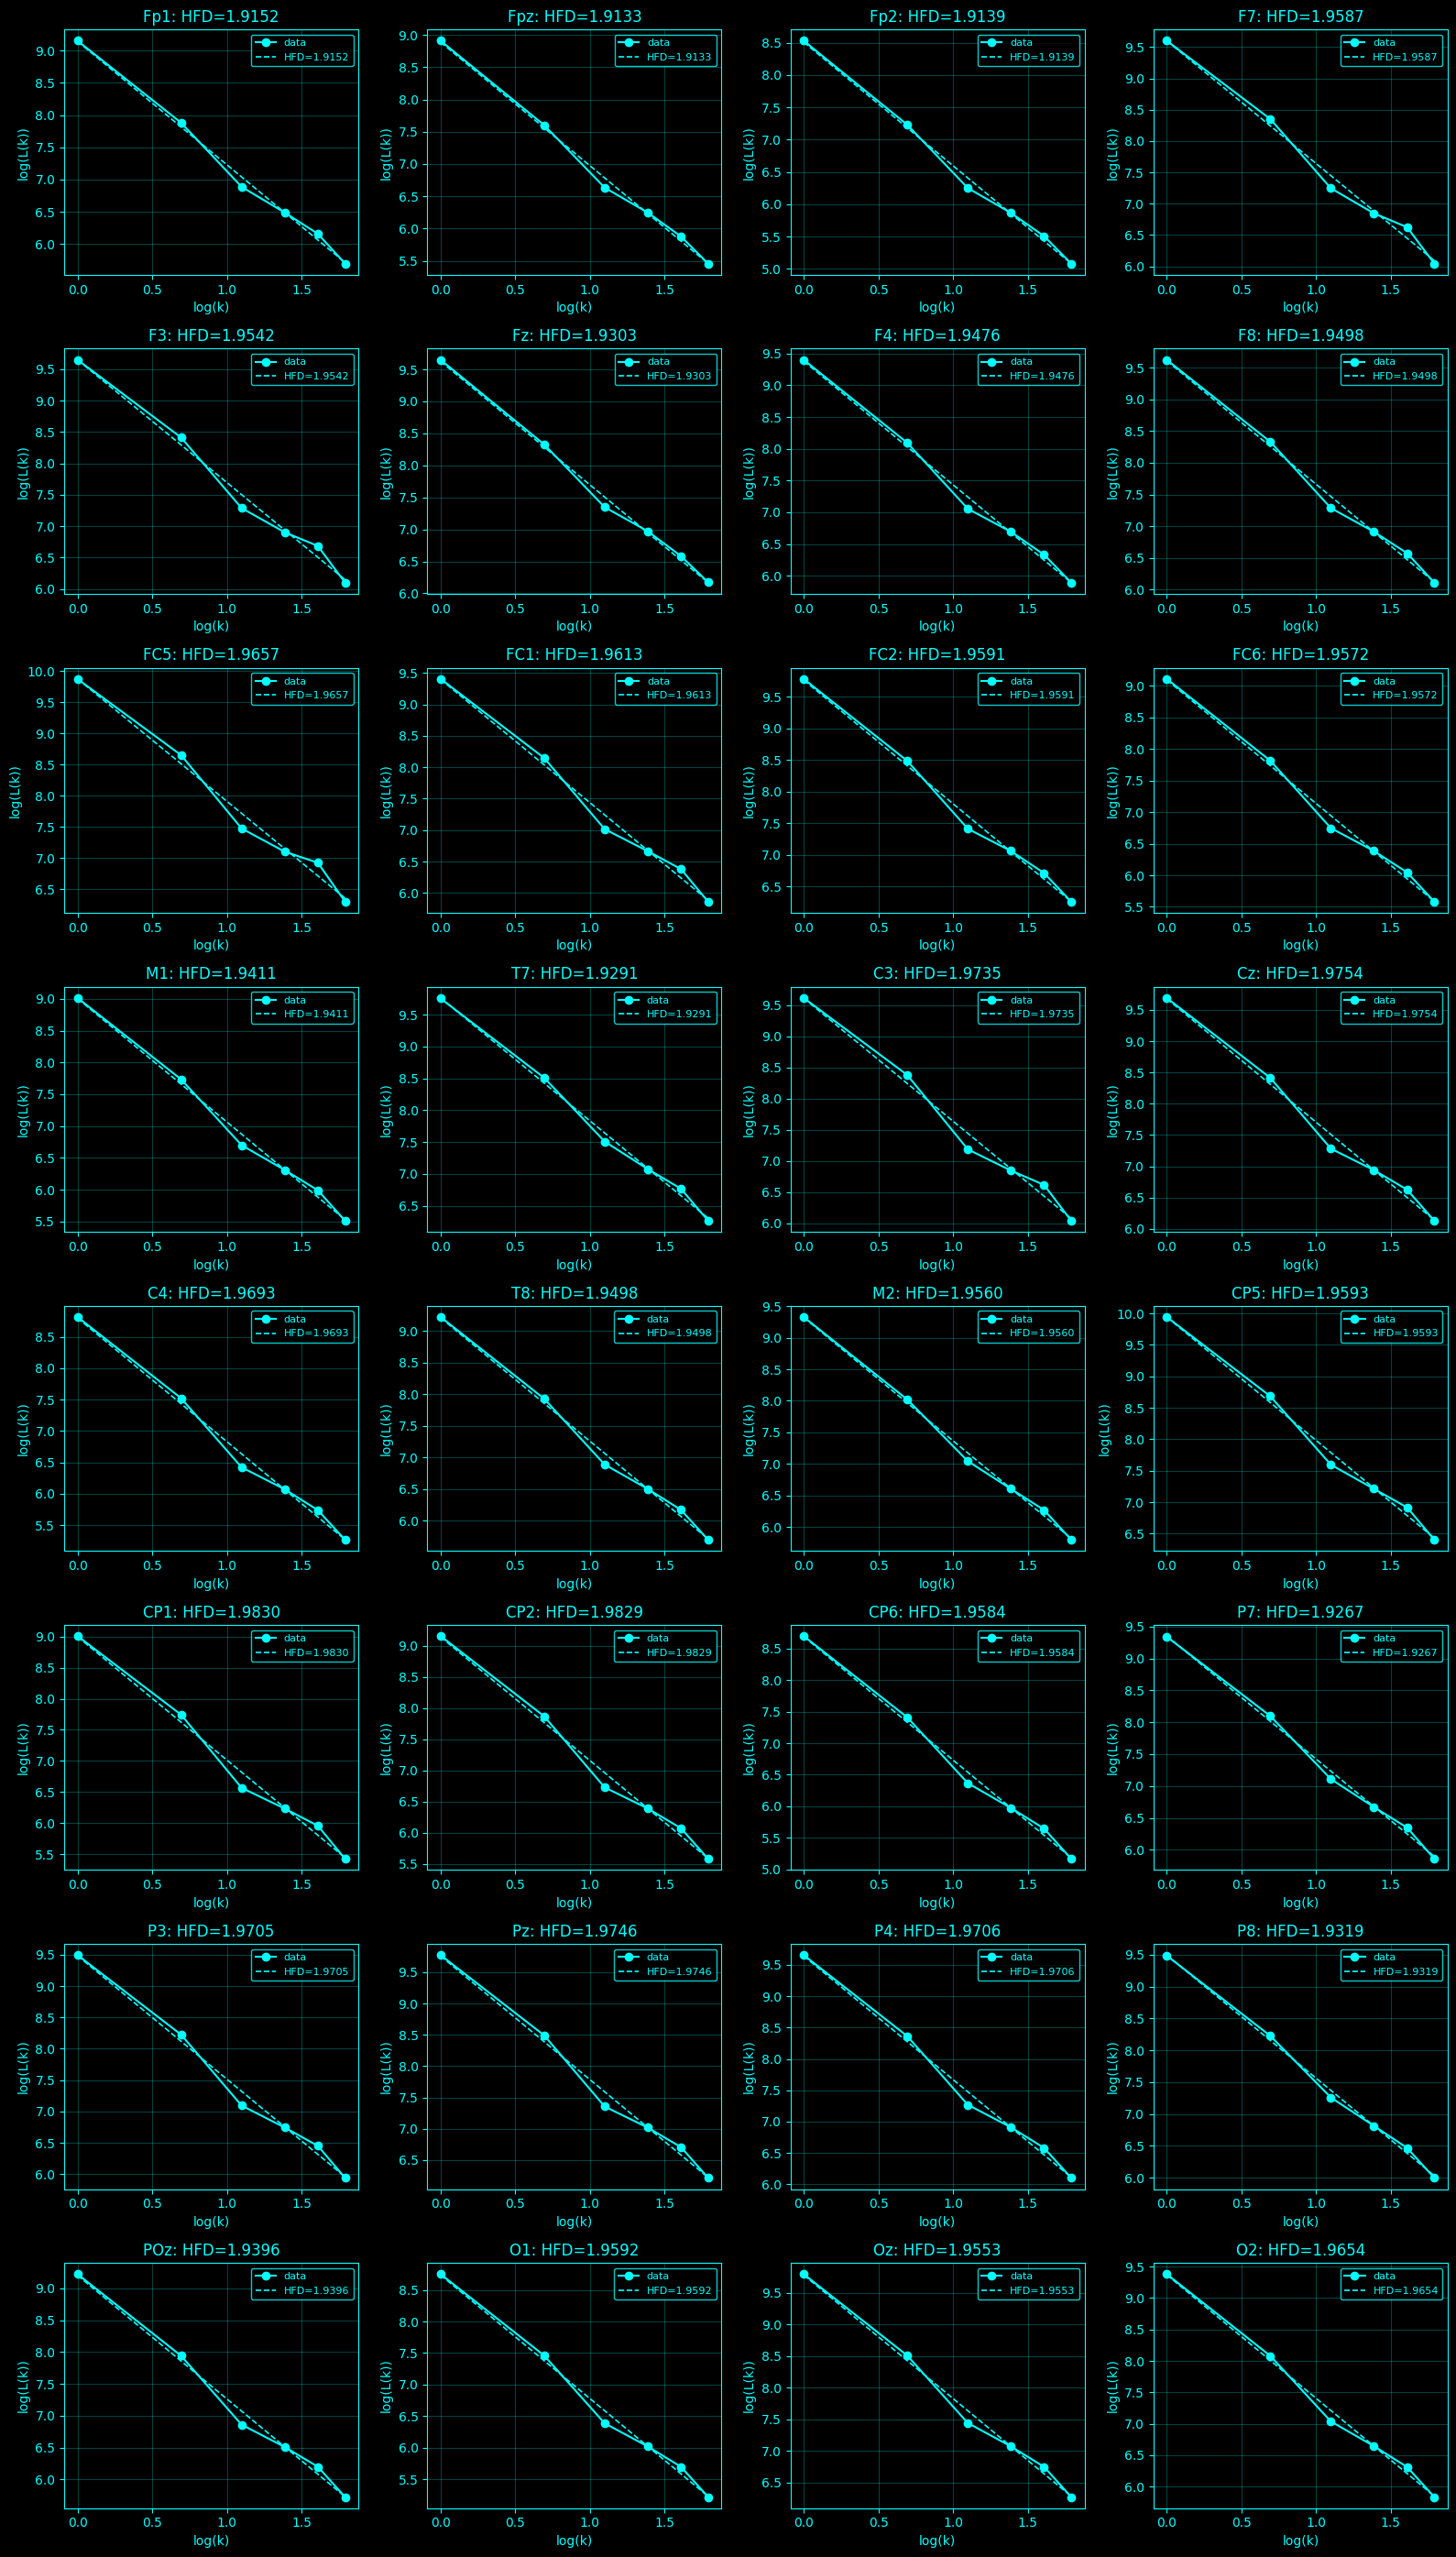

All-channel Higuchi fit plot saved to: /home/a/projects/Complete-Neural-Signal-Analysis/fractal_dimension_higuchi/all_channels_higuchi_fits.png

OPTIONAL PER-CHANNEL FIT PLOTS

What you are seeing:
  - Each saved plot shows one channel's log(L(k)) versus log(k) relationship.
  - The dots show the measured Higuchi curve lengths at different scales.
  - The dashed line shows the fitted slope used to calculate HFD.

Patterns to look for:
  - Use these plots when one channel looks suspicious in the summary figures.
  - Check whether an unusually high or low HFD channel has a clean fit.
  - Look for channels where the fit is poor despite a strong HFD value.
  - Look for channels where only one k value causes the fit to bend or fail.

Cautions:
  - These plots are diagnostic; they help decide whether a channel's HFD value should be trusted.



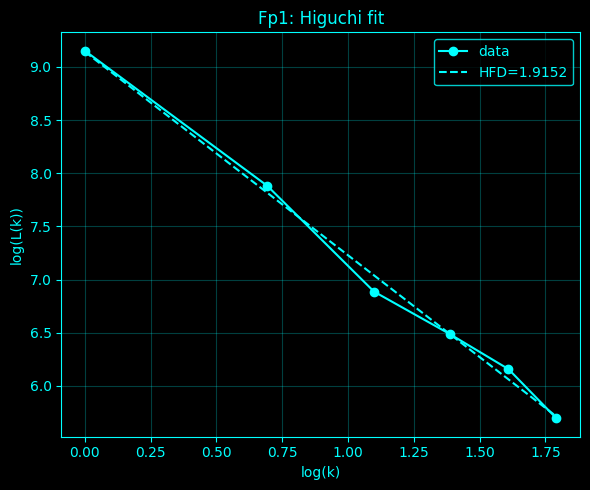

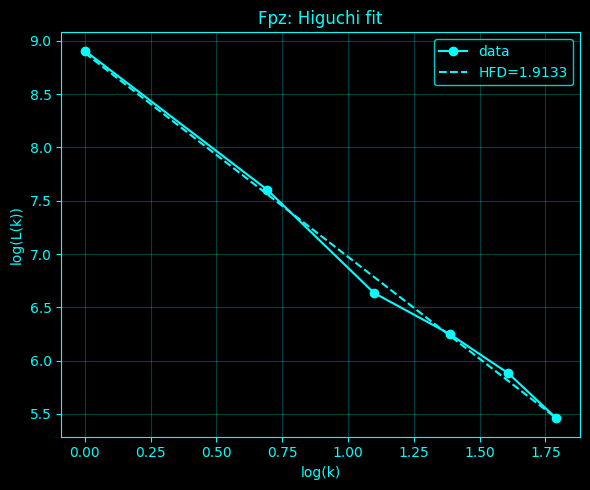

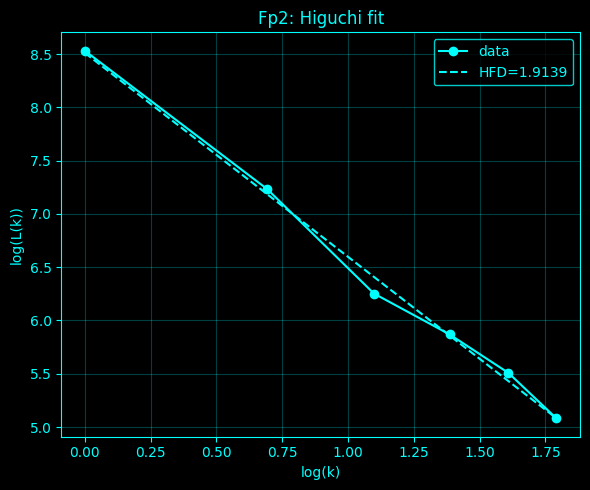

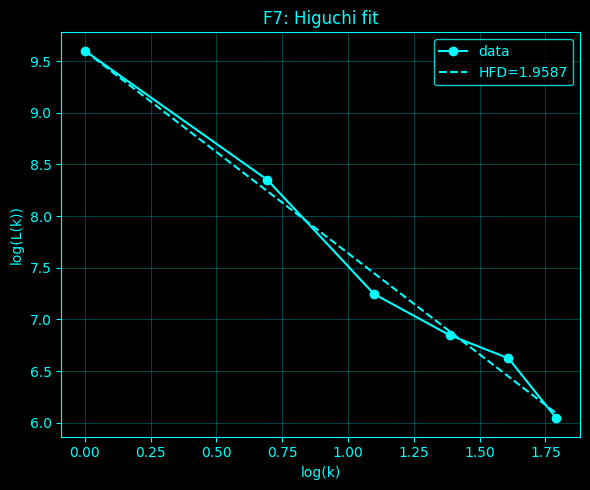

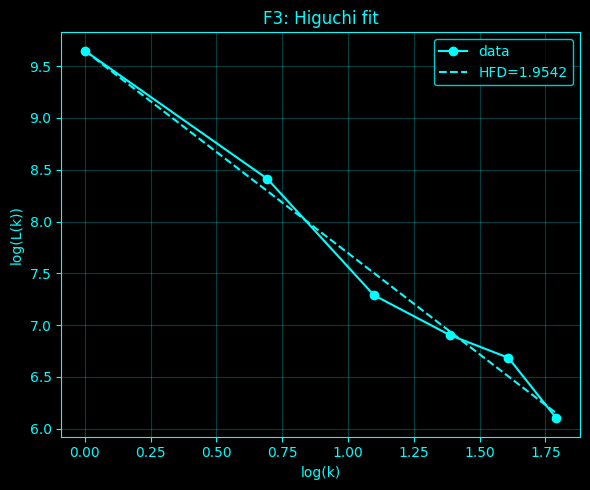

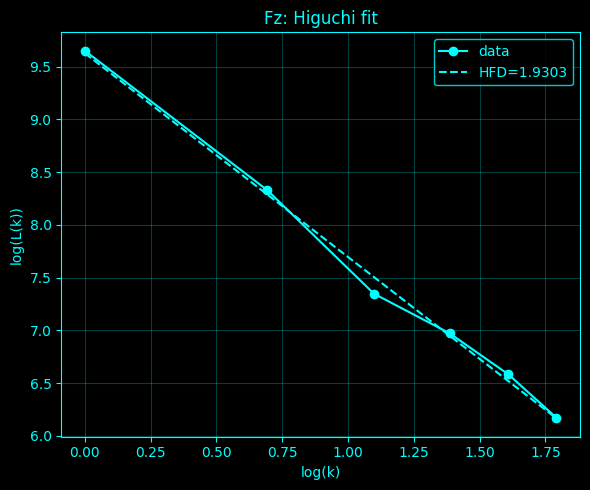

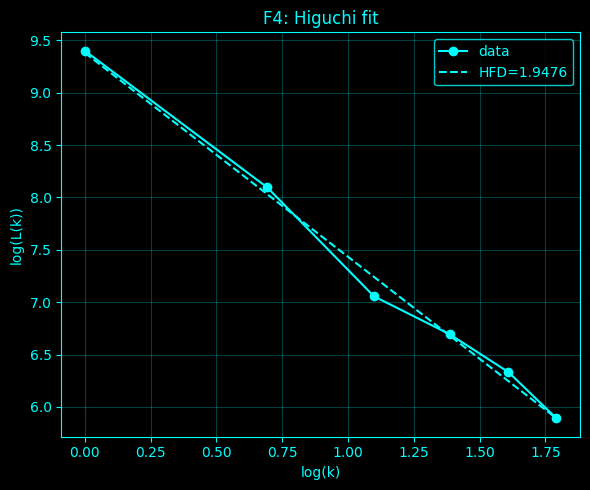

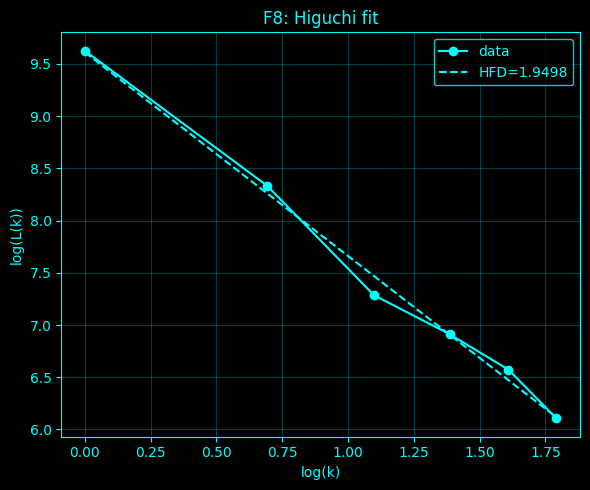

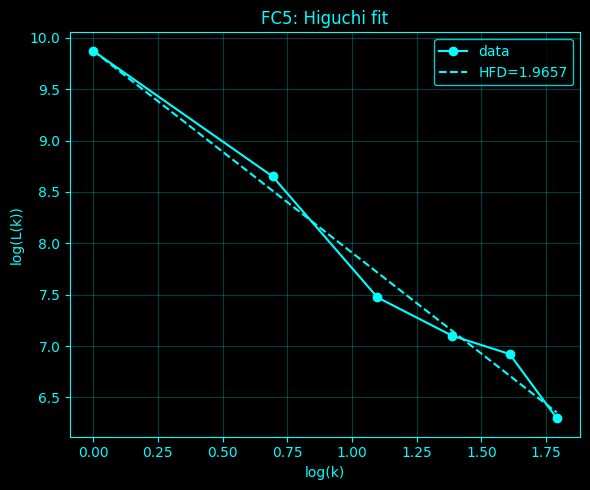

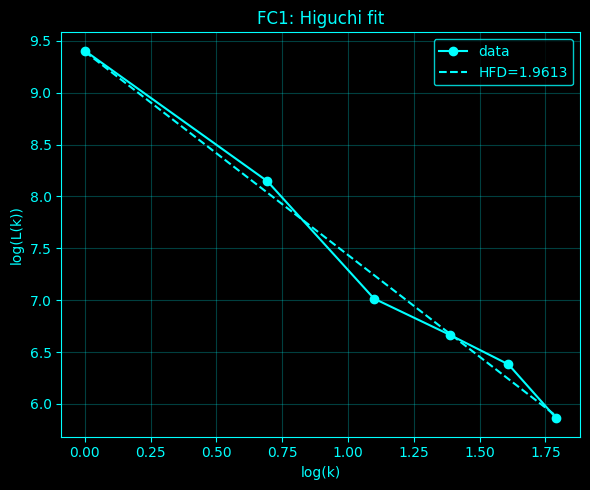

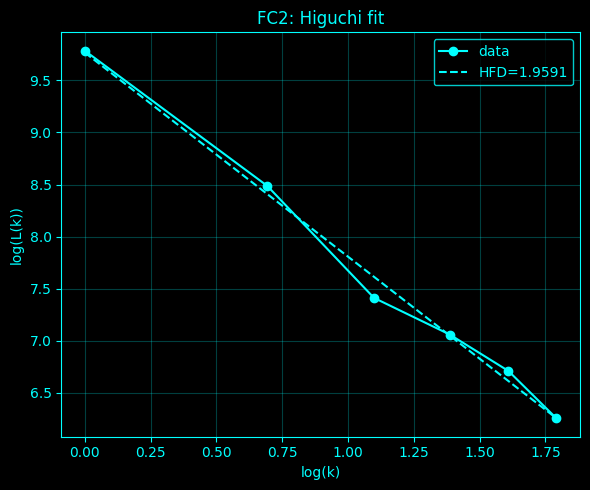

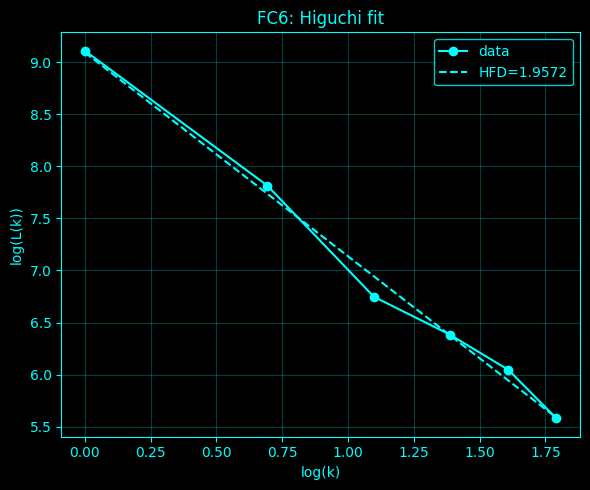

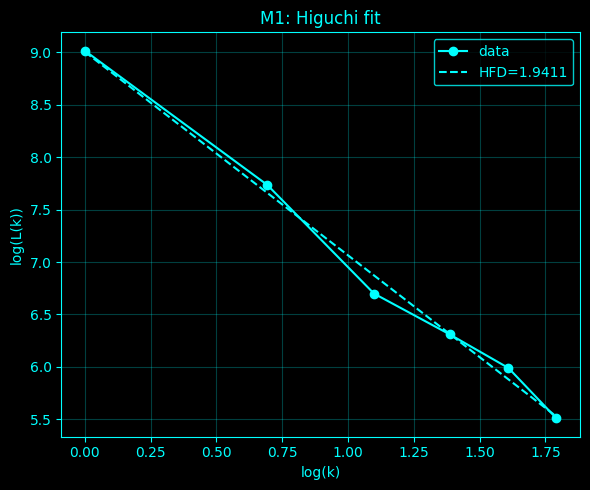

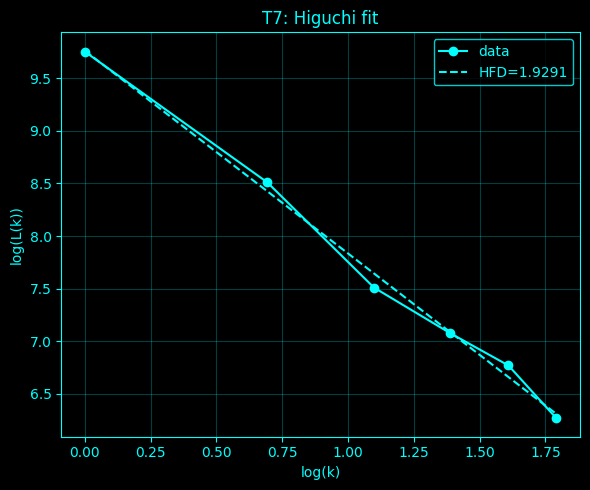

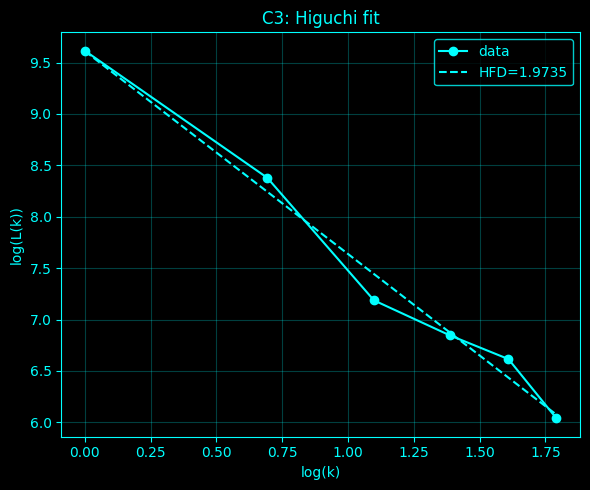

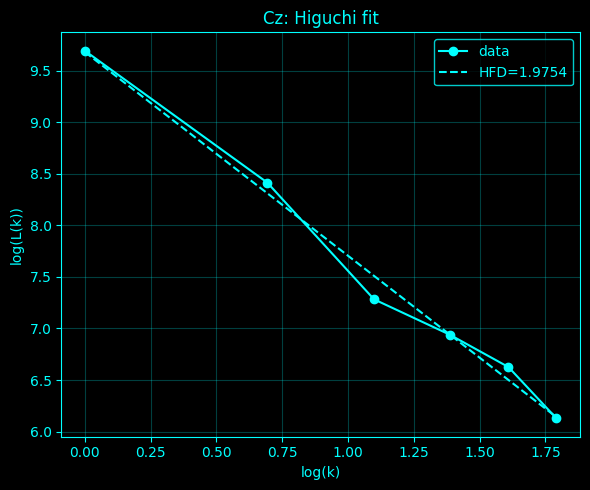

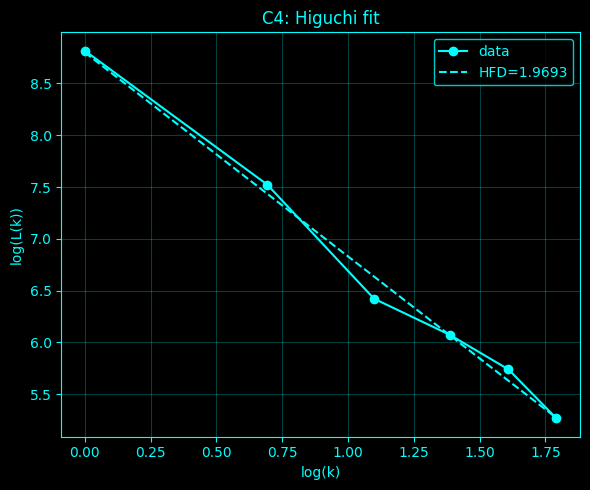

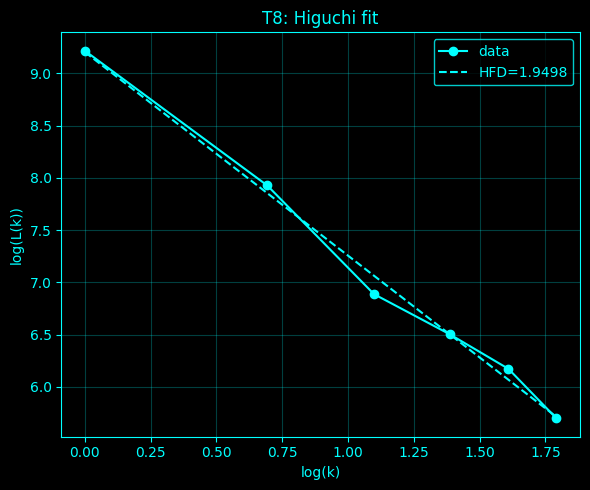

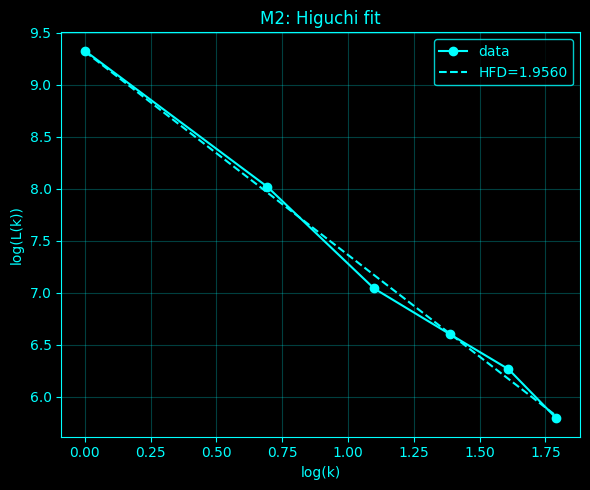

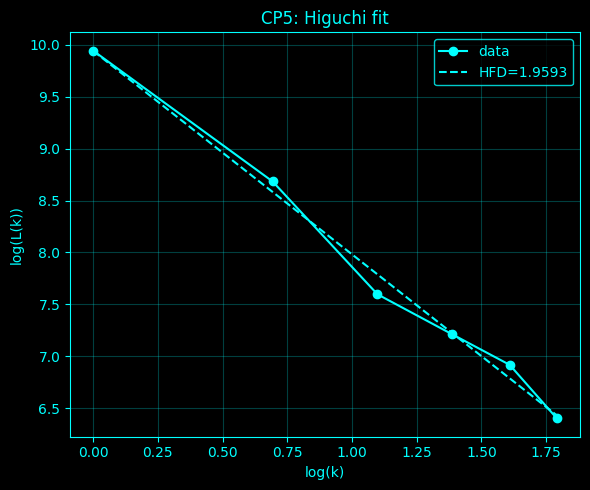

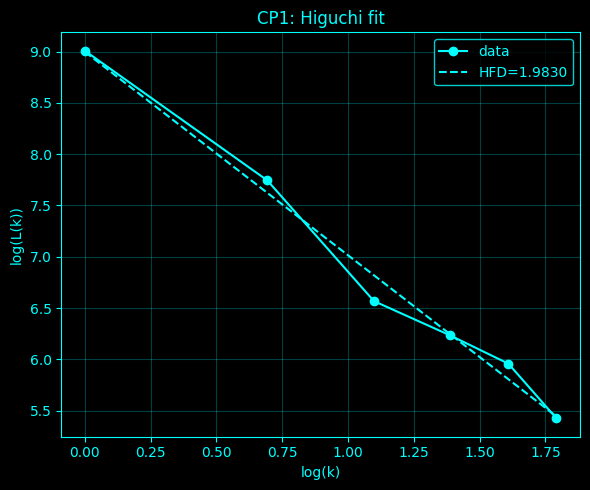

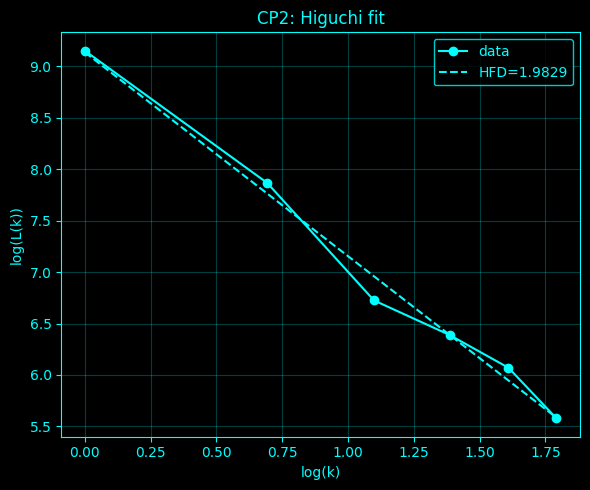

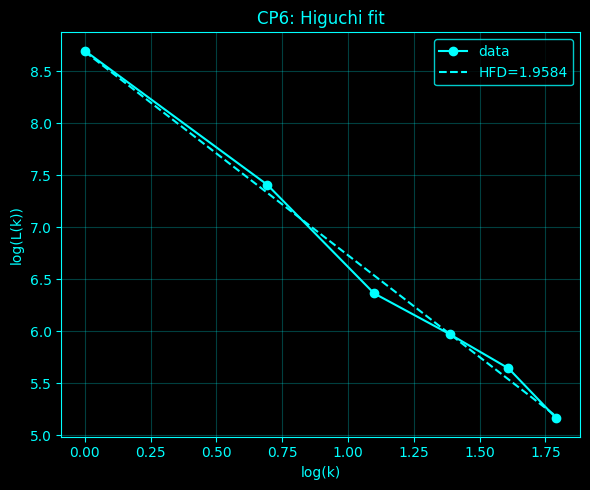

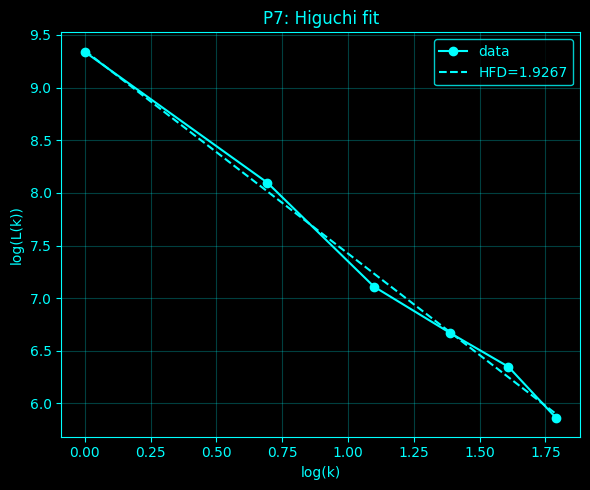

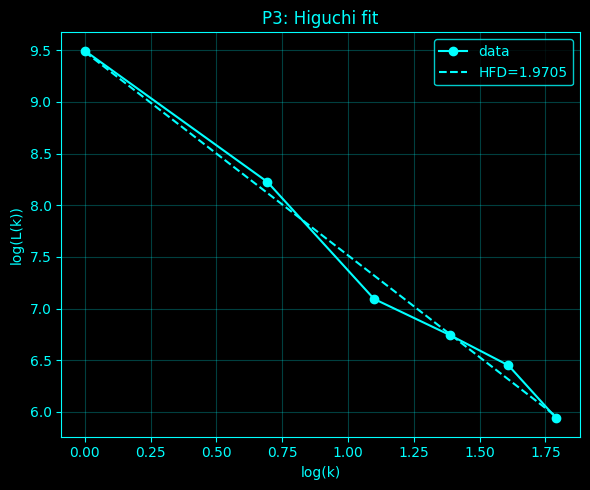

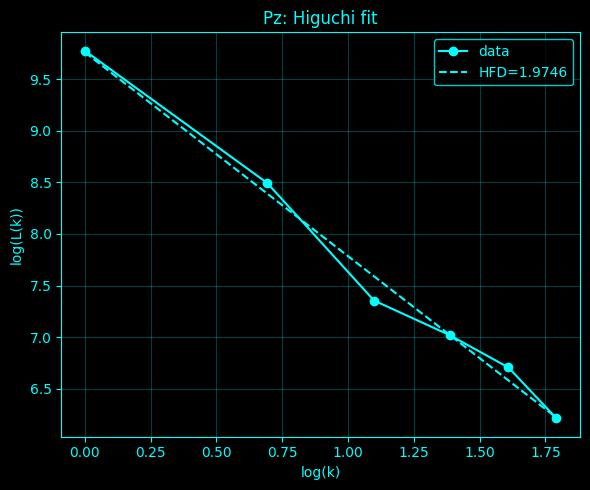

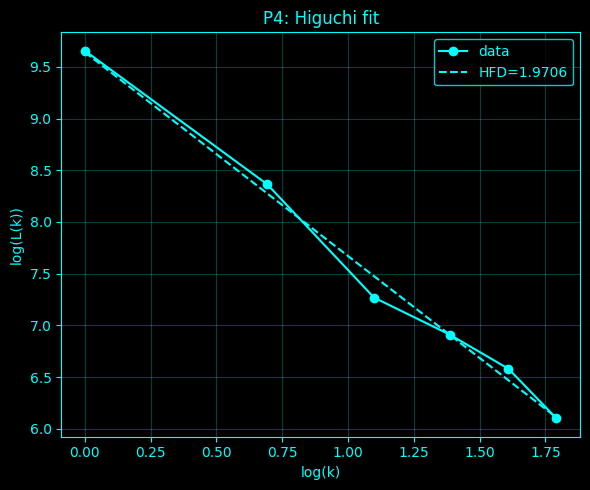

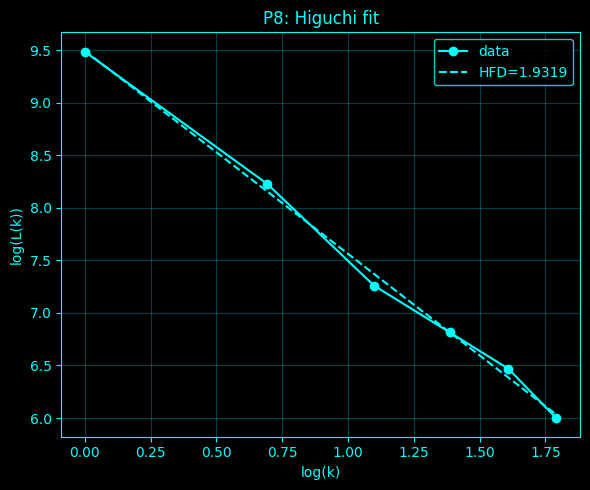

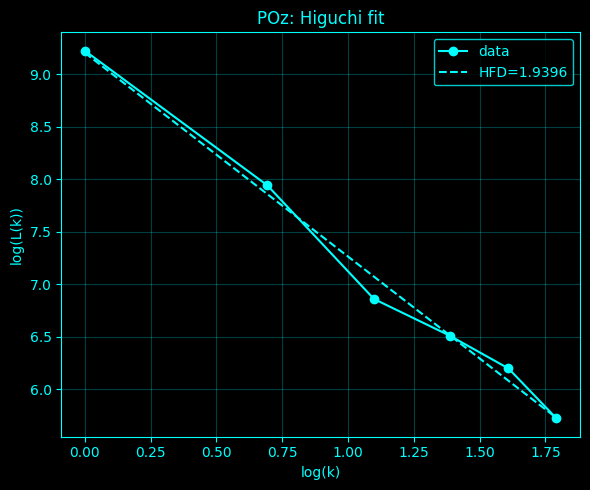

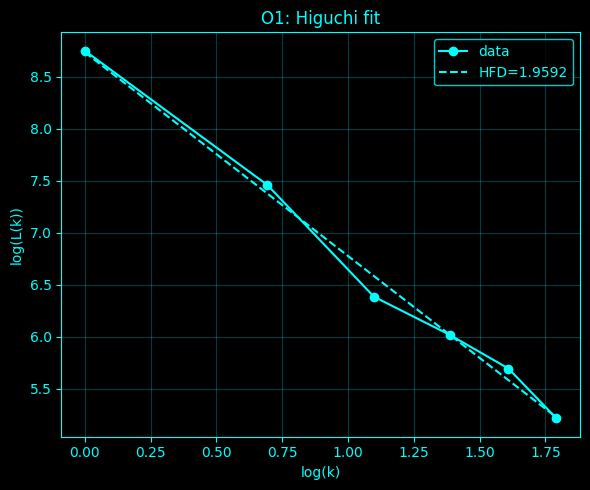

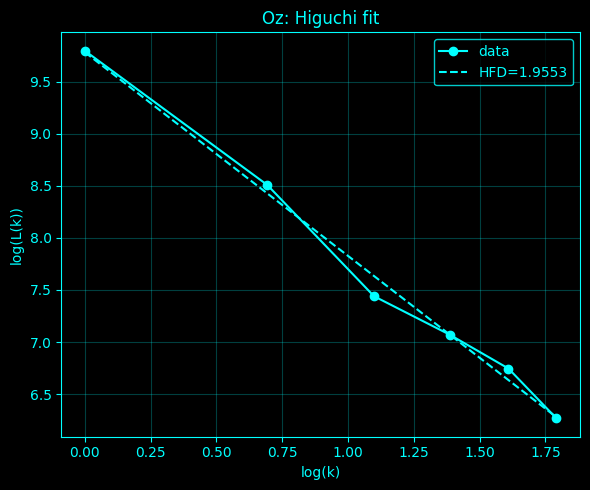

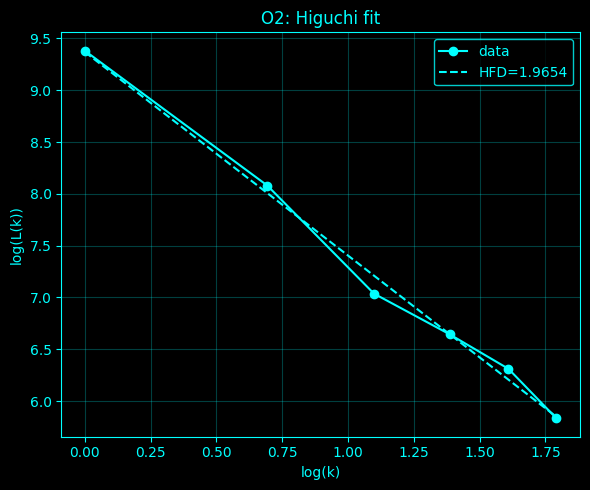

Per-channel Higuchi fit plots saved to: /home/a/projects/Complete-Neural-Signal-Analysis/fractal_dimension_higuchi/per_channel_higuchi_fits

PLOT 3 — Scalp Layout Map of Higuchi FD

What you are seeing:
  - Each labeled point represents an EEG electrode placed in an approximate scalp position.
  - The color of each point represents that channel's HFD value.
  - The head outline gives spatial context: frontal channels are near the top, occipital channels near the bottom.
  - This plot converts the HFD table into a scalp-level spatial pattern.

Patterns to look for:
  - Look for regional hotspots where several neighboring electrodes have high HFD.
  - Look for regional coldspots where several neighboring electrodes have low HFD.
  - Look for anterior-posterior gradients, such as frontal versus occipital complexity differences.
  - Look for left-right imbalance, such as higher HFD on one hemisphere.
  - Look for isolated single-electrode hotspots; these may be meaningful but may also indi

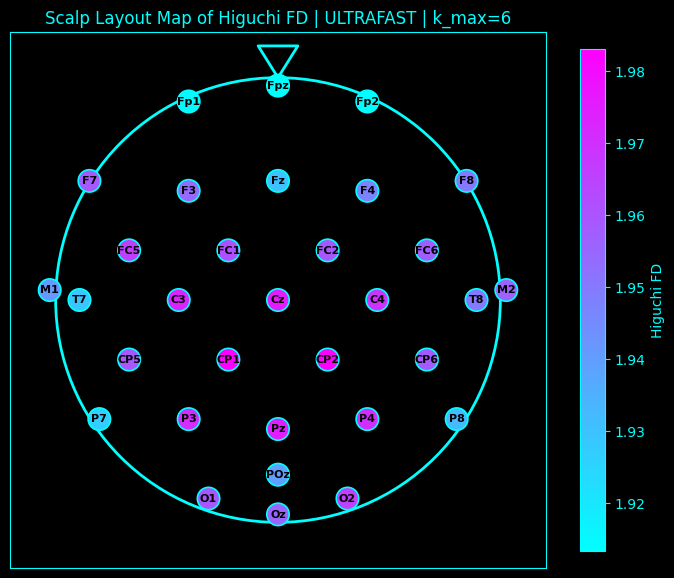


PLOT 4 — Regional Mean Higuchi FD Summary

What you are seeing:
  - Each bar is one scalp region.
  - The bar height is the mean HFD across channels in that region.
  - The error bar is the standard error of the mean.
  - The small overlaid points are the individual channel HFD values inside each region.
  - The text above each bar shows mean HFD, SEM, and number of channels.

Patterns to look for:
  - Look for the region with the highest mean HFD; this region has the strongest average waveform complexity.
  - Look for the region with the lowest mean HFD; this region has the smoothest average waveform structure.
  - Look for regions where all individual points cluster tightly; this means channels in that region agree.
  - Look for regions where individual points are widely spread; this means the region is internally heterogeneous.
  - Look for one point far from the rest of its region; this may be a local channel-specific effect or artifact.
  - Look for whether frontal, central, pari

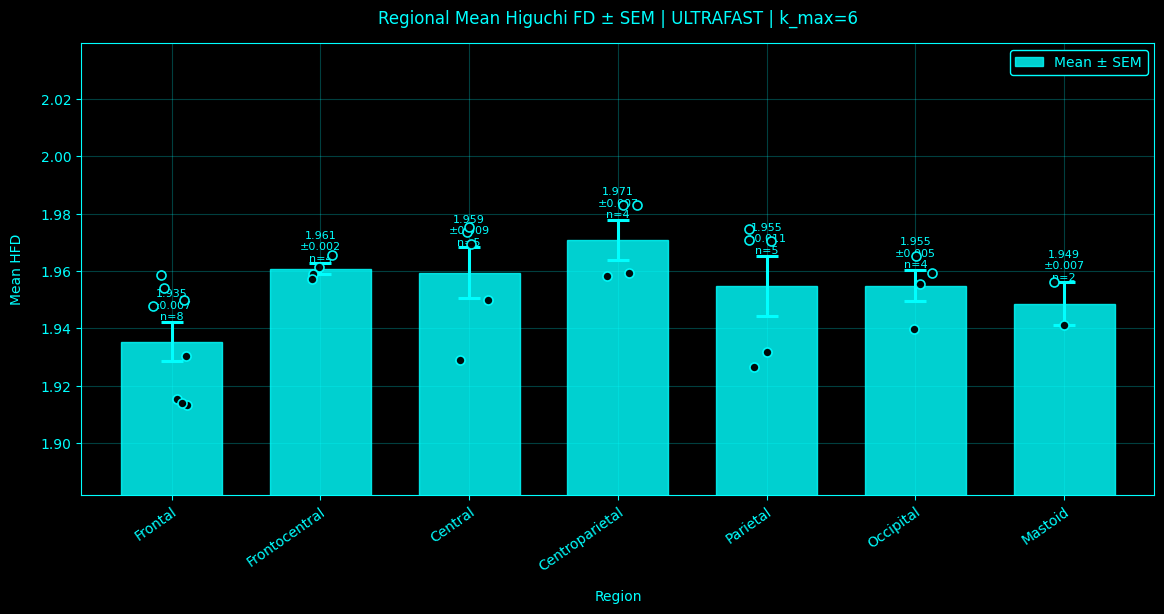

Regional summary plot saved to: /home/a/projects/Complete-Neural-Signal-Analysis/fractal_dimension_higuchi/expert_plots_ultrafast/regional_higuchi_fd_summary.png
Regional summary CSV: /home/a/projects/Complete-Neural-Signal-Analysis/fractal_dimension_higuchi/expert_plots_ultrafast/regional_higuchi_fd_summary.csv
Regional channel-point CSV: /home/a/projects/Complete-Neural-Signal-Analysis/fractal_dimension_higuchi/expert_plots_ultrafast/regional_higuchi_fd_channel_points.csv

PLOT 5 — Left-Right Higuchi FD Asymmetry

What you are seeing:
  - Each horizontal bar compares one left-right electrode pair.
  - The x-axis is left HFD minus right HFD.
  - The vertical zero line means both sides have equal HFD.
  - Bars to the right of zero mean the left channel has higher HFD.
  - Bars to the left of zero mean the right channel has higher HFD.

Patterns to look for:
  - Look for bars far from zero; these are the strongest left-right asymmetries.
  - Look for many bars leaning in the same direct

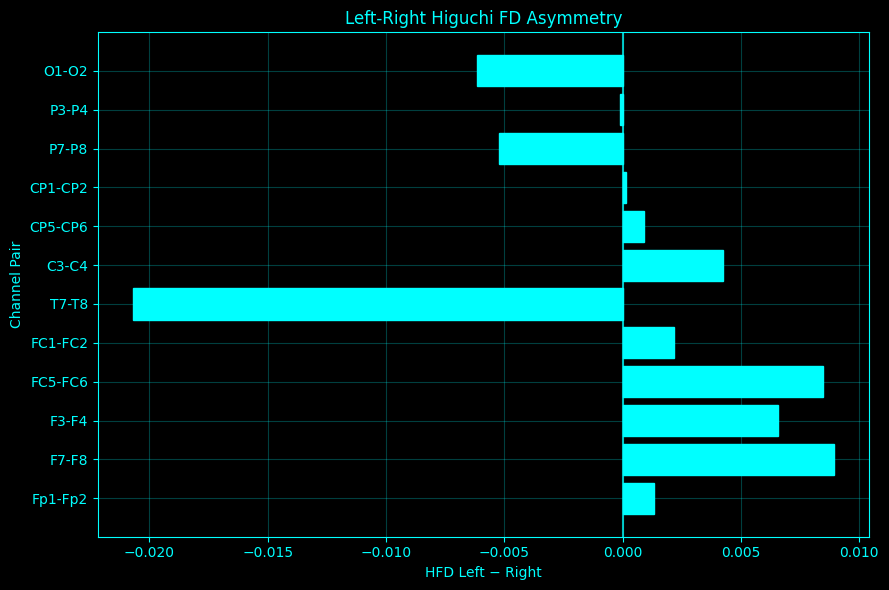


PLOT 6 — Channel HFD Ranking Colored by Fit Quality

What you are seeing:
  - Each point is one EEG channel.
  - The x-axis shows the channel's HFD value.
  - The y-axis ranks the channels from lower to higher HFD.
  - The color of each point represents the log-log fit R².
  - This plot combines the main HFD result with fit reliability.

Patterns to look for:
  - Look for channels with high HFD and high R²; these are strong high-complexity candidates.
  - Look for channels with high HFD but low R²; these may be suspicious or poorly fit.
  - Look for channels with low HFD and high R²; these are reliably smoother channels.
  - Look for a smooth ranking versus a sudden jump between channels.
  - Look for groups of neighboring channel names appearing near each other in the ranking.
  - Look for low-R² points anywhere in the ranking; those channels should be interpreted cautiously.

Cautions:
  - A high HFD with poor R² is less trustworthy than a slightly lower HFD with excellent R².
  - T

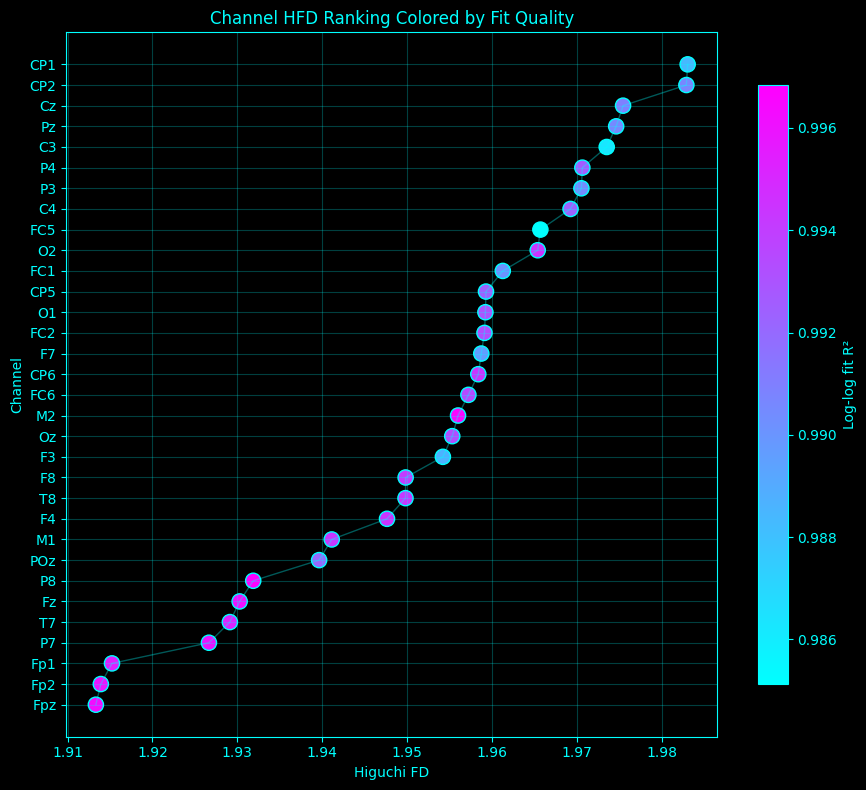


PLOT 7 — HFD versus Higuchi Log-Log Fit Quality

What you are seeing:
  - Each point is one EEG channel.
  - The x-axis shows HFD.
  - The y-axis shows fit R².
  - The channel label is printed near each point.
  - This plot separates the HFD value from the reliability of the scaling fit.

Patterns to look for:
  - Upper-right points: high HFD and high fit quality. These are strong high-complexity results.
  - Upper-left points: low HFD but high fit quality. These are reliably smoother channels.
  - Lower-right points: high HFD but poor fit quality. These are suspicious and need inspection.
  - Lower-left points: low HFD and poor fit quality. These may be weak or unstable estimates.
  - Look for channels that sit far below the main cluster in R².
  - Look for whether high HFD channels generally also have high R².
  - Look for outliers that do not follow the main HFD/R² relationship.

Cautions:
  - Do not rank channels by HFD alone if some channels have poor R².
  - Low R² means the log

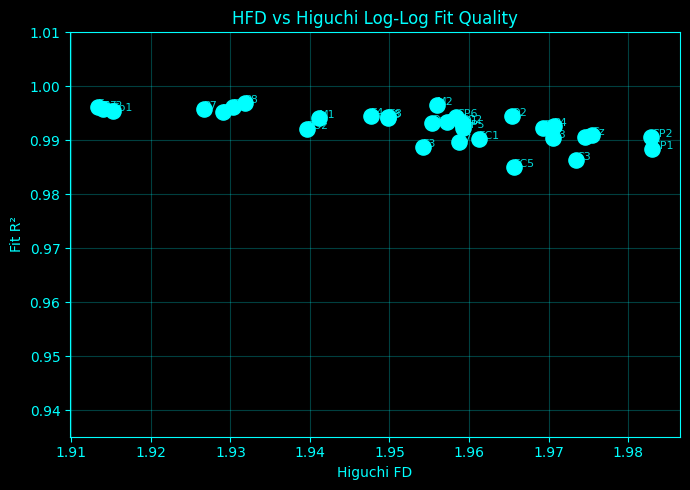


PLOT 8 — Rolling Higuchi FD Temporal Stability Heatmap

What you are seeing:
  - Each row is one EEG channel.
  - Each column is a rolling time window.
  - The color shows the HFD value within that channel and time window.
  - This plot shows whether complexity is stable or changing over time.

Patterns to look for:
  - Look for horizontal bands of stable color; these channels have stable complexity across time.
  - Look for rows with frequent color changes; these channels have temporally unstable complexity.
  - Look for vertical stripes across many channels; these indicate time periods where many channels change together.
  - Look for isolated patches in one channel; these may indicate local transient events or artifacts.
  - Look for early versus late changes in the segment.
  - Look for groups of neighboring channels that change together over time.
  - Look for channels that are consistently high across most windows.
  - Look for channels that are consistently low across most wind

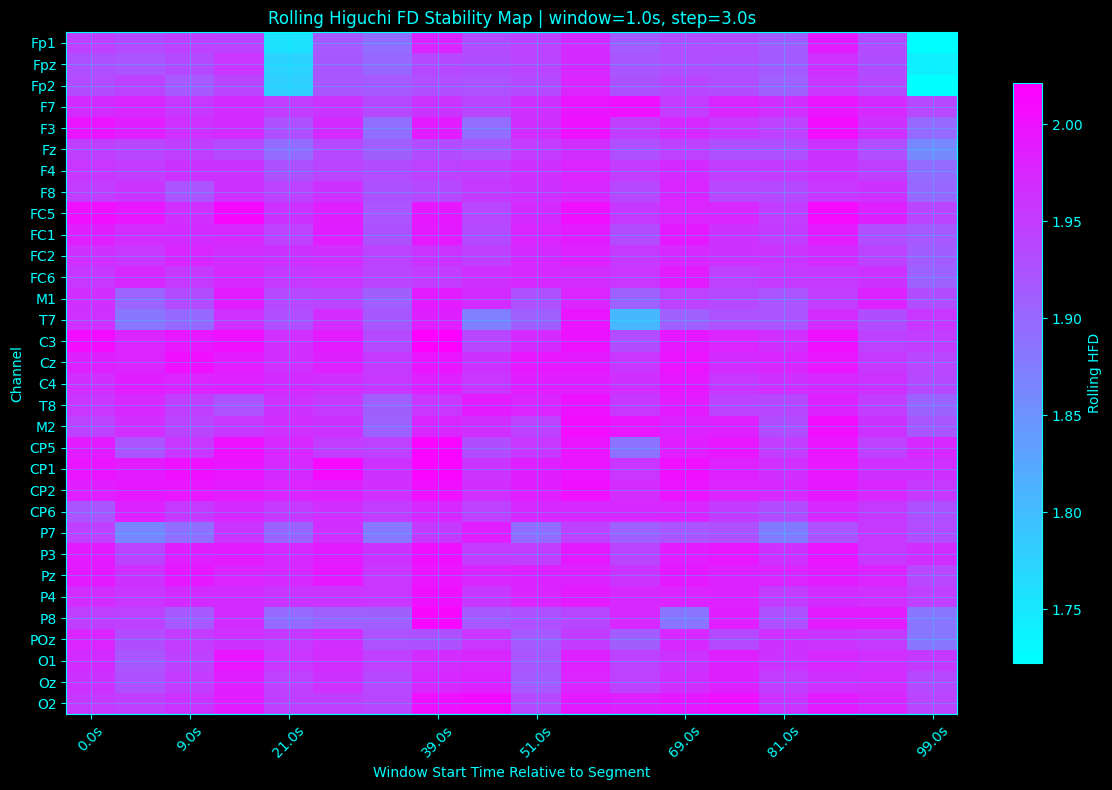


PLOT 9 — Temporal Variability of Higuchi FD by Channel

What you are seeing:
  - Each bar is one EEG channel.
  - The bar height is the standard deviation of rolling-window HFD.
  - Higher bars mean the channel's complexity changed more over time.
  - Lower bars mean the channel's complexity was more stable over time.

Patterns to look for:
  - Look for the highest bars; these channels have the most unstable complexity across the segment.
  - Look for the lowest bars; these channels have the most stable complexity.
  - Look for whether high temporal variability appears in one region or scattered across the scalp.
  - Look for whether channels with high mean HFD also have high temporal variability.
  - Look for isolated unstable channels; these may reflect transient artifacts or local events.
  - Look for groups of unstable neighboring channels; these may reflect regional state changes.

Cautions:
  - High temporal variability is not automatically bad; it may reflect real changing dyna

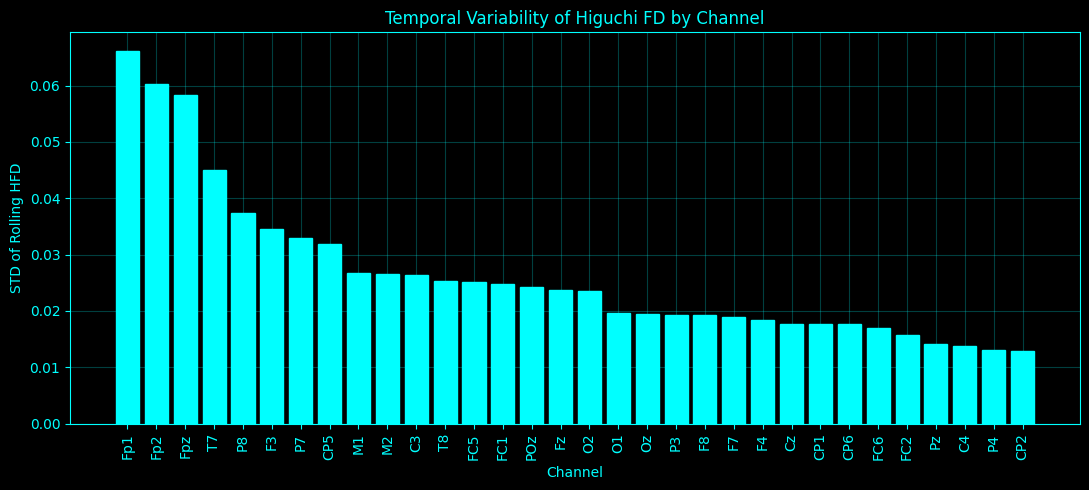


PLOT 10 — Regional HFD Dispersion

What you are seeing:
  - Each bar is one scalp region.
  - The bar height is the standard deviation of HFD across channels inside that region.
  - Higher bars mean the region is more internally heterogeneous.
  - Lower bars mean the channels in that region have more similar HFD values.

Patterns to look for:
  - Look for regions with high dispersion; these regions contain channels with very different complexity values.
  - Look for regions with low dispersion; these regions are more spatially uniform.
  - Compare this with the regional mean plot: a region can have high mean HFD but low dispersion, or moderate mean HFD but high dispersion.
  - Look for whether heterogeneity is concentrated in frontal, central, parietal, occipital, temporal, or mastoid areas.
  - If a region has high dispersion, check the overlaid points in the regional summary plot to identify which channel caused it.

Cautions:
  - Dispersion depends on the number of channels in a re

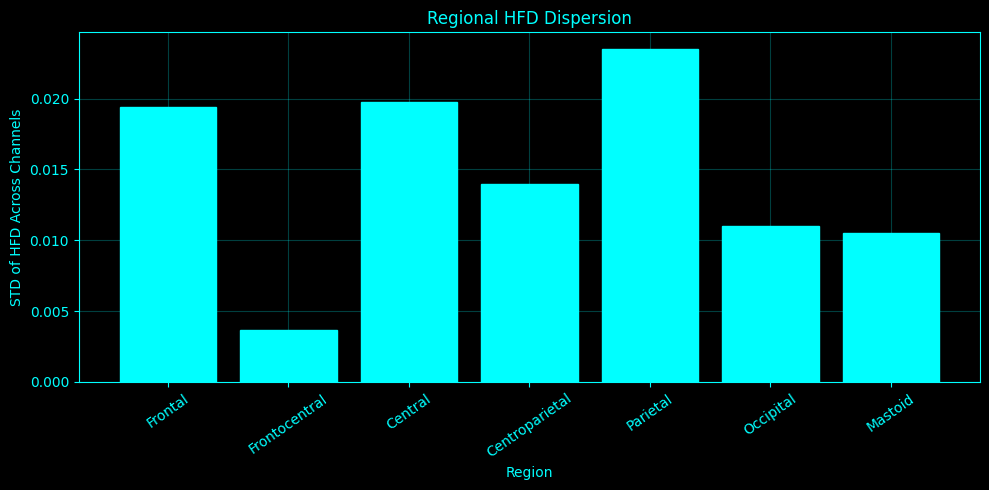


PLOT 11 — Channel Complexity versus Temporal Instability

What you are seeing:
  - Each point is one EEG channel.
  - The x-axis shows mean HFD across the full segment.
  - The y-axis shows temporal instability, measured as rolling-HFD standard deviation.
  - The color represents log-log fit R².
  - This plot separates average complexity from how stable that complexity is over time.

Patterns to look for:
  - Lower-left points: low complexity and stable over time.
  - Lower-right points: high complexity but stable over time.
  - Upper-left points: lower average complexity but unstable over time.
  - Upper-right points: high complexity and unstable over time.
  - Look for channels that are both high-HFD and high-instability; these may show dynamic complexity changes.
  - Look for channels that are high-HFD but low-instability; these may show consistently complex activity.
  - Look for channels that are unstable despite moderate HFD; these may have transient events.
  - Look for low-R² 

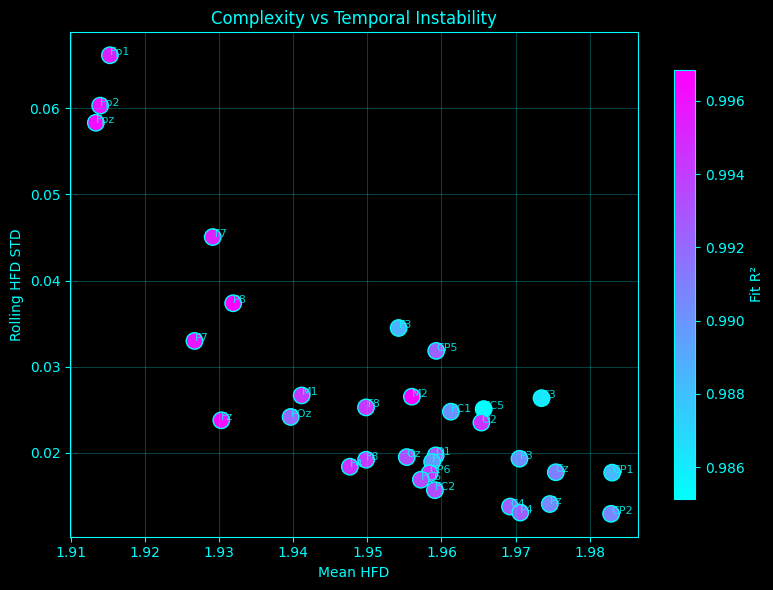


Expert plots saved to: /home/a/projects/Complete-Neural-Signal-Analysis/fractal_dimension_higuchi/expert_plots_ultrafast
Regional summary: /home/a/projects/Complete-Neural-Signal-Analysis/fractal_dimension_higuchi/expert_plots_ultrafast/regional_higuchi_fd_summary.csv
Asymmetry CSV: /home/a/projects/Complete-Neural-Signal-Analysis/fractal_dimension_higuchi/expert_plots_ultrafast/left_right_higuchi_fd_asymmetry.csv
Rolling HFD CSV: /home/a/projects/Complete-Neural-Signal-Analysis/fractal_dimension_higuchi/expert_plots_ultrafast/rolling_higuchi_fd_by_channel.csv
Temporal variability CSV: /home/a/projects/Complete-Neural-Signal-Analysis/fractal_dimension_higuchi/expert_plots_ultrafast/rolling_higuchi_fd_temporal_variability.csv

Saved outputs to: /home/a/projects/Complete-Neural-Signal-Analysis/fractal_dimension_higuchi
Summary CSV: /home/a/projects/Complete-Neural-Signal-Analysis/fractal_dimension_higuchi/higuchi_fd_summary.csv
Fit diagnostics CSV: /home/a/projects/Complete-Neural-Signa

# Interpretation of the Higuchi FD Results

This report interprets the numerical Higuchi Fractal Dimension results produced by the previous code. The goal is not merely to say which channel is highest or lowest, but to explain what the pattern means, how much confidence we should place in it, and which results deserve follow-up inspection.

---

## 1. First look at the whole distribution

Before interpreting individual electrodes, it is better to inspect the overall distribution. This tells us whether EEG complexity is nearly uniform across the scalp or whether some channels are clearly different from others.

**Global HFD summary:**

- Mean HFD: **1.9531**
- Median HFD: **1.9578**
- Standard deviation: **0.0195**
- Minimum HFD: **1.9133**
- Maximum HFD: **1.9830**
- Range: **0.0697**
- Interquartile range: **0.0258**

**Interpretation:** The spread of HFD values is noticeable. Some channels appear more geometrically complex than others during this segment.

The highest channel is **CP1** with HFD=1.9830. The lowest channel is **Fpz** with HFD=1.9133. The difference between them is **0.0697**.

**Highest-HFD channels:**

- **CP1**: 1.9830
- **CP2**: 1.9829
- **Cz**: 1.9754
- **Pz**: 1.9746
- **C3**: 1.9735

**Lowest-HFD channels:**

- **Fpz**: 1.9133
- **Fp2**: 1.9139
- **Fp1**: 1.9152
- **P7**: 1.9267
- **T7**: 1.9291

The highest-HFD channels are the channels whose waveform length changes most strongly when measured with different time steps. They are not necessarily the channels with the largest voltage. They are the channels with the most scale-dependent waveform geometry.

---

## 2. Then check whether the HFD numbers are trustworthy

HFD is estimated from the slope of the log-log relationship between measurement scale and curve length. Therefore, HFD should not be interpreted without checking the fit quality. A channel with an impressive HFD but weak fit quality is less convincing than a channel with slightly less extreme HFD and a clean log-log fit.

**Fit-quality summary:**

- Mean R²: **0.9927**
- Median R²: **0.9933**
- Minimum R²: **0.9851**

**Interpretation:** Overall fit quality appears strong. Most channels follow the expected log-log Higuchi relationship well, so the HFD values are generally more trustworthy.

**Weakest log-log fits:**

- **FC5**: fit_r2=0.9851 (higuchi_fd=1.9657, fit_rmse=0.1461)
- **C3**: fit_r2=0.9863 (higuchi_fd=1.9735, fit_rmse=0.1408)
- **CP1**: fit_r2=0.9884 (higuchi_fd=1.9830, fit_rmse=0.1301)
- **F3**: fit_r2=0.9887 (higuchi_fd=1.9542, fit_rmse=0.1264)
- **F7**: fit_r2=0.9897 (higuchi_fd=1.9587, fit_rmse=0.1209)

**Strongest log-log fits:**

- **P8**: fit_r2=0.9968 (higuchi_fd=1.9319, fit_rmse=0.0658)
- **M2**: fit_r2=0.9965 (higuchi_fd=1.9560, fit_rmse=0.0698)
- **Fpz**: fit_r2=0.9963 (higuchi_fd=1.9133, fit_rmse=0.0709)
- **Fz**: fit_r2=0.9961 (higuchi_fd=1.9303, fit_rmse=0.0728)
- **Fp2**: fit_r2=0.9959 (higuchi_fd=1.9139, fit_rmse=0.0743)

### High-HFD channels that need caution

These channels are in the high-HFD group, but their fit quality is relatively weak or below a conservative R² threshold. They are not automatically wrong, but they should be inspected before being treated as major findings.

- **C3**: higuchi_fd=1.9735 (fit_r2=0.9863, fit_rmse=0.1408)
- **CP1**: higuchi_fd=1.9830 (fit_r2=0.9884, fit_rmse=0.1301)
- **P3**: higuchi_fd=1.9705 (fit_r2=0.9905, fit_rmse=0.1169)
- **Pz**: higuchi_fd=1.9746 (fit_r2=0.9906, fit_rmse=0.1165)

The key rule is simple: **magnitude tells us what is interesting; fit quality tells us how much confidence to place in it.**

---

## 3. Next ask whether the complexity has a spatial pattern

A single channel can be unusual for many reasons. A regional pattern is stronger because it means several nearby or functionally related electrodes show similar behavior. Therefore, the regional summary is often more interpretable than the channel ranking alone.

**Regional HFD ranking:**

- **Centroparietal**: mean HFD=1.9709, SEM=0.0070, STD=0.0139, n=4
- **Frontocentral**: mean HFD=1.9608, SEM=0.0018, STD=0.0036, n=4
- **Central**: mean HFD=1.9594, SEM=0.0088, STD=0.0198, n=5
- **Occipital**: mean HFD=1.9549, SEM=0.0055, STD=0.0110, n=4
- **Parietal**: mean HFD=1.9549, SEM=0.0105, STD=0.0235, n=5
- **Mastoid**: mean HFD=1.9486, SEM=0.0074, STD=0.0105, n=2
- **Frontal**: mean HFD=1.9354, SEM=0.0069, STD=0.0194, n=8

The region with the highest mean HFD is **Centroparietal** (mean HFD=1.9709). The region with the lowest mean HFD is **Frontal** (mean HFD=1.9354).

The difference between the highest and lowest regional means is **0.0355**. This is a modest regional gap. It may be meaningful, but it should be checked against the individual channel points and error bars.

The most internally heterogeneous region is **Parietal** (regional STD=0.0235). This means the channels inside that region do not all behave the same way.

The strongest spatial conclusion is obtained when the regional mean, the individual channel points, and the scalp map all tell the same story. For example, a high regional mean is more convincing if most channels in that region are high, not only one outlier.

---

## 4. Then inspect left-right asymmetry

Left-right asymmetry compares homologous electrode pairs. The value is calculated as left HFD minus right HFD. Positive values mean the left channel is more complex. Negative values mean the right channel is more complex.

- Number of left-right pairs analyzed: **12**
- Pairs where left HFD is higher: **8**
- Pairs where right HFD is higher: **4**

Most asymmetry values lean leftward. This suggests a possible left-dominant complexity pattern, although this must be checked for artifacts and regional consistency.

The strongest asymmetry is **T7-T8**, with left-minus-right HFD=**-0.0207**. This means this pair is **right higher than left**.

**Strongest asymmetry pairs:**

- **T7-T8**: left=1.9291, right=1.9498, left-right=-0.0207 (right higher than left)
- **F7-F8**: left=1.9587, right=1.9498, left-right=0.0089 (left higher than right)
- **FC5-FC6**: left=1.9657, right=1.9572, left-right=0.0085 (left higher than right)
- **F3-F4**: left=1.9542, right=1.9476, left-right=0.0066 (left higher than right)
- **O1-O2**: left=1.9592, right=1.9654, left-right=-0.0062 (right higher than left)
- **P7-P8**: left=1.9267, right=1.9319, left-right=-0.0052 (right higher than left)

A left-right asymmetry is more convincing when several neighboring or related pairs lean in the same direction. A single large pair difference can still be interesting, but it is also more vulnerable to local channel noise.

---

## 5. Now ask whether the complexity is stable over time

A full-segment HFD value compresses the whole time segment into one number. Rolling-window HFD asks a more refined question: is that complexity stable throughout the segment, or is it driven by short periods of unusual activity?

**Most temporally unstable channels:**

- **Fp1**: rolling_hfd_std=0.0661 (mean_hfd=1.9152)
- **Fp2**: rolling_hfd_std=0.0603 (mean_hfd=1.9139)
- **Fpz**: rolling_hfd_std=0.0583 (mean_hfd=1.9133)
- **T7**: rolling_hfd_std=0.0450 (mean_hfd=1.9291)
- **P8**: rolling_hfd_std=0.0374 (mean_hfd=1.9319)

**Most temporally stable channels:**

- **CP2**: rolling_hfd_std=0.0129 (mean_hfd=1.9829)
- **P4**: rolling_hfd_std=0.0131 (mean_hfd=1.9706)
- **C4**: rolling_hfd_std=0.0138 (mean_hfd=1.9693)
- **Pz**: rolling_hfd_std=0.0141 (mean_hfd=1.9746)
- **FC2**: rolling_hfd_std=0.0157 (mean_hfd=1.9591)

The most unstable channel is much more variable than the median channel. This deserves inspection in the rolling heatmap and raw EEG.

The most important distinction is between **consistently complex** channels and **intermittently complex** channels. A channel can have high average HFD because it is complex throughout the segment, or because it has brief periods of very high complexity.


### Rolling-window global observations

The rolling analysis asks whether complexity stays constant through the segment or changes over time. This is important because a full-segment HFD value can hide short periods of unusually high or low complexity.

**Windows with highest average HFD across channels:**
- 57.00s: mean rolling HFD = 1.9828
- 87.00s: mean rolling HFD = 1.9778
- 39.00s: mean rolling HFD = 1.9762

**Windows with strongest cross-channel spread:**
- 99.00s: across-channel STD = 0.0635
- 21.00s: across-channel STD = 0.0570
- 63.00s: across-channel STD = 0.0357

The average rolling HFD changes across windows. This suggests that complexity is not perfectly stationary over time. If several channels change together in the heatmap, that may indicate a global state change or a broad artifact.

---

## 6. Combine average complexity with temporal stability

This is one of the most useful interpretations. Mean HFD tells us the average complexity of a channel. Rolling-HFD standard deviation tells us whether that complexity is stable or changing. Combining them gives four interpretive groups.

- **low complexity, unstable over time**: 12 channel(s)
- **high complexity, stable over time**: 12 channel(s)
- **high complexity, unstable over time**: 4 channel(s)
- **low complexity, stable over time**: 4 channel(s)

### High complexity, stable over time

These are strong candidates for channels with consistently complex signal structure. They are often more convincing than channels that are high only during brief windows.

- **CP1**: mean_hfd=1.9830 (rolling_hfd_std=0.0177, fit_r2=0.9884)
- **CP2**: mean_hfd=1.9829 (rolling_hfd_std=0.0129, fit_r2=0.9907)
- **Cz**: mean_hfd=1.9754 (rolling_hfd_std=0.0178, fit_r2=0.9910)
- **Pz**: mean_hfd=1.9746 (rolling_hfd_std=0.0141, fit_r2=0.9906)
- **P4**: mean_hfd=1.9706 (rolling_hfd_std=0.0131, fit_r2=0.9926)

### High complexity, unstable over time

These channels show high average complexity, but that complexity changes over time. They may reflect dynamic neural changes, transient events, or intermittent artifacts.

- **C3**: mean_hfd=1.9735 (rolling_hfd_std=0.0264, fit_r2=0.9863)
- **FC5**: mean_hfd=1.9657 (rolling_hfd_std=0.0251, fit_r2=0.9851)
- **FC1**: mean_hfd=1.9613 (rolling_hfd_std=0.0248, fit_r2=0.9902)
- **CP5**: mean_hfd=1.9593 (rolling_hfd_std=0.0318, fit_r2=0.9924)

### Low complexity, stable over time

These channels are consistently smoother or less geometrically complex across the segment.

- **F4**: mean_hfd=1.9476 (rolling_hfd_std=0.0184, fit_r2=0.9944)
- **F8**: mean_hfd=1.9498 (rolling_hfd_std=0.0192, fit_r2=0.9941)
- **Oz**: mean_hfd=1.9553 (rolling_hfd_std=0.0195, fit_r2=0.9933)
- **FC6**: mean_hfd=1.9572 (rolling_hfd_std=0.0169, fit_r2=0.9935)

### Low complexity, unstable over time

These channels have lower average complexity but fluctuate over time. This may mean they are usually smooth but contain occasional irregular episodes.

- **Fp1**: mean_hfd=1.9152 (rolling_hfd_std=0.0661, fit_r2=0.9954)
- **Fp2**: mean_hfd=1.9139 (rolling_hfd_std=0.0603, fit_r2=0.9959)
- **Fpz**: mean_hfd=1.9133 (rolling_hfd_std=0.0583, fit_r2=0.9963)
- **T7**: mean_hfd=1.9291 (rolling_hfd_std=0.0450, fit_r2=0.9952)
- **P8**: mean_hfd=1.9319 (rolling_hfd_std=0.0374, fit_r2=0.9968)

---

## 7. Artifact-aware interpretation

HFD is sensitive to genuine neural structure, but also to noise and artifacts. Therefore, the strongest conclusions are those supported by several independent signs.

### Findings that are more convincing

- A high-HFD channel also has high log-log fit R².
- Several neighboring or regionally related channels show similar HFD values.
- The regional mean agrees with the scalp map.
- Rolling-window HFD is stable when the conclusion claims stable complexity.
- Left-right asymmetry appears across several related pairs, not only one pair.
- The same conclusion appears in more than one plot or table.

### Findings that need caution

- One isolated channel is much higher than all others.
- A high-HFD channel has weak log-log fit quality.
- A result is driven by only one rolling time window.
- Frontal channels are extreme without supporting evidence from fit quality or neighboring electrodes.
- Mastoid channels are extreme compared with scalp channels.
- Many channels change together suddenly, which may indicate a global artifact or state change.

The top channel does not appear extremely isolated from the rest of the ranking. This makes the high-HFD result less likely to be a single-channel spike, although raw-signal inspection is still recommended.

---

## 8. Final synthesis

The most defensible interpretation is not based on a single number. It comes from the agreement between five pieces of evidence:

1. **HFD magnitude** — which channels or regions are high or low.
2. **Fit quality** — whether the log-log Higuchi scaling fit is reliable.
3. **Spatial coherence** — whether neighboring channels agree.
4. **Left-right structure** — whether homologous pairs show meaningful asymmetry.
5. **Temporal stability** — whether complexity is stable or driven by brief windows.

Based on the numerical results currently loaded:

- The strongest high-complexity channel candidate is **CP1** (HFD=1.9830).
- The strongest high-complexity region candidate is **Centroparietal** (mean HFD=1.9709).
- The strongest left-right asymmetry is **T7-T8** (left-right=-0.0207).
- The most temporally unstable channel is **Fp1** (rolling-HFD STD=0.0661).
- The most temporally stable channel is **CP2** (rolling-HFD STD=0.0129).

A careful final conclusion should therefore say something like this: **the most reliable HFD findings are those where high or low complexity is supported by good fit quality, spatial coherence, and temporal behavior that matches the interpretation.** Extreme values that fail one of these checks should be treated as hypotheses for inspection, not as final conclusions.

---

## 9. One-sentence takeaway

Higuchi FD tells us where the EEG waveform is geometrically simple or complex, but the strongest conclusion comes from checking whether that complexity is reliable, spatially coherent, lateralized, and stable over time.


In [4]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -------------------------------------------------------
# CONFIG
# -------------------------------------------------------
base_dir = "/home/a/projects/Complete-Neural-Signal-Analysis"
eeg_path = os.path.join(base_dir, "eeg_data_with_channels.npy")
out_dir = os.path.join(base_dir, "fractal_dimension_higuchi")
os.makedirs(out_dir, exist_ok=True)

# Same segment used in your recent analyses
sampling_rate = 1000
start_time, end_time = 814.571, 921.515
start_idx = int(start_time * sampling_rate)
end_idx   = int(end_time * sampling_rate)

eeg_channels = [
    'Fp1', 'Fpz', 'Fp2', 'F7', 'F3', 'Fz', 'F4', 'F8', 'FC5', 'FC1', 'FC2', 'FC6',
    'M1', 'T7', 'C3', 'Cz', 'C4', 'T8', 'M2', 'CP5', 'CP1', 'CP2', 'CP6',
    'P7', 'P3', 'Pz', 'P4', 'P8', 'POz', 'O1', 'Oz', 'O2'
]

# -------------------------------------------------------
# SPEED MODE
# -------------------------------------------------------
# Options:
#   "normal"    = highest fidelity
#   "fast"      = faster, mild downsampling/truncation
#   "ultrafast" = fastest exploratory scan
MODE = "ultrafast"

MODE_CONFIGS = {
    "normal": {
        "k_max": 10,
        "decimate": 1,
        "max_samples": None,
        "rolling_window_sec": 2.0,
        "rolling_step_sec": 1.0,
        "rolling_max_windows": 80,
        "expert_plots": True,
    },
    "fast": {
        "k_max": 8,
        "decimate": 2,
        "max_samples": 60000,
        "rolling_window_sec": 2.0,
        "rolling_step_sec": 2.0,
        "rolling_max_windows": 40,
        "expert_plots": True,
    },
    "ultrafast": {
        "k_max": 6,
        "decimate": 5,
        "max_samples": 20000,
        "rolling_window_sec": 1.0,
        "rolling_step_sec": 3.0,
        "rolling_max_windows": 18,
        "expert_plots": True,
    },
}

if MODE not in MODE_CONFIGS:
    raise ValueError(f"Unknown MODE={MODE}. Use one of: {list(MODE_CONFIGS)}")

mode_cfg = MODE_CONFIGS[MODE]

k_max = mode_cfg["k_max"]
decimate = mode_cfg["decimate"]
max_samples = mode_cfg["max_samples"]

ACCENT = "cyan"
BG = "black"

plt.rcParams.update({
    "figure.facecolor": BG,
    "axes.facecolor": BG,
    "savefig.facecolor": BG,
    "text.color": ACCENT,
    "axes.labelcolor": ACCENT,
    "axes.edgecolor": ACCENT,
    "axes.titlecolor": ACCENT,
    "xtick.color": ACCENT,
    "ytick.color": ACCENT,
    "grid.color": ACCENT,
    "legend.facecolor": BG,
    "legend.edgecolor": ACCENT,
})

print(f"\nRunning Higuchi FD in {MODE.upper()} mode")
print(f"k_max={k_max}, decimate={decimate}, max_samples={max_samples}")

# -------------------------------------------------------
# STYLE HELPER
# -------------------------------------------------------
def style_ax(ax):
    ax.set_facecolor(BG)
    ax.grid(True, alpha=0.25, color=ACCENT)
    ax.tick_params(colors=ACCENT)

    for spine in ax.spines.values():
        spine.set_color(ACCENT)

# -------------------------------------------------------
# LOAD EEG
# -------------------------------------------------------
EEG_data = np.load(eeg_path, allow_pickle=True)

if EEG_data.ndim != 2:
    raise ValueError(f"Expected 2D EEG array, got shape {EEG_data.shape}")

# Handle either (time, channels) or (channels, time)
if EEG_data.shape[1] == len(eeg_channels):
    EEG_segment = EEG_data[start_idx:end_idx, :]
elif EEG_data.shape[0] == len(eeg_channels):
    EEG_segment = EEG_data[:, start_idx:end_idx].T
else:
    raise ValueError(f"Unexpected EEG shape: {EEG_data.shape}")

n_time, n_channels = EEG_segment.shape
print(f"Loaded EEG segment: {n_time} samples x {n_channels} channels")
print(f"Segment: [{start_time}, {end_time}] sec")

# -------------------------------------------------------
# APPLY SPEED MODE PREPROCESSING
# -------------------------------------------------------
effective_sampling_rate = sampling_rate

if decimate > 1:
    EEG_segment = EEG_segment[::decimate, :]
    effective_sampling_rate = sampling_rate / decimate

if max_samples is not None and EEG_segment.shape[0] > max_samples:
    EEG_segment = EEG_segment[:max_samples, :]

n_time, n_channels = EEG_segment.shape

print(f"After {MODE.upper()} mode preprocessing:")
print(f"  Segment shape: {n_time} samples x {n_channels} channels")
print(f"  Effective sampling rate: {effective_sampling_rate:.2f} Hz")
print(f"  Effective duration: {n_time / effective_sampling_rate:.2f} sec")

# -------------------------------------------------------
# HIGUCHI FRACTAL DIMENSION
# -------------------------------------------------------
def higuchi_fd(x, k_max=10):
    """
    Compute Higuchi Fractal Dimension for a 1D time series.

    Notes:
    L(k) ~ k^{-D}
    so if we fit log(L(k)) vs log(k), then D = -slope
    """
    x = np.asarray(x, dtype=float)
    N = len(x)

    if N < k_max + 2:
        return np.nan, None, None

    Lk = []
    k_vals = np.arange(1, k_max + 1)

    for k in k_vals:
        Lm_vals = []

        for m in range(k):
            n_max = (N - m - 1) // k

            if n_max < 1:
                continue

            idx1 = m + np.arange(1, n_max + 1) * k
            idx0 = m + np.arange(0, n_max) * k

            diffs = np.abs(x[idx1] - x[idx0]).sum()

            # Standard Higuchi normalization
            Lmk = diffs * (N - 1) / (n_max * k * k)
            Lm_vals.append(Lmk)

        if len(Lm_vals) == 0:
            Lk.append(np.nan)
        else:
            Lk.append(np.mean(Lm_vals))

    Lk = np.asarray(Lk, dtype=float)

    mask = np.isfinite(Lk) & (Lk > 0)

    if np.sum(mask) < 2:
        return np.nan, k_vals, Lk

    slope = np.polyfit(np.log(k_vals[mask]), np.log(Lk[mask]), 1)[0]
    hfd = -slope

    return hfd, k_vals, Lk

# -------------------------------------------------------
# FIT DIAGNOSTICS HELPER
# -------------------------------------------------------
def higuchi_fit_diagnostics(k_vals, Lk):
    """
    Returns slope, intercept, HFD, R², RMSE for log-log Higuchi fit.
    """
    if k_vals is None or Lk is None:
        return {
            "slope": np.nan,
            "intercept": np.nan,
            "hfd": np.nan,
            "r2": np.nan,
            "rmse": np.nan,
        }

    mask = np.isfinite(Lk) & (Lk > 0)

    if np.sum(mask) < 2:
        return {
            "slope": np.nan,
            "intercept": np.nan,
            "hfd": np.nan,
            "r2": np.nan,
            "rmse": np.nan,
        }

    logk = np.log(k_vals[mask])
    logL = np.log(Lk[mask])

    slope, intercept = np.polyfit(logk, logL, 1)
    pred = slope * logk + intercept

    resid = logL - pred
    ss_res = np.sum(resid ** 2)
    ss_tot = np.sum((logL - np.mean(logL)) ** 2)

    r2 = 1.0 - ss_res / (ss_tot + 1e-12)
    rmse = np.sqrt(np.mean(resid ** 2))
    hfd = -slope

    return {
        "slope": slope,
        "intercept": intercept,
        "hfd": hfd,
        "r2": r2,
        "rmse": rmse,
    }

# -------------------------------------------------------
# RUN HFD PER CHANNEL
# -------------------------------------------------------
rows = []
curves = {}

for ch_idx, ch_name in enumerate(eeg_channels):
    x = EEG_segment[:, ch_idx].astype(float)
    x = (x - np.mean(x)) / (np.std(x) + 1e-12)

    hfd, k_vals, Lk = higuchi_fd(x, k_max=k_max)

    rows.append({
        "channel": ch_name,
        "higuchi_fd": hfd
    })

    curves[ch_name] = {
        "k_vals": k_vals,
        "Lk": Lk
    }

results_df = (
    pd.DataFrame(rows)
    .sort_values("higuchi_fd", ascending=False)
    .reset_index(drop=True)
)

csv_path = os.path.join(out_dir, "higuchi_fd_summary.csv")
results_df.to_csv(csv_path, index=False)

print("\nHiguchi Fractal Dimensions:")
print(results_df)

# -------------------------------------------------------
# EXPERT DIAGNOSTIC TABLE
# -------------------------------------------------------
fit_rows = []

for ch_name in eeg_channels:
    d = curves[ch_name]
    diag = higuchi_fit_diagnostics(d["k_vals"], d["Lk"])

    fit_rows.append({
        "channel": ch_name,
        "higuchi_fd": diag["hfd"],
        "fit_slope": diag["slope"],
        "fit_intercept": diag["intercept"],
        "fit_r2": diag["r2"],
        "fit_rmse": diag["rmse"],
    })

fit_df = pd.DataFrame(fit_rows)

fit_csv_path = os.path.join(out_dir, "higuchi_fd_fit_diagnostics.csv")
fit_df.to_csv(fit_csv_path, index=False)

print(f"\nFit diagnostics CSV: {fit_csv_path}")

# -------------------------------------------------------
# PLOT INTERPRETATION PRINT HELPER
# -------------------------------------------------------
def print_plot_description(title, what_you_see, patterns_to_look_for, cautions=None):
    print("\n" + "=" * 88)
    print(title)
    print("=" * 88)
    print("\nWhat you are seeing:")
    for item in what_you_see:
        print(f"  - {item}")
    print("\nPatterns to look for:")
    for item in patterns_to_look_for:
        print(f"  - {item}")
    if cautions:
        print("\nCautions:")
        for item in cautions:
            print(f"  - {item}")
    print("=" * 88 + "\n")


# -------------------------------------------------------
# PLOT 1: BAR PLOT OF HFD BY CHANNEL
# -------------------------------------------------------
print_plot_description(
    title="PLOT 1 — Higuchi Fractal Dimension by Channel",
    what_you_see=[
        "Each bar is one EEG channel.",
        "The height of the bar is the Higuchi Fractal Dimension for that channel.",
        "Channels are sorted from highest HFD to lowest HFD.",
        "Higher HFD means the waveform has more scale-dependent irregularity or geometric complexity.",
        "Lower HFD means the waveform is smoother or less geometrically complex during this segment.",
    ],
    patterns_to_look_for=[
        "Look for the highest bars: these are the channels with the most complex EEG waveforms.",
        "Look for the lowest bars: these are the smoothest or least complex channels.",
        "Look for clusters of neighboring channels with similar HFD values, such as frontal, central, parietal, or occipital grouping.",
        "Look for one isolated channel that is much higher than all others; this may be meaningful, but it may also be artifact or noise.",
        "Look for one isolated channel that is much lower than all others; this may indicate unusually smooth signal, low variance, or possible channel quality issues.",
        "Look for whether HFD values gradually decline or whether there are sharp jumps between channels.",
        "Look for whether left and right homologous channels appear similar, for example F3/F4, C3/C4, P3/P4, O1/O2.",
    ],
    cautions=[
        "A higher HFD does not automatically mean better or more important brain activity.",
        "A very high HFD can sometimes reflect noise, muscle artifact, electrode problems, or unfiltered high-frequency contamination.",
        "Interpret the bar plot together with fit quality, scalp layout, and rolling-window stability.",
    ]
)

print("Top 5 highest-HFD channels:")
print(results_df.head(5).to_string(index=False))

print("\nTop 5 lowest-HFD channels:")
print(results_df.tail(5).to_string(index=False))

fig, ax = plt.subplots(figsize=(12, 5), facecolor=BG)
style_ax(ax)

ax.bar(
    results_df["channel"],
    results_df["higuchi_fd"],
    color=ACCENT,
    edgecolor=ACCENT
)

ax.set_title(f"Higuchi Fractal Dimension by Channel | k_max={k_max}")
ax.set_xlabel("Channel")
ax.set_ylabel("HFD")
ax.tick_params(axis="x", rotation=90)

bar_path = os.path.join(out_dir, "higuchi_fd_barplot.png")
plt.tight_layout()
plt.savefig(bar_path, dpi=160, bbox_inches="tight")
plt.show()
plt.close()


# -------------------------------------------------------
# PLOT 2: LOG-L(k) FIT FOR ALL CHANNELS
# -------------------------------------------------------
print_plot_description(
    title="PLOT 2 — Log-Log Higuchi Fit for All Channels",
    what_you_see=[
        "Each small panel shows one EEG channel.",
        "The dots are the measured log(L(k)) values for different k values.",
        "The dashed line is the linear fit through those log-log points.",
        "The HFD is calculated as the negative slope of this fitted line.",
        "A clean straight-line pattern means the Higuchi scaling assumption is working well for that channel.",
    ],
    patterns_to_look_for=[
        "Look for panels where the dots fall close to the dashed line; these channels have more trustworthy HFD estimates.",
        "Look for panels where the dots curve strongly instead of forming a line; these channels may not follow one clean scaling law.",
        "Look for panels where one dot is far away from the line; this can indicate instability at a particular k value.",
        "Look for channels with steep downward slopes; these produce higher HFD values.",
        "Look for channels with flatter slopes; these produce lower HFD values.",
        "Look for systematic differences between regions, such as occipital channels having steeper fits than frontal channels.",
        "Look for channels with noisy or irregular dot patterns; those HFD values should be interpreted cautiously.",
    ],
    cautions=[
        "The HFD value is only as trustworthy as the log-log fit.",
        "If the dots do not form an approximately straight line, the single HFD number may oversimplify the signal.",
        "Small k_max values make the fit faster but give fewer points for judging linearity.",
    ]
)

fit_quality_sorted = fit_df.sort_values("fit_r2", ascending=True)
print("Lowest 5 log-log fit R² values:")
print(fit_quality_sorted[["channel", "higuchi_fd", "fit_r2", "fit_rmse"]].head(5).to_string(index=False))

print("\nHighest 5 log-log fit R² values:")
print(fit_quality_sorted[["channel", "higuchi_fd", "fit_r2", "fit_rmse"]].tail(5).to_string(index=False))

n_cols = 4
n_rows = int(np.ceil(len(eeg_channels) / n_cols))

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(4 * n_cols, 3.5 * n_rows),
    facecolor=BG
)

axes = axes.flatten()

for ax_idx, ch_name in enumerate(eeg_channels):
    ax = axes[ax_idx]
    style_ax(ax)

    if ch_name not in curves or curves[ch_name]["k_vals"] is None:
        ax.set_title(f"{ch_name}: no data")
        ax.axis("off")
        continue

    k_vals = curves[ch_name]["k_vals"]
    Lk = curves[ch_name]["Lk"]

    mask = np.isfinite(Lk) & (Lk > 0)

    if np.sum(mask) < 2:
        ax.set_title(f"{ch_name}: insufficient data")
        ax.axis("off")
        continue

    logk = np.log(k_vals[mask])
    logL = np.log(Lk[mask])

    slope, intercept = np.polyfit(logk, logL, 1)
    fit_line = slope * logk + intercept
    hfd = -slope

    ax.plot(
        logk,
        logL,
        marker="o",
        color=ACCENT,
        markerfacecolor=ACCENT,
        markeredgecolor=ACCENT,
        linewidth=1.5,
        label="data"
    )

    ax.plot(
        logk,
        fit_line,
        color=ACCENT,
        linestyle="--",
        linewidth=1.2,
        label=f"HFD={hfd:.4f}"
    )

    ax.set_title(f"{ch_name}: HFD={hfd:.4f}")
    ax.set_xlabel("log(k)")
    ax.set_ylabel("log(L(k))")
    ax.legend(fontsize=8)

for j in range(len(eeg_channels), len(axes)):
    axes[j].axis("off")

all_fits_path = os.path.join(out_dir, "all_channels_higuchi_fits.png")
plt.tight_layout()
plt.savefig(all_fits_path, dpi=160, bbox_inches="tight")
plt.show()
plt.close()

print(f"All-channel Higuchi fit plot saved to: {all_fits_path}")


# -------------------------------------------------------
# OPTIONAL: SAVE ONE FIT PLOT PER CHANNEL
# -------------------------------------------------------
print_plot_description(
    title="OPTIONAL PER-CHANNEL FIT PLOTS",
    what_you_see=[
        "Each saved plot shows one channel's log(L(k)) versus log(k) relationship.",
        "The dots show the measured Higuchi curve lengths at different scales.",
        "The dashed line shows the fitted slope used to calculate HFD.",
    ],
    patterns_to_look_for=[
        "Use these plots when one channel looks suspicious in the summary figures.",
        "Check whether an unusually high or low HFD channel has a clean fit.",
        "Look for channels where the fit is poor despite a strong HFD value.",
        "Look for channels where only one k value causes the fit to bend or fail.",
    ],
    cautions=[
        "These plots are diagnostic; they help decide whether a channel's HFD value should be trusted.",
    ]
)

per_channel_dir = os.path.join(out_dir, "per_channel_higuchi_fits")
os.makedirs(per_channel_dir, exist_ok=True)

for ch_name in eeg_channels:
    if ch_name not in curves or curves[ch_name]["k_vals"] is None:
        continue

    k_vals = curves[ch_name]["k_vals"]
    Lk = curves[ch_name]["Lk"]

    mask = np.isfinite(Lk) & (Lk > 0)

    if np.sum(mask) < 2:
        continue

    logk = np.log(k_vals[mask])
    logL = np.log(Lk[mask])

    slope, intercept = np.polyfit(logk, logL, 1)
    fit_line = slope * logk + intercept
    hfd = -slope

    fig, ax = plt.subplots(figsize=(6, 5), facecolor=BG)
    style_ax(ax)

    ax.plot(
        logk,
        logL,
        marker="o",
        color=ACCENT,
        markerfacecolor=ACCENT,
        markeredgecolor=ACCENT,
        label="data"
    )

    ax.plot(
        logk,
        fit_line,
        color=ACCENT,
        linestyle="--",
        label=f"HFD={hfd:.4f}"
    )

    ax.set_title(f"{ch_name}: Higuchi fit")
    ax.set_xlabel("log(k)")
    ax.set_ylabel("log(L(k))")
    ax.legend()

    fit_path = os.path.join(per_channel_dir, f"{ch_name}_higuchi_fit.png")
    plt.tight_layout()
    plt.savefig(fit_path, dpi=160, bbox_inches="tight")
    plt.show()
    plt.close()

print(f"Per-channel Higuchi fit plots saved to: {per_channel_dir}")


# -------------------------------------------------------
# SAVE ALL CURVES
# -------------------------------------------------------
npz_path = os.path.join(out_dir, "higuchi_fd_curves.npz")

save_dict = {}

for ch_name, d in curves.items():
    if d["k_vals"] is not None:
        save_dict[f"{ch_name}_k_vals"] = d["k_vals"]
        save_dict[f"{ch_name}_Lk"] = d["Lk"]

np.savez(npz_path, **save_dict)


# -------------------------------------------------------
# EXPERT-LEVEL ADDITIONAL PLOTS
# -------------------------------------------------------
if mode_cfg["expert_plots"]:

    expert_dir = os.path.join(out_dir, f"expert_plots_{MODE}")
    os.makedirs(expert_dir, exist_ok=True)

    hfd_map = dict(zip(results_df["channel"], results_df["higuchi_fd"]))

    # ---------------------------------------------------
    # PLOT 3: SCALP-LAYOUT HFD MAP
    # ---------------------------------------------------
    print_plot_description(
        title="PLOT 3 — Scalp Layout Map of Higuchi FD",
        what_you_see=[
            "Each labeled point represents an EEG electrode placed in an approximate scalp position.",
            "The color of each point represents that channel's HFD value.",
            "The head outline gives spatial context: frontal channels are near the top, occipital channels near the bottom.",
            "This plot converts the HFD table into a scalp-level spatial pattern.",
        ],
        patterns_to_look_for=[
            "Look for regional hotspots where several neighboring electrodes have high HFD.",
            "Look for regional coldspots where several neighboring electrodes have low HFD.",
            "Look for anterior-posterior gradients, such as frontal versus occipital complexity differences.",
            "Look for left-right imbalance, such as higher HFD on one hemisphere.",
            "Look for isolated single-electrode hotspots; these may be meaningful but may also indicate channel artifact.",
            "Look for smooth spatial transitions across neighboring electrodes; these are usually more believable than isolated spikes.",
            "Compare mastoid channels M1 and M2 with scalp channels; unusual mastoid values may suggest reference or peripheral effects.",
        ],
        cautions=[
            "This is an approximate layout, not a full interpolated topographic EEG map.",
            "A single bright point should be checked against raw signal quality and fit diagnostics.",
        ]
    )

    scalp_xy = {
        "Fp1": (-0.45, 1.00), "Fpz": (0.00, 1.08), "Fp2": (0.45, 1.00),
        "F7": (-0.95, 0.60), "F3": (-0.45, 0.55), "Fz": (0.00, 0.60),
        "F4": (0.45, 0.55), "F8": (0.95, 0.60),
        "FC5": (-0.75, 0.25), "FC1": (-0.25, 0.25),
        "FC2": (0.25, 0.25), "FC6": (0.75, 0.25),
        "M1": (-1.15, 0.05), "T7": (-1.00, 0.00), "C3": (-0.50, 0.00),
        "Cz": (0.00, 0.00), "C4": (0.50, 0.00), "T8": (1.00, 0.00),
        "M2": (1.15, 0.05),
        "CP5": (-0.75, -0.30), "CP1": (-0.25, -0.30),
        "CP2": (0.25, -0.30), "CP6": (0.75, -0.30),
        "P7": (-0.90, -0.60), "P3": (-0.45, -0.60), "Pz": (0.00, -0.65),
        "P4": (0.45, -0.60), "P8": (0.90, -0.60),
        "POz": (0.00, -0.88),
        "O1": (-0.35, -1.00), "Oz": (0.00, -1.08), "O2": (0.35, -1.00),
    }

    xs, ys, vals, labels = [], [], [], []

    for ch in eeg_channels:
        if ch in scalp_xy and ch in hfd_map and np.isfinite(hfd_map[ch]):
            xs.append(scalp_xy[ch][0])
            ys.append(scalp_xy[ch][1])
            vals.append(hfd_map[ch])
            labels.append(ch)

    scalp_df = pd.DataFrame({
        "channel": labels,
        "x": xs,
        "y": ys,
        "hfd": vals
    }).sort_values("hfd", ascending=False)

    print("Highest HFD scalp locations:")
    print(scalp_df.head(6)[["channel", "hfd"]].to_string(index=False))

    print("\nLowest HFD scalp locations:")
    print(scalp_df.tail(6)[["channel", "hfd"]].to_string(index=False))

    fig, ax = plt.subplots(figsize=(7, 7), facecolor=BG)
    style_ax(ax)

    head = plt.Circle((0, 0), 1.12, fill=False, color=ACCENT, linewidth=2)
    ax.add_patch(head)

    nose_x = [0.00, -0.10, 0.10, 0.00]
    nose_y = [1.12, 1.28, 1.28, 1.12]
    ax.plot(nose_x, nose_y, color=ACCENT, linewidth=2)

    sc = ax.scatter(
        xs,
        ys,
        c=vals,
        s=260,
        cmap="cool",
        edgecolor=ACCENT,
        linewidth=1.2
    )

    for x0, y0, label in zip(xs, ys, labels):
        ax.text(
            x0,
            y0,
            label,
            ha="center",
            va="center",
            fontsize=8,
            color=BG,
            fontweight="bold"
        )

    cbar = plt.colorbar(sc, ax=ax, shrink=0.75)
    cbar.set_label("Higuchi FD", color=ACCENT)
    cbar.ax.yaxis.set_tick_params(color=ACCENT)
    plt.setp(cbar.ax.get_yticklabels(), color=ACCENT)
    cbar.outline.set_edgecolor(ACCENT)

    ax.set_title(f"Scalp Layout Map of Higuchi FD | {MODE.upper()} | k_max={k_max}")
    ax.set_xlim(-1.35, 1.35)
    ax.set_ylim(-1.35, 1.35)
    ax.set_aspect("equal")
    ax.set_xticks([])
    ax.set_yticks([])

    scalp_path = os.path.join(expert_dir, "higuchi_fd_scalp_layout_map.png")
    plt.tight_layout()
    plt.savefig(scalp_path, dpi=180, bbox_inches="tight")
    plt.show()
    plt.close()

    # ---------------------------------------------------
    # PLOT 4: REGIONAL HFD SUMMARY
    # ---------------------------------------------------
    print_plot_description(
        title="PLOT 4 — Regional Mean Higuchi FD Summary",
        what_you_see=[
            "Each bar is one scalp region.",
            "The bar height is the mean HFD across channels in that region.",
            "The error bar is the standard error of the mean.",
            "The small overlaid points are the individual channel HFD values inside each region.",
            "The text above each bar shows mean HFD, SEM, and number of channels.",
        ],
        patterns_to_look_for=[
            "Look for the region with the highest mean HFD; this region has the strongest average waveform complexity.",
            "Look for the region with the lowest mean HFD; this region has the smoothest average waveform structure.",
            "Look for regions where all individual points cluster tightly; this means channels in that region agree.",
            "Look for regions where individual points are widely spread; this means the region is internally heterogeneous.",
            "Look for one point far from the rest of its region; this may be a local channel-specific effect or artifact.",
            "Look for whether frontal, central, parietal, and occipital regions form a gradient.",
            "Look for whether mastoid channels behave differently from scalp regions.",
            "Look for overlapping error bars; strong overlap means regional differences should be interpreted cautiously.",
        ],
        cautions=[
            "Regional averages can hide individual channel outliers.",
            "Small regions with few channels can have less stable means.",
        ]
    )

    regions = {
        "Frontal": ["Fp1", "Fpz", "Fp2", "F7", "F3", "Fz", "F4", "F8"],
        "Frontocentral": ["FC5", "FC1", "FC2", "FC6"],
        "Central": ["T7", "C3", "Cz", "C4", "T8"],
        "Centroparietal": ["CP5", "CP1", "CP2", "CP6"],
        "Parietal": ["P7", "P3", "Pz", "P4", "P8"],
        "Occipital": ["POz", "O1", "Oz", "O2"],
        "Mastoid": ["M1", "M2"],
    }

    region_rows = []
    region_points = []

    for region_name, chans in regions.items():
        vals_region = []

        for ch in chans:
            if ch in hfd_map and np.isfinite(hfd_map[ch]):
                vals_region.append(hfd_map[ch])
                region_points.append({
                    "region": region_name,
                    "channel": ch,
                    "hfd": hfd_map[ch],
                })

        if len(vals_region) == 0:
            continue

        vals_region = np.asarray(vals_region, dtype=float)

        region_rows.append({
            "region": region_name,
            "mean_hfd": np.mean(vals_region),
            "std_hfd": np.std(vals_region, ddof=1) if len(vals_region) > 1 else 0.0,
            "sem_hfd": (
                np.std(vals_region, ddof=1) / np.sqrt(len(vals_region))
                if len(vals_region) > 1 else 0.0
            ),
            "n_channels": len(vals_region),
        })

    region_df = pd.DataFrame(region_rows)
    region_points_df = pd.DataFrame(region_points)

    region_csv_path = os.path.join(expert_dir, "regional_higuchi_fd_summary.csv")
    region_df.to_csv(region_csv_path, index=False)

    region_points_csv_path = os.path.join(expert_dir, "regional_higuchi_fd_channel_points.csv")
    region_points_df.to_csv(region_points_csv_path, index=False)

    print("Regional HFD summary:")
    print(region_df.sort_values("mean_hfd", ascending=False).to_string(index=False))

    fig, ax = plt.subplots(figsize=(12, 6.5), facecolor=BG)
    style_ax(ax)

    x = np.arange(len(region_df))

    bars = ax.bar(
        x,
        region_df["mean_hfd"],
        yerr=region_df["sem_hfd"],
        color=ACCENT,
        edgecolor=ACCENT,
        alpha=0.82,
        width=0.68,
        capsize=8,
        error_kw={
            "elinewidth": 2.2,
            "capthick": 2.2,
            "ecolor": ACCENT,
            "alpha": 1.0,
        },
        label="Mean ± SEM"
    )

    rng = np.random.default_rng(7)

    for i, region_name in enumerate(region_df["region"]):
        vals = region_points_df.loc[
            region_points_df["region"] == region_name,
            "hfd"
        ].to_numpy(dtype=float)

        if len(vals) == 0:
            continue

        jitter = rng.uniform(-0.13, 0.13, size=len(vals))

        ax.scatter(
            np.full(len(vals), i) + jitter,
            vals,
            s=42,
            facecolors=BG,
            edgecolors=ACCENT,
            linewidths=1.2,
            alpha=0.95,
            zorder=4
        )

    for i, row in region_df.iterrows():
        y = row["mean_hfd"]
        sem = row["sem_hfd"]

        ax.text(
            i,
            y + sem,
            f"{y:.3f}\n±{sem:.3f}\nn={int(row['n_channels'])}",
            ha="center",
            va="bottom",
            fontsize=8,
            color=ACCENT
        )

    all_region_vals = region_points_df["hfd"].to_numpy(dtype=float)
    all_sem_upper = region_df["mean_hfd"].to_numpy(dtype=float) + region_df["sem_hfd"].to_numpy(dtype=float)
    all_sem_lower = region_df["mean_hfd"].to_numpy(dtype=float) - region_df["sem_hfd"].to_numpy(dtype=float)

    y_min = np.nanmin(np.concatenate([all_region_vals, all_sem_lower]))
    y_max = np.nanmax(np.concatenate([all_region_vals, all_sem_upper]))

    y_range = y_max - y_min
    if not np.isfinite(y_range) or y_range <= 0:
        y_range = 0.05

    pad = max(0.025, y_range * 0.45)

    ax.set_ylim(y_min - pad, y_max + pad * 1.8)

    ax.set_title(f"Regional Mean Higuchi FD ± SEM | {MODE.upper()} | k_max={k_max}", pad=14)
    ax.set_xlabel("Region", labelpad=12)
    ax.set_ylabel("Mean HFD", labelpad=12)

    ax.set_xticks(x)
    ax.set_xticklabels(
        region_df["region"],
        rotation=35,
        ha="right",
        rotation_mode="anchor"
    )

    ax.margins(x=0.04)
    ax.legend(loc="best", framealpha=1.0)

    region_path = os.path.join(expert_dir, "regional_higuchi_fd_summary.png")
    plt.tight_layout(pad=2.0)
    plt.savefig(region_path, dpi=220, bbox_inches="tight")
    plt.show()
    plt.close()

    print(f"Regional summary plot saved to: {region_path}")
    print(f"Regional summary CSV: {region_csv_path}")
    print(f"Regional channel-point CSV: {region_points_csv_path}")

    # ---------------------------------------------------
    # PLOT 5: LEFT-RIGHT ASYMMETRY
    # ---------------------------------------------------
    print_plot_description(
        title="PLOT 5 — Left-Right Higuchi FD Asymmetry",
        what_you_see=[
            "Each horizontal bar compares one left-right electrode pair.",
            "The x-axis is left HFD minus right HFD.",
            "The vertical zero line means both sides have equal HFD.",
            "Bars to the right of zero mean the left channel has higher HFD.",
            "Bars to the left of zero mean the right channel has higher HFD.",
        ],
        patterns_to_look_for=[
            "Look for bars far from zero; these are the strongest left-right asymmetries.",
            "Look for many bars leaning in the same direction; this may suggest hemisphere-level imbalance.",
            "Look for asymmetry concentrated in one region, such as frontal, temporal, parietal, or occipital.",
            "Look for pairs near zero; these show balanced left-right complexity.",
            "Compare asymmetry with the scalp map to see whether the spatial pattern agrees.",
            "Check whether a large asymmetry is caused by one unusually high channel or one unusually low channel.",
        ],
        cautions=[
            "Left-right asymmetry can reflect neural differences, but also artifacts, electrode impedance, referencing, or local noise.",
            "Large asymmetry should be checked against raw EEG and fit quality.",
        ]
    )

    lr_pairs = [
        ("Fp1", "Fp2"),
        ("F7", "F8"),
        ("F3", "F4"),
        ("FC5", "FC6"),
        ("FC1", "FC2"),
        ("T7", "T8"),
        ("C3", "C4"),
        ("CP5", "CP6"),
        ("CP1", "CP2"),
        ("P7", "P8"),
        ("P3", "P4"),
        ("O1", "O2"),
    ]

    asym_rows = []

    for left_ch, right_ch in lr_pairs:
        if left_ch in hfd_map and right_ch in hfd_map:
            left_val = hfd_map[left_ch]
            right_val = hfd_map[right_ch]

            if np.isfinite(left_val) and np.isfinite(right_val):
                asym_rows.append({
                    "pair": f"{left_ch}-{right_ch}",
                    "left_channel": left_ch,
                    "right_channel": right_ch,
                    "left_hfd": left_val,
                    "right_hfd": right_val,
                    "asymmetry_left_minus_right": left_val - right_val,
                })

    asym_df = pd.DataFrame(asym_rows)
    asym_csv_path = os.path.join(expert_dir, "left_right_higuchi_fd_asymmetry.csv")
    asym_df.to_csv(asym_csv_path, index=False)

    asym_rank = asym_df.copy()
    asym_rank["abs_asymmetry"] = asym_rank["asymmetry_left_minus_right"].abs()
    asym_rank = asym_rank.sort_values("abs_asymmetry", ascending=False)

    print("Strongest left-right asymmetries:")
    print(asym_rank[["pair", "left_hfd", "right_hfd", "asymmetry_left_minus_right"]].head(6).to_string(index=False))

    fig, ax = plt.subplots(figsize=(9, 6), facecolor=BG)
    style_ax(ax)

    ax.axvline(0, color=ACCENT, linewidth=1.5, alpha=0.75)

    ax.barh(
        asym_df["pair"],
        asym_df["asymmetry_left_minus_right"],
        color=ACCENT,
        edgecolor=ACCENT
    )

    ax.set_title("Left-Right Higuchi FD Asymmetry")
    ax.set_xlabel("HFD Left − Right")
    ax.set_ylabel("Channel Pair")

    asym_path = os.path.join(expert_dir, "left_right_higuchi_fd_asymmetry.png")
    plt.tight_layout()
    plt.savefig(asym_path, dpi=180, bbox_inches="tight")
    plt.show()
    plt.close()

    # ---------------------------------------------------
    # PLOT 6: HFD RANKING WITH FIT QUALITY
    # ---------------------------------------------------
    print_plot_description(
        title="PLOT 6 — Channel HFD Ranking Colored by Fit Quality",
        what_you_see=[
            "Each point is one EEG channel.",
            "The x-axis shows the channel's HFD value.",
            "The y-axis ranks the channels from lower to higher HFD.",
            "The color of each point represents the log-log fit R².",
            "This plot combines the main HFD result with fit reliability.",
        ],
        patterns_to_look_for=[
            "Look for channels with high HFD and high R²; these are strong high-complexity candidates.",
            "Look for channels with high HFD but low R²; these may be suspicious or poorly fit.",
            "Look for channels with low HFD and high R²; these are reliably smoother channels.",
            "Look for a smooth ranking versus a sudden jump between channels.",
            "Look for groups of neighboring channel names appearing near each other in the ranking.",
            "Look for low-R² points anywhere in the ranking; those channels should be interpreted cautiously.",
        ],
        cautions=[
            "A high HFD with poor R² is less trustworthy than a slightly lower HFD with excellent R².",
            "This plot helps separate magnitude of complexity from confidence in the fit.",
        ]
    )

    rank_df = fit_df.copy()
    rank_df = rank_df.sort_values("higuchi_fd", ascending=True).reset_index(drop=True)

    print("Highest HFD channels with fit quality:")
    print(rank_df.sort_values("higuchi_fd", ascending=False)[["channel", "higuchi_fd", "fit_r2", "fit_rmse"]].head(8).to_string(index=False))

    fig, ax = plt.subplots(figsize=(9, 8), facecolor=BG)
    style_ax(ax)

    sc = ax.scatter(
        rank_df["higuchi_fd"],
        rank_df["channel"],
        c=rank_df["fit_r2"],
        s=120,
        cmap="cool",
        edgecolor=ACCENT,
        linewidth=1.0
    )

    ax.plot(
        rank_df["higuchi_fd"],
        rank_df["channel"],
        color=ACCENT,
        alpha=0.35,
        linewidth=1.0
    )

    cbar = plt.colorbar(sc, ax=ax, shrink=0.85)
    cbar.set_label("Log-log fit R²", color=ACCENT)
    cbar.ax.yaxis.set_tick_params(color=ACCENT)
    plt.setp(cbar.ax.get_yticklabels(), color=ACCENT)
    cbar.outline.set_edgecolor(ACCENT)

    ax.set_title("Channel HFD Ranking Colored by Fit Quality")
    ax.set_xlabel("Higuchi FD")
    ax.set_ylabel("Channel")

    ranking_path = os.path.join(expert_dir, "higuchi_fd_ranking_fit_quality.png")
    plt.tight_layout()
    plt.savefig(ranking_path, dpi=180, bbox_inches="tight")
    plt.show()
    plt.close()

    # ---------------------------------------------------
    # PLOT 7: HFD VS FIT R² DIAGNOSTIC
    # ---------------------------------------------------
    print_plot_description(
        title="PLOT 7 — HFD versus Higuchi Log-Log Fit Quality",
        what_you_see=[
            "Each point is one EEG channel.",
            "The x-axis shows HFD.",
            "The y-axis shows fit R².",
            "The channel label is printed near each point.",
            "This plot separates the HFD value from the reliability of the scaling fit.",
        ],
        patterns_to_look_for=[
            "Upper-right points: high HFD and high fit quality. These are strong high-complexity results.",
            "Upper-left points: low HFD but high fit quality. These are reliably smoother channels.",
            "Lower-right points: high HFD but poor fit quality. These are suspicious and need inspection.",
            "Lower-left points: low HFD and poor fit quality. These may be weak or unstable estimates.",
            "Look for channels that sit far below the main cluster in R².",
            "Look for whether high HFD channels generally also have high R².",
            "Look for outliers that do not follow the main HFD/R² relationship.",
        ],
        cautions=[
            "Do not rank channels by HFD alone if some channels have poor R².",
            "Low R² means the log-log scaling assumption is weaker for that channel.",
        ]
    )

    print("Channels with weakest fit quality:")
    print(fit_df.sort_values("fit_r2", ascending=True)[["channel", "higuchi_fd", "fit_r2", "fit_rmse"]].head(8).to_string(index=False))

    fig, ax = plt.subplots(figsize=(7, 5), facecolor=BG)
    style_ax(ax)

    ax.scatter(
        fit_df["higuchi_fd"],
        fit_df["fit_r2"],
        s=120,
        color=ACCENT,
        edgecolor=ACCENT
    )

    for _, row in fit_df.iterrows():
        if np.isfinite(row["higuchi_fd"]) and np.isfinite(row["fit_r2"]):
            ax.text(
                row["higuchi_fd"],
                row["fit_r2"],
                row["channel"],
                fontsize=8,
                color=ACCENT,
                alpha=0.85
            )

    ax.set_title("HFD vs Higuchi Log-Log Fit Quality")
    ax.set_xlabel("Higuchi FD")
    ax.set_ylabel("Fit R²")

    r2_min = np.nanmin(fit_df["fit_r2"])
    r2_max = np.nanmax(fit_df["fit_r2"])

    if np.isfinite(r2_min) and np.isfinite(r2_max):
        ax.set_ylim(
            max(0, r2_min - 0.05),
            min(1.01, r2_max + 0.05)
        )

    quality_path = os.path.join(expert_dir, "higuchi_fd_vs_fit_r2.png")
    plt.tight_layout()
    plt.savefig(quality_path, dpi=180, bbox_inches="tight")
    plt.show()
    plt.close()

    # ---------------------------------------------------
    # PLOT 8: TEMPORAL STABILITY HEATMAP
    # ---------------------------------------------------
    print_plot_description(
        title="PLOT 8 — Rolling Higuchi FD Temporal Stability Heatmap",
        what_you_see=[
            "Each row is one EEG channel.",
            "Each column is a rolling time window.",
            "The color shows the HFD value within that channel and time window.",
            "This plot shows whether complexity is stable or changing over time.",
        ],
        patterns_to_look_for=[
            "Look for horizontal bands of stable color; these channels have stable complexity across time.",
            "Look for rows with frequent color changes; these channels have temporally unstable complexity.",
            "Look for vertical stripes across many channels; these indicate time periods where many channels change together.",
            "Look for isolated patches in one channel; these may indicate local transient events or artifacts.",
            "Look for early versus late changes in the segment.",
            "Look for groups of neighboring channels that change together over time.",
            "Look for channels that are consistently high across most windows.",
            "Look for channels that are consistently low across most windows.",
        ],
        cautions=[
            "Rolling-window HFD can be noisier than full-segment HFD because each window has fewer samples.",
            "Strong vertical events across many channels may reflect global artifacts or state changes.",
        ]
    )

    rolling_window_samples = int(mode_cfg["rolling_window_sec"] * effective_sampling_rate)
    rolling_step_samples = int(mode_cfg["rolling_step_sec"] * effective_sampling_rate)

    rolling_window_samples = max(rolling_window_samples, k_max + 5)
    rolling_step_samples = max(rolling_step_samples, 1)

    possible_starts = np.arange(
        0,
        max(1, n_time - rolling_window_samples + 1),
        rolling_step_samples
    )

    if len(possible_starts) > mode_cfg["rolling_max_windows"]:
        chosen_idx = np.linspace(
            0,
            len(possible_starts) - 1,
            mode_cfg["rolling_max_windows"]
        ).astype(int)

        possible_starts = possible_starts[chosen_idx]

    rolling_hfd = np.full((len(eeg_channels), len(possible_starts)), np.nan)

    for w_idx, s0 in enumerate(possible_starts):
        s1 = s0 + rolling_window_samples

        for ch_idx, ch_name in enumerate(eeg_channels):
            xw = EEG_segment[s0:s1, ch_idx].astype(float)
            xw = (xw - np.mean(xw)) / (np.std(xw) + 1e-12)

            hfd_w, _, _ = higuchi_fd(xw, k_max=k_max)
            rolling_hfd[ch_idx, w_idx] = hfd_w

    rolling_times = possible_starts / effective_sampling_rate

    rolling_df = pd.DataFrame(
        rolling_hfd,
        index=eeg_channels,
        columns=[f"{t:.3f}s" for t in rolling_times]
    )

    rolling_csv_path = os.path.join(expert_dir, "rolling_higuchi_fd_by_channel.csv")
    rolling_df.to_csv(rolling_csv_path)

    print(f"Rolling windows calculated: {len(possible_starts)}")
    print(f"Rolling window length: {mode_cfg['rolling_window_sec']} sec")
    print(f"Rolling step: {mode_cfg['rolling_step_sec']} sec")

    fig, ax = plt.subplots(figsize=(12, 8), facecolor=BG)
    style_ax(ax)

    im = ax.imshow(
        rolling_hfd,
        aspect="auto",
        interpolation="nearest",
        cmap="cool"
    )

    ax.set_title(
        f"Rolling Higuchi FD Stability Map | "
        f"window={mode_cfg['rolling_window_sec']}s, step={mode_cfg['rolling_step_sec']}s"
    )

    ax.set_xlabel("Window Start Time Relative to Segment")
    ax.set_ylabel("Channel")

    ax.set_yticks(np.arange(len(eeg_channels)))
    ax.set_yticklabels(eeg_channels)

    if len(rolling_times) > 0:
        xtick_idx = np.linspace(
            0,
            len(rolling_times) - 1,
            min(8, len(rolling_times))
        ).astype(int)

        ax.set_xticks(xtick_idx)
        ax.set_xticklabels(
            [f"{rolling_times[i]:.1f}s" for i in xtick_idx],
            rotation=45
        )

    cbar = plt.colorbar(im, ax=ax, shrink=0.85)
    cbar.set_label("Rolling HFD", color=ACCENT)
    cbar.ax.yaxis.set_tick_params(color=ACCENT)
    plt.setp(cbar.ax.get_yticklabels(), color=ACCENT)
    cbar.outline.set_edgecolor(ACCENT)

    rolling_path = os.path.join(expert_dir, "rolling_higuchi_fd_heatmap.png")
    plt.tight_layout()
    plt.savefig(rolling_path, dpi=180, bbox_inches="tight")
    plt.show()
    plt.close()

    # ---------------------------------------------------
    # PLOT 9: TEMPORAL VARIABILITY BY CHANNEL
    # ---------------------------------------------------
    print_plot_description(
        title="PLOT 9 — Temporal Variability of Higuchi FD by Channel",
        what_you_see=[
            "Each bar is one EEG channel.",
            "The bar height is the standard deviation of rolling-window HFD.",
            "Higher bars mean the channel's complexity changed more over time.",
            "Lower bars mean the channel's complexity was more stable over time.",
        ],
        patterns_to_look_for=[
            "Look for the highest bars; these channels have the most unstable complexity across the segment.",
            "Look for the lowest bars; these channels have the most stable complexity.",
            "Look for whether high temporal variability appears in one region or scattered across the scalp.",
            "Look for whether channels with high mean HFD also have high temporal variability.",
            "Look for isolated unstable channels; these may reflect transient artifacts or local events.",
            "Look for groups of unstable neighboring channels; these may reflect regional state changes.",
        ],
        cautions=[
            "High temporal variability is not automatically bad; it may reflect real changing dynamics.",
            "However, instability can also be caused by noise, motion, electrode artifact, or short window length.",
        ]
    )

    temporal_var = np.nanstd(rolling_hfd, axis=1)

    temporal_df = pd.DataFrame({
        "channel": eeg_channels,
        "rolling_hfd_std": temporal_var,
        "mean_hfd": [hfd_map[ch] for ch in eeg_channels],
    }).sort_values("rolling_hfd_std", ascending=False)

    temporal_csv_path = os.path.join(expert_dir, "rolling_higuchi_fd_temporal_variability.csv")
    temporal_df.to_csv(temporal_csv_path, index=False)

    print("Most temporally variable HFD channels:")
    print(temporal_df.head(8).to_string(index=False))

    print("\nMost temporally stable HFD channels:")
    print(temporal_df.tail(8).to_string(index=False))

    fig, ax = plt.subplots(figsize=(11, 5), facecolor=BG)
    style_ax(ax)

    ax.bar(
        temporal_df["channel"],
        temporal_df["rolling_hfd_std"],
        color=ACCENT,
        edgecolor=ACCENT
    )

    ax.set_title("Temporal Variability of Higuchi FD by Channel")
    ax.set_xlabel("Channel")
    ax.set_ylabel("STD of Rolling HFD")
    ax.tick_params(axis="x", rotation=90)

    temporal_path = os.path.join(expert_dir, "rolling_higuchi_fd_temporal_variability.png")
    plt.tight_layout()
    plt.savefig(temporal_path, dpi=180, bbox_inches="tight")
    plt.show()
    plt.close()

    # ---------------------------------------------------
    # PLOT 10: REGIONAL DISPERSION / HETEROGENEITY
    # ---------------------------------------------------
    print_plot_description(
        title="PLOT 10 — Regional HFD Dispersion",
        what_you_see=[
            "Each bar is one scalp region.",
            "The bar height is the standard deviation of HFD across channels inside that region.",
            "Higher bars mean the region is more internally heterogeneous.",
            "Lower bars mean the channels in that region have more similar HFD values.",
        ],
        patterns_to_look_for=[
            "Look for regions with high dispersion; these regions contain channels with very different complexity values.",
            "Look for regions with low dispersion; these regions are more spatially uniform.",
            "Compare this with the regional mean plot: a region can have high mean HFD but low dispersion, or moderate mean HFD but high dispersion.",
            "Look for whether heterogeneity is concentrated in frontal, central, parietal, occipital, temporal, or mastoid areas.",
            "If a region has high dispersion, check the overlaid points in the regional summary plot to identify which channel caused it.",
        ],
        cautions=[
            "Dispersion depends on the number of channels in a region.",
            "A region with only two channels can appear highly variable because of one unusual channel.",
        ]
    )

    print("Regional dispersion summary:")
    print(region_df.sort_values("std_hfd", ascending=False)[["region", "std_hfd", "mean_hfd", "n_channels"]].to_string(index=False))

    fig, ax = plt.subplots(figsize=(10, 5), facecolor=BG)
    style_ax(ax)

    ax.bar(
        region_df["region"],
        region_df["std_hfd"],
        color=ACCENT,
        edgecolor=ACCENT
    )

    ax.set_title("Regional HFD Dispersion")
    ax.set_xlabel("Region")
    ax.set_ylabel("STD of HFD Across Channels")
    ax.tick_params(axis="x", rotation=35)

    dispersion_path = os.path.join(expert_dir, "regional_higuchi_fd_dispersion.png")
    plt.tight_layout()
    plt.savefig(dispersion_path, dpi=180, bbox_inches="tight")
    plt.show()
    plt.close()

    # ---------------------------------------------------
    # PLOT 11: CHANNEL COMPLEXITY VS TEMPORAL INSTABILITY
    # ---------------------------------------------------
    print_plot_description(
        title="PLOT 11 — Channel Complexity versus Temporal Instability",
        what_you_see=[
            "Each point is one EEG channel.",
            "The x-axis shows mean HFD across the full segment.",
            "The y-axis shows temporal instability, measured as rolling-HFD standard deviation.",
            "The color represents log-log fit R².",
            "This plot separates average complexity from how stable that complexity is over time.",
        ],
        patterns_to_look_for=[
            "Lower-left points: low complexity and stable over time.",
            "Lower-right points: high complexity but stable over time.",
            "Upper-left points: lower average complexity but unstable over time.",
            "Upper-right points: high complexity and unstable over time.",
            "Look for channels that are both high-HFD and high-instability; these may show dynamic complexity changes.",
            "Look for channels that are high-HFD but low-instability; these may show consistently complex activity.",
            "Look for channels that are unstable despite moderate HFD; these may have transient events.",
            "Look for low-R² points; these may be less reliable even if their position looks interesting.",
            "Look for clusters of channels; clustered points suggest similar complexity/stability behavior.",
            "Look for isolated outliers; these should be inspected individually.",
        ],
        cautions=[
            "Temporal instability can reflect real neural dynamics or artifacts.",
            "Use this plot together with the rolling heatmap and fit-quality diagnostics.",
        ]
    )

    merged_temporal = temporal_df.merge(
        fit_df[["channel", "fit_r2", "fit_rmse"]],
        on="channel",
        how="left"
    )

    print("Highest complexity and temporal instability candidates:")
    merged_rank = merged_temporal.copy()
    merged_rank["combined_rank_score"] = (
        merged_rank["mean_hfd"].rank(ascending=False) +
        merged_rank["rolling_hfd_std"].rank(ascending=False)
    )
    print(
        merged_rank
        .sort_values("combined_rank_score", ascending=True)
        [["channel", "mean_hfd", "rolling_hfd_std", "fit_r2", "fit_rmse"]]
        .head(8)
        .to_string(index=False)
    )

    fig, ax = plt.subplots(figsize=(8, 6), facecolor=BG)
    style_ax(ax)

    sc = ax.scatter(
        merged_temporal["mean_hfd"],
        merged_temporal["rolling_hfd_std"],
        c=merged_temporal["fit_r2"],
        s=140,
        cmap="cool",
        edgecolor=ACCENT,
        linewidth=1.0
    )

    for _, row in merged_temporal.iterrows():
        if np.isfinite(row["mean_hfd"]) and np.isfinite(row["rolling_hfd_std"]):
            ax.text(
                row["mean_hfd"],
                row["rolling_hfd_std"],
                row["channel"],
                fontsize=8,
                color=ACCENT,
                alpha=0.85
            )

    cbar = plt.colorbar(sc, ax=ax, shrink=0.85)
    cbar.set_label("Fit R²", color=ACCENT)
    cbar.ax.yaxis.set_tick_params(color=ACCENT)
    plt.setp(cbar.ax.get_yticklabels(), color=ACCENT)
    cbar.outline.set_edgecolor(ACCENT)

    ax.set_title("Complexity vs Temporal Instability")
    ax.set_xlabel("Mean HFD")
    ax.set_ylabel("Rolling HFD STD")

    instability_path = os.path.join(expert_dir, "higuchi_complexity_vs_temporal_instability.png")
    plt.tight_layout()
    plt.savefig(instability_path, dpi=180, bbox_inches="tight")
    plt.show()
    plt.close()

    print(f"\nExpert plots saved to: {expert_dir}")
    print(f"Regional summary: {region_csv_path}")
    print(f"Asymmetry CSV: {asym_csv_path}")
    print(f"Rolling HFD CSV: {rolling_csv_path}")
    print(f"Temporal variability CSV: {temporal_csv_path}")

print(f"\nSaved outputs to: {out_dir}")
print(f"Summary CSV: {csv_path}")
print(f"Fit diagnostics CSV: {fit_csv_path}")
print(f"Curves NPZ: {npz_path}")

# -------------------------------------------------------
# TEXTUAL CONCLUSIONS FROM HIGUCHI FD RESULTS
# Run this AFTER the full Higuchi FD analysis code.
# -------------------------------------------------------
import numpy as np
import pandas as pd

try:
    from IPython.display import Markdown, display
    CAN_DISPLAY_MARKDOWN = True
except Exception:
    CAN_DISPLAY_MARKDOWN = False


# -------------------------------------------------------
# BASIC SAFETY CHECKS
# -------------------------------------------------------
required_vars = ["results_df", "fit_df"]

missing_vars = [v for v in required_vars if v not in globals()]

if missing_vars:
    raise RuntimeError(
        "Missing required variables from the previous Higuchi FD code: "
        + ", ".join(missing_vars)
        + ". Run the main Higuchi FD code first, then run this block."
    )


# -------------------------------------------------------
# SMALL TEXT HELPERS
# -------------------------------------------------------
def fmt(x, digits=4):
    if x is None:
        return "not available"
    try:
        if not np.isfinite(x):
            return "not available"
        return f"{x:.{digits}f}"
    except Exception:
        return str(x)


def safe_float_array(values):
    arr = np.asarray(values, dtype=float)
    return arr[np.isfinite(arr)]


def bullet_channel_values(df, value_col, n=5, digits=4, extra_cols=None):
    if df is None or len(df) == 0:
        return "- No values available."

    extra_cols = extra_cols or []
    lines = []

    for _, row in df.head(n).iterrows():
        name = row.get("channel", row.get("pair", row.get("region", "unknown")))
        val = row.get(value_col, np.nan)

        extras = []
        for c in extra_cols:
            if c in row:
                extras.append(f"{c}={fmt(row[c], digits)}")

        if extras:
            lines.append(f"- **{name}**: {value_col}={fmt(val, digits)} ({', '.join(extras)})")
        else:
            lines.append(f"- **{name}**: {fmt(val, digits)}")

    return "\n".join(lines)


def describe_hfd_spread(hfd_range):
    if hfd_range < 0.02:
        return (
            "The spread of HFD values is very narrow. This means the channels are numerically quite similar. "
            "The safest interpretation is that the segment shows relatively uniform waveform complexity across channels."
        )
    elif hfd_range < 0.05:
        return (
            "The spread of HFD values is modest. There are differences between channels, but the differences should be "
            "checked against fit quality, scalp location, and temporal stability before drawing strong conclusions."
        )
    elif hfd_range < 0.10:
        return (
            "The spread of HFD values is noticeable. Some channels appear more geometrically complex than others during this segment."
        )
    else:
        return (
            "The spread of HFD values is large. This suggests strong spatial heterogeneity in waveform complexity, "
            "or possibly a mixture of true signal differences and channel-specific artifacts."
        )


def describe_fit_quality(r2_median, r2_min):
    if np.isfinite(r2_median) and np.isfinite(r2_min) and r2_median >= 0.98 and r2_min >= 0.95:
        return (
            "Overall fit quality appears strong. Most channels follow the expected log-log Higuchi relationship well, "
            "so the HFD values are generally more trustworthy."
        )
    elif np.isfinite(r2_median) and r2_median >= 0.95:
        return (
            "Overall fit quality appears acceptable to good. The main HFD conclusions are usable, but channels with "
            "the weakest R² values should be inspected individually."
        )
    elif np.isfinite(r2_median) and r2_median >= 0.90:
        return (
            "Overall fit quality is mixed. The HFD values can still be informative, but the interpretation should be "
            "cautious because the log-log scaling relationship is not equally clean across all channels."
        )
    else:
        return (
            "Overall fit quality is weak or unavailable. This does not mean the analysis is useless, but it does mean that "
            "the chosen segment, k range, preprocessing, or signal quality may not support a clean Higuchi scaling interpretation."
        )


def direction_word(x):
    if x > 0:
        return "left higher than right"
    elif x < 0:
        return "right higher than left"
    else:
        return "balanced"


# -------------------------------------------------------
# PREPARE CORE DATA
# -------------------------------------------------------
hfd_df = results_df.copy()

if "channel" not in hfd_df.columns or "higuchi_fd" not in hfd_df.columns:
    raise RuntimeError("results_df must contain columns: 'channel' and 'higuchi_fd'.")

hfd_df = (
    hfd_df[["channel", "higuchi_fd"]]
    .dropna()
    .sort_values("higuchi_fd", ascending=False)
    .reset_index(drop=True)
)

fit_clean = fit_df.copy()

if "channel" not in fit_clean.columns:
    raise RuntimeError("fit_df must contain a 'channel' column.")

for col in ["higuchi_fd", "fit_r2", "fit_rmse", "fit_slope"]:
    if col not in fit_clean.columns:
        fit_clean[col] = np.nan

fit_clean = fit_clean.dropna(subset=["channel"]).reset_index(drop=True)

hfd_map_local = dict(zip(hfd_df["channel"], hfd_df["higuchi_fd"]))

hfd_values = safe_float_array(hfd_df["higuchi_fd"])

hfd_mean = np.nanmean(hfd_values)
hfd_median = np.nanmedian(hfd_values)
hfd_std = np.nanstd(hfd_values, ddof=1) if len(hfd_values) > 1 else 0.0
hfd_min = np.nanmin(hfd_values)
hfd_max = np.nanmax(hfd_values)
hfd_range = hfd_max - hfd_min
hfd_q25 = np.nanpercentile(hfd_values, 25)
hfd_q75 = np.nanpercentile(hfd_values, 75)
hfd_iqr = hfd_q75 - hfd_q25

top_hfd = hfd_df.head(5)
bottom_hfd = hfd_df.tail(5).sort_values("higuchi_fd", ascending=True)

merged_hfd_fit = hfd_df.merge(
    fit_clean[["channel", "fit_r2", "fit_rmse", "fit_slope"]],
    on="channel",
    how="left"
)

r2_values = safe_float_array(fit_clean["fit_r2"])

if len(r2_values) > 0:
    r2_mean = np.nanmean(r2_values)
    r2_median = np.nanmedian(r2_values)
    r2_min = np.nanmin(r2_values)
    r2_q25 = np.nanpercentile(r2_values, 25)
else:
    r2_mean = np.nan
    r2_median = np.nan
    r2_min = np.nan
    r2_q25 = np.nan

weak_fit_df = fit_clean.sort_values("fit_r2", ascending=True).head(5)
strong_fit_df = fit_clean.sort_values("fit_r2", ascending=False).head(5)

high_hfd_threshold = hfd_q75
low_hfd_threshold = hfd_q25

high_hfd_channels = merged_hfd_fit[merged_hfd_fit["higuchi_fd"] >= high_hfd_threshold].copy()
low_hfd_channels = merged_hfd_fit[merged_hfd_fit["higuchi_fd"] <= low_hfd_threshold].copy()

if np.isfinite(r2_q25):
    suspicious_high_hfd = high_hfd_channels[
        (high_hfd_channels["fit_r2"] <= r2_q25) | (high_hfd_channels["fit_r2"] < 0.95)
    ].sort_values(["fit_r2", "higuchi_fd"], ascending=[True, False])
else:
    suspicious_high_hfd = pd.DataFrame()


# -------------------------------------------------------
# BUILD OR REUSE REGIONAL DATA
# -------------------------------------------------------
regions_default = {
    "Frontal": ["Fp1", "Fpz", "Fp2", "F7", "F3", "Fz", "F4", "F8"],
    "Frontocentral": ["FC5", "FC1", "FC2", "FC6"],
    "Central": ["T7", "C3", "Cz", "C4", "T8"],
    "Centroparietal": ["CP5", "CP1", "CP2", "CP6"],
    "Parietal": ["P7", "P3", "Pz", "P4", "P8"],
    "Occipital": ["POz", "O1", "Oz", "O2"],
    "Mastoid": ["M1", "M2"],
}

if "region_df" in globals() and isinstance(region_df, pd.DataFrame) and len(region_df) > 0:
    region_df_local = region_df.copy()
else:
    region_rows = []
    region_points = []

    for region_name, chans in regions_default.items():
        vals_region = []

        for ch in chans:
            if ch in hfd_map_local and np.isfinite(hfd_map_local[ch]):
                vals_region.append(hfd_map_local[ch])
                region_points.append({
                    "region": region_name,
                    "channel": ch,
                    "hfd": hfd_map_local[ch],
                })

        if len(vals_region) == 0:
            continue

        vals_region = np.asarray(vals_region, dtype=float)

        region_rows.append({
            "region": region_name,
            "mean_hfd": np.mean(vals_region),
            "std_hfd": np.std(vals_region, ddof=1) if len(vals_region) > 1 else 0.0,
            "sem_hfd": (
                np.std(vals_region, ddof=1) / np.sqrt(len(vals_region))
                if len(vals_region) > 1 else 0.0
            ),
            "n_channels": len(vals_region),
        })

    region_df_local = pd.DataFrame(region_rows)

if len(region_df_local) > 0:
    region_df_local = region_df_local.sort_values("mean_hfd", ascending=False).reset_index(drop=True)
    top_region = region_df_local.iloc[0]
    bottom_region = region_df_local.iloc[-1]
    dispersion_region = region_df_local.sort_values("std_hfd", ascending=False).iloc[0]
else:
    top_region = None
    bottom_region = None
    dispersion_region = None


# -------------------------------------------------------
# BUILD OR REUSE LEFT-RIGHT ASYMMETRY DATA
# -------------------------------------------------------
lr_pairs_default = [
    ("Fp1", "Fp2"),
    ("F7", "F8"),
    ("F3", "F4"),
    ("FC5", "FC6"),
    ("FC1", "FC2"),
    ("T7", "T8"),
    ("C3", "C4"),
    ("CP5", "CP6"),
    ("CP1", "CP2"),
    ("P7", "P8"),
    ("P3", "P4"),
    ("O1", "O2"),
]

if "asym_df" in globals() and isinstance(asym_df, pd.DataFrame) and len(asym_df) > 0:
    asym_df_local = asym_df.copy()
else:
    asym_rows = []

    for left_ch, right_ch in lr_pairs_default:
        if left_ch in hfd_map_local and right_ch in hfd_map_local:
            left_val = hfd_map_local[left_ch]
            right_val = hfd_map_local[right_ch]

            if np.isfinite(left_val) and np.isfinite(right_val):
                asym_rows.append({
                    "pair": f"{left_ch}-{right_ch}",
                    "left_channel": left_ch,
                    "right_channel": right_ch,
                    "left_hfd": left_val,
                    "right_hfd": right_val,
                    "asymmetry_left_minus_right": left_val - right_val,
                })

    asym_df_local = pd.DataFrame(asym_rows)

if len(asym_df_local) > 0:
    asym_df_local["abs_asymmetry"] = asym_df_local["asymmetry_left_minus_right"].abs()
    asym_rank = asym_df_local.sort_values("abs_asymmetry", ascending=False).reset_index(drop=True)
    strongest_asym = asym_rank.iloc[0]
    n_left_higher = int((asym_df_local["asymmetry_left_minus_right"] > 0).sum())
    n_right_higher = int((asym_df_local["asymmetry_left_minus_right"] < 0).sum())
else:
    asym_rank = pd.DataFrame()
    strongest_asym = None
    n_left_higher = 0
    n_right_higher = 0


# -------------------------------------------------------
# BUILD OR REUSE TEMPORAL VARIABILITY DATA
# -------------------------------------------------------
if "temporal_df" in globals() and isinstance(temporal_df, pd.DataFrame) and len(temporal_df) > 0:
    temporal_df_local = temporal_df.copy()
elif "rolling_hfd" in globals():
    rolling_arr = np.asarray(rolling_hfd, dtype=float)

    if rolling_arr.ndim == 2 and "eeg_channels" in globals() and rolling_arr.shape[0] == len(eeg_channels):
        temporal_var = np.nanstd(rolling_arr, axis=1)

        temporal_df_local = pd.DataFrame({
            "channel": eeg_channels,
            "rolling_hfd_std": temporal_var,
            "mean_hfd": [hfd_map_local.get(ch, np.nan) for ch in eeg_channels],
        }).sort_values("rolling_hfd_std", ascending=False)
    else:
        temporal_df_local = pd.DataFrame()
else:
    temporal_df_local = pd.DataFrame()

if len(temporal_df_local) > 0:
    temporal_df_local = temporal_df_local.dropna(subset=["rolling_hfd_std"]).copy()
    temporal_sorted = temporal_df_local.sort_values("rolling_hfd_std", ascending=False)
    most_unstable = temporal_sorted.head(5)
    most_stable = temporal_sorted.tail(5).sort_values("rolling_hfd_std", ascending=True)
    temporal_std_values = safe_float_array(temporal_df_local["rolling_hfd_std"])
    temporal_median = np.nanmedian(temporal_std_values)
else:
    temporal_sorted = pd.DataFrame()
    most_unstable = pd.DataFrame()
    most_stable = pd.DataFrame()
    temporal_median = np.nan


# -------------------------------------------------------
# COMPLEXITY-STABILITY GROUPS
# -------------------------------------------------------
if len(temporal_df_local) > 0:
    complexity_stability_df = temporal_df_local.merge(
        fit_clean[["channel", "fit_r2", "fit_rmse"]],
        on="channel",
        how="left"
    )

    hfd_median_for_groups = np.nanmedian(complexity_stability_df["mean_hfd"])
    instability_median_for_groups = np.nanmedian(complexity_stability_df["rolling_hfd_std"])

    def classify_group(row):
        high_complexity = row["mean_hfd"] >= hfd_median_for_groups
        high_instability = row["rolling_hfd_std"] >= instability_median_for_groups

        if high_complexity and not high_instability:
            return "high complexity, stable over time"
        if high_complexity and high_instability:
            return "high complexity, unstable over time"
        if not high_complexity and not high_instability:
            return "low complexity, stable over time"
        return "low complexity, unstable over time"

    complexity_stability_df["interpretive_group"] = complexity_stability_df.apply(classify_group, axis=1)
else:
    complexity_stability_df = pd.DataFrame()


# -------------------------------------------------------
# OPTIONAL GLOBAL ROLLING-WINDOW OBSERVATIONS
# -------------------------------------------------------
rolling_event_text = ""

if "rolling_hfd" in globals():
    rolling_arr = np.asarray(rolling_hfd, dtype=float)

    if rolling_arr.ndim == 2 and rolling_arr.shape[1] > 1:
        mean_by_window = np.nanmean(rolling_arr, axis=0)
        spread_by_window = np.nanstd(rolling_arr, axis=0)

        if "rolling_times" in globals():
            rolling_time_labels = [f"{float(t):.2f}s" for t in rolling_times]
        else:
            rolling_time_labels = [f"window {i}" for i in range(rolling_arr.shape[1])]

        top_global_idx = np.argsort(mean_by_window)[::-1][:3]
        top_spread_idx = np.argsort(spread_by_window)[::-1][:3]

        rolling_event_text += "\n### Rolling-window global observations\n\n"
        rolling_event_text += (
            "The rolling analysis asks whether complexity stays constant through the segment or changes over time. "
            "This is important because a full-segment HFD value can hide short periods of unusually high or low complexity.\n\n"
        )

        rolling_event_text += "**Windows with highest average HFD across channels:**\n"
        for idx in top_global_idx:
            rolling_event_text += f"- {rolling_time_labels[idx]}: mean rolling HFD = {fmt(mean_by_window[idx])}\n"

        rolling_event_text += "\n**Windows with strongest cross-channel spread:**\n"
        for idx in top_spread_idx:
            rolling_event_text += f"- {rolling_time_labels[idx]}: across-channel STD = {fmt(spread_by_window[idx])}\n"

        if np.nanstd(mean_by_window) < 0.005:
            rolling_event_text += (
                "\nThe average rolling HFD changes very little across windows. This suggests that the segment is relatively stable "
                "at the global level.\n"
            )
        else:
            rolling_event_text += (
                "\nThe average rolling HFD changes across windows. This suggests that complexity is not perfectly stationary over time. "
                "If several channels change together in the heatmap, that may indicate a global state change or a broad artifact.\n"
            )


# -------------------------------------------------------
# BUILD THE REPORT
# -------------------------------------------------------
report = ""

report += "# Interpretation of the Higuchi FD Results\n\n"

report += (
    "This report interprets the numerical Higuchi Fractal Dimension results produced by the previous code. "
    "The goal is not merely to say which channel is highest or lowest, but to explain what the pattern means, "
    "how much confidence we should place in it, and which results deserve follow-up inspection.\n\n"
)

report += "---\n\n"


# -------------------------------------------------------
# SECTION 1: BIG PICTURE
# -------------------------------------------------------
report += "## 1. First look at the whole distribution\n\n"

report += (
    "Before interpreting individual electrodes, it is better to inspect the overall distribution. "
    "This tells us whether EEG complexity is nearly uniform across the scalp or whether some channels are clearly different from others.\n\n"
)

report += "**Global HFD summary:**\n\n"
report += f"- Mean HFD: **{fmt(hfd_mean)}**\n"
report += f"- Median HFD: **{fmt(hfd_median)}**\n"
report += f"- Standard deviation: **{fmt(hfd_std)}**\n"
report += f"- Minimum HFD: **{fmt(hfd_min)}**\n"
report += f"- Maximum HFD: **{fmt(hfd_max)}**\n"
report += f"- Range: **{fmt(hfd_range)}**\n"
report += f"- Interquartile range: **{fmt(hfd_iqr)}**\n\n"

report += f"**Interpretation:** {describe_hfd_spread(hfd_range)}\n\n"

if hfd_range > 0:
    top_bottom_gap = hfd_df.iloc[0]["higuchi_fd"] - hfd_df.iloc[-1]["higuchi_fd"]
    report += (
        f"The highest channel is **{hfd_df.iloc[0]['channel']}** with HFD={fmt(hfd_df.iloc[0]['higuchi_fd'])}. "
        f"The lowest channel is **{hfd_df.iloc[-1]['channel']}** with HFD={fmt(hfd_df.iloc[-1]['higuchi_fd'])}. "
        f"The difference between them is **{fmt(top_bottom_gap)}**.\n\n"
    )

report += "**Highest-HFD channels:**\n\n"
report += bullet_channel_values(top_hfd, "higuchi_fd", n=5)
report += "\n\n"

report += "**Lowest-HFD channels:**\n\n"
report += bullet_channel_values(bottom_hfd, "higuchi_fd", n=5)
report += "\n\n"

report += (
    "The highest-HFD channels are the channels whose waveform length changes most strongly when measured with different time steps. "
    "They are not necessarily the channels with the largest voltage. They are the channels with the most scale-dependent waveform geometry.\n\n"
)

report += "---\n\n"


# -------------------------------------------------------
# SECTION 2: FIT QUALITY
# -------------------------------------------------------
report += "## 2. Then check whether the HFD numbers are trustworthy\n\n"

report += (
    "HFD is estimated from the slope of the log-log relationship between measurement scale and curve length. "
    "Therefore, HFD should not be interpreted without checking the fit quality. A channel with an impressive HFD but weak fit quality is less convincing "
    "than a channel with slightly less extreme HFD and a clean log-log fit.\n\n"
)

report += "**Fit-quality summary:**\n\n"
report += f"- Mean R²: **{fmt(r2_mean)}**\n"
report += f"- Median R²: **{fmt(r2_median)}**\n"
report += f"- Minimum R²: **{fmt(r2_min)}**\n\n"

report += f"**Interpretation:** {describe_fit_quality(r2_median, r2_min)}\n\n"

report += "**Weakest log-log fits:**\n\n"
report += bullet_channel_values(
    weak_fit_df,
    "fit_r2",
    n=5,
    extra_cols=["higuchi_fd", "fit_rmse"]
)
report += "\n\n"

report += "**Strongest log-log fits:**\n\n"
report += bullet_channel_values(
    strong_fit_df,
    "fit_r2",
    n=5,
    extra_cols=["higuchi_fd", "fit_rmse"]
)
report += "\n\n"

if len(suspicious_high_hfd) > 0:
    report += (
        "### High-HFD channels that need caution\n\n"
        "These channels are in the high-HFD group, but their fit quality is relatively weak or below a conservative R² threshold. "
        "They are not automatically wrong, but they should be inspected before being treated as major findings.\n\n"
    )
    report += bullet_channel_values(
        suspicious_high_hfd,
        "higuchi_fd",
        n=min(8, len(suspicious_high_hfd)),
        extra_cols=["fit_r2", "fit_rmse"]
    )
    report += "\n\n"
else:
    report += (
        "No high-HFD channels were flagged as obviously suspicious based on the current fit-quality criteria. "
        "This strengthens the interpretation of the high-complexity channels, assuming the raw EEG is also clean.\n\n"
    )

report += (
    "The key rule is simple: **magnitude tells us what is interesting; fit quality tells us how much confidence to place in it.**\n\n"
)

report += "---\n\n"


# -------------------------------------------------------
# SECTION 3: REGIONAL PATTERN
# -------------------------------------------------------
report += "## 3. Next ask whether the complexity has a spatial pattern\n\n"

if len(region_df_local) > 0:
    report += (
        "A single channel can be unusual for many reasons. A regional pattern is stronger because it means several nearby or functionally related electrodes "
        "show similar behavior. Therefore, the regional summary is often more interpretable than the channel ranking alone.\n\n"
    )

    report += "**Regional HFD ranking:**\n\n"

    for _, row in region_df_local.iterrows():
        report += (
            f"- **{row['region']}**: mean HFD={fmt(row['mean_hfd'])}, "
            f"SEM={fmt(row.get('sem_hfd', np.nan))}, "
            f"STD={fmt(row.get('std_hfd', np.nan))}, "
            f"n={int(row.get('n_channels', 0))}\n"
        )

    report += "\n"

    report += (
        f"The region with the highest mean HFD is **{top_region['region']}** "
        f"(mean HFD={fmt(top_region['mean_hfd'])}). "
        f"The region with the lowest mean HFD is **{bottom_region['region']}** "
        f"(mean HFD={fmt(bottom_region['mean_hfd'])}).\n\n"
    )

    region_gap = top_region["mean_hfd"] - bottom_region["mean_hfd"]

    report += f"The difference between the highest and lowest regional means is **{fmt(region_gap)}**. "

    if region_gap < 0.02:
        report += (
            "This is a small regional gap, so the safest conclusion is that regional complexity is relatively similar across the scalp.\n\n"
        )
    elif region_gap < 0.05:
        report += (
            "This is a modest regional gap. It may be meaningful, but it should be checked against the individual channel points and error bars.\n\n"
        )
    else:
        report += (
            "This is a notable regional gap. It suggests that complexity is not evenly distributed across scalp regions.\n\n"
        )

    report += (
        f"The most internally heterogeneous region is **{dispersion_region['region']}** "
        f"(regional STD={fmt(dispersion_region['std_hfd'])}). "
        "This means the channels inside that region do not all behave the same way.\n\n"
    )

    report += (
        "The strongest spatial conclusion is obtained when the regional mean, the individual channel points, and the scalp map all tell the same story. "
        "For example, a high regional mean is more convincing if most channels in that region are high, not only one outlier.\n\n"
    )
else:
    report += (
        "Regional data were not available. This section is skipped. To enable this interpretation, make sure the regional plot section has run.\n\n"
    )

report += "---\n\n"


# -------------------------------------------------------
# SECTION 4: LEFT-RIGHT ASYMMETRY
# -------------------------------------------------------
report += "## 4. Then inspect left-right asymmetry\n\n"

if len(asym_df_local) > 0:
    total_pairs = len(asym_df_local)

    report += (
        "Left-right asymmetry compares homologous electrode pairs. The value is calculated as left HFD minus right HFD. "
        "Positive values mean the left channel is more complex. Negative values mean the right channel is more complex.\n\n"
    )

    report += f"- Number of left-right pairs analyzed: **{total_pairs}**\n"
    report += f"- Pairs where left HFD is higher: **{n_left_higher}**\n"
    report += f"- Pairs where right HFD is higher: **{n_right_higher}**\n\n"

    if n_left_higher >= max(2, int(0.67 * total_pairs)):
        report += (
            "Most asymmetry values lean leftward. This suggests a possible left-dominant complexity pattern, "
            "although this must be checked for artifacts and regional consistency.\n\n"
        )
    elif n_right_higher >= max(2, int(0.67 * total_pairs)):
        report += (
            "Most asymmetry values lean rightward. This suggests a possible right-dominant complexity pattern, "
            "although this must be checked for artifacts and regional consistency.\n\n"
        )
    else:
        report += (
            "There is no strong global left-right dominance. The asymmetry pattern appears more local or mixed across electrode pairs.\n\n"
        )

    report += (
        f"The strongest asymmetry is **{strongest_asym['pair']}**, with left-minus-right HFD="
        f"**{fmt(strongest_asym['asymmetry_left_minus_right'])}**. "
        f"This means this pair is **{direction_word(strongest_asym['asymmetry_left_minus_right'])}**.\n\n"
    )

    report += "**Strongest asymmetry pairs:**\n\n"

    for _, row in asym_rank.head(6).iterrows():
        report += (
            f"- **{row['pair']}**: left={fmt(row['left_hfd'])}, "
            f"right={fmt(row['right_hfd'])}, "
            f"left-right={fmt(row['asymmetry_left_minus_right'])} "
            f"({direction_word(row['asymmetry_left_minus_right'])})\n"
        )

    report += "\n"

    report += (
        "A left-right asymmetry is more convincing when several neighboring or related pairs lean in the same direction. "
        "A single large pair difference can still be interesting, but it is also more vulnerable to local channel noise.\n\n"
    )
else:
    report += (
        "Left-right asymmetry data were not available. This section is skipped. To enable it, make sure the asymmetry section has run or that the expected channel pairs exist.\n\n"
    )

report += "---\n\n"


# -------------------------------------------------------
# SECTION 5: TEMPORAL STABILITY
# -------------------------------------------------------
report += "## 5. Now ask whether the complexity is stable over time\n\n"

if len(temporal_df_local) > 0:
    report += (
        "A full-segment HFD value compresses the whole time segment into one number. Rolling-window HFD asks a more refined question: "
        "is that complexity stable throughout the segment, or is it driven by short periods of unusual activity?\n\n"
    )

    report += "**Most temporally unstable channels:**\n\n"
    report += bullet_channel_values(
        most_unstable,
        "rolling_hfd_std",
        n=5,
        extra_cols=["mean_hfd"]
    )
    report += "\n\n"

    report += "**Most temporally stable channels:**\n\n"
    report += bullet_channel_values(
        most_stable,
        "rolling_hfd_std",
        n=5,
        extra_cols=["mean_hfd"]
    )
    report += "\n\n"

    top_instability_value = most_unstable.iloc[0]["rolling_hfd_std"] if len(most_unstable) > 0 else np.nan

    if np.isfinite(top_instability_value) and np.isfinite(temporal_median):
        if top_instability_value < 1.5 * temporal_median:
            report += (
                "Temporal variability is relatively evenly distributed. No channel is dramatically more unstable than the others.\n\n"
            )
        elif top_instability_value < 2.5 * temporal_median:
            report += (
                "Some channels are noticeably more temporally variable than others. These channels may contain changing dynamics or intermittent artifacts.\n\n"
            )
        else:
            report += (
                "The most unstable channel is much more variable than the median channel. This deserves inspection in the rolling heatmap and raw EEG.\n\n"
            )

    report += (
        "The most important distinction is between **consistently complex** channels and **intermittently complex** channels. "
        "A channel can have high average HFD because it is complex throughout the segment, or because it has brief periods of very high complexity.\n\n"
    )
else:
    report += (
        "Temporal variability data were not available. This section is skipped. To enable it, run the rolling HFD heatmap section first.\n\n"
    )

report += rolling_event_text

report += "\n---\n\n"


# -------------------------------------------------------
# SECTION 6: COMPLEXITY-STABILITY GROUPS
# -------------------------------------------------------
report += "## 6. Combine average complexity with temporal stability\n\n"

if len(complexity_stability_df) > 0:
    report += (
        "This is one of the most useful interpretations. Mean HFD tells us the average complexity of a channel. "
        "Rolling-HFD standard deviation tells us whether that complexity is stable or changing. Combining them gives four interpretive groups.\n\n"
    )

    group_counts = complexity_stability_df["interpretive_group"].value_counts()

    for group_name, count in group_counts.items():
        report += f"- **{group_name}**: {count} channel(s)\n"

    report += "\n"

    for group_name in [
        "high complexity, stable over time",
        "high complexity, unstable over time",
        "low complexity, stable over time",
        "low complexity, unstable over time",
    ]:
        group_df = complexity_stability_df[
            complexity_stability_df["interpretive_group"] == group_name
        ].copy()

        if len(group_df) == 0:
            continue

        report += f"### {group_name.capitalize()}\n\n"

        if group_name == "high complexity, stable over time":
            report += (
                "These are strong candidates for channels with consistently complex signal structure. "
                "They are often more convincing than channels that are high only during brief windows.\n\n"
            )
            group_df = group_df.sort_values(["mean_hfd", "rolling_hfd_std"], ascending=[False, True])

        elif group_name == "high complexity, unstable over time":
            report += (
                "These channels show high average complexity, but that complexity changes over time. "
                "They may reflect dynamic neural changes, transient events, or intermittent artifacts.\n\n"
            )
            group_df = group_df.sort_values(["mean_hfd", "rolling_hfd_std"], ascending=[False, False])

        elif group_name == "low complexity, stable over time":
            report += (
                "These channels are consistently smoother or less geometrically complex across the segment.\n\n"
            )
            group_df = group_df.sort_values(["mean_hfd", "rolling_hfd_std"], ascending=[True, True])

        elif group_name == "low complexity, unstable over time":
            report += (
                "These channels have lower average complexity but fluctuate over time. "
                "This may mean they are usually smooth but contain occasional irregular episodes.\n\n"
            )
            group_df = group_df.sort_values(["rolling_hfd_std", "mean_hfd"], ascending=[False, True])

        report += bullet_channel_values(
            group_df,
            "mean_hfd",
            n=min(5, len(group_df)),
            extra_cols=["rolling_hfd_std", "fit_r2"]
        )
        report += "\n\n"

else:
    report += (
        "Complexity-stability grouping was not available because rolling temporal information was not available.\n\n"
    )

report += "---\n\n"


# -------------------------------------------------------
# SECTION 7: ARTIFACT-AWARE INTERPRETATION
# -------------------------------------------------------
report += "## 7. Artifact-aware interpretation\n\n"

report += (
    "HFD is sensitive to genuine neural structure, but also to noise and artifacts. "
    "Therefore, the strongest conclusions are those supported by several independent signs.\n\n"
)

report += "### Findings that are more convincing\n\n"
report += (
    "- A high-HFD channel also has high log-log fit R².\n"
    "- Several neighboring or regionally related channels show similar HFD values.\n"
    "- The regional mean agrees with the scalp map.\n"
    "- Rolling-window HFD is stable when the conclusion claims stable complexity.\n"
    "- Left-right asymmetry appears across several related pairs, not only one pair.\n"
    "- The same conclusion appears in more than one plot or table.\n\n"
)

report += "### Findings that need caution\n\n"
report += (
    "- One isolated channel is much higher than all others.\n"
    "- A high-HFD channel has weak log-log fit quality.\n"
    "- A result is driven by only one rolling time window.\n"
    "- Frontal channels are extreme without supporting evidence from fit quality or neighboring electrodes.\n"
    "- Mastoid channels are extreme compared with scalp channels.\n"
    "- Many channels change together suddenly, which may indicate a global artifact or state change.\n\n"
)

if len(hfd_df) >= 3:
    sorted_vals = hfd_df["higuchi_fd"].to_numpy(dtype=float)
    top_gap = sorted_vals[0] - sorted_vals[1]
    typical_gap = np.nanmedian(np.abs(np.diff(sorted_vals)))

    if np.isfinite(top_gap) and np.isfinite(typical_gap) and typical_gap > 0:
        if top_gap > 3 * typical_gap:
            report += (
                f"The top channel, **{hfd_df.iloc[0]['channel']}**, is separated from the second-highest channel by "
                f"**{fmt(top_gap)}**, which is large relative to the typical channel-to-channel gap. "
                "This may be an important finding, but it also has the shape of a possible isolated outlier. "
                "Inspect this channel's raw signal and log-log fit.\n\n"
            )
        else:
            report += (
                "The top channel does not appear extremely isolated from the rest of the ranking. "
                "This makes the high-HFD result less likely to be a single-channel spike, although raw-signal inspection is still recommended.\n\n"
            )

report += "---\n\n"


# -------------------------------------------------------
# SECTION 8: FINAL SYNTHESIS
# -------------------------------------------------------
report += "## 8. Final synthesis\n\n"

report += (
    "The most defensible interpretation is not based on a single number. "
    "It comes from the agreement between five pieces of evidence:\n\n"
)

report += (
    "1. **HFD magnitude** — which channels or regions are high or low.\n"
    "2. **Fit quality** — whether the log-log Higuchi scaling fit is reliable.\n"
    "3. **Spatial coherence** — whether neighboring channels agree.\n"
    "4. **Left-right structure** — whether homologous pairs show meaningful asymmetry.\n"
    "5. **Temporal stability** — whether complexity is stable or driven by brief windows.\n\n"
)

report += "Based on the numerical results currently loaded:\n\n"

report += (
    f"- The strongest high-complexity channel candidate is **{hfd_df.iloc[0]['channel']}** "
    f"(HFD={fmt(hfd_df.iloc[0]['higuchi_fd'])}).\n"
)

if len(region_df_local) > 0:
    report += (
        f"- The strongest high-complexity region candidate is **{top_region['region']}** "
        f"(mean HFD={fmt(top_region['mean_hfd'])}).\n"
    )

if len(asym_df_local) > 0:
    report += (
        f"- The strongest left-right asymmetry is **{strongest_asym['pair']}** "
        f"(left-right={fmt(strongest_asym['asymmetry_left_minus_right'])}).\n"
    )

if len(temporal_df_local) > 0:
    report += (
        f"- The most temporally unstable channel is **{most_unstable.iloc[0]['channel']}** "
        f"(rolling-HFD STD={fmt(most_unstable.iloc[0]['rolling_hfd_std'])}).\n"
    )
    report += (
        f"- The most temporally stable channel is **{most_stable.iloc[0]['channel']}** "
        f"(rolling-HFD STD={fmt(most_stable.iloc[0]['rolling_hfd_std'])}).\n"
    )

report += "\n"

report += (
    "A careful final conclusion should therefore say something like this: "
    "**the most reliable HFD findings are those where high or low complexity is supported by good fit quality, spatial coherence, and temporal behavior that matches the interpretation.** "
    "Extreme values that fail one of these checks should be treated as hypotheses for inspection, not as final conclusions.\n\n"
)

report += "---\n\n"

report += "## 9. One-sentence takeaway\n\n"

report += (
    "Higuchi FD tells us where the EEG waveform is geometrically simple or complex, but the strongest conclusion comes from checking whether that complexity is reliable, spatially coherent, lateralized, and stable over time.\n"
)


# -------------------------------------------------------
# DISPLAY THE REPORT
# -------------------------------------------------------
if CAN_DISPLAY_MARKDOWN:
    display(Markdown(report))
else:
    print(report)


# Keep the report available as a Python string
hfd_conclusion_report = report

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:22px;border-radius:10px;margin:10px;line-height:1.6;">
<div style="border-bottom:1px solid #404040;margin-bottom:16px;padding-bottom:10px;">
<h2 style="color:#E8E8E8;margin:0;">Embedded Fractal-Dimension Analysis of EEG Attractors</h2>
<p style="margin:8px 0 0 0;">This section explains the code used to estimate fractal dimensions of embedded EEG signals. The code does not measure the fractal dimension of the raw EEG trace directly. Instead, it works on saved phase-space embeddings of each EEG channel. These embeddings reconstruct the shape of the signal's dynamics in higher-dimensional spaces, then estimate how geometrically complex those reconstructed shapes are.</p>
</div>
<div style="background-color:#222222;border-left:4px solid #D0D0D0;padding:12px 14px;border-radius:6px;margin-bottom:18px;">
<h3 style="color:#E8E8E8;margin-top:0;">The Basic Question</h3>
<p style="margin-bottom:0;">A raw EEG signal is a voltage changing over time. But the brain is not only producing isolated voltage values; it is producing a dynamic process. The purpose of embedding is to reconstruct that process as a geometric object. Once the signal becomes a cloud of points in an embedding space, we can ask: <b>does this cloud behave like a simple curve, a surface, a volume, or a more complicated fractal object?</b></p>
</div>
<div style="display:flex;flex-wrap:wrap;gap:18px;">
<div style="flex:1;min-width:320px;">
<h3 style="color:#E8E8E8;margin-top:0;">1. Why We Embed the EEG Signal</h3>
<p>An EEG channel is recorded as a one-dimensional sequence: one voltage value after another. If we only look at the signal as a line over time, we may miss the structure of the underlying dynamics. Embedding gives us a way to reconstruct the hidden geometry of the signal.</p>
<p>In simple terms, embedding takes delayed copies of the same signal and uses them as coordinates. A 2D embedding might place one delayed signal on the x-axis and another delayed signal on the y-axis. A 3D embedding adds a third delayed coordinate. Higher-dimensional embeddings continue this idea.</p>
<p>The result is a point cloud. Each point represents the state of the signal at a moment in time, but now that state is represented in a reconstructed space rather than only as a single voltage value. If the signal is very regular, the point cloud may lie on a simple shape. If the signal is more complex, the point cloud may fill the space in a richer, less regular way.</p>
<h3 style="color:#E8E8E8;">2. What the Code Loads</h3>
<p>The code loads precomputed embedding files for each EEG channel. The 2D embeddings are read from one folder, the 3D embeddings from another folder, and the 4D through 10D embeddings from a third folder. For each channel and each embedding dimension \(m\), the code loads a NumPy array containing the embedded point cloud.</p>
<p>The code then estimates fractal dimension for each available channel and embedding dimension. This produces a table where each row is a specific channel at a specific embedding dimension. For example, one row may describe channel Fz at \(m=4\), while another row describes channel O2 at \(m=9\).</p>
</div>
<div style="flex:1;min-width:320px;">
<h3 style="color:#E8E8E8;margin-top:0;">3. The Meaning of Embedding Dimension</h3>
<p>The embedding dimension \(m\) is the number of coordinates used to reconstruct the signal's state. A 2D embedding gives the signal only two coordinates. A 10D embedding gives it ten coordinates. Increasing \(m\) gives the reconstructed dynamics more room to unfold.</p>
<p>This is important because a complicated system may look falsely simple when projected into too few dimensions. Imagine trying to understand a twisted wire by looking only at its shadow on a wall. The shadow may cross itself and hide structure. If we look in a richer space, the shape may become clearer. EEG embeddings behave similarly: higher \(m\) can reveal structure that lower \(m\) hides.</p>
<p>However, more dimensions are not automatically better. Higher-dimensional estimates require more data and can become noisy if there are not enough points. This is why the code compares results across embedding dimensions rather than trusting only one \(m\).</p>
<h3 style="color:#E8E8E8;">4. What Fractal Dimension Means Here</h3>
<p>Fractal dimension describes how strongly a shape fills space. A simple line has dimension near 1. A flat surface has dimension near 2. A solid volume has dimension near 3. A fractal object can have a non-integer dimension, such as 1.6, 2.4, or 3.2. This means it behaves geometrically like something between ordinary shapes.</p>
<p>For embedded EEG attractors, a higher estimated dimension usually means the reconstructed signal dynamics are more geometrically complex. A lower estimated dimension means the dynamics occupy a simpler geometric structure. The important point is that this is a statement about the reconstructed point cloud, not a direct statement about intelligence, consciousness, or signal quality.</p>
</div>
</div>
<div style="margin-top:18px;border-top:1px solid #404040;padding-top:16px;">
<h3 style="color:#E8E8E8;margin-top:0;">5. Box-Counting Fractal Dimension</h3>
<p>The first method used in the code is box-counting. Imagine placing a grid over the embedded point cloud. We count how many grid boxes contain at least one point. Then we make the grid finer and count again. A simple shape will not need many extra boxes as the grid becomes finer. A complex shape will occupy more and more boxes as the grid becomes finer.</p>
<p>The box-counting method studies how the number of occupied boxes changes as the box size \(\epsilon\) changes. The approximate relationship is:</p>
<p style="text-align:center;">\(N(\epsilon)\propto \epsilon^{-D}\)</p>
<p>Here, \(N(\epsilon)\) is the number of occupied boxes, \(\epsilon\) is the box size, and \(D\) is the box-counting fractal dimension. Taking logarithms gives a straight-line relationship:</p>
<p style="text-align:center;">\(\log(N(\epsilon))\approx D\log(1/\epsilon)+C\)</p>
<p>The slope of this line is the estimated box-counting dimension. In the code, the embedded points are standardized, rescaled to a unit cube, covered with different grid sizes, and then fitted in log-log space.</p>
</div>
<div style="display:flex;flex-wrap:wrap;gap:18px;margin-top:12px;">
<div style="flex:1;min-width:320px;">
<h3 style="color:#E8E8E8;">6. Correlation Dimension \(D_2\)</h3>
<p>The second method used in the code is the sampled correlation dimension, often called \(D_2\). Instead of counting occupied boxes, this method asks how often pairs of points are close to each other.</p>
<p>Imagine choosing many pairs of points from the embedded attractor. For a chosen radius \(r\), we count the fraction of pairs whose distance is smaller than \(r\). This fraction is called the correlation sum \(C(r)\). If the points lie on a simple low-dimensional object, the fraction grows in one way as \(r\) increases. If the points occupy a more complex object, it grows differently.</p>
<p>The approximate scaling relationship is:</p>
<p style="text-align:center;">\(C(r)\propto r^{D_2}\)</p>
<p>Taking logarithms gives:</p>
<p style="text-align:center;">\(\log(C(r))\approx D_2\log(r)+C\)</p>
<p>The slope of this log-log line is the correlation dimension \(D_2\). In this code, \(D_2\) is estimated using sampled point pairs so that the computation remains practical for large embeddings.</p>
</div>
<div style="flex:1;min-width:320px;">
<h3 style="color:#E8E8E8;">7. Why the Code Uses Subsampling</h3>
<p>Fractal-dimension calculations can become very expensive. A point cloud may contain thousands or many thousands of points, and pairwise-distance methods can become especially slow because the number of possible pairs grows rapidly.</p>
<p>The code therefore uses speed settings. In the selected mode, it limits the number of points used for each embedding, the number of points used for correlation-dimension sampling, the number of random pairs, and the number of scale values. This makes the analysis faster while still preserving the main structure of the result.</p>
<p>This is a practical compromise. The result is not meant to be a perfect infinite-data mathematical dimension. It is an empirical estimate from finite EEG data, finite embeddings, finite scales, and finite samples.</p>
<h3 style="color:#E8E8E8;">8. Why Fit Quality Matters</h3>
<p>Both box-counting and correlation dimension depend on fitting a straight line in log-log space. If the log-log points form a clean line, the scaling estimate is more reliable. If the points are curved, scattered, or based on too few fit points, the dimension estimate should be interpreted cautiously.</p>
<p>This is why the code stores \(R^2\) values and the number of fitted scale points. The dimension number is the main estimate, but the fit quality tells us whether the estimate deserves confidence.</p>
</div>
</div>
<div style="margin-top:18px;border-top:1px solid #404040;padding-top:16px;">
<h3 style="color:#E8E8E8;margin-top:0;">9. Saturation Across Embedding Dimension</h3>
<p>One of the most important ideas in this analysis is saturation. If the estimated correlation dimension keeps increasing almost linearly as embedding dimension \(m\) increases, the attractor may not yet be fully unfolded, or the estimate may be tracking the ambient embedding space rather than a stable underlying geometry.</p>
<p>If the dimension begins to level off as \(m\) increases, that is more interesting. A plateau suggests that adding more embedding dimensions does not greatly increase the estimated intrinsic dimension. In other words, the reconstructed dynamics may have a stable effective dimensionality.</p>
<p>The code calculates tail slopes using the last few embedding dimensions. A small tail slope means the dimension curve is flattening. A large positive tail slope means the dimension is still rising and has not clearly saturated.</p>
</div>
<div style="display:flex;flex-wrap:wrap;gap:18px;margin-top:12px;">
<div style="flex:1;min-width:320px;">
<h3 style="color:#E8E8E8;">10. What the Derived Metrics Mean</h3>
<p>The code creates several derived metrics. The difference \(D_2-\mathrm{boxFD}\) compares the correlation-dimension estimate with the box-counting estimate. The ratio \(D_2/m\) compares the estimated dimension with the available embedding dimension. The increments show how much the estimate changes when moving from one embedding dimension to the next.</p>
<p>The channel summary table then extracts terminal values at the largest available embedding dimension. These terminal values tell us how complex each channel looks at the highest embedding dimension tested. The tail slope tells us whether the estimate is still rising or beginning to stabilize.</p>
<p>The composite complexity score combines terminal \(D_2\), terminal box-counting dimension, saturation behavior, and fit quality. It is not a fundamental physical law. It is a ranking tool designed to highlight channels with high embedded geometric complexity and reasonably reliable fits.</p>
</div>
<div style="flex:1;min-width:320px;">
<h3 style="color:#E8E8E8;">11. What the Plots Are Designed to Show</h3>
<p>The dimension-versus-embedding plots show whether estimated dimension rises, flattens, or varies across channels as \(m\) increases. The heatmaps show which channels are high or low across all embedding dimensions. The ranking plot shows which channels score highest by the combined metric. The scatter plot compares box-counting dimension with correlation dimension. The saturation plot checks whether \(D_2\) is stabilizing at high \(m\). The fit-quality plot checks whether the log-log estimates are reliable.</p>
<p>The diagnostic fit plots show the actual log-log correlation-dimension fits for selected channel-dimension combinations. These are important because a beautiful final number is not enough. The fitted scaling curve must also look reasonable.</p>
</div>
</div>
<div style="margin-top:18px;background-color:#222222;border-left:4px solid #D0D0D0;padding:12px 14px;border-radius:6px;">
<h3 style="color:#E8E8E8;margin-top:0;">Core Intuition</h3>
<p style="margin-bottom:0;">The code reconstructs each EEG channel as a geometric object in embedding space, then asks how complicated that object is. Box-counting asks how many boxes are needed to cover the object at different scales. Correlation dimension asks how the density of nearby point pairs changes with radius. If the estimated dimension rises and then stabilizes as embedding dimension increases, the result is stronger. If the estimate keeps rising without saturation, it should be interpreted more cautiously.</p>
</div>
</div>

Running embedded fractal-dimension research analysis
FAST_OPTION: fast
embedding_dims: [2, 3, 4, 5, 6, 7, 8, 9, 10]
corr_subsample_n: 1200
corr_n_pairs: 60000
box_subsample_n: 4000
Output directory: /home/a/projects/Complete-Neural-Signal-Analysis/embedded_fractal_dimension_research_fast

[1/32] Channel: Fp1
  m= 2 | n_orig= 106941 | n_used=  7000 | boxFD= 1.4366 R2= 0.998 | D2= 1.8660 R2= 1.000 fitPts=14 | 0.02s
  m= 3 | n_orig= 106938 | n_used=  7000 | boxFD= 1.7167 R2= 0.999 | D2= 2.5458 R2= 0.999 fitPts=14 | 0.03s
  m= 4 | n_orig= 106932 | n_used=  7000 | boxFD= 1.8104 R2= 0.996 | D2= 2.9204 R2= 0.996 fitPts=13 | 0.03s
  m= 5 | n_orig= 106928 | n_used=  7000 | boxFD= 1.7152 R2= 0.984 | D2= 3.2906 R2= 0.996 fitPts=13 | 0.03s
  m= 6 | n_orig= 106924 | n_used=  7000 | boxFD= 1.5496 R2= 0.962 | D2= 3.5193 R2= 0.994 fitPts=13 | 0.03s
  m= 7 | n_orig= 106920 | n_used=  7000 | boxFD= 1.3264 R2= 0.948 | D2= 3.5743 R2= 0.994 fitPts=13 | 0.04s
  m= 8 | n_orig= 106916 | n_used=  7000 | boxFD=

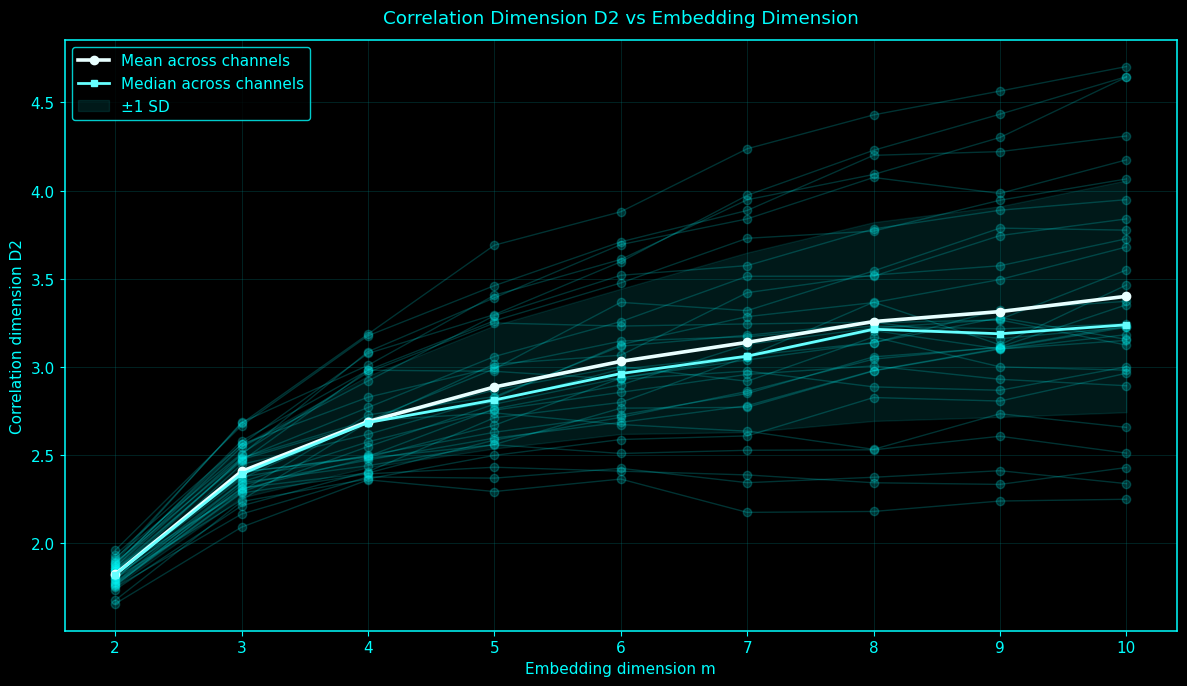


PLOT — Box-Counting Fractal Dimension vs Embedding Dimension

What you are seeing:
  - Each faint cyan line is one EEG channel tracked across embedding dimensions.
  - The x-axis is embedding dimension m.
  - The y-axis is box-counting fractal dimension.
  - The white line is the mean across channels.
  - The brighter cyan square line is the median across channels.
  - The shaded band shows approximately one standard deviation around the mean.
  - Box-counting dimension is based on how many grid boxes are needed to cover the embedded point cloud.

Patterns to look for:
  - Look for whether the mean and median increase as m increases.
  - Look for saturation: the curve rises at low m and then begins to flatten at higher m.
  - Look for non-saturation: the curve keeps rising strongly even at the largest m values.
  - Look for whether mean and median are close together; if they are close, the channel distribution is balanced.
  - Look for whether the mean is pulled above the median; this

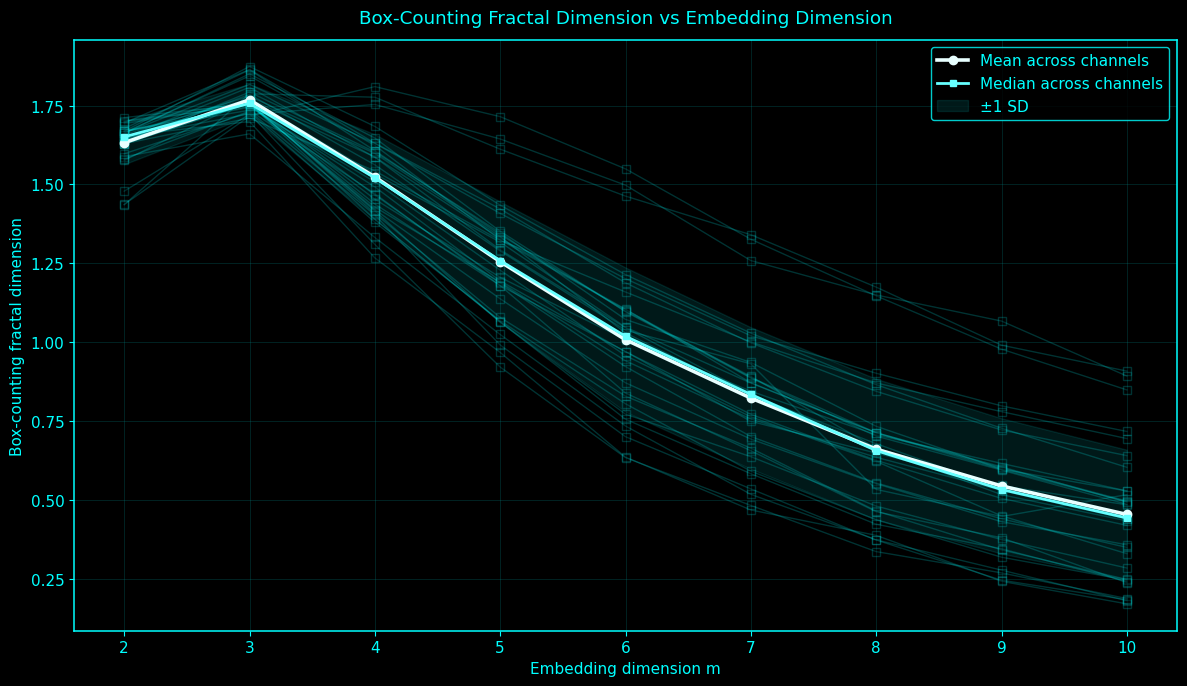


PLOT — Mean Embedded Fractal Dimensions Across Channels

What you are seeing:
  - This plot directly compares the two dimension estimators.
  - The cyan curve shows mean correlation dimension D2 across channels.
  - The white dashed curve shows mean box-counting dimension across channels.
  - Error bars show the standard deviation across channels.
  - The dotted diagonal line is the ambient dimension reference, where estimated dimension would equal embedding dimension m.

Patterns to look for:
  - Look for whether D2 and box-counting dimension tell the same broad story.
  - Look for whether one estimator is consistently higher than the other.
  - Look for whether either curve approaches a plateau at higher m.
  - Look for whether the estimates approach the ambient dimension line; this can mean the estimate is filling much of the available embedding space.
  - Look for whether the curves stay far below the ambient dimension line; this suggests lower-dimensional structure inside the emb

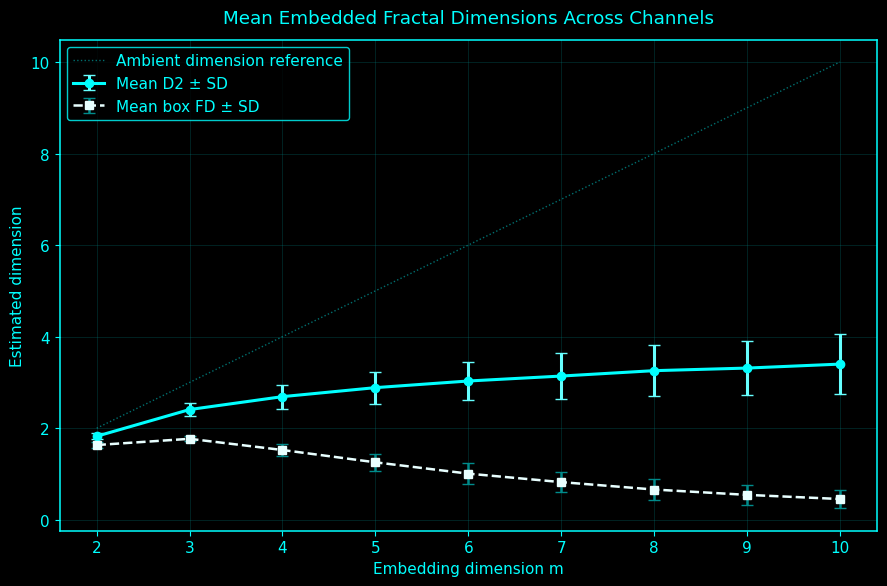


PLOT — Correlation Dimension D2 Heatmap

What you are seeing:
  - Each row is one EEG channel.
  - Each column is one embedding dimension m.
  - Each cell contains the correlation dimension D2 value for that channel and embedding dimension.
  - The cell color shows the relative magnitude of the dimension estimate.
  - The numerical value is printed inside each cell.
  - Rows are ordered using the largest available embedding dimension so high terminal-dimension channels are easier to see.

Patterns to look for:
  - Look for horizontal bright bands; these channels are high across many embedding dimensions.
  - Look for horizontal dark bands; these channels remain low across many embedding dimensions.
  - Look for vertical bright bands; many channels become higher at the same embedding dimension.
  - Look for gradual brightening from left to right; this means dimension increases with m.
  - Look for flattening from middle to right; this suggests possible saturation.
  - Look for sudden j

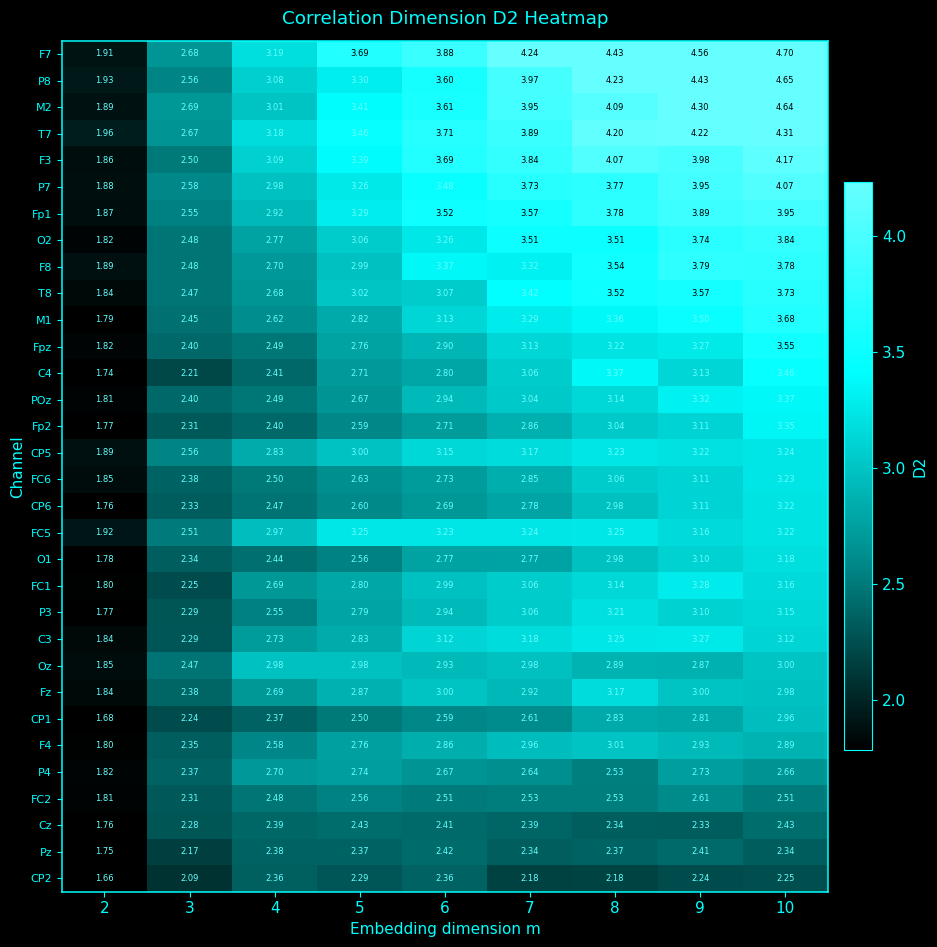


PLOT — Box-Counting Fractal Dimension Heatmap

What you are seeing:
  - Each row is one EEG channel.
  - Each column is one embedding dimension m.
  - Each cell contains the box-counting fractal dimension value for that channel and embedding dimension.
  - The cell color shows the relative magnitude of the dimension estimate.
  - The numerical value is printed inside each cell.
  - Rows are ordered using the largest available embedding dimension so high terminal-dimension channels are easier to see.

Patterns to look for:
  - Look for horizontal bright bands; these channels are high across many embedding dimensions.
  - Look for horizontal dark bands; these channels remain low across many embedding dimensions.
  - Look for vertical bright bands; many channels become higher at the same embedding dimension.
  - Look for gradual brightening from left to right; this means dimension increases with m.
  - Look for flattening from middle to right; this suggests possible saturation.
  - Look 

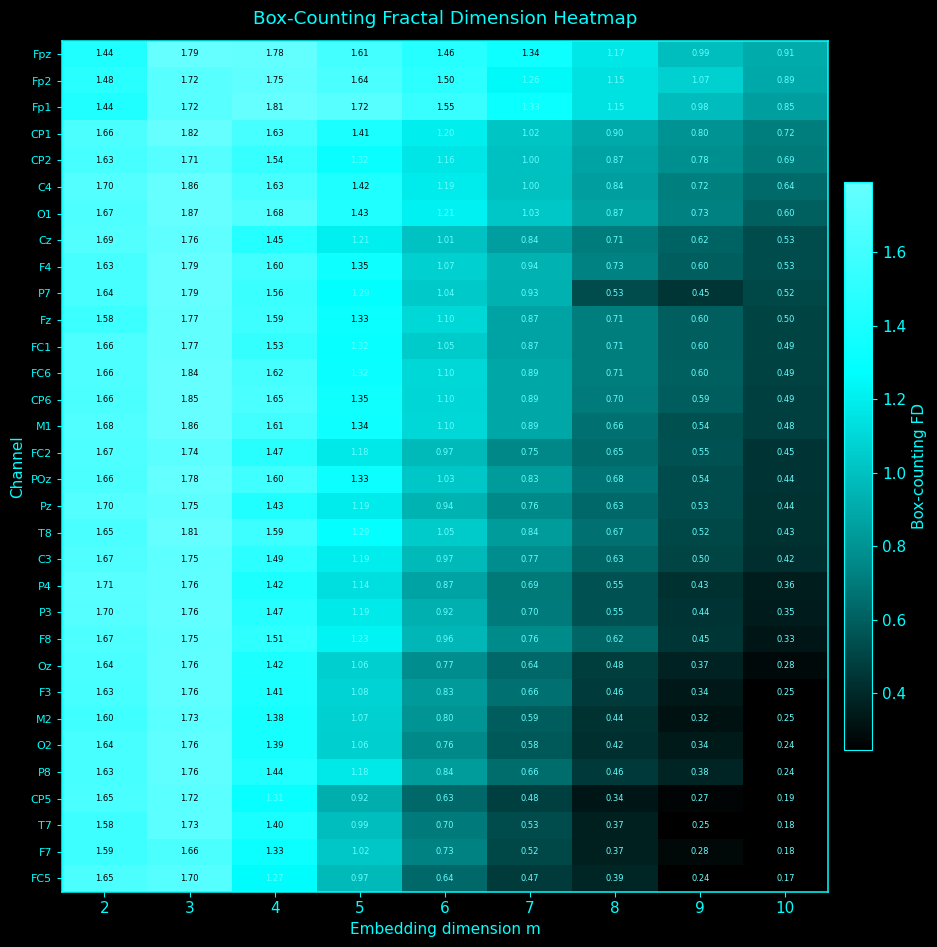


PLOT — Channel Ranking by Embedded Fractal-Dimension Complexity

What you are seeing:
  - Each horizontal bar is one EEG channel.
  - The x-axis is a composite dimension complexity score.
  - The score combines terminal D2, terminal box-counting dimension, D2 saturation behavior, and fit quality.
  - The text beside each bar shows terminal D2 and terminal box-counting dimension.
  - Only the highest-ranking channels are shown if many channels exist.

Patterns to look for:
  - Look for the channels with the longest bars; these are the strongest high-complexity candidates by the combined score.
  - Look for whether the top channels cluster anatomically, such as frontal, central, parietal, or occipital.
  - Look for a gradual ranking versus a sharp drop after the top few channels.
  - Look for channels where D2 is high but box-counting dimension is not high; this means the methods disagree.
  - Look for channels where both D2 and box-counting dimension are high; this is a stronger combin

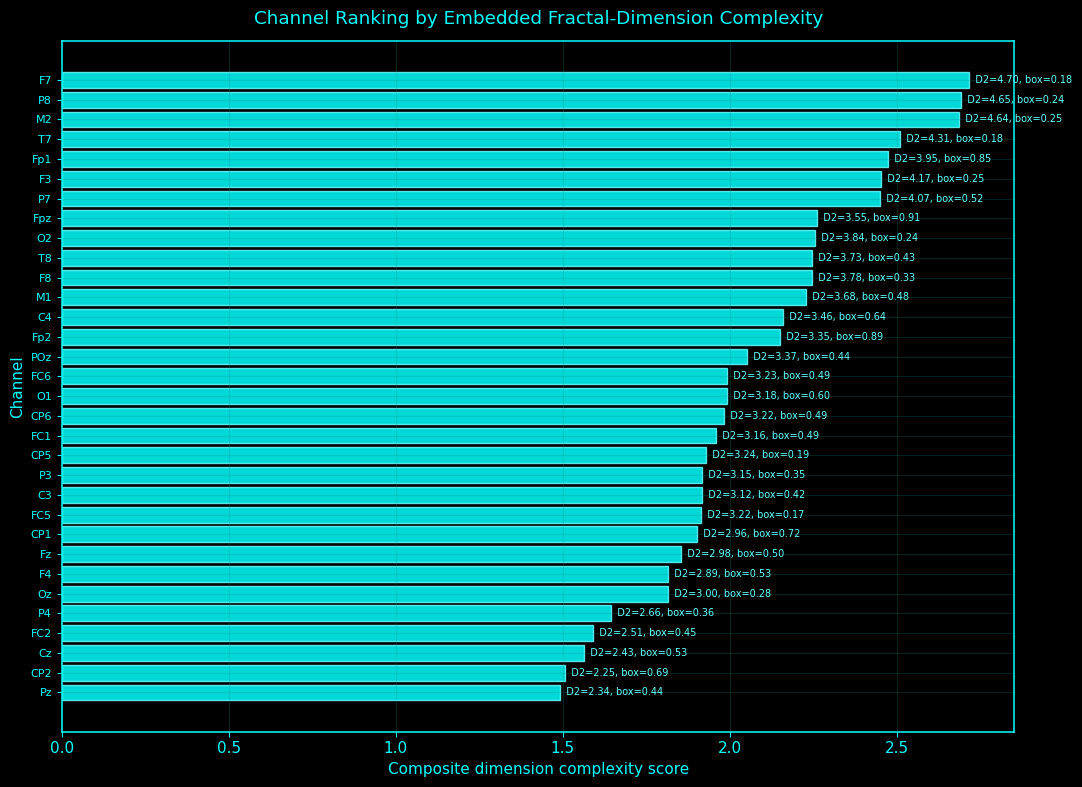


PLOT — Correlation Dimension versus Box-Counting Dimension

What you are seeing:
  - Each point is one channel at one embedding dimension.
  - The x-axis is box-counting fractal dimension.
  - The y-axis is correlation dimension D2.
  - Point size and color vary with embedding dimension m.
  - The dashed diagonal line marks where D2 and box-counting dimension would be equal.
  - Labels are added to some of the highest-D2 points.

Patterns to look for:
  - Look for points near the diagonal; this means the two estimators agree.
  - Look for points above the diagonal; D2 is larger than box-counting dimension.
  - Look for points below the diagonal; box-counting dimension is larger than D2.
  - Look for whether higher embedding dimensions move points upward and rightward.
  - Look for clusters of points; these indicate typical estimator relationships.
  - Look for isolated points far from the cloud; these may be unusual channels or unstable estimates.
  - Look for whether high-D2 labeled 

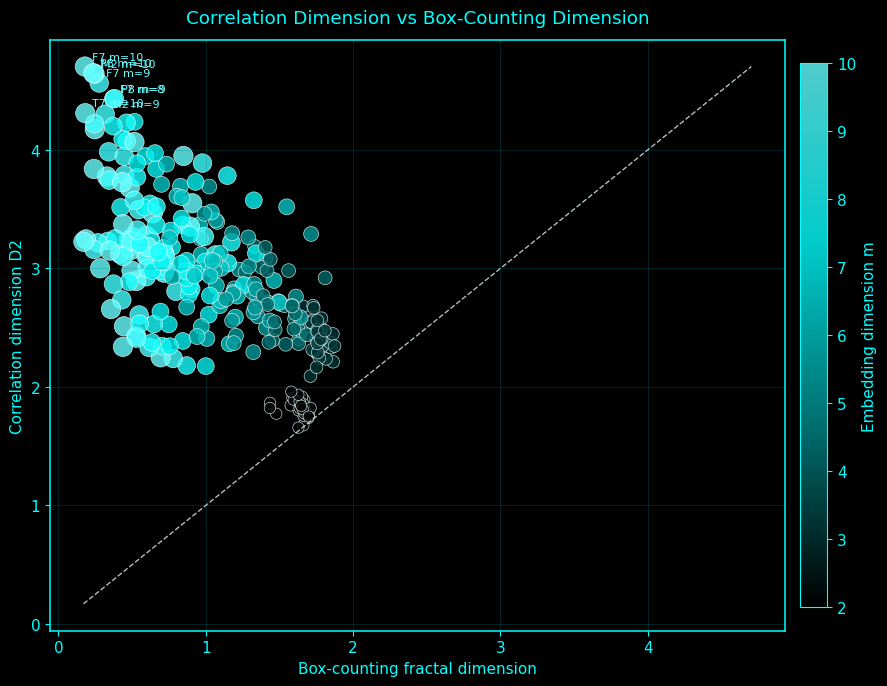


PLOT — Correlation-Dimension Saturation Diagnostic

What you are seeing:
  - Each point is one EEG channel.
  - The x-axis is terminal D2 at the largest available embedding dimension.
  - The y-axis is the tail slope of D2 versus embedding dimension.
  - The horizontal dashed line marks zero tail slope.
  - A tail slope near zero means D2 is flattening at high embedding dimensions.
  - A positive tail slope means D2 is still increasing at high embedding dimensions.

Patterns to look for:
  - Look for points near y=0; these channels show stronger evidence of saturation.
  - Look for high terminal D2 with low tail slope; these are strong high-complexity and more stable candidates.
  - Look for high terminal D2 with high positive tail slope; these are high but not clearly saturated.
  - Look for low terminal D2 with low tail slope; these may be simpler and stable.
  - Look for channels far above the horizontal line; they are still rising at high m.
  - Look for channels below zero; their

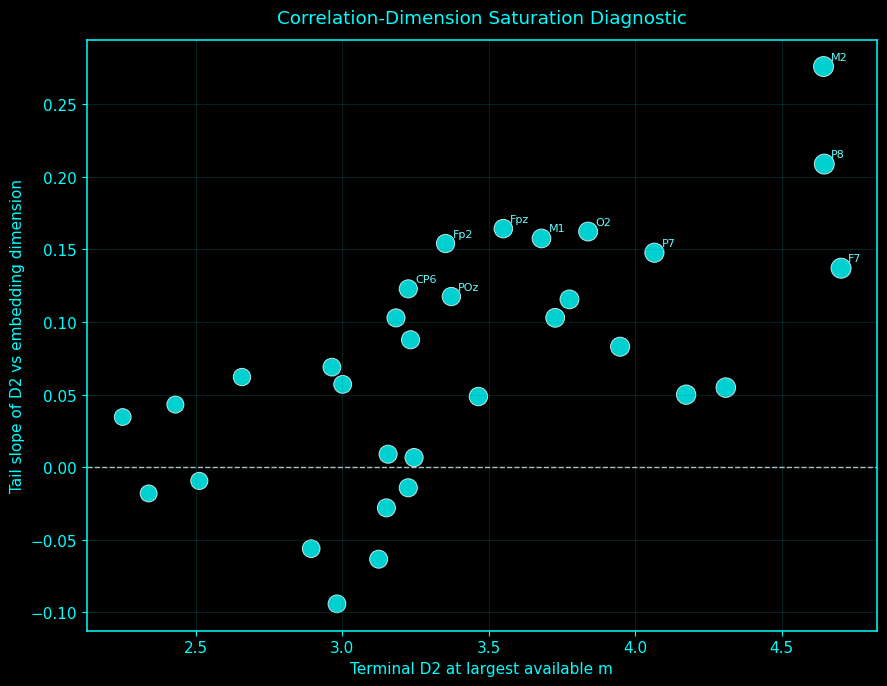


PLOT — Fractal-Dimension Fit Quality Control

What you are seeing:
  - Each point is one channel and embedding dimension.
  - Filled cyan points show correlation-dimension fit quality.
  - Open cyan points show box-counting fit quality.
  - The x-axis is the number of scale points used in the log-log fit.
  - The y-axis is the linear fit R².
  - The dashed horizontal line marks R² = 0.95 as a practical quality reference.

Patterns to look for:
  - Look for points above 0.95; these fits are usually more trustworthy.
  - Look for points below 0.95; these estimates should be interpreted more cautiously.
  - Look for whether correlation-dimension fits are generally better or worse than box-counting fits.
  - Look for estimates based on very few fitted scale points; these are less stable.
  - Look for clusters near R²=1; these indicate clean scaling behavior.
  - Look for low-R² outliers; these may identify problematic channels or embedding dimensions.
  - Look for whether fit quality chan

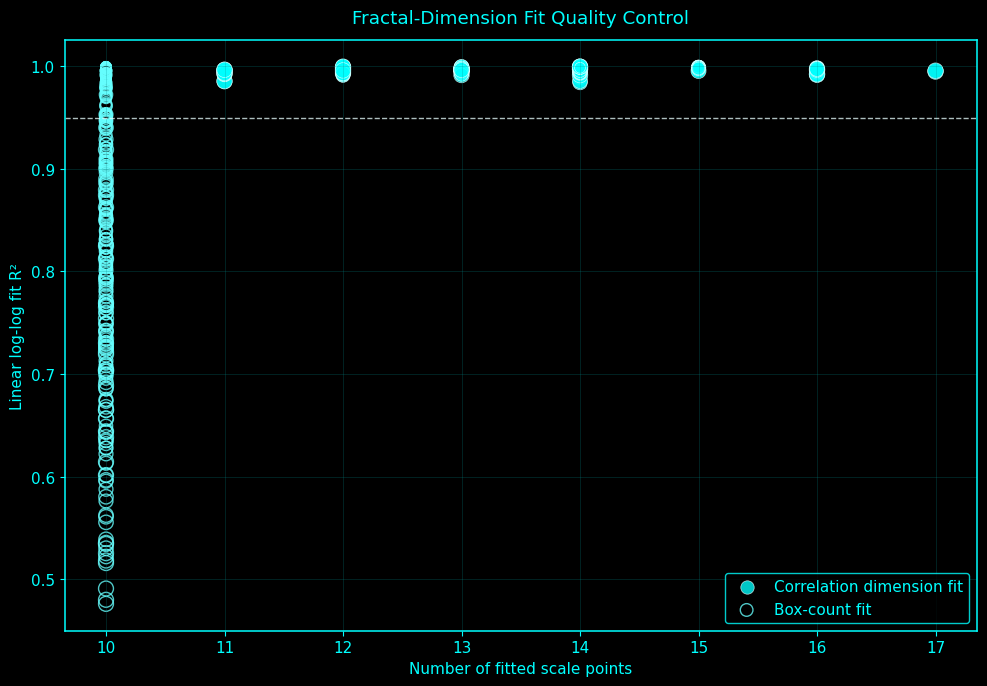


PLOT — Diagnostic Correlation-Dimension Fits

What you are seeing:
  - Each small panel shows one selected channel and embedding dimension.
  - The dots show log C(r) values across radius scales.
  - The white line is the linear fit used to estimate D2.
  - The title of each panel shows the channel, embedding dimension, D2, and R².
  - These panels show the actual scaling fit behind selected D2 estimates.

Patterns to look for:
  - Look for dots that form a clean straight line; this supports the D2 estimate.
  - Look for curved dot patterns; this means one linear scaling region may be too simple.
  - Look for one or two points far away from the fit line; these may distort the slope.
  - Look for very short fitted ranges; these estimates may be less stable.
  - Look for high D2 combined with high R²; this is a stronger result.
  - Look for high D2 combined with visible curvature; this should be interpreted cautiously.
  - Look for whether selected channels show similar fit shapes or ve

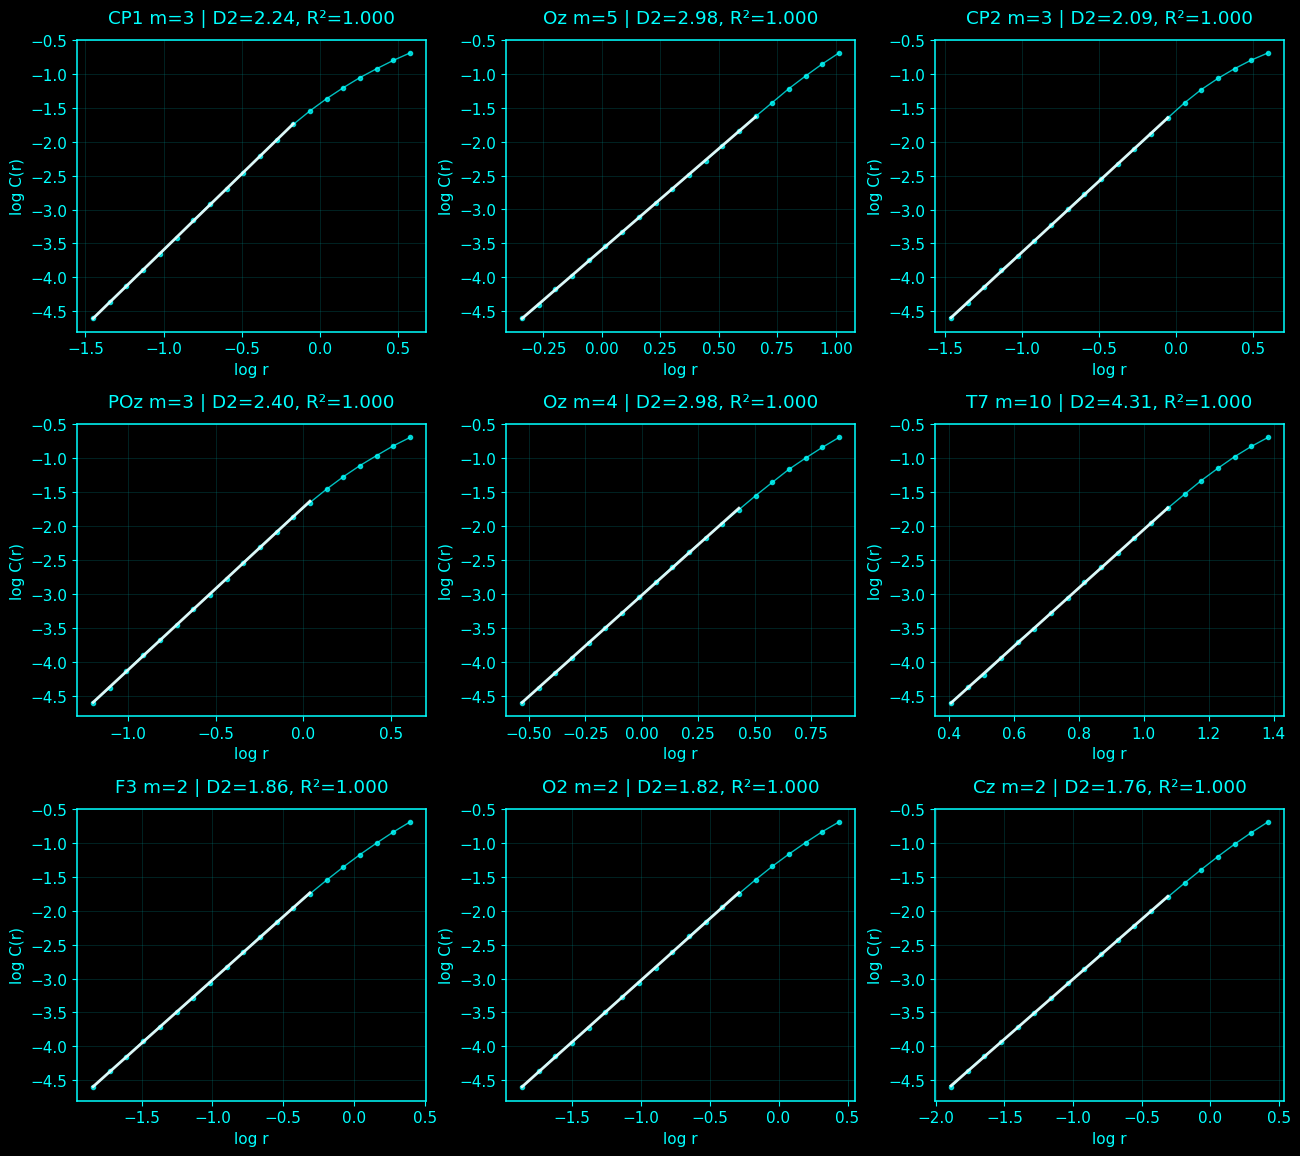


EMBEDDED FRACTAL-DIMENSION ANALYSIS SUMMARY
FAST_OPTION: fast
Rows computed: 288
Channels analyzed: 32
Embedding dimensions analyzed: [2, 3, 4, 5, 6, 7, 8, 9, 10]
Total elapsed: 0.25 min

Mean by embedding dimension:
 emb_dim  boxcount_fd  corr_dim_d2  box_fit_r2  corr_fit_r2  n_rows
       2     1.632627     1.824251    0.999180     0.999396      32
       3     1.768478     2.407601    0.986661     0.999070      32
       4     1.523920     2.689810    0.938307     0.997532      32
       5     1.255210     2.886203    0.886510     0.996594      32
       6     1.007825     3.031280    0.830615     0.995960      32
       7     0.822698     3.139275    0.791197     0.995561      32
       8     0.660688     3.257136    0.745537     0.995445      32
       9     0.543945     3.313587    0.709836     0.995679      32
      10     0.453580     3.400376    0.678858     0.995854      32

Top 15 channels by dimension complexity score:
channel  terminal_corr_dim_d2  terminal_boxcount_fd  d

# Interpretation of Embedded Fractal-Dimension Results

This report interprets the numerical results from the embedded EEG fractal-dimension analysis. The goal is to move from tables of numbers to clear conclusions about geometric complexity, estimator reliability, and saturation across embedding dimensions.

---

## 1. What was measured

Each EEG channel was represented as a reconstructed point cloud in embedding spaces of different dimension \(m\). For each channel and embedding dimension, the code estimated two related quantities: box-counting fractal dimension and sampled correlation dimension \(D_2\). Both try to describe how complicated the embedded point cloud is, but they do so in different ways.

- **Box-counting dimension** asks how many grid boxes are needed to cover the embedded point cloud as the grid becomes finer.
- **Correlation dimension \(D_2\)** asks how the fraction of nearby point pairs grows as the neighborhood radius increases.
- **Fit R²** tells us whether the log-log scaling relationship is clean enough to trust the estimate.
- **Tail slope** tells us whether the dimension estimate is stabilizing or still rising at high embedding dimensions.

---

## 2. Overall dimension level

**Correlation dimension \(D_2\) summary across all channel-dimension rows:**

- Mean D2: **2.8833**
- Median D2: **2.8643**
- Minimum D2: **1.6568**
- Maximum D2: **4.7028**
- Range: **3.0460**

**Interpretation:** The spread is large. Some channels appear substantially more complex than others, or some estimates may be influenced by instability or artifacts.

**Box-counting dimension summary across all channel-dimension rows:**

- Mean box-counting dimension: **1.0743**
- Median box-counting dimension: **1.0464**
- Minimum box-counting dimension: **0.1701**
- Maximum box-counting dimension: **1.8741**
- Range: **1.7040**

**Interpretation:** The spread is large. Some channels appear substantially more complex than others, or some estimates may be influenced by instability or artifacts.

A higher dimension means that the embedded attractor occupies the reconstruction space in a richer way. It does not mean the voltage is larger. It means the geometry of the reconstructed dynamics is more complex.

---

## 3. Fit quality: whether the estimates should be trusted

- Median correlation-dimension fit R²: **0.9973**
- Median box-counting fit R²: **0.8649**

**Correlation-dimension fit interpretation:** The median fit quality is very strong. The log-log scaling estimates are generally reliable, although individual low-R² cases should still be checked.

**Box-counting fit interpretation:** The median fit quality is weak. The analysis may need different scale ranges, more data, different preprocessing, or closer inspection of the diagnostic fits.

Lowest correlation-dimension fit-quality rows:

- **CP2**: emb_dim=8.0000, corr_dim_d2=2.1806, corr_fit_r2=0.9843, corr_fit_points=14.0000
- **C4**: emb_dim=9.0000, corr_dim_d2=3.1252, corr_fit_r2=0.9855, corr_fit_points=11.0000
- **C4**: emb_dim=10.0000, corr_dim_d2=3.4643, corr_fit_r2=0.9857, corr_fit_points=11.0000
- **CP2**: emb_dim=9.0000, corr_dim_d2=2.2397, corr_fit_r2=0.9859, corr_fit_points=14.0000
- **CP2**: emb_dim=7.0000, corr_dim_d2=2.1754, corr_fit_r2=0.9891, corr_fit_points=14.0000
- **CP6**: emb_dim=7.0000, corr_dim_d2=2.7803, corr_fit_r2=0.9913, corr_fit_points=12.0000
- **O1**: emb_dim=6.0000, corr_dim_d2=2.7662, corr_fit_r2=0.9915, corr_fit_points=12.0000
- **F4**: emb_dim=10.0000, corr_dim_d2=2.8934, corr_fit_r2=0.9916, corr_fit_points=14.0000

Lowest box-counting fit-quality rows:

- **F7**: emb_dim=10.0000, boxcount_fd=0.1800, box_fit_r2=0.4758, box_fit_points=10.0000
- **FC5**: emb_dim=10.0000, boxcount_fd=0.1701, box_fit_r2=0.4797, box_fit_points=10.0000
- **T7**: emb_dim=10.0000, boxcount_fd=0.1831, box_fit_r2=0.4907, box_fit_points=10.0000
- **M2**: emb_dim=10.0000, boxcount_fd=0.2453, box_fit_r2=0.5156, box_fit_points=10.0000
- **CP5**: emb_dim=10.0000, boxcount_fd=0.1869, box_fit_r2=0.5180, box_fit_points=10.0000
- **T7**: emb_dim=9.0000, boxcount_fd=0.2450, box_fit_r2=0.5220, box_fit_points=10.0000
- **O2**: emb_dim=10.0000, boxcount_fd=0.2408, box_fit_r2=0.5252, box_fit_points=10.0000
- **F7**: emb_dim=9.0000, boxcount_fd=0.2771, box_fit_r2=0.5301, box_fit_points=10.0000

Some high-D2 rows also have lower fit quality. These are not automatically wrong, but they should be inspected before being treated as strong findings:

- **C4**: emb_dim=10.0000, corr_dim_d2=3.4643, corr_fit_r2=0.9857, corr_fit_points=11.0000
- **T8**: emb_dim=7.0000, corr_dim_d2=3.4208, corr_fit_r2=0.9929, corr_fit_points=12.0000
- **O2**: emb_dim=6.0000, corr_dim_d2=3.2570, corr_fit_r2=0.9929, corr_fit_points=13.0000
- **O2**: emb_dim=7.0000, corr_dim_d2=3.5139, corr_fit_r2=0.9930, corr_fit_points=13.0000
- **T8**: emb_dim=8.0000, corr_dim_d2=3.5207, corr_fit_r2=0.9931, corr_fit_points=12.0000
- **M2**: emb_dim=10.0000, corr_dim_d2=4.6428, corr_fit_r2=0.9932, corr_fit_points=12.0000
- **Fp1**: emb_dim=8.0000, corr_dim_d2=3.7822, corr_fit_r2=0.9934, corr_fit_points=13.0000
- **M2**: emb_dim=6.0000, corr_dim_d2=3.6092, corr_fit_r2=0.9936, corr_fit_points=13.0000
- **F8**: emb_dim=8.0000, corr_dim_d2=3.5441, corr_fit_r2=0.9937, corr_fit_points=14.0000
- **Fp1**: emb_dim=6.0000, corr_dim_d2=3.5193, corr_fit_r2=0.9940, corr_fit_points=13.0000

The practical rule is: **dimension magnitude tells us what is interesting; fit quality tells us how much confidence to place in it.**

---

## 4. Saturation across embedding dimension

Saturation is one of the most important checks. If dimension keeps increasing strongly as \(m\) increases, then the estimate may not yet have found a stable intrinsic geometry. If dimension flattens at higher \(m\), the result is easier to interpret as a stable reconstructed complexity level.

- Mean D2 tail slope across the last available embedding dimensions: **0.0716**
- Mean box-counting tail slope across the last available embedding dimensions: **-0.1036**

**D2 saturation interpretation:** The tail slope is positive, suggesting that the dimension estimate is still rising at the highest embedding dimensions and has not clearly saturated.

**Box-counting saturation interpretation:** The tail slope is negative, suggesting that the terminal estimate decreases at the last embedding dimensions; this should be inspected for instability or estimation noise.

Channels with strongest terminal D2 and their saturation indicators:

- **F7**: terminal_corr_dim_d2=4.7028, d2_tail_slope=0.1371, terminal_corr_r2=0.9968, terminal_d2_over_m=0.4703
- **P8**: terminal_corr_dim_d2=4.6455, d2_tail_slope=0.2088, terminal_corr_r2=0.9970, terminal_d2_over_m=0.4645
- **M2**: terminal_corr_dim_d2=4.6428, d2_tail_slope=0.2759, terminal_corr_r2=0.9932, terminal_d2_over_m=0.4643
- **T7**: terminal_corr_dim_d2=4.3091, d2_tail_slope=0.0548, terminal_corr_r2=0.9999, terminal_d2_over_m=0.4309
- **F3**: terminal_corr_dim_d2=4.1738, d2_tail_slope=0.0500, terminal_corr_r2=0.9986, terminal_d2_over_m=0.4174
- **P7**: terminal_corr_dim_d2=4.0654, d2_tail_slope=0.1477, terminal_corr_r2=0.9998, terminal_d2_over_m=0.4065
- **Fp1**: terminal_corr_dim_d2=3.9482, d2_tail_slope=0.0830, terminal_corr_r2=0.9961, terminal_d2_over_m=0.3948
- **O2**: terminal_corr_dim_d2=3.8390, d2_tail_slope=0.1623, terminal_corr_r2=0.9970, terminal_d2_over_m=0.3839
- **F8**: terminal_corr_dim_d2=3.7753, d2_tail_slope=0.1156, terminal_corr_r2=0.9975, terminal_d2_over_m=0.3775
- **T8**: terminal_corr_dim_d2=3.7265, d2_tail_slope=0.1029, terminal_corr_r2=0.9961, terminal_d2_over_m=0.3726

Channels with strongest apparent saturation:

- **CP5**: terminal_corr_dim_d2=3.2447, d2_tail_slope=0.0066, terminal_corr_r2=0.9980
- **FC1**: terminal_corr_dim_d2=3.1560, d2_tail_slope=0.0090, terminal_corr_r2=0.9997
- **FC2**: terminal_corr_dim_d2=2.5113, d2_tail_slope=-0.0094, terminal_corr_r2=0.9950
- **FC5**: terminal_corr_dim_d2=3.2249, d2_tail_slope=-0.0142, terminal_corr_r2=0.9961
- **Pz**: terminal_corr_dim_d2=2.3383, d2_tail_slope=-0.0180, terminal_corr_r2=0.9959
- **P3**: terminal_corr_dim_d2=3.1502, d2_tail_slope=-0.0280, terminal_corr_r2=0.9996
- **CP2**: terminal_corr_dim_d2=2.2497, d2_tail_slope=0.0346, terminal_corr_r2=0.9917
- **Cz**: terminal_corr_dim_d2=2.4296, d2_tail_slope=0.0431, terminal_corr_r2=0.9929
- **C4**: terminal_corr_dim_d2=3.4643, d2_tail_slope=0.0487, terminal_corr_r2=0.9857
- **F3**: terminal_corr_dim_d2=4.1738, d2_tail_slope=0.0500, terminal_corr_r2=0.9986

A channel with high terminal D2 and a small tail slope is more convincing than a channel with high terminal D2 that is still rapidly rising with \(m\). The first looks more like a stable high-complexity attractor estimate. The second may simply need higher embedding dimensions or more data.

---

## 5. Agreement between box-counting dimension and D2

- Mean difference D2 minus box-counting dimension: **1.8089**
- Median absolute difference between the two methods: **1.8278**

D2 is higher than box-counting dimension on average. This means the pair-density scaling estimate is giving larger dimensions than the grid-coverage estimate.

Agreement between the two methods makes the interpretation stronger. Disagreement does not automatically invalidate the result, but it means the geometry is being seen differently by the two estimators.

---

## 6. Channel-level ranking

Top channels by composite dimension complexity score:

- **F7**: dimension_complexity_score=2.7175, terminal_corr_dim_d2=4.7028, terminal_boxcount_fd=0.1800, d2_tail_slope=0.1371, terminal_corr_r2=0.9968
- **P8**: dimension_complexity_score=2.6931, terminal_corr_dim_d2=4.6455, terminal_boxcount_fd=0.2371, d2_tail_slope=0.2088, terminal_corr_r2=0.9970
- **M2**: dimension_complexity_score=2.6866, terminal_corr_dim_d2=4.6428, terminal_boxcount_fd=0.2453, d2_tail_slope=0.2759, terminal_corr_r2=0.9932
- **T7**: dimension_complexity_score=2.5103, terminal_corr_dim_d2=4.3091, terminal_boxcount_fd=0.1831, d2_tail_slope=0.0548, terminal_corr_r2=0.9999
- **Fp1**: dimension_complexity_score=2.4750, terminal_corr_dim_d2=3.9482, terminal_boxcount_fd=0.8486, d2_tail_slope=0.0830, terminal_corr_r2=0.9961
- **F3**: dimension_complexity_score=2.4523, terminal_corr_dim_d2=4.1738, terminal_boxcount_fd=0.2474, d2_tail_slope=0.0500, terminal_corr_r2=0.9986
- **P7**: dimension_complexity_score=2.4503, terminal_corr_dim_d2=4.0654, terminal_boxcount_fd=0.5164, d2_tail_slope=0.1477, terminal_corr_r2=0.9998
- **Fpz**: dimension_complexity_score=2.2625, terminal_corr_dim_d2=3.5494, terminal_boxcount_fd=0.9083, d2_tail_slope=0.1643, terminal_corr_r2=0.9967
- **O2**: dimension_complexity_score=2.2551, terminal_corr_dim_d2=3.8390, terminal_boxcount_fd=0.2408, d2_tail_slope=0.1623, terminal_corr_r2=0.9970
- **T8**: dimension_complexity_score=2.2472, terminal_corr_dim_d2=3.7265, terminal_boxcount_fd=0.4333, d2_tail_slope=0.1029, terminal_corr_r2=0.9961
- **F8**: dimension_complexity_score=2.2469, terminal_corr_dim_d2=3.7753, terminal_boxcount_fd=0.3292, d2_tail_slope=0.1156, terminal_corr_r2=0.9975
- **M1**: dimension_complexity_score=2.2287, terminal_corr_dim_d2=3.6798, terminal_boxcount_fd=0.4842, d2_tail_slope=0.1576, terminal_corr_r2=0.9948

Top channels by terminal D2:

- **F7**: terminal_corr_dim_d2=4.7028, d2_tail_slope=0.1371, terminal_corr_r2=0.9968, terminal_d2_over_m=0.4703
- **P8**: terminal_corr_dim_d2=4.6455, d2_tail_slope=0.2088, terminal_corr_r2=0.9970, terminal_d2_over_m=0.4645
- **M2**: terminal_corr_dim_d2=4.6428, d2_tail_slope=0.2759, terminal_corr_r2=0.9932, terminal_d2_over_m=0.4643
- **T7**: terminal_corr_dim_d2=4.3091, d2_tail_slope=0.0548, terminal_corr_r2=0.9999, terminal_d2_over_m=0.4309
- **F3**: terminal_corr_dim_d2=4.1738, d2_tail_slope=0.0500, terminal_corr_r2=0.9986, terminal_d2_over_m=0.4174
- **P7**: terminal_corr_dim_d2=4.0654, d2_tail_slope=0.1477, terminal_corr_r2=0.9998, terminal_d2_over_m=0.4065
- **Fp1**: terminal_corr_dim_d2=3.9482, d2_tail_slope=0.0830, terminal_corr_r2=0.9961, terminal_d2_over_m=0.3948
- **O2**: terminal_corr_dim_d2=3.8390, d2_tail_slope=0.1623, terminal_corr_r2=0.9970, terminal_d2_over_m=0.3839
- **F8**: terminal_corr_dim_d2=3.7753, d2_tail_slope=0.1156, terminal_corr_r2=0.9975, terminal_d2_over_m=0.3775
- **T8**: terminal_corr_dim_d2=3.7265, d2_tail_slope=0.1029, terminal_corr_r2=0.9961, terminal_d2_over_m=0.3726
- **M1**: terminal_corr_dim_d2=3.6798, d2_tail_slope=0.1576, terminal_corr_r2=0.9948, terminal_d2_over_m=0.3680
- **Fpz**: terminal_corr_dim_d2=3.5494, d2_tail_slope=0.1643, terminal_corr_r2=0.9967, terminal_d2_over_m=0.3549

Top channels by terminal box-counting dimension:

- **Fpz**: terminal_boxcount_fd=0.9083, box_tail_slope=-0.1331, terminal_box_r2=0.8796
- **Fp2**: terminal_boxcount_fd=0.8926, box_tail_slope=-0.1286, terminal_box_r2=0.9188
- **Fp1**: terminal_boxcount_fd=0.8486, box_tail_slope=-0.1491, terminal_box_r2=0.8626
- **CP1**: terminal_boxcount_fd=0.7167, box_tail_slope=-0.0923, terminal_box_r2=0.8247
- **CP2**: terminal_boxcount_fd=0.6942, box_tail_slope=-0.0882, terminal_box_r2=0.8746
- **C4**: terminal_boxcount_fd=0.6402, box_tail_slope=-0.1020, terminal_box_r2=0.8123
- **O1**: terminal_boxcount_fd=0.6032, box_tail_slope=-0.1310, terminal_box_r2=0.7649
- **Cz**: terminal_boxcount_fd=0.5282, box_tail_slope=-0.0890, terminal_box_r2=0.7692
- **F4**: terminal_boxcount_fd=0.5279, box_tail_slope=-0.1027, terminal_box_r2=0.7213
- **P7**: terminal_boxcount_fd=0.5164, box_tail_slope=-0.0083, terminal_box_r2=0.6562
- **Fz**: terminal_boxcount_fd=0.4962, box_tail_slope=-0.1084, terminal_box_r2=0.7039
- **FC1**: terminal_boxcount_fd=0.4942, box_tail_slope=-0.1087, terminal_box_r2=0.7540

The highest-ranked channel by the composite score is **F7** (score=2.7175, terminal D2=4.7028, terminal box-counting dimension=0.1800).

A channel ranking is most useful when the same channels appear high by several criteria: high terminal D2, high terminal box-counting dimension, good R², and small tail slope. If a channel is high by only one criterion, it should be interpreted more cautiously.

---

## 7. What makes a result more convincing

The strongest conclusions are supported by several signs at once:

- The channel has high terminal D2.
- The channel also has high box-counting dimension.
- The log-log fit R² is high.
- The number of fitted scale points is not too small.
- The D2 curve begins to flatten at high embedding dimensions.
- The channel is not a single isolated outlier without support from nearby or related channels.
- The diagnostic fit plot looks approximately linear in log-log space.

Findings that need caution:

- High dimension with low R².
- High dimension based on very few fit points.
- Dimension that keeps rising strongly with embedding dimension.
- Strong disagreement between D2 and box-counting dimension.
- One channel far above all others without a clean diagnostic fit.
- Values close to the ambient dimension line without saturation.

---

## 8. Final synthesis

The most careful interpretation combines four questions. First, which channels have high embedded geometric complexity? Second, do the two estimators agree? Third, are the log-log fits reliable? Fourth, does the dimension stabilize as embedding dimension increases?

Based on the currently loaded results, the main high-complexity candidate by combined score is **F7**. The strongest high-D2 channel with saturation information is **F7**. The channel with one of the clearest near-flat D2 tails is **CP5**. 

The safest final conclusion is not simply that one channel is highest. The stronger conclusion is that a channel or region shows high embedded geometric complexity when high dimension, good fit quality, estimator agreement, and saturation all point in the same direction.

---

## 9. One-sentence takeaway

This analysis estimates how complex each EEG channel's reconstructed attractor is, and the most reliable findings are those where high dimension is supported by clean log-log fits, agreement between methods, and flattening across higher embedding dimensions.


In [9]:
import os
import time
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

try:
    from IPython.display import display, Markdown
    _HAVE_IPYTHON_DISPLAY = True
except Exception:
    display = None
    Markdown = None
    _HAVE_IPYTHON_DISPLAY = False

base_dir = "/home/a/projects/Complete-Neural-Signal-Analysis"

embedding_2d_dir = os.path.join(base_dir, "embedding_data", "2dembedding_data")
embedding_3d_dir = os.path.join(base_dir, "embedding_data", "3dembedding_data")
embedding_4to10_dir = os.path.join(base_dir, "embedding_data", "embeddings_4to10")

out_dir = os.path.join(base_dir, "embedded_fractal_dimension_research_fast")
plot_dir = os.path.join(out_dir, "plots_black_cyan")
diagnostic_dir = os.path.join(out_dir, "diagnostic_fit_plots")

os.makedirs(out_dir, exist_ok=True)
os.makedirs(plot_dir, exist_ok=True)
os.makedirs(diagnostic_dir, exist_ok=True)

FAST_OPTION = "fast"

if FAST_OPTION == "ultra":
    embedding_dims = [2, 3, 4, 6, 8, 10]
    max_channels = None
    max_points_per_embedding = 4000
    corr_subsample_n = 800
    corr_n_pairs = 25000
    corr_n_r = 16
    corr_cmin = 5e-4
    corr_cmax = 2e-1
    box_subsample_n = 2500
    box_eps = np.logspace(np.log10(1 / 5), np.log10(1 / 45), 8)
    save_diagnostic_fit_plots = True
    diagnostic_top_n = 6

elif FAST_OPTION == "fast":
    embedding_dims = list(range(2, 11))
    max_channels = None
    max_points_per_embedding = 7000
    corr_subsample_n = 1200
    corr_n_pairs = 60000
    corr_n_r = 20
    corr_cmin = 3e-4
    corr_cmax = 2e-1
    box_subsample_n = 4000
    box_eps = np.logspace(np.log10(1 / 5), np.log10(1 / 60), 10)
    save_diagnostic_fit_plots = True
    diagnostic_top_n = 9

elif FAST_OPTION == "balanced":
    embedding_dims = list(range(2, 11))
    max_channels = None
    max_points_per_embedding = 15000
    corr_subsample_n = 2500
    corr_n_pairs = 200000
    corr_n_r = 28
    corr_cmin = 1e-4
    corr_cmax = 1e-1
    box_subsample_n = 8000
    box_eps = np.logspace(np.log10(1 / 6), np.log10(1 / 80), 12)
    save_diagnostic_fit_plots = True
    diagnostic_top_n = 12

elif FAST_OPTION == "full":
    embedding_dims = list(range(2, 11))
    max_channels = None
    max_points_per_embedding = None
    corr_subsample_n = 5000
    corr_n_pairs = 500000
    corr_n_r = 36
    corr_cmin = 5e-5
    corr_cmax = 2e-1
    box_subsample_n = 15000
    box_eps = np.logspace(np.log10(1 / 6), np.log10(1 / 100), 16)
    save_diagnostic_fit_plots = True
    diagnostic_top_n = 16

else:
    raise ValueError("FAST_OPTION must be one of: 'ultra', 'fast', 'balanced', 'full'.")

RUN_BOXCOUNT = True
RUN_CORRELATION_DIMENSION = True
SHOW_PLOTS_IN_NOTEBOOK = True
SAVE_PLOTS_TO_DISK = True
RANDOM_SEED = 0

eeg_channel_names = [
    "Fp1", "Fpz", "Fp2", "F7", "F3", "Fz", "F4", "F8", "FC5", "FC1", "FC2", "FC6",
    "M1", "T7", "C3", "Cz", "C4", "T8", "M2", "CP5", "CP1", "CP2", "CP6",
    "P7", "P3", "Pz", "P4", "P8", "POz", "O1", "Oz", "O2"
]

if max_channels is not None:
    eeg_channel_names = eeg_channel_names[:max_channels]

ACCENT = "#00FFFF"
ACCENT_SOFT = "#66FFFF"
ACCENT_DIM = "#008B8B"
WHITE = "#E8FFFF"
BLACK = "#000000"

CYAN_DIVERGING_CMAP = LinearSegmentedColormap.from_list(
    "cyan_diverging",
    [ACCENT_DIM, BLACK, ACCENT_SOFT],
    N=256,
)

CYAN_SEQUENTIAL_CMAP = LinearSegmentedColormap.from_list(
    "cyan_sequential",
    [BLACK, ACCENT_DIM, ACCENT, ACCENT_SOFT],
    N=256,
)

plt.rcParams.update({
    "figure.facecolor": BLACK,
    "axes.facecolor": BLACK,
    "savefig.facecolor": BLACK,
    "text.color": ACCENT,
    "axes.labelcolor": ACCENT,
    "axes.edgecolor": ACCENT,
    "axes.titlecolor": ACCENT,
    "xtick.color": ACCENT,
    "ytick.color": ACCENT,
    "grid.color": ACCENT_DIM,
    "grid.alpha": 0.25,
    "legend.facecolor": BLACK,
    "legend.edgecolor": ACCENT,
    "legend.labelcolor": ACCENT,
    "font.size": 11,
})

rng = np.random.default_rng(RANDOM_SEED)

def style_ax(ax, title=None, xlabel=None, ylabel=None, grid=True):
    ax.set_facecolor(BLACK)
    for spine in ax.spines.values():
        spine.set_color(ACCENT)
        spine.set_linewidth(1.1)
    ax.tick_params(axis="x", colors=ACCENT, labelcolor=ACCENT)
    ax.tick_params(axis="y", colors=ACCENT, labelcolor=ACCENT)
    if title is not None:
        ax.set_title(title, color=ACCENT, pad=12)
    if xlabel is not None:
        ax.set_xlabel(xlabel, color=ACCENT)
    if ylabel is not None:
        ax.set_ylabel(ylabel, color=ACCENT)
    if grid:
        ax.grid(True, alpha=0.25, color=ACCENT_DIM, linewidth=0.7)
    else:
        ax.grid(False)

def save_fig(fig, path, show=True):
    fig.tight_layout()
    if SAVE_PLOTS_TO_DISK and path is not None:
        fig.savefig(path, dpi=220, bbox_inches="tight", facecolor=BLACK)
    if SHOW_PLOTS_IN_NOTEBOOK and show and _HAVE_IPYTHON_DISPLAY:
        display(fig)
    plt.close(fig)

def short_label(x, max_len=22):
    x = str(x)
    return x if len(x) <= max_len else x[:max_len - 1] + "…"

def embedding_path(channel_name, emb_dim):
    if emb_dim == 2:
        return os.path.join(embedding_2d_dir, f"2dembedded_{channel_name}.npy")
    if emb_dim == 3:
        return os.path.join(embedding_3d_dir, f"3dembedded_{channel_name}.npy")
    if 4 <= emb_dim <= 10:
        return os.path.join(embedding_4to10_dir, f"{emb_dim}dembedded_{channel_name}.npy")
    return None

def standardize_cols(X):
    X = np.asarray(X, dtype=float)
    X = np.where(np.isfinite(X), X, np.nan)
    col_mean = np.nanmean(X, axis=0, keepdims=True)
    bad = np.where(~np.isfinite(X))
    if bad[0].size > 0:
        X[bad] = np.take(col_mean, bad[1])
    mu = np.mean(X, axis=0, keepdims=True)
    sd = np.std(X, axis=0, keepdims=True) + 1e-12
    return (X - mu) / sd

def rescale_to_unit_cube(X):
    X = np.asarray(X, dtype=float)
    xmin = np.min(X, axis=0, keepdims=True)
    xmax = np.max(X, axis=0, keepdims=True)
    rngv = xmax - xmin
    rngv[rngv < 1e-12] = 1.0
    return (X - xmin) / rngv

def subsample_rows(X, max_points=None, rng=None):
    X = np.asarray(X)
    if rng is None:
        rng = np.random.default_rng()
    n = len(X)
    if max_points is None or n <= max_points:
        return X, np.arange(n)
    idx = np.sort(rng.choice(n, size=max_points, replace=False))
    return X[idx], idx

def linear_fit_r2(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    mask = np.isfinite(x) & np.isfinite(y)
    if np.sum(mask) < 3:
        return np.nan, np.array([np.nan, np.nan]), None
    x = x[mask]
    y = y[mask]
    coef = np.polyfit(x, y, 1)
    yhat = np.polyval(coef, x)
    ss_res = np.sum((y - yhat) ** 2)
    ss_tot = np.sum((y - np.mean(y)) ** 2)
    r2 = 1.0 - ss_res / (ss_tot + 1e-12)
    return float(r2), coef, yhat

def box_counting_dimension(X, eps_vals, max_points=None, rng=None):
    X = np.asarray(X, dtype=float)
    X, _ = subsample_rows(X, max_points=max_points, rng=rng)
    X = standardize_cols(X)
    X = rescale_to_unit_cube(X)

    counts = []
    inv_eps = []

    for eps in eps_vals:
        bins = np.floor(X / eps).astype(np.int64)
        bins = np.clip(bins, 0, int(np.ceil(1 / eps)) + 2)
        unique_boxes = np.unique(bins, axis=0)
        n_boxes = len(unique_boxes)

        if n_boxes > 0:
            counts.append(n_boxes)
            inv_eps.append(1.0 / eps)

    counts = np.asarray(counts, dtype=float)
    inv_eps = np.asarray(inv_eps, dtype=float)

    mask = np.isfinite(counts) & (counts > 0) & np.isfinite(inv_eps) & (inv_eps > 0)

    if np.sum(mask) < 3:
        return {
            "dimension": np.nan,
            "inv_eps": inv_eps,
            "counts": counts,
            "logx_fit": None,
            "logy_fit": None,
            "fit_line": None,
            "r2": np.nan,
            "n_fit": int(np.sum(mask)),
        }

    logx = np.log(inv_eps[mask])
    logy = np.log(counts[mask])

    r2, coef, fit_line = linear_fit_r2(logx, logy)

    return {
        "dimension": float(coef[0]),
        "inv_eps": inv_eps[mask],
        "counts": counts[mask],
        "logx_fit": logx,
        "logy_fit": logy,
        "fit_line": fit_line,
        "r2": r2,
        "n_fit": int(np.sum(mask)),
    }

def correlation_dimension_sampled(
    X,
    subsample_n=2500,
    n_pairs=200000,
    n_r=28,
    cmin=1e-4,
    cmax=1e-1,
    rng=None,
):
    if rng is None:
        rng = np.random.default_rng()

    X = np.asarray(X, dtype=float)
    X = standardize_cols(X)

    N = len(X)

    if N < 50:
        return {
            "dimension": np.nan,
            "rs": None,
            "Cs": None,
            "logr_fit": None,
            "logC_fit": None,
            "fit_line": None,
            "n_fit": 0,
            "r2": np.nan,
            "n_used": int(N),
            "n_pairs_used": 0,
        }

    if N > subsample_n:
        idx = np.sort(rng.choice(N, size=subsample_n, replace=False))
        X = X[idx]
        N = len(X)

    n_pairs_use = int(n_pairs)
    i = rng.integers(0, N, size=n_pairs_use)
    j = rng.integers(0, N, size=n_pairs_use)
    keep = i != j
    i = i[keep]
    j = j[keep]

    if len(i) < 1000:
        return {
            "dimension": np.nan,
            "rs": None,
            "Cs": None,
            "logr_fit": None,
            "logC_fit": None,
            "fit_line": None,
            "n_fit": 0,
            "r2": np.nan,
            "n_used": int(N),
            "n_pairs_used": int(len(i)),
        }

    d = np.linalg.norm(X[i] - X[j], axis=1)
    d = d[np.isfinite(d) & (d > 0)]

    if len(d) < 1000:
        return {
            "dimension": np.nan,
            "rs": None,
            "Cs": None,
            "logr_fit": None,
            "logC_fit": None,
            "fit_line": None,
            "n_fit": 0,
            "r2": np.nan,
            "n_used": int(N),
            "n_pairs_used": int(len(d)),
        }

    qlo = np.quantile(d, 0.01)
    qhi = np.quantile(d, 0.50)

    if not np.isfinite(qlo) or not np.isfinite(qhi) or qhi <= qlo:
        return {
            "dimension": np.nan,
            "rs": None,
            "Cs": None,
            "logr_fit": None,
            "logC_fit": None,
            "fit_line": None,
            "n_fit": 0,
            "r2": np.nan,
            "n_used": int(N),
            "n_pairs_used": int(len(d)),
        }

    rs = np.logspace(np.log10(qlo), np.log10(qhi), n_r)
    d_sorted = np.sort(d)
    Cs = np.searchsorted(d_sorted, rs, side="right") / len(d_sorted)

    mask = (
        np.isfinite(Cs)
        & (Cs > cmin)
        & (Cs < cmax)
        & np.isfinite(rs)
        & (rs > 0)
    )

    n_fit = int(np.sum(mask))

    if n_fit < 4:
        return {
            "dimension": np.nan,
            "rs": rs,
            "Cs": Cs,
            "logr_fit": None,
            "logC_fit": None,
            "fit_line": None,
            "n_fit": n_fit,
            "r2": np.nan,
            "n_used": int(N),
            "n_pairs_used": int(len(d)),
        }

    log_r = np.log(rs[mask])
    log_C = np.log(Cs[mask])

    r2, coef, fit_line = linear_fit_r2(log_r, log_C)

    return {
        "dimension": float(coef[0]),
        "rs": rs,
        "Cs": Cs,
        "logr_fit": log_r,
        "logC_fit": log_C,
        "fit_line": fit_line,
        "n_fit": n_fit,
        "r2": r2,
        "n_used": int(N),
        "n_pairs_used": int(len(d)),
    }

def add_derived_metrics(results_df):
    df = results_df.copy()

    df["d2_minus_boxfd"] = df["corr_dim_d2"] - df["boxcount_fd"]
    df["d2_over_emb_dim"] = df["corr_dim_d2"] / df["emb_dim"]
    df["boxfd_over_emb_dim"] = df["boxcount_fd"] / df["emb_dim"]

    rows = []

    for channel, sub in df.groupby("channel"):
        sub = sub.sort_values("emb_dim").copy()

        if len(sub) >= 2:
            sub["corr_dim_d2_increment"] = sub["corr_dim_d2"].diff()
            sub["boxcount_fd_increment"] = sub["boxcount_fd"].diff()
        else:
            sub["corr_dim_d2_increment"] = np.nan
            sub["boxcount_fd_increment"] = np.nan

        rows.append(sub)

    if len(rows):
        df = pd.concat(rows, ignore_index=True)

    channel_rows = []

    for channel, sub in df.groupby("channel"):
        sub = sub.sort_values("emb_dim")
        valid_d2 = sub[np.isfinite(sub["corr_dim_d2"])]
        valid_box = sub[np.isfinite(sub["boxcount_fd"])]

        row = {"channel": channel}

        if len(valid_d2):
            last_d2 = valid_d2.iloc[-1]
            row["max_available_emb_dim"] = int(last_d2["emb_dim"])
            row["terminal_corr_dim_d2"] = float(last_d2["corr_dim_d2"])
            row["terminal_corr_r2"] = float(last_d2["corr_fit_r2"])
            row["terminal_corr_fit_points"] = int(last_d2["corr_fit_points"])
            row["terminal_d2_over_m"] = float(last_d2["d2_over_emb_dim"])
        else:
            row["max_available_emb_dim"] = np.nan
            row["terminal_corr_dim_d2"] = np.nan
            row["terminal_corr_r2"] = np.nan
            row["terminal_corr_fit_points"] = np.nan
            row["terminal_d2_over_m"] = np.nan

        if len(valid_box):
            last_box = valid_box.iloc[-1]
            row["terminal_boxcount_fd"] = float(last_box["boxcount_fd"])
            row["terminal_box_r2"] = float(last_box["box_fit_r2"])
        else:
            row["terminal_boxcount_fd"] = np.nan
            row["terminal_box_r2"] = np.nan

        if len(valid_d2) >= 3:
            tail = valid_d2.tail(3)
            row["d2_tail_slope"] = float(np.polyfit(tail["emb_dim"], tail["corr_dim_d2"], 1)[0])
            row["d2_tail_std"] = float(np.nanstd(tail["corr_dim_d2"]))
        else:
            row["d2_tail_slope"] = np.nan
            row["d2_tail_std"] = np.nan

        if len(valid_box) >= 3:
            tail = valid_box.tail(3)
            row["box_tail_slope"] = float(np.polyfit(tail["emb_dim"], tail["boxcount_fd"], 1)[0])
            row["box_tail_std"] = float(np.nanstd(tail["boxcount_fd"]))
        else:
            row["box_tail_slope"] = np.nan
            row["box_tail_std"] = np.nan

        row["dimension_complexity_score"] = (
            0.55 * row.get("terminal_corr_dim_d2", np.nan)
            + 0.25 * row.get("terminal_boxcount_fd", np.nan)
            - 0.10 * abs(row.get("d2_tail_slope", 0.0) if np.isfinite(row.get("d2_tail_slope", np.nan)) else 0.0)
            + 0.10 * row.get("terminal_corr_r2", np.nan)
        )

        channel_rows.append(row)

    channel_summary = pd.DataFrame(channel_rows)

    return df, channel_summary

def print_plot_description(title, what_you_see, patterns_to_look_for, cautions=None):
    print("\n" + "=" * 92)
    print(title)
    print("=" * 92)
    print("\nWhat you are seeing:")
    for item in what_you_see:
        print(f"  - {item}")
    print("\nPatterns to look for:")
    for item in patterns_to_look_for:
        print(f"  - {item}")
    if cautions:
        print("\nCautions:")
        for item in cautions:
            print(f"  - {item}")
    print("=" * 92 + "\n")

def plot_dimension_curves(results_df, value_col, ylabel, title, filename, marker="o"):
    if value_col == "corr_dim_d2":
        plot_name = "Correlation Dimension D2 vs Embedding Dimension"
        metric_name = "correlation dimension D2"
        method_note = "D2 is based on how the fraction of nearby point pairs grows as radius increases."
    else:
        plot_name = "Box-Counting Fractal Dimension vs Embedding Dimension"
        metric_name = "box-counting fractal dimension"
        method_note = "Box-counting dimension is based on how many grid boxes are needed to cover the embedded point cloud."

    print_plot_description(
        title=f"PLOT — {plot_name}",
        what_you_see=[
            "Each faint cyan line is one EEG channel tracked across embedding dimensions.",
            "The x-axis is embedding dimension m.",
            f"The y-axis is {metric_name}.",
            "The white line is the mean across channels.",
            "The brighter cyan square line is the median across channels.",
            "The shaded band shows approximately one standard deviation around the mean.",
            method_note,
        ],
        patterns_to_look_for=[
            "Look for whether the mean and median increase as m increases.",
            "Look for saturation: the curve rises at low m and then begins to flatten at higher m.",
            "Look for non-saturation: the curve keeps rising strongly even at the largest m values.",
            "Look for whether mean and median are close together; if they are close, the channel distribution is balanced.",
            "Look for whether the mean is pulled above the median; this suggests some high-dimension channels are pulling the average upward.",
            "Look for wide shaded bands; this means channels differ strongly from each other.",
            "Look for narrow shaded bands; this means channels behave similarly across embedding dimensions.",
            "Look for crossing or diverging individual lines; this means channel ranking changes with embedding dimension.",
            "Look for channels that rise faster than the rest; these may have more complex embedded geometry.",
            "Look for channels that stay low across all m; these may have simpler embedded geometry.",
        ],
        cautions=[
            "A dimension estimate that keeps rising with m may not represent a stable intrinsic dimension yet.",
            "Large spread across channels can be meaningful, but it can also reflect noise, uneven embedding quality, or fit instability.",
            "Always compare this plot with the fit-quality plot and the saturation diagnostic.",
        ],
    )

    fig, ax = plt.subplots(figsize=(12, 7))

    for channel_name in eeg_channel_names:
        sub = results_df[results_df["channel"] == channel_name].sort_values("emb_dim")
        sub = sub[np.isfinite(sub[value_col])]

        if len(sub) == 0:
            continue

        ax.plot(
            sub["emb_dim"],
            sub[value_col],
            marker=marker,
            color=ACCENT,
            markerfacecolor=ACCENT if marker == "o" else BLACK,
            markeredgecolor=ACCENT,
            alpha=0.20,
            linewidth=1.0,
        )

    grouped = (
        results_df.groupby("emb_dim")[value_col]
        .agg(["mean", "median", "std", "count"])
        .reset_index()
    )

    grouped = grouped[np.isfinite(grouped["mean"])]

    if len(grouped):
        print("Mean and median by embedding dimension:")
        print(grouped.to_string(index=False))

        ax.plot(
            grouped["emb_dim"],
            grouped["mean"],
            color=WHITE,
            marker="o",
            linewidth=2.6,
            markersize=6,
            label="Mean across channels",
        )

        ax.plot(
            grouped["emb_dim"],
            grouped["median"],
            color=ACCENT_SOFT,
            marker="s",
            linewidth=2.0,
            markersize=5,
            label="Median across channels",
        )

        ax.fill_between(
            grouped["emb_dim"],
            grouped["mean"] - grouped["std"],
            grouped["mean"] + grouped["std"],
            color=ACCENT,
            alpha=0.10,
            label="±1 SD",
        )

    style_ax(
        ax,
        title=title,
        xlabel="Embedding dimension m",
        ylabel=ylabel,
    )

    leg = ax.legend(loc="best", frameon=True)
    for text in leg.get_texts():
        text.set_color(ACCENT)

    path = os.path.join(plot_dir, filename)
    save_fig(fig, path)
    return path

def plot_mean_dimensions(results_df):
    print_plot_description(
        title="PLOT — Mean Embedded Fractal Dimensions Across Channels",
        what_you_see=[
            "This plot directly compares the two dimension estimators.",
            "The cyan curve shows mean correlation dimension D2 across channels.",
            "The white dashed curve shows mean box-counting dimension across channels.",
            "Error bars show the standard deviation across channels.",
            "The dotted diagonal line is the ambient dimension reference, where estimated dimension would equal embedding dimension m.",
        ],
        patterns_to_look_for=[
            "Look for whether D2 and box-counting dimension tell the same broad story.",
            "Look for whether one estimator is consistently higher than the other.",
            "Look for whether either curve approaches a plateau at higher m.",
            "Look for whether the estimates approach the ambient dimension line; this can mean the estimate is filling much of the available embedding space.",
            "Look for whether the curves stay far below the ambient dimension line; this suggests lower-dimensional structure inside the embedding space.",
            "Look for large error bars at certain m values; this means channel-to-channel variability is high.",
            "Look for small error bars; this means channels agree more strongly.",
            "Look for divergence between D2 and box-counting dimension at high m.",
            "Look for a stable gap between the methods; this may reflect that the two estimators are measuring related but not identical geometric properties.",
        ],
        cautions=[
            "The ambient dimension line is a reference, not a target.",
            "Higher dimension is not automatically better; it means the embedded attractor occupies space in a more complex way.",
            "If both estimates rise almost linearly with m, saturation is not yet clear.",
        ],
    )

    grouped = (
        results_df.groupby("emb_dim")
        .agg(
            box_mean=("boxcount_fd", "mean"),
            box_std=("boxcount_fd", "std"),
            d2_mean=("corr_dim_d2", "mean"),
            d2_std=("corr_dim_d2", "std"),
            n=("channel", "count"),
        )
        .reset_index()
    )

    print("Mean dimension comparison by embedding dimension:")
    print(grouped.to_string(index=False))

    fig, ax = plt.subplots(figsize=(9, 6))

    ax.errorbar(
        grouped["emb_dim"],
        grouped["d2_mean"],
        yerr=grouped["d2_std"],
        marker="o",
        color=ACCENT,
        ecolor=ACCENT_SOFT,
        linewidth=2.2,
        capsize=4,
        label="Mean D2 ± SD",
    )

    ax.errorbar(
        grouped["emb_dim"],
        grouped["box_mean"],
        yerr=grouped["box_std"],
        marker="s",
        color=WHITE,
        ecolor=ACCENT_DIM,
        linewidth=1.8,
        capsize=4,
        linestyle="--",
        label="Mean box FD ± SD",
    )

    ax.plot(
        grouped["emb_dim"],
        grouped["emb_dim"],
        color=ACCENT_DIM,
        linestyle=":",
        linewidth=1.0,
        alpha=0.8,
        label="Ambient dimension reference",
    )

    style_ax(
        ax,
        title="Mean Embedded Fractal Dimensions Across Channels",
        xlabel="Embedding dimension m",
        ylabel="Estimated dimension",
    )

    leg = ax.legend(loc="best", frameon=True)
    for text in leg.get_texts():
        text.set_color(ACCENT)

    path = os.path.join(plot_dir, "03_mean_embedded_fractal_dimensions_black_cyan.png")
    save_fig(fig, path)
    return path

def plot_heatmap(results_df, value_col, title, filename, color_label):
    if value_col == "corr_dim_d2":
        metric_name = "correlation dimension D2"
    else:
        metric_name = "box-counting fractal dimension"

    print_plot_description(
        title=f"PLOT — {title}",
        what_you_see=[
            "Each row is one EEG channel.",
            "Each column is one embedding dimension m.",
            f"Each cell contains the {metric_name} value for that channel and embedding dimension.",
            "The cell color shows the relative magnitude of the dimension estimate.",
            "The numerical value is printed inside each cell.",
            "Rows are ordered using the largest available embedding dimension so high terminal-dimension channels are easier to see.",
        ],
        patterns_to_look_for=[
            "Look for horizontal bright bands; these channels are high across many embedding dimensions.",
            "Look for horizontal dark bands; these channels remain low across many embedding dimensions.",
            "Look for vertical bright bands; many channels become higher at the same embedding dimension.",
            "Look for gradual brightening from left to right; this means dimension increases with m.",
            "Look for flattening from middle to right; this suggests possible saturation.",
            "Look for sudden jumps in one channel at one m; this may reflect instability or a fit problem.",
            "Look for channels whose ranking changes strongly as m increases.",
            "Look for groups of neighboring EEG channels that share similar patterns.",
            "Look for missing or blank cells; these indicate unavailable or invalid estimates.",
        ],
        cautions=[
            "Heatmap color is scaled using percentiles, so color shows relative differences inside this plot.",
            "A bright cell should be checked against fit quality before being interpreted strongly.",
            "A stable pattern across several m values is more meaningful than one isolated bright cell.",
        ],
    )

    pivot = results_df.pivot_table(
        index="channel",
        columns="emb_dim",
        values=value_col,
        aggfunc="mean",
    )

    if pivot.empty:
        return None

    if pivot.shape[1] > 0:
        last_col = pivot.columns.max()
        channel_order = pivot.sort_values(last_col, ascending=False).index.tolist()
    else:
        channel_order = pivot.index.tolist()

    pivot = pivot.loc[channel_order]
    M = pivot.to_numpy(dtype=float)

    print("Top rows in heatmap order:")
    print(pivot.head(10).to_string())

    fig_height = min(10.5, max(7.0, 0.30 * len(pivot.index)))
    fig, ax = plt.subplots(figsize=(9.5, fig_height))

    finite = M[np.isfinite(M)]
    if finite.size:
        vmin = np.nanpercentile(finite, 3)
        vmax = np.nanpercentile(finite, 97)
    else:
        vmin, vmax = 0, 1

    if not np.isfinite(vmin) or not np.isfinite(vmax) or vmax <= vmin:
        vmin, vmax = 0, 1

    im = ax.imshow(
        M,
        aspect="auto",
        interpolation="nearest",
        cmap=CYAN_SEQUENTIAL_CMAP,
        vmin=vmin,
        vmax=vmax,
    )

    ax.set_xticks(np.arange(len(pivot.columns)))
    ax.set_xticklabels(pivot.columns, color=ACCENT)

    ax.set_yticks(np.arange(len(pivot.index)))
    ax.set_yticklabels(pivot.index, color=ACCENT, fontsize=8)

    for i in range(M.shape[0]):
        for j in range(M.shape[1]):
            val = M[i, j]
            if np.isfinite(val):
                ax.text(
                    j,
                    i,
                    f"{val:.2f}",
                    ha="center",
                    va="center",
                    fontsize=6,
                    color=BLACK if val > (vmin + 0.70 * (vmax - vmin)) else ACCENT_SOFT,
                )

    style_ax(
        ax,
        title=title,
        xlabel="Embedding dimension m",
        ylabel="Channel",
        grid=False,
    )

    cbar = fig.colorbar(im, ax=ax, fraction=0.035, pad=0.02)
    cbar.ax.yaxis.set_tick_params(color=ACCENT)
    plt.setp(cbar.ax.get_yticklabels(), color=ACCENT)
    cbar.outline.set_edgecolor(ACCENT)
    cbar.set_label(color_label, color=ACCENT)

    path = os.path.join(plot_dir, filename)
    save_fig(fig, path)
    return path

def plot_terminal_dimension_ranking(channel_summary):
    print_plot_description(
        title="PLOT — Channel Ranking by Embedded Fractal-Dimension Complexity",
        what_you_see=[
            "Each horizontal bar is one EEG channel.",
            "The x-axis is a composite dimension complexity score.",
            "The score combines terminal D2, terminal box-counting dimension, D2 saturation behavior, and fit quality.",
            "The text beside each bar shows terminal D2 and terminal box-counting dimension.",
            "Only the highest-ranking channels are shown if many channels exist.",
        ],
        patterns_to_look_for=[
            "Look for the channels with the longest bars; these are the strongest high-complexity candidates by the combined score.",
            "Look for whether the top channels cluster anatomically, such as frontal, central, parietal, or occipital.",
            "Look for a gradual ranking versus a sharp drop after the top few channels.",
            "Look for channels where D2 is high but box-counting dimension is not high; this means the methods disagree.",
            "Look for channels where both D2 and box-counting dimension are high; this is a stronger combined signal.",
            "Look for whether the top channels also have low tail slope in the summary table; that supports saturation.",
            "Look for whether the ranking is dominated by one or two isolated channels.",
        ],
        cautions=[
            "The composite score is a practical ranking tool, not a fundamental physical constant.",
            "A top-ranked channel should still be checked for fit quality and saturation.",
            "If one channel is far above all others, inspect it for artifacts or unusual embedding behavior.",
        ],
    )

    df = channel_summary.copy()
    df = df[np.isfinite(df["dimension_complexity_score"])]

    if df.empty:
        return None

    print("Top channels by composite score:")
    cols = [
        "channel",
        "terminal_corr_dim_d2",
        "terminal_boxcount_fd",
        "d2_tail_slope",
        "terminal_corr_r2",
        "dimension_complexity_score",
    ]
    cols = [c for c in cols if c in df.columns]
    print(df.sort_values("dimension_complexity_score", ascending=False)[cols].head(15).to_string(index=False))

    df = df.sort_values("dimension_complexity_score", ascending=False)
    df_plot = df.head(32).sort_values("dimension_complexity_score", ascending=True)

    fig, ax = plt.subplots(figsize=(11, 8))
    y = np.arange(len(df_plot))

    ax.barh(
        y,
        df_plot["dimension_complexity_score"],
        color=ACCENT,
        edgecolor=ACCENT_SOFT,
        alpha=0.85,
    )

    ax.set_yticks(y)
    ax.set_yticklabels(df_plot["channel"], color=ACCENT, fontsize=8)

    for yi, (_, row) in zip(y, df_plot.iterrows()):
        ax.text(
            row["dimension_complexity_score"],
            yi,
            f"  D2={row['terminal_corr_dim_d2']:.2f}, box={row['terminal_boxcount_fd']:.2f}",
            va="center",
            ha="left",
            color=ACCENT_SOFT,
            fontsize=7,
        )

    style_ax(
        ax,
        title="Channel Ranking by Embedded Fractal-Dimension Complexity",
        xlabel="Composite dimension complexity score",
        ylabel="Channel",
    )

    path = os.path.join(plot_dir, "06_channel_dimension_complexity_ranking_black_cyan.png")
    save_fig(fig, path)
    return path

def plot_d2_vs_box_scatter(results_df):
    print_plot_description(
        title="PLOT — Correlation Dimension versus Box-Counting Dimension",
        what_you_see=[
            "Each point is one channel at one embedding dimension.",
            "The x-axis is box-counting fractal dimension.",
            "The y-axis is correlation dimension D2.",
            "Point size and color vary with embedding dimension m.",
            "The dashed diagonal line marks where D2 and box-counting dimension would be equal.",
            "Labels are added to some of the highest-D2 points.",
        ],
        patterns_to_look_for=[
            "Look for points near the diagonal; this means the two estimators agree.",
            "Look for points above the diagonal; D2 is larger than box-counting dimension.",
            "Look for points below the diagonal; box-counting dimension is larger than D2.",
            "Look for whether higher embedding dimensions move points upward and rightward.",
            "Look for clusters of points; these indicate typical estimator relationships.",
            "Look for isolated points far from the cloud; these may be unusual channels or unstable estimates.",
            "Look for whether high-D2 labeled points also have high box-counting values.",
            "Look for systematic disagreement between the two methods.",
        ],
        cautions=[
            "D2 and box-counting dimension are related but not identical estimators.",
            "Disagreement between methods does not automatically mean failure, but it should be investigated.",
            "Outliers should be checked against fit quality and diagnostic curves.",
        ],
    )

    df = results_df.copy()
    df = df[np.isfinite(df["corr_dim_d2"]) & np.isfinite(df["boxcount_fd"])]

    if df.empty:
        return None

    print("Largest D2 values with corresponding box-counting values:")
    print(df.sort_values("corr_dim_d2", ascending=False)[["channel", "emb_dim", "corr_dim_d2", "boxcount_fd", "corr_fit_r2", "box_fit_r2"]].head(12).to_string(index=False))

    fig, ax = plt.subplots(figsize=(9, 7))
    sizes = 35 + 16 * df["emb_dim"].to_numpy(dtype=float)

    sc = ax.scatter(
        df["boxcount_fd"],
        df["corr_dim_d2"],
        s=sizes,
        c=df["emb_dim"],
        cmap=CYAN_SEQUENTIAL_CMAP,
        edgecolors=WHITE,
        linewidths=0.5,
        alpha=0.80,
    )

    lo = np.nanmin([df["boxcount_fd"].min(), df["corr_dim_d2"].min()])
    hi = np.nanmax([df["boxcount_fd"].max(), df["corr_dim_d2"].max()])

    ax.plot([lo, hi], [lo, hi], color=WHITE, linestyle="--", linewidth=1.0, alpha=0.75)

    for _, row in df.sort_values("corr_dim_d2", ascending=False).head(8).iterrows():
        ax.annotate(
            f"{row['channel']} m={int(row['emb_dim'])}",
            (row["boxcount_fd"], row["corr_dim_d2"]),
            xytext=(5, 5),
            textcoords="offset points",
            color=ACCENT_SOFT,
            fontsize=8,
        )

    style_ax(
        ax,
        title="Correlation Dimension vs Box-Counting Dimension",
        xlabel="Box-counting fractal dimension",
        ylabel="Correlation dimension D2",
    )

    cbar = fig.colorbar(sc, ax=ax, fraction=0.035, pad=0.02)
    cbar.ax.yaxis.set_tick_params(color=ACCENT)
    plt.setp(cbar.ax.get_yticklabels(), color=ACCENT)
    cbar.outline.set_edgecolor(ACCENT)
    cbar.set_label("Embedding dimension m", color=ACCENT)

    path = os.path.join(plot_dir, "07_d2_vs_boxcount_scatter_black_cyan.png")
    save_fig(fig, path)
    return path

def plot_saturation_slope(channel_summary):
    print_plot_description(
        title="PLOT — Correlation-Dimension Saturation Diagnostic",
        what_you_see=[
            "Each point is one EEG channel.",
            "The x-axis is terminal D2 at the largest available embedding dimension.",
            "The y-axis is the tail slope of D2 versus embedding dimension.",
            "The horizontal dashed line marks zero tail slope.",
            "A tail slope near zero means D2 is flattening at high embedding dimensions.",
            "A positive tail slope means D2 is still increasing at high embedding dimensions.",
        ],
        patterns_to_look_for=[
            "Look for points near y=0; these channels show stronger evidence of saturation.",
            "Look for high terminal D2 with low tail slope; these are strong high-complexity and more stable candidates.",
            "Look for high terminal D2 with high positive tail slope; these are high but not clearly saturated.",
            "Look for low terminal D2 with low tail slope; these may be simpler and stable.",
            "Look for channels far above the horizontal line; they are still rising at high m.",
            "Look for channels below zero; their terminal D2 may be decreasing at the last dimensions.",
            "Look for isolated channels with extreme tail slopes; these should be inspected individually.",
        ],
        cautions=[
            "Saturation is stronger when tail slope is near zero across several high dimensions.",
            "A high terminal D2 without saturation should be interpreted cautiously.",
            "Tail slope depends on the last available embedding dimensions and can be noisy.",
        ],
    )

    df = channel_summary.copy()
    df = df[np.isfinite(df["terminal_corr_dim_d2"]) & np.isfinite(df["d2_tail_slope"])]

    if df.empty:
        return None

    print("Channels with strongest absolute D2 tail slopes:")
    print(df.reindex(df["d2_tail_slope"].abs().sort_values(ascending=False).index)[["channel", "terminal_corr_dim_d2", "d2_tail_slope", "terminal_corr_r2"]].head(12).to_string(index=False))

    fig, ax = plt.subplots(figsize=(9, 7))

    ax.scatter(
        df["terminal_corr_dim_d2"],
        df["d2_tail_slope"],
        s=90 + 250 * np.clip(df["terminal_d2_over_m"].fillna(0).to_numpy(), 0, 1),
        c=ACCENT,
        edgecolors=WHITE,
        linewidths=0.7,
        alpha=0.82,
    )

    ax.axhline(0, color=WHITE, linestyle="--", linewidth=1.0, alpha=0.75)

    for _, row in df.reindex(df["d2_tail_slope"].abs().sort_values(ascending=False).index).head(10).iterrows():
        ax.annotate(
            row["channel"],
            (row["terminal_corr_dim_d2"], row["d2_tail_slope"]),
            xytext=(5, 5),
            textcoords="offset points",
            color=ACCENT_SOFT,
            fontsize=8,
        )

    style_ax(
        ax,
        title="Correlation-Dimension Saturation Diagnostic",
        xlabel="Terminal D2 at largest available m",
        ylabel="Tail slope of D2 vs embedding dimension",
    )

    path = os.path.join(plot_dir, "08_d2_saturation_diagnostic_black_cyan.png")
    save_fig(fig, path)
    return path

def plot_reliability_qc(results_df):
    print_plot_description(
        title="PLOT — Fractal-Dimension Fit Quality Control",
        what_you_see=[
            "Each point is one channel and embedding dimension.",
            "Filled cyan points show correlation-dimension fit quality.",
            "Open cyan points show box-counting fit quality.",
            "The x-axis is the number of scale points used in the log-log fit.",
            "The y-axis is the linear fit R².",
            "The dashed horizontal line marks R² = 0.95 as a practical quality reference.",
        ],
        patterns_to_look_for=[
            "Look for points above 0.95; these fits are usually more trustworthy.",
            "Look for points below 0.95; these estimates should be interpreted more cautiously.",
            "Look for whether correlation-dimension fits are generally better or worse than box-counting fits.",
            "Look for estimates based on very few fitted scale points; these are less stable.",
            "Look for clusters near R²=1; these indicate clean scaling behavior.",
            "Look for low-R² outliers; these may identify problematic channels or embedding dimensions.",
            "Look for whether fit quality changes as embedding dimension increases.",
            "Look for whether one method systematically loses quality at high m.",
        ],
        cautions=[
            "A high dimension estimate with low R² is not a strong result.",
            "A fit with too few scale points may look deceptively clean.",
            "Fit quality should be checked before interpreting rankings or heatmap hotspots.",
        ],
    )

    df = results_df.copy()
    df = df[np.isfinite(df["corr_fit_r2"]) | np.isfinite(df["box_fit_r2"])]

    if df.empty:
        return None

    print("Lowest correlation-dimension fit R² values:")
    print(df.sort_values("corr_fit_r2", ascending=True)[["channel", "emb_dim", "corr_dim_d2", "corr_fit_r2", "corr_fit_points"]].head(12).to_string(index=False))

    print("\nLowest box-counting fit R² values:")
    print(df.sort_values("box_fit_r2", ascending=True)[["channel", "emb_dim", "boxcount_fd", "box_fit_r2", "box_fit_points"]].head(12).to_string(index=False))

    fig, ax = plt.subplots(figsize=(10, 7))

    ax.scatter(
        df["corr_fit_points"],
        df["corr_fit_r2"],
        s=45 + 8 * df["emb_dim"].to_numpy(dtype=float),
        c=ACCENT,
        edgecolors=WHITE,
        linewidths=0.5,
        alpha=0.78,
        label="Correlation dimension fit",
    )

    ax.scatter(
        df["box_fit_points"],
        df["box_fit_r2"],
        s=35 + 8 * df["emb_dim"].to_numpy(dtype=float),
        facecolors="none",
        edgecolors=ACCENT_SOFT,
        linewidths=1.0,
        alpha=0.78,
        label="Box-count fit",
    )

    ax.axhline(0.95, color=WHITE, linestyle="--", linewidth=1.0, alpha=0.75)

    style_ax(
        ax,
        title="Fractal-Dimension Fit Quality Control",
        xlabel="Number of fitted scale points",
        ylabel="Linear log-log fit R²",
    )

    leg = ax.legend(loc="best", frameon=True)
    for text in leg.get_texts():
        text.set_color(ACCENT)

    path = os.path.join(plot_dir, "09_fit_quality_control_black_cyan.png")
    save_fig(fig, path)
    return path

def plot_diagnostic_fits(diagnostics, results_df):
    print_plot_description(
        title="PLOT — Diagnostic Correlation-Dimension Fits",
        what_you_see=[
            "Each small panel shows one selected channel and embedding dimension.",
            "The dots show log C(r) values across radius scales.",
            "The white line is the linear fit used to estimate D2.",
            "The title of each panel shows the channel, embedding dimension, D2, and R².",
            "These panels show the actual scaling fit behind selected D2 estimates.",
        ],
        patterns_to_look_for=[
            "Look for dots that form a clean straight line; this supports the D2 estimate.",
            "Look for curved dot patterns; this means one linear scaling region may be too simple.",
            "Look for one or two points far away from the fit line; these may distort the slope.",
            "Look for very short fitted ranges; these estimates may be less stable.",
            "Look for high D2 combined with high R²; this is a stronger result.",
            "Look for high D2 combined with visible curvature; this should be interpreted cautiously.",
            "Look for whether selected channels show similar fit shapes or very different scaling behavior.",
        ],
        cautions=[
            "These panels usually show selected good fits, not every possible channel and dimension.",
            "A numerical R² should still be checked visually because curvature can sometimes remain hidden.",
            "If diagnostic curves look poor, the corresponding D2 values should be treated cautiously.",
        ],
    )

    if not save_diagnostic_fit_plots:
        return None

    df = results_df.copy()
    df = df[np.isfinite(df["corr_dim_d2"]) & np.isfinite(df["corr_fit_r2"])]

    if df.empty:
        return None

    df = df.sort_values(["corr_fit_r2", "corr_dim_d2"], ascending=False).head(diagnostic_top_n)

    print("Selected diagnostic fits:")
    print(df[["channel", "emb_dim", "corr_dim_d2", "corr_fit_r2", "corr_fit_points"]].to_string(index=False))

    n = len(df)
    ncols = 3
    nrows = int(math.ceil(n / ncols))

    fig, axes = plt.subplots(nrows, ncols, figsize=(13, 3.9 * nrows), squeeze=False)
    fig.patch.set_facecolor(BLACK)

    for ax in axes.ravel():
        ax.set_facecolor(BLACK)
        ax.axis("off")

    for ax, (_, row) in zip(axes.ravel(), df.iterrows()):
        ax.axis("on")
        key = (row["channel"], int(row["emb_dim"]))
        diag = diagnostics.get(key, None)

        if diag is None or diag["corr"].get("rs", None) is None:
            ax.text(0.5, 0.5, "No diagnostic curve", transform=ax.transAxes, ha="center", va="center", color=ACCENT)
            style_ax(ax, title=f"{row['channel']} m={int(row['emb_dim'])}")
            continue

        corr = diag["corr"]
        rs = np.asarray(corr["rs"], dtype=float)
        Cs = np.asarray(corr["Cs"], dtype=float)

        mask = np.isfinite(rs) & np.isfinite(Cs) & (rs > 0) & (Cs > 0)

        if np.any(mask):
            ax.plot(
                np.log(rs[mask]),
                np.log(Cs[mask]),
                marker="o",
                color=ACCENT,
                linewidth=1.0,
                markersize=3,
                alpha=0.75,
                label="log C(r)",
            )

        if corr.get("logr_fit", None) is not None and corr.get("fit_line", None) is not None:
            ax.plot(
                corr["logr_fit"],
                corr["fit_line"],
                color=WHITE,
                linewidth=2.0,
                alpha=0.95,
                label="fit",
            )

        style_ax(
            ax,
            title=f"{row['channel']} m={int(row['emb_dim'])} | D2={row['corr_dim_d2']:.2f}, R²={row['corr_fit_r2']:.3f}",
            xlabel="log r",
            ylabel="log C(r)",
        )

    path = os.path.join(diagnostic_dir, f"diagnostic_correlation_dimension_fits_{FAST_OPTION}.png")
    save_fig(fig, path)
    return path

def save_summary_text(results_df, channel_summary, mean_df, txt_path):
    with open(txt_path, "w") as f:
        f.write("Fractal dimension of embedded EEG attractors\n")
        f.write("==========================================\n\n")
        f.write("Computed on saved 2D, 3D, and 4D..10D embeddings.\n")
        f.write("Metrics:\n")
        f.write("  1) Box-counting fractal dimension\n")
        f.write("  2) Sampled Grassberger-Procaccia correlation dimension D2\n\n")
        f.write(f"FAST_OPTION: {FAST_OPTION}\n")
        f.write(f"embedding_dims: {embedding_dims}\n")
        f.write(f"max_points_per_embedding: {max_points_per_embedding}\n")
        f.write(f"box_subsample_n: {box_subsample_n}\n")
        f.write(f"corr_subsample_n: {corr_subsample_n}\n")
        f.write(f"corr_n_pairs: {corr_n_pairs}\n")
        f.write(f"corr_n_r: {corr_n_r}\n")
        f.write(f"corr_cmin: {corr_cmin}\n")
        f.write(f"corr_cmax: {corr_cmax}\n\n")

        f.write("Mean by embedding dimension:\n")
        for _, row in mean_df.iterrows():
            f.write(
                f"m={int(row['emb_dim'])}: "
                f"mean_boxFD={row['boxcount_fd']:.6f}, "
                f"mean_D2={row['corr_dim_d2']:.6f}, "
                f"mean_corr_R2={row['corr_fit_r2']:.6f}, "
                f"mean_box_R2={row['box_fit_r2']:.6f}\n"
            )

        f.write("\nTop channels by dimension complexity score:\n")
        top = channel_summary.sort_values("dimension_complexity_score", ascending=False).head(20)
        for _, row in top.iterrows():
            f.write(
                f"{row['channel']}: "
                f"score={row['dimension_complexity_score']:.6f}, "
                f"terminal_D2={row['terminal_corr_dim_d2']:.6f}, "
                f"terminal_boxFD={row['terminal_boxcount_fd']:.6f}, "
                f"D2_tail_slope={row['d2_tail_slope']:.6f}, "
                f"terminal_corr_R2={row['terminal_corr_r2']:.6f}\n"
            )

rows = []
diagnostics = {}

print("Running embedded fractal-dimension research analysis", flush=True)
print(f"FAST_OPTION: {FAST_OPTION}", flush=True)
print(f"embedding_dims: {embedding_dims}", flush=True)
print(f"corr_subsample_n: {corr_subsample_n}", flush=True)
print(f"corr_n_pairs: {corr_n_pairs}", flush=True)
print(f"box_subsample_n: {box_subsample_n}", flush=True)
print(f"Output directory: {out_dir}", flush=True)

start_all = time.perf_counter()

for channel_idx, channel_name in enumerate(eeg_channel_names, start=1):
    print(f"\n[{channel_idx}/{len(eeg_channel_names)}] Channel: {channel_name}", flush=True)

    for emb_dim in embedding_dims:
        fpath = embedding_path(channel_name, emb_dim)

        if fpath is None or not os.path.exists(fpath):
            print(f"  Missing m={emb_dim}", flush=True)
            continue

        t0 = time.perf_counter()

        try:
            X = np.load(fpath)
            X = np.asarray(X, dtype=float)

            if X.ndim != 2:
                print(f"  Bad shape for m={emb_dim}: {X.shape}", flush=True)
                continue

            n_points_original = int(len(X))

            X_used, _ = subsample_rows(X, max_points=max_points_per_embedding, rng=rng)
            n_points_used = int(len(X_used))

            if RUN_BOXCOUNT:
                box = box_counting_dimension(
                    X_used,
                    box_eps,
                    max_points=box_subsample_n,
                    rng=rng,
                )
                box_fd = box["dimension"]
                box_r2 = box["r2"]
                box_fit_points = box["n_fit"]
            else:
                box = {}
                box_fd = np.nan
                box_r2 = np.nan
                box_fit_points = 0

            if RUN_CORRELATION_DIMENSION:
                corr = correlation_dimension_sampled(
                    X_used,
                    subsample_n=corr_subsample_n,
                    n_pairs=corr_n_pairs,
                    n_r=corr_n_r,
                    cmin=corr_cmin,
                    cmax=corr_cmax,
                    rng=rng,
                )
                d2_fd = corr["dimension"]
                corr_r2 = corr["r2"]
                corr_fit_points = corr["n_fit"]
                corr_n_used = corr["n_used"]
                corr_pairs_used = corr["n_pairs_used"]
            else:
                corr = {}
                d2_fd = np.nan
                corr_r2 = np.nan
                corr_fit_points = 0
                corr_n_used = 0
                corr_pairs_used = 0

            diagnostics[(channel_name, emb_dim)] = {
                "box": box,
                "corr": corr,
            }

            elapsed = time.perf_counter() - t0

            rows.append({
                "channel": channel_name,
                "emb_dim": int(emb_dim),
                "n_points_original": n_points_original,
                "n_points_used": n_points_used,
                "ambient_dim": int(X.shape[1]),
                "boxcount_fd": box_fd,
                "box_fit_r2": box_r2,
                "box_fit_points": box_fit_points,
                "corr_dim_d2": d2_fd,
                "corr_fit_r2": corr_r2,
                "corr_fit_points": corr_fit_points,
                "corr_n_used": corr_n_used,
                "corr_pairs_used": corr_pairs_used,
                "elapsed_sec": elapsed,
                "status": "ok",
                "error": "",
            })

            print(
                f"  m={emb_dim:2d} | n_orig={n_points_original:7d} | n_used={n_points_used:6d} | "
                f"boxFD={box_fd:7.4f} R2={box_r2:6.3f} | "
                f"D2={d2_fd:7.4f} R2={corr_r2:6.3f} fitPts={corr_fit_points:2d} | "
                f"{elapsed:.2f}s",
                flush=True,
            )

        except Exception as e:
            elapsed = time.perf_counter() - t0
            rows.append({
                "channel": channel_name,
                "emb_dim": int(emb_dim),
                "n_points_original": np.nan,
                "n_points_used": np.nan,
                "ambient_dim": np.nan,
                "boxcount_fd": np.nan,
                "box_fit_r2": np.nan,
                "box_fit_points": 0,
                "corr_dim_d2": np.nan,
                "corr_fit_r2": np.nan,
                "corr_fit_points": 0,
                "corr_n_used": 0,
                "corr_pairs_used": 0,
                "elapsed_sec": elapsed,
                "status": "error",
                "error": f"{type(e).__name__}: {e}",
            })
            print(f"  ERROR m={emb_dim}: {type(e).__name__}: {e}", flush=True)

results_df = pd.DataFrame(rows)

if results_df.empty:
    raise RuntimeError("No embedding fractal-dimension results were computed. Check embedding paths and filenames.")

results_df, channel_summary = add_derived_metrics(results_df)

mean_df = (
    results_df.groupby("emb_dim")
    .agg(
        boxcount_fd=("boxcount_fd", "mean"),
        corr_dim_d2=("corr_dim_d2", "mean"),
        box_fit_r2=("box_fit_r2", "mean"),
        corr_fit_r2=("corr_fit_r2", "mean"),
        n_rows=("channel", "count"),
    )
    .reset_index()
)

results_csv = os.path.join(out_dir, f"embedded_fractal_dimension_summary_{FAST_OPTION}.csv")
channel_summary_csv = os.path.join(out_dir, f"embedded_fractal_dimension_channel_summary_{FAST_OPTION}.csv")
mean_csv = os.path.join(out_dir, f"embedded_fractal_dimension_mean_by_dim_{FAST_OPTION}.csv")
txt_path = os.path.join(out_dir, f"embedded_fractal_dimension_summary_{FAST_OPTION}.txt")

results_df.to_csv(results_csv, index=False)
channel_summary.to_csv(channel_summary_csv, index=False)
mean_df.to_csv(mean_csv, index=False)

save_summary_text(results_df, channel_summary, mean_df, txt_path)

print("\nSummary table:")
print(results_df.head(20).to_string(index=False))

print("\nGenerating black/cyan analysis plots...", flush=True)

plot_paths = []

plot_paths.append(plot_dimension_curves(
    results_df,
    value_col="corr_dim_d2",
    ylabel="Correlation dimension D2",
    title="Correlation Dimension D2 vs Embedding Dimension",
    filename="01_corr_dimension_vs_embedding_dim_all_channels_black_cyan.png",
    marker="o",
))

plot_paths.append(plot_dimension_curves(
    results_df,
    value_col="boxcount_fd",
    ylabel="Box-counting fractal dimension",
    title="Box-Counting Fractal Dimension vs Embedding Dimension",
    filename="02_boxcount_dimension_vs_embedding_dim_all_channels_black_cyan.png",
    marker="s",
))

plot_paths.append(plot_mean_dimensions(results_df))

plot_paths.append(plot_heatmap(
    results_df,
    value_col="corr_dim_d2",
    title="Correlation Dimension D2 Heatmap",
    filename="04_corr_dimension_heatmap_black_cyan.png",
    color_label="D2",
))

plot_paths.append(plot_heatmap(
    results_df,
    value_col="boxcount_fd",
    title="Box-Counting Fractal Dimension Heatmap",
    filename="05_boxcount_dimension_heatmap_black_cyan.png",
    color_label="Box-counting FD",
))

plot_paths.append(plot_terminal_dimension_ranking(channel_summary))
plot_paths.append(plot_d2_vs_box_scatter(results_df))
plot_paths.append(plot_saturation_slope(channel_summary))
plot_paths.append(plot_reliability_qc(results_df))
plot_paths.append(plot_diagnostic_fits(diagnostics, results_df))

plot_paths = [p for p in plot_paths if p is not None]

elapsed_all = time.perf_counter() - start_all

print("\n" + "=" * 88)
print("EMBEDDED FRACTAL-DIMENSION ANALYSIS SUMMARY")
print("=" * 88)
print(f"FAST_OPTION: {FAST_OPTION}")
print(f"Rows computed: {len(results_df)}")
print(f"Channels analyzed: {results_df['channel'].nunique()}")
print(f"Embedding dimensions analyzed: {sorted(results_df['emb_dim'].dropna().unique())}")
print(f"Total elapsed: {elapsed_all / 60:.2f} min")

print("\nMean by embedding dimension:")
print(mean_df.to_string(index=False))

print("\nTop 15 channels by dimension complexity score:")
cols = [
    "channel",
    "terminal_corr_dim_d2",
    "terminal_boxcount_fd",
    "d2_tail_slope",
    "terminal_corr_r2",
    "dimension_complexity_score",
]
cols = [c for c in cols if c in channel_summary.columns]
print(channel_summary.sort_values("dimension_complexity_score", ascending=False)[cols].head(15).to_string(index=False))

print("\nSaved outputs:")
print(f"Summary CSV: {results_csv}")
print(f"Channel summary CSV: {channel_summary_csv}")
print(f"Mean-by-dimension CSV: {mean_csv}")
print(f"Summary TXT: {txt_path}")

print("\nSaved plots:")
for p in plot_paths:
    print(p)

print("\nDone.")

def fmt_report(x, digits=4):
    try:
        if x is None or not np.isfinite(x):
            return "not available"
        return f"{x:.{digits}f}"
    except Exception:
        return str(x)

def finite_values(values):
    arr = np.asarray(values, dtype=float)
    return arr[np.isfinite(arr)]

def bullet_rows(df, name_col, value_cols, n=8):
    if df is None or len(df) == 0:
        return "- No values available."

    lines = []

    for _, row in df.head(n).iterrows():
        name = row.get(name_col, "unknown")
        pieces = []

        for c in value_cols:
            if c in row:
                pieces.append(f"{c}={fmt_report(row[c])}")

        lines.append(f"- **{name}**: " + ", ".join(pieces))

    return "\n".join(lines)

def describe_range(x_range):
    if not np.isfinite(x_range):
        return "The spread cannot be summarized because valid values are unavailable."
    if x_range < 0.10:
        return (
            "The spread is small. The channels are numerically close to one another, so interpretation should focus on subtle differences rather than dramatic separation."
        )
    elif x_range < 0.35:
        return (
            "The spread is moderate. Some channels differ meaningfully, but the pattern should be checked against fit quality and saturation behavior."
        )
    else:
        return (
            "The spread is large. Some channels appear substantially more complex than others, or some estimates may be influenced by instability or artifacts."
        )

def describe_r2(median_r2):
    if not np.isfinite(median_r2):
        return "Fit quality could not be summarized because the required R² values are unavailable."
    if median_r2 >= 0.98:
        return (
            "The median fit quality is very strong. The log-log scaling estimates are generally reliable, although individual low-R² cases should still be checked."
        )
    elif median_r2 >= 0.95:
        return (
            "The median fit quality is good. Most estimates are usable, but lower-quality fits should be interpreted cautiously."
        )
    elif median_r2 >= 0.90:
        return (
            "The median fit quality is mixed. The dimension estimates are informative, but the conclusions should be conservative."
        )
    else:
        return (
            "The median fit quality is weak. The analysis may need different scale ranges, more data, different preprocessing, or closer inspection of the diagnostic fits."
        )

def describe_saturation(tail_slope):
    if not np.isfinite(tail_slope):
        return "Saturation cannot be judged because the tail slope is unavailable."
    if abs(tail_slope) < 0.05:
        return "The tail slope is close to zero, suggesting that the dimension estimate is beginning to stabilize at higher embedding dimensions."
    elif tail_slope > 0.05:
        return "The tail slope is positive, suggesting that the dimension estimate is still rising at the highest embedding dimensions and has not clearly saturated."
    else:
        return "The tail slope is negative, suggesting that the terminal estimate decreases at the last embedding dimensions; this should be inspected for instability or estimation noise."

df = results_df.copy()
ch = channel_summary.copy()
mean_local = mean_df.copy()

needed_result_cols = [
    "channel",
    "emb_dim",
    "boxcount_fd",
    "box_fit_r2",
    "box_fit_points",
    "corr_dim_d2",
    "corr_fit_r2",
    "corr_fit_points",
]

for c in needed_result_cols:
    if c not in df.columns:
        df[c] = np.nan

needed_channel_cols = [
    "channel",
    "terminal_corr_dim_d2",
    "terminal_boxcount_fd",
    "d2_tail_slope",
    "box_tail_slope",
    "terminal_corr_r2",
    "terminal_box_r2",
    "terminal_d2_over_m",
    "dimension_complexity_score",
]

for c in needed_channel_cols:
    if c not in ch.columns:
        ch[c] = np.nan

df_valid_d2 = df[np.isfinite(df["corr_dim_d2"])].copy()
df_valid_box = df[np.isfinite(df["boxcount_fd"])].copy()
ch_valid_score = ch[np.isfinite(ch["dimension_complexity_score"])].copy()

top_score = ch_valid_score.sort_values("dimension_complexity_score", ascending=False)
top_d2 = ch[np.isfinite(ch["terminal_corr_dim_d2"])].sort_values("terminal_corr_dim_d2", ascending=False)
top_box = ch[np.isfinite(ch["terminal_boxcount_fd"])].sort_values("terminal_boxcount_fd", ascending=False)

stable_high = ch[
    np.isfinite(ch["terminal_corr_dim_d2"])
    & np.isfinite(ch["d2_tail_slope"])
    & np.isfinite(ch["terminal_corr_r2"])
].copy()

if len(stable_high) > 0:
    stable_high["abs_d2_tail_slope"] = stable_high["d2_tail_slope"].abs()
    stable_high = stable_high.sort_values(
        ["terminal_corr_dim_d2", "abs_d2_tail_slope", "terminal_corr_r2"],
        ascending=[False, True, False],
    )

best_saturated = ch[
    np.isfinite(ch["terminal_corr_dim_d2"])
    & np.isfinite(ch["d2_tail_slope"])
    & np.isfinite(ch["terminal_corr_r2"])
].copy()

if len(best_saturated) > 0:
    best_saturated["abs_d2_tail_slope"] = best_saturated["d2_tail_slope"].abs()
    best_saturated = best_saturated.sort_values(
        ["abs_d2_tail_slope", "terminal_corr_dim_d2", "terminal_corr_r2"],
        ascending=[True, False, False],
    )

weak_corr_fits = df[np.isfinite(df["corr_fit_r2"])].sort_values("corr_fit_r2", ascending=True)
weak_box_fits = df[np.isfinite(df["box_fit_r2"])].sort_values("box_fit_r2", ascending=True)

d2_values = finite_values(df["corr_dim_d2"])
box_values = finite_values(df["boxcount_fd"])
corr_r2_values = finite_values(df["corr_fit_r2"])
box_r2_values = finite_values(df["box_fit_r2"])

d2_mean = np.nanmean(d2_values) if len(d2_values) else np.nan
d2_median = np.nanmedian(d2_values) if len(d2_values) else np.nan
d2_min = np.nanmin(d2_values) if len(d2_values) else np.nan
d2_max = np.nanmax(d2_values) if len(d2_values) else np.nan
d2_range = d2_max - d2_min if np.isfinite(d2_max) and np.isfinite(d2_min) else np.nan

box_mean = np.nanmean(box_values) if len(box_values) else np.nan
box_median = np.nanmedian(box_values) if len(box_values) else np.nan
box_min = np.nanmin(box_values) if len(box_values) else np.nan
box_max = np.nanmax(box_values) if len(box_values) else np.nan
box_range = box_max - box_min if np.isfinite(box_max) and np.isfinite(box_min) else np.nan

corr_r2_median = np.nanmedian(corr_r2_values) if len(corr_r2_values) else np.nan
box_r2_median = np.nanmedian(box_r2_values) if len(box_r2_values) else np.nan

if "emb_dim" in mean_local.columns and "corr_dim_d2" in mean_local.columns:
    mean_d2_curve = mean_local[["emb_dim", "corr_dim_d2"]].dropna().sort_values("emb_dim")
else:
    mean_d2_curve = pd.DataFrame()

if len(mean_d2_curve) >= 3:
    tail_d2_mean_slope = float(np.polyfit(mean_d2_curve["emb_dim"].tail(3), mean_d2_curve["corr_dim_d2"].tail(3), 1)[0])
else:
    tail_d2_mean_slope = np.nan

if "emb_dim" in mean_local.columns and "boxcount_fd" in mean_local.columns:
    mean_box_curve = mean_local[["emb_dim", "boxcount_fd"]].dropna().sort_values("emb_dim")
else:
    mean_box_curve = pd.DataFrame()

if len(mean_box_curve) >= 3:
    tail_box_mean_slope = float(np.polyfit(mean_box_curve["emb_dim"].tail(3), mean_box_curve["boxcount_fd"].tail(3), 1)[0])
else:
    tail_box_mean_slope = np.nan

agreement_df = df[
    np.isfinite(df["corr_dim_d2"])
    & np.isfinite(df["boxcount_fd"])
].copy()

if len(agreement_df) > 0:
    agreement_df["d2_minus_box"] = agreement_df["corr_dim_d2"] - agreement_df["boxcount_fd"]
    agreement_mean_gap = np.nanmean(agreement_df["d2_minus_box"])
    agreement_median_abs_gap = np.nanmedian(np.abs(agreement_df["d2_minus_box"]))
else:
    agreement_mean_gap = np.nan
    agreement_median_abs_gap = np.nan

if len(df_valid_d2) > 0 and len(corr_r2_values) > 0:
    d2_q75 = np.nanpercentile(df_valid_d2["corr_dim_d2"], 75)
    corr_r2_q25 = np.nanpercentile(corr_r2_values, 25)

    high_d2_lower_fit = df_valid_d2[
        (df_valid_d2["corr_dim_d2"] >= d2_q75)
        & (
            (df_valid_d2["corr_fit_r2"] <= corr_r2_q25)
            | (df_valid_d2["corr_fit_r2"] < 0.95)
        )
    ].sort_values(["corr_fit_r2", "corr_dim_d2"], ascending=[True, False])
else:
    high_d2_lower_fit = pd.DataFrame()

report = ""

report += "# Interpretation of Embedded Fractal-Dimension Results\n\n"

report += (
    "This report interprets the numerical results from the embedded EEG fractal-dimension analysis. "
    "The goal is to move from tables of numbers to clear conclusions about geometric complexity, estimator reliability, and saturation across embedding dimensions.\n\n"
)

report += "---\n\n"

report += "## 1. What was measured\n\n"

report += (
    "Each EEG channel was represented as a reconstructed point cloud in embedding spaces of different dimension \(m\). "
    "For each channel and embedding dimension, the code estimated two related quantities: box-counting fractal dimension and sampled correlation dimension \(D_2\). "
    "Both try to describe how complicated the embedded point cloud is, but they do so in different ways.\n\n"
)

report += (
    "- **Box-counting dimension** asks how many grid boxes are needed to cover the embedded point cloud as the grid becomes finer.\n"
    "- **Correlation dimension \(D_2\)** asks how the fraction of nearby point pairs grows as the neighborhood radius increases.\n"
    "- **Fit R²** tells us whether the log-log scaling relationship is clean enough to trust the estimate.\n"
    "- **Tail slope** tells us whether the dimension estimate is stabilizing or still rising at high embedding dimensions.\n\n"
)

report += "---\n\n"

report += "## 2. Overall dimension level\n\n"

report += "**Correlation dimension \(D_2\) summary across all channel-dimension rows:**\n\n"
report += f"- Mean D2: **{fmt_report(d2_mean)}**\n"
report += f"- Median D2: **{fmt_report(d2_median)}**\n"
report += f"- Minimum D2: **{fmt_report(d2_min)}**\n"
report += f"- Maximum D2: **{fmt_report(d2_max)}**\n"
report += f"- Range: **{fmt_report(d2_range)}**\n\n"

report += f"**Interpretation:** {describe_range(d2_range)}\n\n"

report += "**Box-counting dimension summary across all channel-dimension rows:**\n\n"
report += f"- Mean box-counting dimension: **{fmt_report(box_mean)}**\n"
report += f"- Median box-counting dimension: **{fmt_report(box_median)}**\n"
report += f"- Minimum box-counting dimension: **{fmt_report(box_min)}**\n"
report += f"- Maximum box-counting dimension: **{fmt_report(box_max)}**\n"
report += f"- Range: **{fmt_report(box_range)}**\n\n"

report += f"**Interpretation:** {describe_range(box_range)}\n\n"

report += (
    "A higher dimension means that the embedded attractor occupies the reconstruction space in a richer way. "
    "It does not mean the voltage is larger. It means the geometry of the reconstructed dynamics is more complex.\n\n"
)

report += "---\n\n"

report += "## 3. Fit quality: whether the estimates should be trusted\n\n"

report += f"- Median correlation-dimension fit R²: **{fmt_report(corr_r2_median)}**\n"
report += f"- Median box-counting fit R²: **{fmt_report(box_r2_median)}**\n\n"

report += f"**Correlation-dimension fit interpretation:** {describe_r2(corr_r2_median)}\n\n"
report += f"**Box-counting fit interpretation:** {describe_r2(box_r2_median)}\n\n"

report += "Lowest correlation-dimension fit-quality rows:\n\n"
report += bullet_rows(
    weak_corr_fits,
    "channel",
    ["emb_dim", "corr_dim_d2", "corr_fit_r2", "corr_fit_points"],
    n=8,
)
report += "\n\n"

report += "Lowest box-counting fit-quality rows:\n\n"
report += bullet_rows(
    weak_box_fits,
    "channel",
    ["emb_dim", "boxcount_fd", "box_fit_r2", "box_fit_points"],
    n=8,
)
report += "\n\n"

if len(high_d2_lower_fit) > 0:
    report += (
        "Some high-D2 rows also have lower fit quality. These are not automatically wrong, but they should be inspected before being treated as strong findings:\n\n"
    )
    report += bullet_rows(
        high_d2_lower_fit,
        "channel",
        ["emb_dim", "corr_dim_d2", "corr_fit_r2", "corr_fit_points"],
        n=10,
    )
    report += "\n\n"
else:
    report += (
        "No high-D2 rows were flagged as clearly lower-confidence by the current thresholds. This supports the high-D2 interpretations, assuming the diagnostic plots also look clean.\n\n"
    )

report += (
    "The practical rule is: **dimension magnitude tells us what is interesting; fit quality tells us how much confidence to place in it.**\n\n"
)

report += "---\n\n"

report += "## 4. Saturation across embedding dimension\n\n"

report += (
    "Saturation is one of the most important checks. If dimension keeps increasing strongly as \(m\) increases, then the estimate may not yet have found a stable intrinsic geometry. "
    "If dimension flattens at higher \(m\), the result is easier to interpret as a stable reconstructed complexity level.\n\n"
)

report += f"- Mean D2 tail slope across the last available embedding dimensions: **{fmt_report(tail_d2_mean_slope)}**\n"
report += f"- Mean box-counting tail slope across the last available embedding dimensions: **{fmt_report(tail_box_mean_slope)}**\n\n"

report += f"**D2 saturation interpretation:** {describe_saturation(tail_d2_mean_slope)}\n\n"
report += f"**Box-counting saturation interpretation:** {describe_saturation(tail_box_mean_slope)}\n\n"

report += "Channels with strongest terminal D2 and their saturation indicators:\n\n"
report += bullet_rows(
    stable_high,
    "channel",
    ["terminal_corr_dim_d2", "d2_tail_slope", "terminal_corr_r2", "terminal_d2_over_m"],
    n=10,
)
report += "\n\n"

report += "Channels with strongest apparent saturation:\n\n"
report += bullet_rows(
    best_saturated,
    "channel",
    ["terminal_corr_dim_d2", "d2_tail_slope", "terminal_corr_r2"],
    n=10,
)
report += "\n\n"

report += (
    "A channel with high terminal D2 and a small tail slope is more convincing than a channel with high terminal D2 that is still rapidly rising with \(m\). "
    "The first looks more like a stable high-complexity attractor estimate. The second may simply need higher embedding dimensions or more data.\n\n"
)

report += "---\n\n"

report += "## 5. Agreement between box-counting dimension and D2\n\n"

report += f"- Mean difference D2 minus box-counting dimension: **{fmt_report(agreement_mean_gap)}**\n"
report += f"- Median absolute difference between the two methods: **{fmt_report(agreement_median_abs_gap)}**\n\n"

if np.isfinite(agreement_mean_gap):
    if abs(agreement_mean_gap) < 0.15:
        report += (
            "The two methods are relatively close on average. This supports the idea that both estimators are capturing a similar geometric pattern.\n\n"
        )
    elif agreement_mean_gap > 0:
        report += (
            "D2 is higher than box-counting dimension on average. This means the pair-density scaling estimate is giving larger dimensions than the grid-coverage estimate.\n\n"
        )
    else:
        report += (
            "Box-counting dimension is higher than D2 on average. This means the grid-coverage estimate is giving larger dimensions than the pair-density scaling estimate.\n\n"
        )

report += (
    "Agreement between the two methods makes the interpretation stronger. Disagreement does not automatically invalidate the result, but it means the geometry is being seen differently by the two estimators.\n\n"
)

report += "---\n\n"

report += "## 6. Channel-level ranking\n\n"

report += "Top channels by composite dimension complexity score:\n\n"
report += bullet_rows(
    top_score,
    "channel",
    ["dimension_complexity_score", "terminal_corr_dim_d2", "terminal_boxcount_fd", "d2_tail_slope", "terminal_corr_r2"],
    n=12,
)
report += "\n\n"

report += "Top channels by terminal D2:\n\n"
report += bullet_rows(
    top_d2,
    "channel",
    ["terminal_corr_dim_d2", "d2_tail_slope", "terminal_corr_r2", "terminal_d2_over_m"],
    n=12,
)
report += "\n\n"

report += "Top channels by terminal box-counting dimension:\n\n"
report += bullet_rows(
    top_box,
    "channel",
    ["terminal_boxcount_fd", "box_tail_slope", "terminal_box_r2"],
    n=12,
)
report += "\n\n"

if len(top_score) > 0:
    first = top_score.iloc[0]
    report += (
        f"The highest-ranked channel by the composite score is **{first['channel']}** "
        f"(score={fmt_report(first['dimension_complexity_score'])}, terminal D2={fmt_report(first['terminal_corr_dim_d2'])}, "
        f"terminal box-counting dimension={fmt_report(first['terminal_boxcount_fd'])}).\n\n"
    )

report += (
    "A channel ranking is most useful when the same channels appear high by several criteria: high terminal D2, high terminal box-counting dimension, good R², and small tail slope. "
    "If a channel is high by only one criterion, it should be interpreted more cautiously.\n\n"
)

report += "---\n\n"

report += "## 7. What makes a result more convincing\n\n"

report += (
    "The strongest conclusions are supported by several signs at once:\n\n"
    "- The channel has high terminal D2.\n"
    "- The channel also has high box-counting dimension.\n"
    "- The log-log fit R² is high.\n"
    "- The number of fitted scale points is not too small.\n"
    "- The D2 curve begins to flatten at high embedding dimensions.\n"
    "- The channel is not a single isolated outlier without support from nearby or related channels.\n"
    "- The diagnostic fit plot looks approximately linear in log-log space.\n\n"
)

report += "Findings that need caution:\n\n"
report += (
    "- High dimension with low R².\n"
    "- High dimension based on very few fit points.\n"
    "- Dimension that keeps rising strongly with embedding dimension.\n"
    "- Strong disagreement between D2 and box-counting dimension.\n"
    "- One channel far above all others without a clean diagnostic fit.\n"
    "- Values close to the ambient dimension line without saturation.\n\n"
)

report += "---\n\n"

report += "## 8. Final synthesis\n\n"

report += (
    "The most careful interpretation combines four questions. First, which channels have high embedded geometric complexity? "
    "Second, do the two estimators agree? Third, are the log-log fits reliable? Fourth, does the dimension stabilize as embedding dimension increases?\n\n"
)

if len(top_score) > 0:
    report += (
        f"Based on the currently loaded results, the main high-complexity candidate by combined score is **{top_score.iloc[0]['channel']}**. "
    )

if len(stable_high) > 0:
    report += (
        f"The strongest high-D2 channel with saturation information is **{stable_high.iloc[0]['channel']}**. "
    )

if len(best_saturated) > 0:
    report += (
        f"The channel with one of the clearest near-flat D2 tails is **{best_saturated.iloc[0]['channel']}**. "
    )

report += "\n\n"

report += (
    "The safest final conclusion is not simply that one channel is highest. The stronger conclusion is that a channel or region shows high embedded geometric complexity "
    "when high dimension, good fit quality, estimator agreement, and saturation all point in the same direction.\n\n"
)

report += "---\n\n"

report += "## 9. One-sentence takeaway\n\n"

report += (
    "This analysis estimates how complex each EEG channel's reconstructed attractor is, and the most reliable findings are those where high dimension is supported by clean log-log fits, agreement between methods, and flattening across higher embedding dimensions.\n"
)

if _HAVE_IPYTHON_DISPLAY:
    display(Markdown(report))
else:
    print(report)

embedded_fd_conclusion_report = report

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:22px;border-radius:10px;margin:10px;line-height:1.6;">
<div style="border-bottom:1px solid #404040;margin-bottom:16px;padding-bottom:10px;">
<h2 style="color:#E8E8E8;margin:0;">Dimension-Saturation Profiling of Embedded EEG Dynamics</h2>
<p style="margin:8px 0 0 0;">This analysis studies whether the estimated correlation dimension \(D_2\) of each EEG channel begins to stabilize as the embedding dimension increases. The central question is simple: when we give the reconstructed EEG dynamics more room by increasing the embedding dimension \(m\), does the estimated complexity keep growing, or does it begin to level off?</p>
</div>
<div style="background-color:#222222;border-left:4px solid #D0D0D0;padding:12px 14px;border-radius:6px;margin-bottom:18px;">
<h3 style="color:#E8E8E8;margin-top:0;">The Basic Intuition</h3>
<p style="margin-bottom:0;">Imagine trying to understand a twisted object by looking at it in spaces of increasing dimension. In too few dimensions, the object may look compressed, overlapped, or artificially simple. As we increase the embedding dimension, the object has more room to unfold. If the estimated dimension keeps increasing, the object has not yet clearly revealed a stable intrinsic complexity. If the estimate begins to flatten, this suggests that the reconstructed dynamics may have reached a stable effective dimensionality.</p>
</div>
<div style="display:flex;flex-wrap:wrap;gap:18px;">
<div style="flex:1;min-width:320px;">
<h3 style="color:#E8E8E8;margin-top:0;">1. What the Code Reads</h3>
<p>The code reads a CSV file containing embedded fractal-dimension results. Each row corresponds to one EEG channel at one embedding dimension. The analysis uses the column <b>corr_dim_d2</b>, which is the sampled correlation dimension \(D_2\).</p>
<p>The channel list follows the standard EEG electrode names used in the previous embedding analysis: frontal channels such as Fp1, Fpz, Fp2, F3, Fz, and F4; central channels such as C3, Cz, and C4; parietal channels such as P3, Pz, and P4; occipital channels such as O1, Oz, and O2; and additional temporal, frontocentral, centroparietal, and mastoid channels.</p>
<p>The code then reorganizes the data so that, for each channel, \(D_2\) can be studied as a function of embedding dimension \(m\).</p>
<h3 style="color:#E8E8E8;">2. What Saturation Means</h3>
<p>Saturation means that increasing the embedding dimension no longer changes the estimated \(D_2\) very much. In practical language, the curve \(D_2(m)\) begins to flatten. This is important because a flattening curve suggests that the estimate is approaching a stable intrinsic complexity rather than simply growing because the embedding space is larger.</p>
<p>If \(D_2(m)\) keeps rising at the largest tested dimensions, then the result is less settled. It may mean that the system needs higher embedding dimensions, more data, cleaner data, or a different scale range before a stable dimension can be identified.</p>
</div>
<div style="flex:1;min-width:320px;">
<h3 style="color:#E8E8E8;margin-top:0;">3. Absolute and Relative Saturation</h3>
<p>The code checks saturation in two ways. The first is an absolute increment test. It looks at the change in \(D_2\) from one embedding dimension to the next:</p>
<p style="text-align:center;">\(\Delta D_2(m)=D_2(m)-D_2(m-1)\)</p>
<p>If this change becomes small for several consecutive steps, the channel is treated as having reached an apparent saturation point.</p>
<p>The second is a relative increment test. Instead of asking only whether the raw change is small, it asks whether the change is small compared with the previous \(D_2\) value:</p>
<p style="text-align:center;">\(\frac{\Delta D_2}{D_2}\)</p>
<p>This matters because a change of 0.10 is not equally important for all values. A 0.10 change is large if \(D_2\) is near 1, but less dramatic if \(D_2\) is near 6.</p>
<h3 style="color:#E8E8E8;">4. Why Consecutive Small Changes Are Required</h3>
<p>The code does not declare saturation after only one small increment. A single small change may happen by chance. Instead, the code requires a specified number of consecutive small increments. This makes the saturation decision more stable.</p>
<p>In this script, the default rule requires two consecutive small increments. This means the curve must remain relatively flat for more than one step before the channel is classified as having reached apparent saturation.</p>
</div>
</div>
<div style="margin-top:18px;border-top:1px solid #404040;padding-top:16px;">
<h3 style="color:#E8E8E8;margin-top:0;">5. Tail Slope</h3>
<p>The code also calculates a tail slope over the final embedding dimensions. This is a compact way to ask: at the end of the tested range, is \(D_2\) still rising, flattening, or decreasing?</p>
<p>A tail slope close to zero means the curve is nearly flat at the end. This supports saturation. A positive tail slope means \(D_2\) is still increasing. This weakens the saturation interpretation. A negative tail slope means the final values are decreasing, which may indicate fluctuation, instability, or estimation noise.</p>
<p>The tail slope is not a perfect truth by itself. It is a diagnostic. It should be interpreted together with the full \(D_2(m)\) curve, the delta heatmap, and the saturation class counts.</p>
</div>
<div style="display:flex;flex-wrap:wrap;gap:18px;margin-top:12px;">
<div style="flex:1;min-width:320px;">
<h3 style="color:#E8E8E8;">6. Saturation Classes</h3>
<p>The code assigns each channel to a simple saturation class. If a channel appears to saturate at low embedding dimension, it is classified as early. If it saturates in the middle of the tested range, it is classified as mid. If it saturates near the end, it is classified as late. If it never satisfies the saturation rule, it is classified as no_saturation.</p>
<p>These classes are not biological diagnoses. They are practical labels that help summarize the shape of the \(D_2(m)\) curve for each channel.</p>
<h3 style="color:#E8E8E8;">7. What the Plots Show</h3>
<p>The first plot shows all \(D_2(m)\) curves and marks where each channel first satisfies the absolute saturation rule. The second plot shows the step-by-step changes \(\Delta D_2\), making it easier to see where the dimension is still growing and where it is flattening. The third plot ranks channels by their apparent saturation dimension. The fourth plot ranks channels by their tail slope. The fifth plot counts how many channels fall into each saturation class.</p>
</div>
<div style="flex:1;min-width:320px;">
<h3 style="color:#E8E8E8;">8. How to Interpret Results Carefully</h3>
<p>The strongest saturation interpretation occurs when several signs agree: the \(D_2(m)\) curve visually flattens, the delta values become small, the saturation marker appears before the final dimension, and the tail slope is close to zero.</p>
<p>The weakest saturation interpretation occurs when \(D_2(m)\) keeps rising, the delta heatmap remains bright or strongly positive at high \(m\), no saturation dimension is found, and the tail slope remains positive.</p>
<p>Therefore, the final conclusion should not rely on one number alone. It should combine the apparent saturation dimension, the total \(D_2\) gain, the late-stage tail slope, and the class assignment.</p>
</div>
</div>
<div style="margin-top:18px;background-color:#222222;border-left:4px solid #D0D0D0;padding:12px 14px;border-radius:6px;">
<h3 style="color:#E8E8E8;margin-top:0;">Core Intuition</h3>
<p style="margin-bottom:0;">This code asks whether the embedded EEG complexity has settled. If \(D_2\) keeps growing as \(m\) increases, the reconstruction has not yet reached a stable dimension estimate. If \(D_2\) flattens, the channel may have reached an apparent intrinsic complexity level within the tested embedding range. The safest interpretation comes from agreement between the curve shape, the delta heatmap, the saturation marker, and the tail slope.</p>
</div>
</div>

Loaded summary:
  channel  emb_dim         D
0      C3        2  1.887070
1      C3        3  2.429531
2      C3        4  2.760086
3      C3        5  2.956774
4      C3        6  3.101867

Saturation summary:
   channel  m_min  m_max     D2_m2   D2_mmax  D2_total_gain  mean_delta_D2  \
10     FC2    2.0   10.0  1.845340  2.411511       0.566172       0.070771   
25      Pz    2.0   10.0  1.794332  2.272540       0.478208       0.059776   
15      Cz    2.0   10.0  1.814592  2.227675       0.413084       0.051635   
21     CP2    2.0   10.0  1.731433  1.979492       0.248059       0.031007   
6       F4    2.0   10.0  1.853297  2.690964       0.837667       0.104708   
26      P4    2.0   10.0  1.851545  2.532727       0.681182       0.085148   
30      Oz    2.0   10.0  1.909665  2.942559       1.032895       0.129112   
16      C4    2.0   10.0  1.751866  2.829935       1.078069       0.134759   
4       F3    2.0   10.0  1.961742  4.321722       2.359979       0.294997   
8      FC

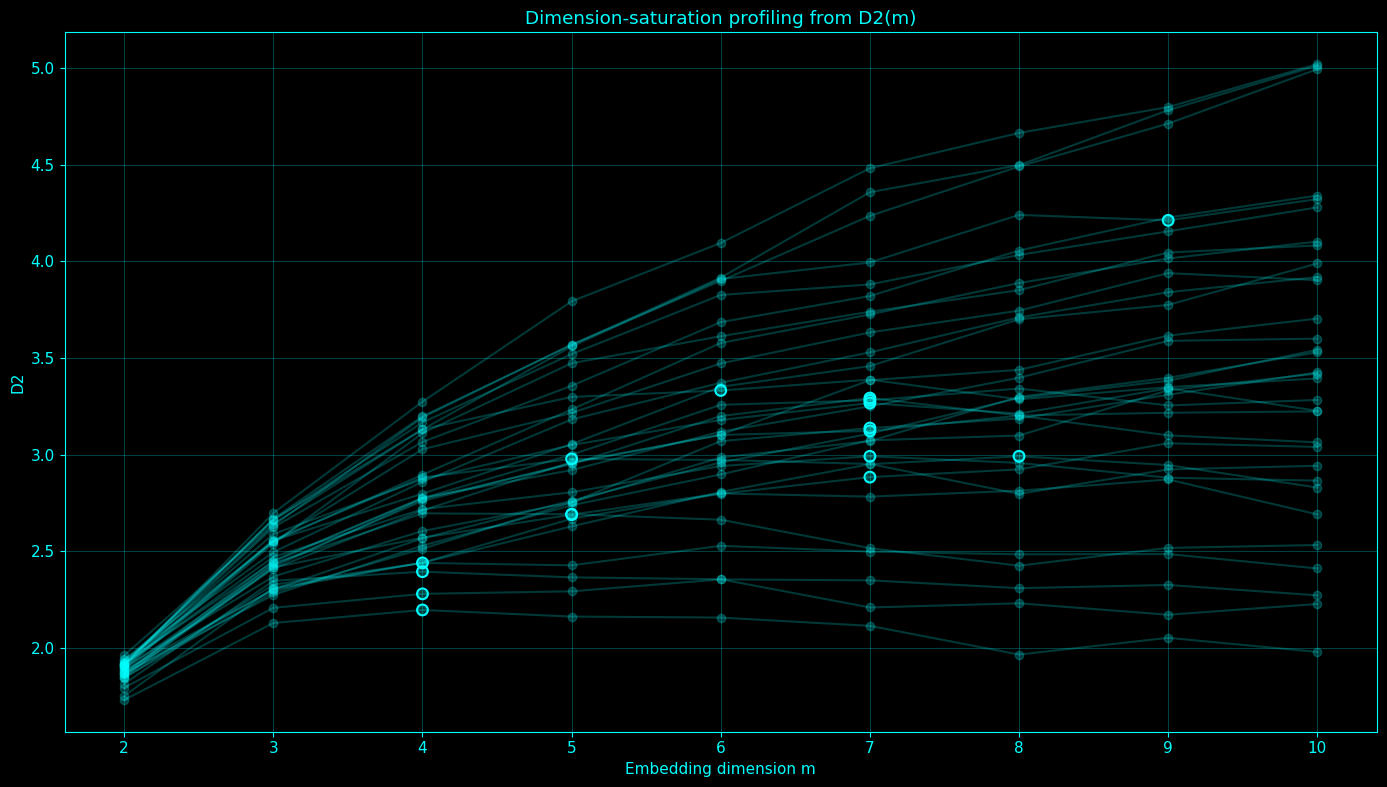


PLOT 2 — Delta D2 Heatmap

What you are seeing:
  - Each row is one EEG channel.
  - Each column is the embedding dimension reached after a step.
  - Each cell shows the change in D2 from the previous embedding dimension.
  - Positive values mean D2 increased at that step.
  - Values near zero mean D2 changed very little at that step.
  - Negative values mean D2 decreased at that step.

Patterns to look for:
  - Look for rows that become near-zero toward the right; these channels are flattening at high m.
  - Look for rows that remain strongly positive toward the right; these channels are still growing.
  - Look for columns where many channels have large positive changes; that m step may be important globally.
  - Look for columns where many channels become small; that may indicate common saturation behavior.
  - Look for alternating positive and negative patches; this may indicate unstable dimension estimates.
  - Look for one channel with unusually large jumps; that channel should b

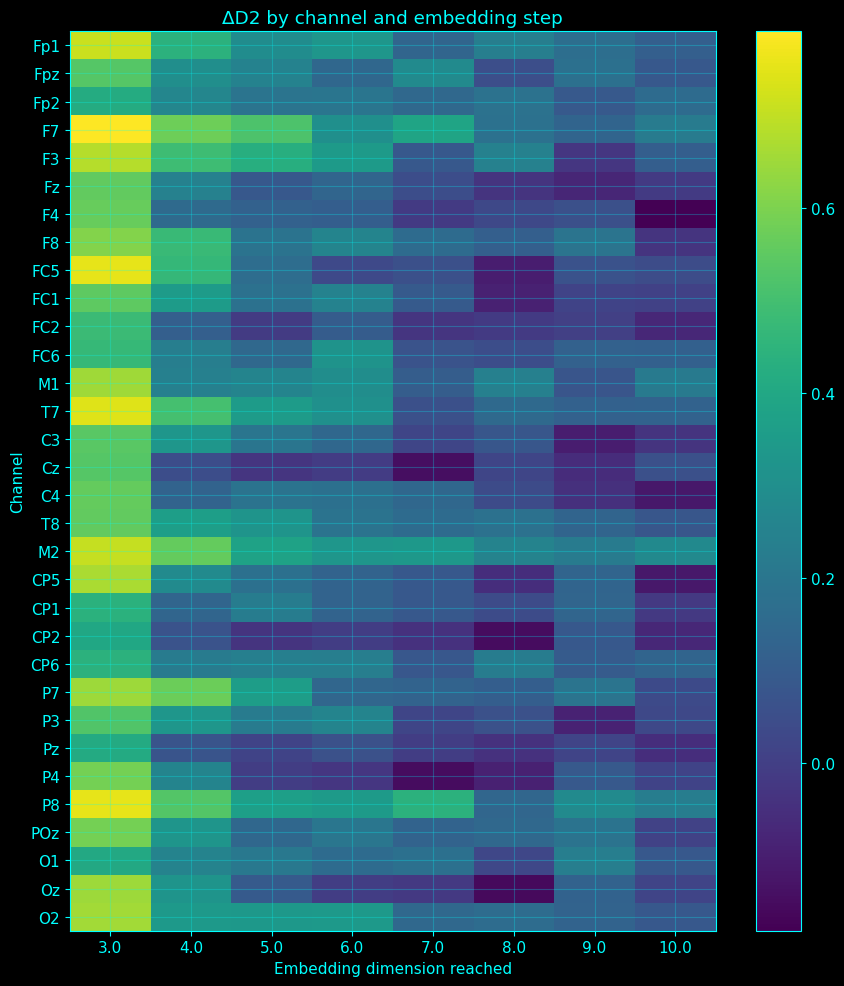


PLOT 3 — Absolute-Threshold Saturation Dimension by Channel

What you are seeing:
  - Each bar is one EEG channel.
  - The bar height is the first embedding dimension where the absolute saturation rule is satisfied.
  - Channels with no detected saturation are plotted above the maximum tested embedding dimension.
  - The dashed horizontal line marks the largest tested embedding dimension.

Patterns to look for:
  - Look for low bars; these channels reach apparent saturation early.
  - Look for middle-height bars; these channels reach apparent saturation in the middle of the tested range.
  - Look for bars near the maximum m; these channels saturate late.
  - Look for bars above the dashed line; these channels did not satisfy the saturation rule.
  - Look for whether most channels saturate around the same m.
  - Look for whether only a few channels fail to saturate.
  - Look for whether no_saturation channels also have high tail slopes.
  - Look for whether early-saturation channels ha

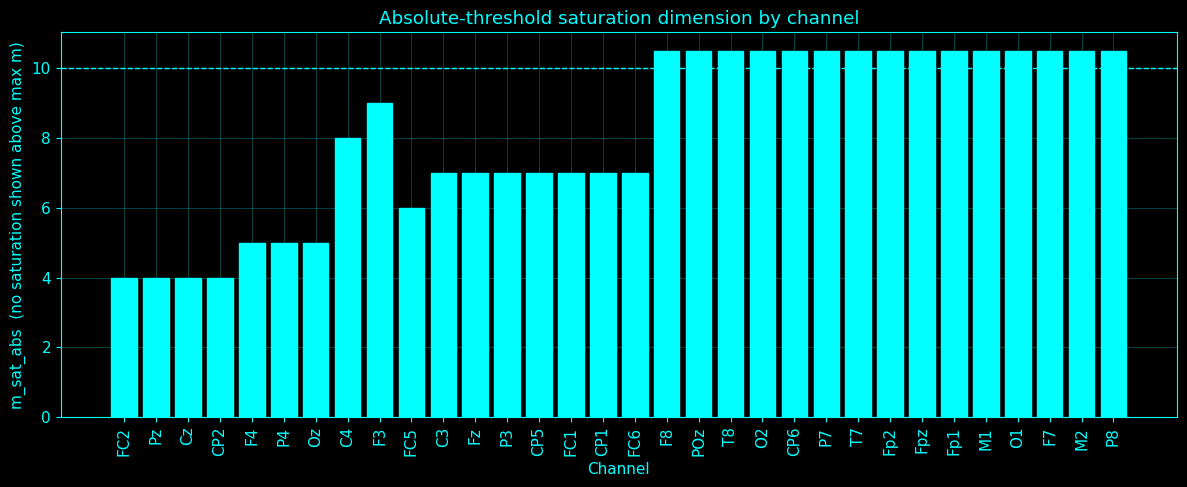


PLOT 4 — Tail Slope of D2 over Final Embedding Dimensions

What you are seeing:
  - Each bar is one EEG channel.
  - The y-axis is the slope of D2 over the final embedding dimensions.
  - A value near zero means the final part of the D2 curve is nearly flat.
  - A positive value means D2 is still increasing at the end.
  - A negative value means D2 is decreasing at the end.

Patterns to look for:
  - Look for bars near zero; these channels show stronger late-stage flattening.
  - Look for large positive bars; these channels are still growing and are less clearly saturated.
  - Look for negative bars; these channels decrease at the end and may be unstable or overestimated earlier.
  - Look for whether no_saturation channels also appear at the top of this plot.
  - Look for whether early-saturation channels have near-zero tail slopes.
  - Look for isolated large positive slopes; these channels deserve follow-up inspection.
  - Look for a general distribution centered near zero; this sup

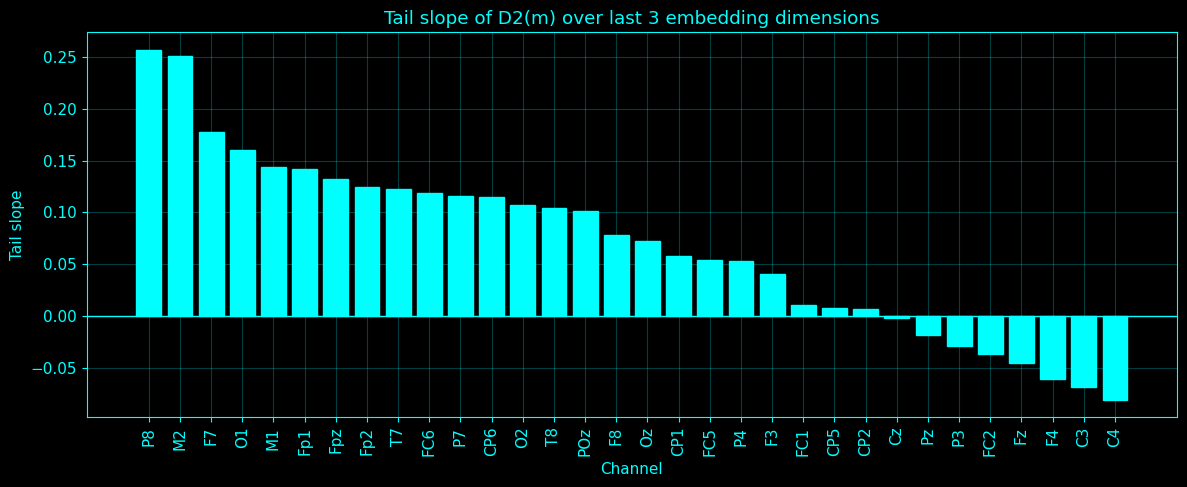


PLOT 5 — Saturation Class Counts

What you are seeing:
  - Each bar is one saturation class.
  - The y-axis counts how many channels fall into each class.
  - Classes are based on the first detected absolute-threshold saturation dimension.
  - The classes summarize whether channels saturate early, mid, late, or not within the tested range.

Patterns to look for:
  - Look for a large early bar; many channels flatten at low embedding dimension.
  - Look for a large mid bar; many channels flatten in the middle of the tested range.
  - Look for a large late bar; many channels flatten only near the end.
  - Look for a large no_saturation bar; many channels do not clearly flatten in the tested range.
  - Look for whether saturation is broadly common or rare.
  - Look for whether class counts agree with the D2 curve plot.
  - Look for whether class counts agree with the tail slope plot.

Cautions:
  - Class counts summarize the threshold rule; they do not replace visual inspection.
  - Chang

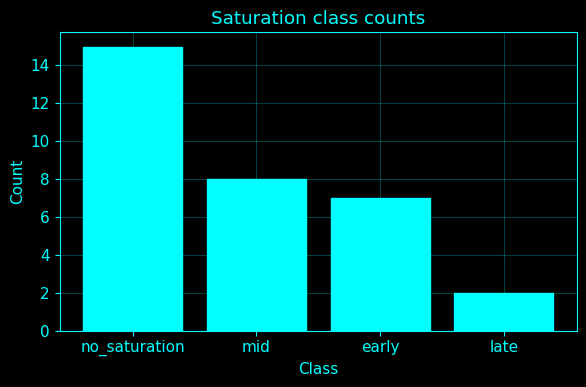


Saved outputs to: /home/a/projects/Complete-Neural-Signal-Analysis/dimension_saturation_profiling
Summary CSV: /home/a/projects/Complete-Neural-Signal-Analysis/dimension_saturation_profiling/dimension_saturation_summary.csv
Delta CSV: /home/a/projects/Complete-Neural-Signal-Analysis/dimension_saturation_profiling/dimension_saturation_deltas.csv
Summary TXT: /home/a/projects/Complete-Neural-Signal-Analysis/dimension_saturation_profiling/dimension_saturation_summary.txt


# Interpretation of Dimension-Saturation Profiling Results

This report interprets the numerical saturation-profiling results after the plots have been created. The main question is whether each channel's estimated correlation dimension \(D_2\) begins to stabilize as embedding dimension \(m\) increases.

---

## 1. Overall saturation picture

- Metric used: **corr_dim_d2**
- Absolute delta threshold: **0.1200**
- Relative delta threshold: **0.0400**
- Consecutive small increments required: **2**
- Tail points used for final slope: **3**

**Class counts:**

- **no_saturation**: 15 channel(s)
- **mid**: 8 channel(s)
- **early**: 7 channel(s)
- **late**: 2 channel(s)

**Interpretation:** About half or more of the channels satisfy the saturation rule, while a substantial fraction still does not. Counts: early=7, mid=8, late=2, no_saturation=15, total=32.

The class-count result gives the broadest summary. If many channels are classified as early or mid, the data show widespread apparent flattening. If many channels are classified as late or no_saturation, the tested embedding range may not be sufficient to show stable dimension estimates for all channels.

---

## 2. Tail-slope behavior

- Mean tail slope: **0.0692**
- Median tail slope: **0.0757**
- Maximum tail slope: **0.2572**
- Minimum tail slope: **-0.0808**

**Median-tail interpretation:** The tail slope is small but not negligible, so the curve may be approaching a flatter region but is not perfectly flat.

Tail slope is the late-stage growth rate of \(D_2(m)\). A near-zero tail slope supports saturation. A positive tail slope means the channel is still gaining dimension at the end of the tested range. A negative tail slope means the final estimate is decreasing, which may reflect fluctuation rather than a cleaner result.

Channels with strongest continuing growth:

- **P8**: tail_slope_last_points=0.2572, m_sat_abs=not available, D2_total_gain=3.0958, D2_mmax=5.0119
- **M2**: tail_slope_last_points=0.2517, m_sat_abs=not available, D2_total_gain=3.0671, D2_mmax=4.9937
- **F7**: tail_slope_last_points=0.1780, m_sat_abs=not available, D2_total_gain=3.1126, D2_mmax=5.0198
- **O1**: tail_slope_last_points=0.1602, m_sat_abs=not available, D2_total_gain=1.5501, D2_mmax=3.4193
- **M1**: tail_slope_last_points=0.1443, m_sat_abs=not available, D2_total_gain=2.0835, D2_mmax=3.9887
- **Fp1**: tail_slope_last_points=0.1423, m_sat_abs=not available, D2_total_gain=2.4292, D2_mmax=4.3401
- **Fpz**: tail_slope_last_points=0.1326, m_sat_abs=not available, D2_total_gain=1.8290, D2_mmax=3.7037
- **Fp2**: tail_slope_last_points=0.1247, m_sat_abs=not available, D2_total_gain=1.6592, D2_mmax=3.5423
- **T7**: tail_slope_last_points=0.1229, m_sat_abs=not available, D2_total_gain=2.3593, D2_mmax=4.2788
- **FC6**: tail_slope_last_points=0.1193, m_sat_abs=7.0000, D2_total_gain=1.5261, D2_mmax=3.4255

Channels with flattest late-stage tails:

- **Cz**: tail_slope_last_points=-0.0018, D2_mmax=2.2277, m_sat_abs=4.0000, plateau_std_abs=0.0827
- **CP2**: tail_slope_last_points=0.0067, D2_mmax=1.9795, m_sat_abs=4.0000, plateau_std_abs=0.0852
- **CP5**: tail_slope_last_points=0.0073, D2_mmax=3.2268, m_sat_abs=7.0000, plateau_std_abs=0.0509
- **FC1**: tail_slope_last_points=0.0105, D2_mmax=3.2238, m_sat_abs=7.0000, plateau_std_abs=0.0347
- **Pz**: tail_slope_last_points=-0.0185, D2_mmax=2.2725, m_sat_abs=4.0000, plateau_std_abs=0.0303
- **P3**: tail_slope_last_points=-0.0294, D2_mmax=3.2830, m_sat_abs=7.0000, plateau_std_abs=0.0320
- **FC2**: tail_slope_last_points=-0.0365, D2_mmax=2.4115, m_sat_abs=4.0000, plateau_std_abs=0.0392
- **F3**: tail_slope_last_points=0.0409, D2_mmax=4.3217, m_sat_abs=9.0000, plateau_std_abs=0.0550
- **Fz**: tail_slope_last_points=-0.0459, D2_mmax=2.8657, m_sat_abs=7.0000, plateau_std_abs=0.0523
- **P4**: tail_slope_last_points=0.0534, D2_mmax=2.5327, m_sat_abs=5.0000, plateau_std_abs=0.0918

The channels with the strongest continuing growth are the least settled by the final embedding dimension. The channels with the flattest late-stage tails are stronger candidates for stable dimension estimates, especially if their plateau variability is also small.

---

## 3. Earliest apparent saturation

Channels with earliest apparent saturation:

- **FC2**: m_sat_abs=4.0000, tail_slope_last_points=-0.0365, plateau_mean_abs=2.4681, plateau_std_abs=0.0392, D2_mmax=2.4115
- **Pz**: m_sat_abs=4.0000, tail_slope_last_points=-0.0185, plateau_mean_abs=2.3123, plateau_std_abs=0.0303, D2_mmax=2.2725
- **Cz**: m_sat_abs=4.0000, tail_slope_last_points=-0.0018, plateau_mean_abs=2.2795, plateau_std_abs=0.0827, D2_mmax=2.2277
- **CP2**: m_sat_abs=4.0000, tail_slope_last_points=0.0067, plateau_mean_abs=2.0899, plateau_std_abs=0.0852, D2_mmax=1.9795
- **F4**: m_sat_abs=5.0000, tail_slope_last_points=-0.0613, plateau_mean_abs=2.7747, plateau_std_abs=0.0656, D2_mmax=2.6910
- **P4**: m_sat_abs=5.0000, tail_slope_last_points=0.0534, plateau_mean_abs=2.5580, plateau_std_abs=0.0918, D2_mmax=2.5327
- **Oz**: m_sat_abs=5.0000, tail_slope_last_points=0.0727, plateau_mean_abs=2.9276, plateau_std_abs=0.0611, D2_mmax=2.9426
- **FC5**: m_sat_abs=6.0000, tail_slope_last_points=0.0540, plateau_mean_abs=3.3499, plateau_std_abs=0.0395, D2_mmax=3.3943
- **C3**: m_sat_abs=7.0000, tail_slope_last_points=-0.0691, plateau_mean_abs=3.1220, plateau_std_abs=0.0506, D2_mmax=3.0636
- **Fz**: m_sat_abs=7.0000, tail_slope_last_points=-0.0459, plateau_mean_abs=2.9238, plateau_std_abs=0.0523, D2_mmax=2.8657

The earliest apparent saturation occurs in **FC2** at m=4.0000. Its tail slope is -0.0365. The tail slope is small but not negligible, so the curve may be approaching a flatter region but is not perfectly flat.

Early saturation is most convincing when the channel remains flat after the saturation point. If the curve satisfies the rule early but later rises again, the early marker should be treated cautiously.

---

## 4. Highest terminal D2 and total gain

- Mean total D2 gain from first to last tested m: **1.5929**
- Median total D2 gain from first to last tested m: **1.5381**

Channels with highest final D2:

- **F7**: D2_mmax=5.0198, D2_total_gain=3.1126, tail_slope_last_points=0.1780, m_sat_abs=not available, class_abs=no_saturation
- **P8**: D2_mmax=5.0119, D2_total_gain=3.0958, tail_slope_last_points=0.2572, m_sat_abs=not available, class_abs=no_saturation
- **M2**: D2_mmax=4.9937, D2_total_gain=3.0671, tail_slope_last_points=0.2517, m_sat_abs=not available, class_abs=no_saturation
- **Fp1**: D2_mmax=4.3401, D2_total_gain=2.4292, tail_slope_last_points=0.1423, m_sat_abs=not available, class_abs=no_saturation
- **F3**: D2_mmax=4.3217, D2_total_gain=2.3600, tail_slope_last_points=0.0409, m_sat_abs=9.0000, class_abs=late
- **T7**: D2_mmax=4.2788, D2_total_gain=2.3593, tail_slope_last_points=0.1229, m_sat_abs=not available, class_abs=no_saturation
- **O2**: D2_mmax=4.1023, D2_total_gain=2.2053, tail_slope_last_points=0.1073, m_sat_abs=not available, class_abs=no_saturation
- **P7**: D2_mmax=4.0819, D2_total_gain=2.1903, tail_slope_last_points=0.1156, m_sat_abs=not available, class_abs=no_saturation
- **M1**: D2_mmax=3.9887, D2_total_gain=2.0835, tail_slope_last_points=0.1443, m_sat_abs=not available, class_abs=no_saturation
- **T8**: D2_mmax=3.9180, D2_total_gain=1.9798, tail_slope_last_points=0.1042, m_sat_abs=not available, class_abs=no_saturation

Channels with largest total D2 gain:

- **F7**: D2_total_gain=3.1126, D2_m2=1.9071, D2_mmax=5.0198, tail_slope_last_points=0.1780, class_abs=no_saturation
- **P8**: D2_total_gain=3.0958, D2_m2=1.9162, D2_mmax=5.0119, tail_slope_last_points=0.2572, class_abs=no_saturation
- **M2**: D2_total_gain=3.0671, D2_m2=1.9267, D2_mmax=4.9937, tail_slope_last_points=0.2517, class_abs=no_saturation
- **Fp1**: D2_total_gain=2.4292, D2_m2=1.9110, D2_mmax=4.3401, tail_slope_last_points=0.1423, class_abs=no_saturation
- **F3**: D2_total_gain=2.3600, D2_m2=1.9617, D2_mmax=4.3217, tail_slope_last_points=0.0409, class_abs=late
- **T7**: D2_total_gain=2.3593, D2_m2=1.9195, D2_mmax=4.2788, tail_slope_last_points=0.1229, class_abs=no_saturation
- **O2**: D2_total_gain=2.2053, D2_m2=1.8970, D2_mmax=4.1023, tail_slope_last_points=0.1073, class_abs=no_saturation
- **P7**: D2_total_gain=2.1903, D2_m2=1.8916, D2_mmax=4.0819, tail_slope_last_points=0.1156, class_abs=no_saturation
- **M1**: D2_total_gain=2.0835, D2_m2=1.9052, D2_mmax=3.9887, tail_slope_last_points=0.1443, class_abs=no_saturation
- **T8**: D2_total_gain=1.9798, D2_m2=1.9382, D2_mmax=3.9180, tail_slope_last_points=0.1042, class_abs=no_saturation

A high final \(D_2\) means the channel reaches a high estimated complexity at the largest embedding dimension. But high final \(D_2\) is strongest when paired with a small tail slope. If final \(D_2\) is high and the tail slope is still strongly positive, the channel may still be unfolding rather than saturated.

---

## 5. Plateau stability after apparent saturation

Channels with lowest plateau variability after apparent saturation:

- **Pz**: m_sat_abs=4.0000, plateau_mean_abs=2.3123, plateau_std_abs=0.0303, tail_slope_last_points=-0.0185, D2_mmax=2.2725
- **P3**: m_sat_abs=7.0000, plateau_mean_abs=3.2900, plateau_std_abs=0.0320, tail_slope_last_points=-0.0294, D2_mmax=3.2830
- **FC1**: m_sat_abs=7.0000, plateau_mean_abs=3.2339, plateau_std_abs=0.0347, tail_slope_last_points=0.0105, D2_mmax=3.2238
- **FC2**: m_sat_abs=4.0000, plateau_mean_abs=2.4681, plateau_std_abs=0.0392, tail_slope_last_points=-0.0365, D2_mmax=2.4115
- **FC5**: m_sat_abs=6.0000, plateau_mean_abs=3.3499, plateau_std_abs=0.0395, tail_slope_last_points=0.0540, D2_mmax=3.3943
- **C3**: m_sat_abs=7.0000, plateau_mean_abs=3.1220, plateau_std_abs=0.0506, tail_slope_last_points=-0.0691, D2_mmax=3.0636
- **CP5**: m_sat_abs=7.0000, plateau_mean_abs=3.2623, plateau_std_abs=0.0509, tail_slope_last_points=0.0073, D2_mmax=3.2268
- **Fz**: m_sat_abs=7.0000, plateau_mean_abs=2.9238, plateau_std_abs=0.0523, tail_slope_last_points=-0.0459, D2_mmax=2.8657
- **F3**: m_sat_abs=9.0000, plateau_mean_abs=4.2667, plateau_std_abs=0.0550, tail_slope_last_points=0.0409, D2_mmax=4.3217
- **Oz**: m_sat_abs=5.0000, plateau_mean_abs=2.9276, plateau_std_abs=0.0611, tail_slope_last_points=0.0727, D2_mmax=2.9426

Low plateau standard deviation means the \(D_2\) values after the detected saturation point remain relatively stable. This supports the interpretation that the channel has entered a flatter region of the curve.

---

## 6. What makes a saturation result stronger

A saturation result is stronger when several signs agree:

- The \(D_2(m)\) curve visually flattens.
- The delta heatmap shows small late-stage increments.
- The channel has an early or mid saturation class rather than late or no_saturation.
- The tail slope is close to zero.
- The plateau standard deviation after saturation is small.
- The channel does not rise again strongly after the first saturation marker.

A saturation result needs caution when:

- The channel has no detected saturation.
- The tail slope remains clearly positive.
- The total D2 gain is large and still increasing at the end.
- The curve fluctuates strongly rather than flattening smoothly.
- The saturation marker appears, but later values rise again.
- The result depends heavily on one threshold choice.

---

## 7. Final synthesis

The most common saturation class is **no_saturation**, with **15** channel(s). The channel with the strongest continuing late-stage growth is **P8** (tail slope=0.2572). The channel with the flattest late-stage tail is **Cz** (tail slope=-0.0018). The highest terminal D2 is observed in **F7** (D2_mmax=5.0198). 

The safest conclusion is not simply that a channel has a high final \(D_2\). The stronger conclusion is that a channel has a stable dimension estimate when high or moderate \(D_2\), small late-stage increments, low tail slope, and stable post-saturation values all point in the same direction.

---

## 8. One-sentence takeaway

This analysis shows whether each channel's embedded \(D_2\) estimate keeps growing or begins to flatten as embedding dimension increases, and the most reliable saturation interpretation comes from agreement between the curve shape, delta values, saturation class, tail slope, and plateau stability.


In [10]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from IPython.display import Markdown, display
    CAN_DISPLAY_MARKDOWN = True
except Exception:
    Markdown = None
    display = None
    CAN_DISPLAY_MARKDOWN = False

# -------------------------------------------------------
# CONFIG
# -------------------------------------------------------
base_dir = "/home/a/projects/Complete-Neural-Signal-Analysis"
source_csv = os.path.join(base_dir, "embedded_fractal_dimension_research", "embedded_fractal_dimension_summary.csv")
out_dir = os.path.join(base_dir, "dimension_saturation_profiling")
os.makedirs(out_dir, exist_ok=True)

eeg_channel_names = [
    'Fp1', 'Fpz', 'Fp2', 'F7', 'F3', 'Fz', 'F4', 'F8', 'FC5', 'FC1', 'FC2', 'FC6',
    'M1', 'T7', 'C3', 'Cz', 'C4', 'T8', 'M2', 'CP5', 'CP1', 'CP2', 'CP6',
    'P7', 'P3', 'Pz', 'P4', 'P8', 'POz', 'O1', 'Oz', 'O2'
]

use_metric = "corr_dim_d2"
abs_delta_thresh = 0.12
rel_delta_thresh = 0.04
n_consecutive = 2
tail_points = 3

ACCENT = "cyan"
BG = "black"

plt.rcParams.update({
    "figure.facecolor": BG,
    "axes.facecolor": BG,
    "savefig.facecolor": BG,
    "text.color": ACCENT,
    "axes.labelcolor": ACCENT,
    "axes.edgecolor": ACCENT,
    "axes.titlecolor": ACCENT,
    "xtick.color": ACCENT,
    "ytick.color": ACCENT,
    "grid.color": ACCENT,
    "legend.facecolor": BG,
    "legend.edgecolor": ACCENT,
})

# -------------------------------------------------------
# STYLE HELPER
# -------------------------------------------------------
def style_ax(ax):
    ax.set_facecolor(BG)
    ax.grid(True, alpha=0.25, color=ACCENT)
    ax.tick_params(colors=ACCENT)
    for spine in ax.spines.values():
        spine.set_color(ACCENT)

# -------------------------------------------------------
# PLOT DESCRIPTION HELPER
# -------------------------------------------------------
def print_plot_description(title, what_you_see, patterns_to_look_for, cautions=None):
    print("\n" + "=" * 92)
    print(title)
    print("=" * 92)
    print("\nWhat you are seeing:")
    for item in what_you_see:
        print(f"  - {item}")
    print("\nPatterns to look for:")
    for item in patterns_to_look_for:
        print(f"  - {item}")
    if cautions:
        print("\nCautions:")
        for item in cautions:
            print(f"  - {item}")
    print("=" * 92 + "\n")

# -------------------------------------------------------
# NUMERIC HELPERS
# -------------------------------------------------------
def first_consecutive_true(mask, n_consecutive=2):
    mask = np.asarray(mask, dtype=bool)
    if len(mask) < n_consecutive:
        return None

    run = 0
    for i, val in enumerate(mask):
        if val:
            run += 1
            if run >= n_consecutive:
                return i - n_consecutive + 1
        else:
            run = 0
    return None

def tail_slope(x, y, tail_points=3):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    mask = np.isfinite(x) & np.isfinite(y)
    x = x[mask]
    y = y[mask]

    if len(x) < max(2, tail_points):
        return np.nan

    x_tail = x[-tail_points:]
    y_tail = y[-tail_points:]
    coef = np.polyfit(x_tail, y_tail, 1)
    return float(coef[0])

def classify_saturation(m_sat, max_m):
    if pd.isna(m_sat):
        return "no_saturation"
    if m_sat <= 5:
        return "early"
    if m_sat <= 7:
        return "mid"
    if m_sat <= max_m - 1:
        return "late"
    return "no_saturation"

def fmt(x, digits=4):
    try:
        if x is None or not np.isfinite(x):
            return "not available"
        return f"{x:.{digits}f}"
    except Exception:
        return str(x)

def bullet_rows(df, name_col, value_cols, n=10):
    if df is None or len(df) == 0:
        return "- No values available."

    lines = []
    for _, row in df.head(n).iterrows():
        name = row.get(name_col, "unknown")
        pieces = []
        for col in value_cols:
            if col in row:
                pieces.append(f"{col}={fmt(row[col])}")
        lines.append(f"- **{name}**: " + ", ".join(pieces))
    return "\n".join(lines)

def describe_tail_slope_value(x):
    if not np.isfinite(x):
        return "The tail slope is unavailable."
    if abs(x) <= 0.03:
        return "The tail slope is very close to zero, which supports a flattening interpretation."
    if abs(x) <= 0.08:
        return "The tail slope is small but not negligible, so the curve may be approaching a flatter region but is not perfectly flat."
    if x > 0.08:
        return "The tail slope is clearly positive, which suggests continuing growth at the end of the tested embedding range."
    return "The tail slope is clearly negative, which suggests late-stage decrease or estimation fluctuation."

def describe_class_counts(class_counts):
    if len(class_counts) == 0:
        return "No class counts are available."

    total = int(class_counts.sum())
    no_sat = int(class_counts.get("no_saturation", 0))
    early = int(class_counts.get("early", 0))
    mid = int(class_counts.get("mid", 0))
    late = int(class_counts.get("late", 0))

    if total == 0:
        return "No channels were classified."

    no_sat_frac = no_sat / total
    sat_frac = 1.0 - no_sat_frac

    if sat_frac >= 0.75:
        main = "Most channels satisfy the saturation rule somewhere inside the tested embedding range."
    elif sat_frac >= 0.50:
        main = "About half or more of the channels satisfy the saturation rule, while a substantial fraction still does not."
    elif sat_frac > 0:
        main = "Only a minority of channels satisfy the saturation rule, so the overall evidence for broad saturation is limited."
    else:
        main = "No channels satisfy the saturation rule, so the tested embedding range does not show apparent saturation by this criterion."

    detail = f"Counts: early={early}, mid={mid}, late={late}, no_saturation={no_sat}, total={total}."
    return main + " " + detail

# -------------------------------------------------------
# LOAD DATA
# -------------------------------------------------------
df = pd.read_csv(source_csv)

if use_metric not in df.columns:
    raise ValueError(f"Column '{use_metric}' not found in {source_csv}")

df = df[["channel", "emb_dim", use_metric]].copy()
df = df.rename(columns={use_metric: "D"})
df = df.sort_values(["channel", "emb_dim"]).reset_index(drop=True)

print("Loaded summary:")
print(df.head())

# -------------------------------------------------------
# PROFILE SATURATION PER CHANNEL
# -------------------------------------------------------
summary_rows = []
delta_rows = []

max_m_global = int(df["emb_dim"].max())

for ch in eeg_channel_names:
    sub = df[df["channel"] == ch].sort_values("emb_dim").copy()
    if len(sub) < 3:
        continue

    m = sub["emb_dim"].to_numpy(dtype=float)
    d2 = sub["D"].to_numpy(dtype=float)

    delta = np.diff(d2)
    delta_m = m[1:]
    rel_delta = delta / np.maximum(np.abs(d2[:-1]), 1e-12)

    abs_mask = np.abs(delta) <= abs_delta_thresh
    abs_idx = first_consecutive_true(abs_mask, n_consecutive=n_consecutive)
    if abs_idx is None:
        m_sat_abs = np.nan
    else:
        m_sat_abs = delta_m[abs_idx]

    rel_mask = np.abs(rel_delta) <= rel_delta_thresh
    rel_idx = first_consecutive_true(rel_mask, n_consecutive=n_consecutive)
    if rel_idx is None:
        m_sat_rel = np.nan
    else:
        m_sat_rel = delta_m[rel_idx]

    slope_tail = tail_slope(m, d2, tail_points=tail_points)

    if not pd.isna(m_sat_abs):
        sat_start_idx = np.where(m >= m_sat_abs)[0]
        if len(sat_start_idx) > 0:
            plateau_mean_abs = float(np.mean(d2[sat_start_idx[0]:]))
            plateau_std_abs = float(np.std(d2[sat_start_idx[0]:]))
        else:
            plateau_mean_abs = np.nan
            plateau_std_abs = np.nan
    else:
        plateau_mean_abs = np.nan
        plateau_std_abs = np.nan

    if not pd.isna(m_sat_rel):
        sat_start_idx = np.where(m >= m_sat_rel)[0]
        if len(sat_start_idx) > 0:
            plateau_mean_rel = float(np.mean(d2[sat_start_idx[0]:]))
            plateau_std_rel = float(np.std(d2[sat_start_idx[0]:]))
        else:
            plateau_mean_rel = np.nan
            plateau_std_rel = np.nan
    else:
        plateau_mean_rel = np.nan
        plateau_std_rel = np.nan

    summary_rows.append({
        "channel": ch,
        "m_min": float(np.min(m)),
        "m_max": float(np.max(m)),
        "D2_m2": float(d2[0]) if len(d2) > 0 else np.nan,
        "D2_mmax": float(d2[-1]) if len(d2) > 0 else np.nan,
        "D2_total_gain": float(d2[-1] - d2[0]) if len(d2) > 1 else np.nan,
        "mean_delta_D2": float(np.mean(delta)) if len(delta) > 0 else np.nan,
        "std_delta_D2": float(np.std(delta)) if len(delta) > 0 else np.nan,
        "tail_slope_last_points": slope_tail,
        "m_sat_abs": m_sat_abs,
        "m_sat_rel": m_sat_rel,
        "plateau_mean_abs": plateau_mean_abs,
        "plateau_std_abs": plateau_std_abs,
        "plateau_mean_rel": plateau_mean_rel,
        "plateau_std_rel": plateau_std_rel,
        "class_abs": classify_saturation(m_sat_abs, max_m_global),
        "class_rel": classify_saturation(m_sat_rel, max_m_global),
    })

    for mm, dd, rr in zip(delta_m, delta, rel_delta):
        delta_rows.append({
            "channel": ch,
            "emb_dim_to": mm,
            "delta_D2": dd,
            "rel_delta_D2": rr,
            "small_abs": abs(dd) <= abs_delta_thresh,
            "small_rel": abs(rr) <= rel_delta_thresh,
        })

summary_df = pd.DataFrame(summary_rows)
delta_df = pd.DataFrame(delta_rows)

summary_df = summary_df.sort_values(["class_abs", "m_sat_abs", "tail_slope_last_points"], na_position="last")
delta_df = delta_df.sort_values(["channel", "emb_dim_to"])

# -------------------------------------------------------
# SAVE TABLES
# -------------------------------------------------------
summary_csv = os.path.join(out_dir, "dimension_saturation_summary.csv")
delta_csv = os.path.join(out_dir, "dimension_saturation_deltas.csv")

summary_df.to_csv(summary_csv, index=False)
delta_df.to_csv(delta_csv, index=False)

print("\nSaturation summary:")
print(summary_df)

# -------------------------------------------------------
# PLOT 1: ALL CHANNELS D2(m) WITH ABS-SATURATION MARKERS
# -------------------------------------------------------
print_plot_description(
    title="PLOT 1 — D2 Saturation Profiles Across Channels",
    what_you_see=[
        "Each cyan line is one EEG channel.",
        "The x-axis is embedding dimension m.",
        "The y-axis is correlation dimension D2.",
        "Open circle markers show the first embedding dimension where the absolute saturation rule is satisfied.",
        "A curve that rises and then flattens suggests apparent saturation.",
    ],
    patterns_to_look_for=[
        "Look for channels whose D2 curves flatten at low m; these show early apparent saturation.",
        "Look for channels whose D2 curves flatten only near the largest m; these show late apparent saturation.",
        "Look for channels that keep rising through the final m; these show no clear saturation in the tested range.",
        "Look for curves that overshoot and then drop; these may indicate estimation instability.",
        "Look for whether most channels follow a similar curve shape or whether only a few behave differently.",
        "Look for channels with very high final D2 but no flattening; these are high-complexity but less settled.",
        "Look for channels with modest final D2 and early flattening; these may represent simpler stable dynamics.",
        "Look for isolated curves far above the rest; these should be checked for data quality or estimation issues.",
        "Look for isolated curves far below the rest; these may indicate lower complexity or possible channel-specific problems.",
        "Look for whether saturation markers appear in a cluster around the same m value.",
    ],
    cautions=[
        "A saturation marker is rule-based; it does not prove true mathematical saturation.",
        "The visual curve shape should agree with the marker before the interpretation is considered strong.",
        "A channel can satisfy the threshold temporarily and still continue changing later.",
    ],
)

fig, ax = plt.subplots(figsize=(14, 8), facecolor=BG)
style_ax(ax)

for ch in eeg_channel_names:
    sub = df[df["channel"] == ch].sort_values("emb_dim")
    if len(sub) == 0:
        continue

    ax.plot(
        sub["emb_dim"],
        sub["D"],
        marker="o",
        color=ACCENT,
        markerfacecolor=ACCENT,
        markeredgecolor=ACCENT,
        alpha=0.22
    )

    sat_row = summary_df[summary_df["channel"] == ch]
    if len(sat_row) > 0 and not pd.isna(sat_row.iloc[0]["m_sat_abs"]):
        m_sat = sat_row.iloc[0]["m_sat_abs"]
        y_sat = sub.loc[sub["emb_dim"] == m_sat, "D"]
        if len(y_sat) > 0:
            ax.scatter([m_sat], [y_sat.iloc[0]], s=60, facecolors="none", edgecolors=ACCENT, linewidths=1.5)

ax.set_title("Dimension-saturation profiling from D2(m)")
ax.set_xlabel("Embedding dimension m")
ax.set_ylabel("D2")

plot1_path = os.path.join(out_dir, "d2_saturation_profiles_all_channels.png")
plt.tight_layout()
plt.savefig(plot1_path, dpi=160, bbox_inches="tight")
plt.show()
plt.close()

# -------------------------------------------------------
# PLOT 2: DELTA D2 HEATMAP
# -------------------------------------------------------
print_plot_description(
    title="PLOT 2 — Delta D2 Heatmap",
    what_you_see=[
        "Each row is one EEG channel.",
        "Each column is the embedding dimension reached after a step.",
        "Each cell shows the change in D2 from the previous embedding dimension.",
        "Positive values mean D2 increased at that step.",
        "Values near zero mean D2 changed very little at that step.",
        "Negative values mean D2 decreased at that step.",
    ],
    patterns_to_look_for=[
        "Look for rows that become near-zero toward the right; these channels are flattening at high m.",
        "Look for rows that remain strongly positive toward the right; these channels are still growing.",
        "Look for columns where many channels have large positive changes; that m step may be important globally.",
        "Look for columns where many channels become small; that may indicate common saturation behavior.",
        "Look for alternating positive and negative patches; this may indicate unstable dimension estimates.",
        "Look for one channel with unusually large jumps; that channel should be inspected separately.",
        "Look for channels with consistently small deltas across many steps; these may be stable early.",
        "Look for channels with late-stage positive deltas; these weaken a saturation interpretation.",
        "Look for negative late-stage deltas; these may reflect flattening, overestimation at prior m, or noise.",
    ],
    cautions=[
        "Delta values are step-to-step changes and can be noisy.",
        "One small delta is not enough for saturation; the code requires consecutive small deltas.",
        "Interpret the heatmap together with the D2 curve plot and tail slope plot.",
    ],
)

pivot_delta = delta_df.pivot_table(
    index="channel",
    columns="emb_dim_to",
    values="delta_D2",
    aggfunc="mean"
)
pivot_delta = pivot_delta.reindex(index=eeg_channel_names)

fig, ax = plt.subplots(figsize=(9, 10), facecolor=BG)
style_ax(ax)

im = ax.imshow(pivot_delta.values, aspect="auto")
ax.set_title("ΔD2 by channel and embedding step")
ax.set_xlabel("Embedding dimension reached")
ax.set_ylabel("Channel")
ax.set_xticks(np.arange(len(pivot_delta.columns)))
ax.set_xticklabels(pivot_delta.columns, color=ACCENT)
ax.set_yticks(np.arange(len(pivot_delta.index)))
ax.set_yticklabels(pivot_delta.index, color=ACCENT)

cbar = plt.colorbar(im, ax=ax)
cbar.ax.yaxis.set_tick_params(color=ACCENT)
plt.setp(cbar.ax.get_yticklabels(), color=ACCENT)
cbar.outline.set_edgecolor(ACCENT)

plot2_path = os.path.join(out_dir, "delta_d2_heatmap.png")
plt.tight_layout()
plt.savefig(plot2_path, dpi=160, bbox_inches="tight")
plt.show()
plt.close()

# -------------------------------------------------------
# PLOT 3: SATURATION DIMENSION BARPLOT
# -------------------------------------------------------
print_plot_description(
    title="PLOT 3 — Absolute-Threshold Saturation Dimension by Channel",
    what_you_see=[
        "Each bar is one EEG channel.",
        "The bar height is the first embedding dimension where the absolute saturation rule is satisfied.",
        "Channels with no detected saturation are plotted above the maximum tested embedding dimension.",
        "The dashed horizontal line marks the largest tested embedding dimension.",
    ],
    patterns_to_look_for=[
        "Look for low bars; these channels reach apparent saturation early.",
        "Look for middle-height bars; these channels reach apparent saturation in the middle of the tested range.",
        "Look for bars near the maximum m; these channels saturate late.",
        "Look for bars above the dashed line; these channels did not satisfy the saturation rule.",
        "Look for whether most channels saturate around the same m.",
        "Look for whether only a few channels fail to saturate.",
        "Look for whether no_saturation channels also have high tail slopes.",
        "Look for whether early-saturation channels have low plateau variability.",
    ],
    cautions=[
        "The threshold is chosen by the analysis settings, so changing abs_delta_thresh can change the classification.",
        "A low saturation dimension is strongest when the D2 curve remains flat afterward.",
        "A no_saturation label means no saturation by this rule, not necessarily no saturation in reality.",
    ],
)

plot_df = summary_df.copy()
plot_df["m_sat_abs_plot"] = plot_df["m_sat_abs"].fillna(max_m_global + 0.5)

fig, ax = plt.subplots(figsize=(12, 5), facecolor=BG)
style_ax(ax)

ax.bar(
    plot_df["channel"],
    plot_df["m_sat_abs_plot"],
    color=ACCENT,
    edgecolor=ACCENT
)
ax.axhline(max_m_global, color=ACCENT, linestyle="--", linewidth=1)
ax.set_title("Absolute-threshold saturation dimension by channel")
ax.set_xlabel("Channel")
ax.set_ylabel("m_sat_abs  (no saturation shown above max m)")
ax.tick_params(axis='x', rotation=90)

plot3_path = os.path.join(out_dir, "saturation_dimension_barplot.png")
plt.tight_layout()
plt.savefig(plot3_path, dpi=160, bbox_inches="tight")
plt.show()
plt.close()

# -------------------------------------------------------
# PLOT 4: TAIL SLOPE BARPLOT
# -------------------------------------------------------
print_plot_description(
    title="PLOT 4 — Tail Slope of D2 over Final Embedding Dimensions",
    what_you_see=[
        "Each bar is one EEG channel.",
        "The y-axis is the slope of D2 over the final embedding dimensions.",
        "A value near zero means the final part of the D2 curve is nearly flat.",
        "A positive value means D2 is still increasing at the end.",
        "A negative value means D2 is decreasing at the end.",
    ],
    patterns_to_look_for=[
        "Look for bars near zero; these channels show stronger late-stage flattening.",
        "Look for large positive bars; these channels are still growing and are less clearly saturated.",
        "Look for negative bars; these channels decrease at the end and may be unstable or overestimated earlier.",
        "Look for whether no_saturation channels also appear at the top of this plot.",
        "Look for whether early-saturation channels have near-zero tail slopes.",
        "Look for isolated large positive slopes; these channels deserve follow-up inspection.",
        "Look for a general distribution centered near zero; this supports broad flattening.",
        "Look for a distribution mostly above zero; this suggests many channels are still growing.",
    ],
    cautions=[
        "Tail slope is calculated only over the final selected points.",
        "A near-zero tail slope supports saturation, but it should agree with the full curve and delta heatmap.",
        "A negative tail slope is not automatically better; it can reflect fluctuation.",
    ],
)

tail_df = summary_df.sort_values("tail_slope_last_points", ascending=False)

fig, ax = plt.subplots(figsize=(12, 5), facecolor=BG)
style_ax(ax)

ax.bar(
    tail_df["channel"],
    tail_df["tail_slope_last_points"],
    color=ACCENT,
    edgecolor=ACCENT
)
ax.axhline(0, color=ACCENT, linewidth=1)
ax.set_title(f"Tail slope of D2(m) over last {tail_points} embedding dimensions")
ax.set_xlabel("Channel")
ax.set_ylabel("Tail slope")
ax.tick_params(axis='x', rotation=90)

plot4_path = os.path.join(out_dir, "tail_slope_barplot.png")
plt.tight_layout()
plt.savefig(plot4_path, dpi=160, bbox_inches="tight")
plt.show()
plt.close()

# -------------------------------------------------------
# PLOT 5: CLASS COUNTS
# -------------------------------------------------------
print_plot_description(
    title="PLOT 5 — Saturation Class Counts",
    what_you_see=[
        "Each bar is one saturation class.",
        "The y-axis counts how many channels fall into each class.",
        "Classes are based on the first detected absolute-threshold saturation dimension.",
        "The classes summarize whether channels saturate early, mid, late, or not within the tested range.",
    ],
    patterns_to_look_for=[
        "Look for a large early bar; many channels flatten at low embedding dimension.",
        "Look for a large mid bar; many channels flatten in the middle of the tested range.",
        "Look for a large late bar; many channels flatten only near the end.",
        "Look for a large no_saturation bar; many channels do not clearly flatten in the tested range.",
        "Look for whether saturation is broadly common or rare.",
        "Look for whether class counts agree with the D2 curve plot.",
        "Look for whether class counts agree with the tail slope plot.",
    ],
    cautions=[
        "Class counts summarize the threshold rule; they do not replace visual inspection.",
        "Changing the threshold or required consecutive steps can change these counts.",
        "A class label is a compact description of curve behavior, not a biological category.",
    ],
)

class_counts = summary_df["class_abs"].value_counts()

fig, ax = plt.subplots(figsize=(6, 4), facecolor=BG)
style_ax(ax)

ax.bar(
    class_counts.index,
    class_counts.values,
    color=ACCENT,
    edgecolor=ACCENT
)
ax.set_title("Saturation class counts")
ax.set_xlabel("Class")
ax.set_ylabel("Count")

plot5_path = os.path.join(out_dir, "saturation_class_counts.png")
plt.tight_layout()
plt.savefig(plot5_path, dpi=160, bbox_inches="tight")
plt.show()
plt.close()

# -------------------------------------------------------
# SAVE TEXT SUMMARY
# -------------------------------------------------------
txt_path = os.path.join(out_dir, "dimension_saturation_summary.txt")
with open(txt_path, "w") as f:
    f.write("Dimension-saturation profiling per channel\n")
    f.write("=========================================\n\n")
    f.write(f"Source CSV: {source_csv}\n")
    f.write(f"Metric used: {use_metric}\n")
    f.write(f"Absolute delta threshold: {abs_delta_thresh}\n")
    f.write(f"Relative delta threshold: {rel_delta_thresh}\n")
    f.write(f"Consecutive small increments required: {n_consecutive}\n")
    f.write(f"Tail points for slope: {tail_points}\n\n")

    f.write("Class counts using absolute threshold:\n")
    for k, v in class_counts.items():
        f.write(f"  {k}: {v}\n")

    f.write("\nChannels with strongest continuing growth:\n")
    tmp = summary_df.sort_values("tail_slope_last_points", ascending=False).head(10)
    for _, row in tmp.iterrows():
        f.write(
            f"  {row['channel']}: tail_slope={row['tail_slope_last_points']:.6f}, "
            f"m_sat_abs={row['m_sat_abs']}, D2_gain={row['D2_total_gain']:.6f}\n"
        )

    f.write("\nChannels with earliest apparent saturation:\n")
    tmp = summary_df.dropna(subset=["m_sat_abs"]).sort_values("m_sat_abs", ascending=True).head(10)
    for _, row in tmp.iterrows():
        f.write(
            f"  {row['channel']}: m_sat_abs={row['m_sat_abs']}, "
            f"tail_slope={row['tail_slope_last_points']:.6f}, "
            f"plateau_mean_abs={row['plateau_mean_abs']:.6f}\n"
        )

print(f"\nSaved outputs to: {out_dir}")
print(f"Summary CSV: {summary_csv}")
print(f"Delta CSV: {delta_csv}")
print(f"Summary TXT: {txt_path}")

# -------------------------------------------------------
# NUMERICAL RESULT INTERPRETATION AFTER ALL PLOTS
# -------------------------------------------------------
early_df = summary_df[summary_df["class_abs"] == "early"].copy()
mid_df = summary_df[summary_df["class_abs"] == "mid"].copy()
late_df = summary_df[summary_df["class_abs"] == "late"].copy()
no_sat_df = summary_df[summary_df["class_abs"] == "no_saturation"].copy()

strong_growth_df = summary_df.sort_values("tail_slope_last_points", ascending=False).copy()
earliest_sat_df = summary_df.dropna(subset=["m_sat_abs"]).sort_values(["m_sat_abs", "tail_slope_last_points"], ascending=[True, True]).copy()
flattest_tail_df = summary_df[np.isfinite(summary_df["tail_slope_last_points"])].copy()
flattest_tail_df["abs_tail_slope"] = flattest_tail_df["tail_slope_last_points"].abs()
flattest_tail_df = flattest_tail_df.sort_values(["abs_tail_slope", "D2_mmax"], ascending=[True, False])

highest_terminal_df = summary_df.sort_values("D2_mmax", ascending=False).copy()
highest_gain_df = summary_df.sort_values("D2_total_gain", ascending=False).copy()
lowest_plateau_var_df = summary_df.dropna(subset=["plateau_std_abs"]).sort_values("plateau_std_abs", ascending=True).copy()

tail_values = summary_df["tail_slope_last_points"].to_numpy(dtype=float)
tail_values = tail_values[np.isfinite(tail_values)]

if len(tail_values) > 0:
    mean_tail = float(np.mean(tail_values))
    median_tail = float(np.median(tail_values))
    max_tail = float(np.max(tail_values))
    min_tail = float(np.min(tail_values))
else:
    mean_tail = np.nan
    median_tail = np.nan
    max_tail = np.nan
    min_tail = np.nan

gain_values = summary_df["D2_total_gain"].to_numpy(dtype=float)
gain_values = gain_values[np.isfinite(gain_values)]

if len(gain_values) > 0:
    mean_gain = float(np.mean(gain_values))
    median_gain = float(np.median(gain_values))
else:
    mean_gain = np.nan
    median_gain = np.nan

report = ""

report += "# Interpretation of Dimension-Saturation Profiling Results\n\n"

report += (
    "This report interprets the numerical saturation-profiling results after the plots have been created. "
    "The main question is whether each channel's estimated correlation dimension \(D_2\) begins to stabilize as embedding dimension \(m\) increases.\n\n"
)

report += "---\n\n"

report += "## 1. Overall saturation picture\n\n"

report += f"- Metric used: **{use_metric}**\n"
report += f"- Absolute delta threshold: **{fmt(abs_delta_thresh)}**\n"
report += f"- Relative delta threshold: **{fmt(rel_delta_thresh)}**\n"
report += f"- Consecutive small increments required: **{n_consecutive}**\n"
report += f"- Tail points used for final slope: **{tail_points}**\n\n"

report += "**Class counts:**\n\n"
for k, v in class_counts.items():
    report += f"- **{k}**: {int(v)} channel(s)\n"

report += "\n"
report += f"**Interpretation:** {describe_class_counts(class_counts)}\n\n"

report += (
    "The class-count result gives the broadest summary. If many channels are classified as early or mid, the data show widespread apparent flattening. "
    "If many channels are classified as late or no_saturation, the tested embedding range may not be sufficient to show stable dimension estimates for all channels.\n\n"
)

report += "---\n\n"

report += "## 2. Tail-slope behavior\n\n"

report += f"- Mean tail slope: **{fmt(mean_tail)}**\n"
report += f"- Median tail slope: **{fmt(median_tail)}**\n"
report += f"- Maximum tail slope: **{fmt(max_tail)}**\n"
report += f"- Minimum tail slope: **{fmt(min_tail)}**\n\n"

report += f"**Median-tail interpretation:** {describe_tail_slope_value(median_tail)}\n\n"

report += (
    "Tail slope is the late-stage growth rate of \(D_2(m)\). A near-zero tail slope supports saturation. "
    "A positive tail slope means the channel is still gaining dimension at the end of the tested range. "
    "A negative tail slope means the final estimate is decreasing, which may reflect fluctuation rather than a cleaner result.\n\n"
)

report += "Channels with strongest continuing growth:\n\n"
report += bullet_rows(
    strong_growth_df,
    "channel",
    ["tail_slope_last_points", "m_sat_abs", "D2_total_gain", "D2_mmax"],
    n=10,
)
report += "\n\n"

report += "Channels with flattest late-stage tails:\n\n"
report += bullet_rows(
    flattest_tail_df,
    "channel",
    ["tail_slope_last_points", "D2_mmax", "m_sat_abs", "plateau_std_abs"],
    n=10,
)
report += "\n\n"

report += (
    "The channels with the strongest continuing growth are the least settled by the final embedding dimension. "
    "The channels with the flattest late-stage tails are stronger candidates for stable dimension estimates, especially if their plateau variability is also small.\n\n"
)

report += "---\n\n"

report += "## 3. Earliest apparent saturation\n\n"

if len(earliest_sat_df) > 0:
    report += "Channels with earliest apparent saturation:\n\n"
    report += bullet_rows(
        earliest_sat_df,
        "channel",
        ["m_sat_abs", "tail_slope_last_points", "plateau_mean_abs", "plateau_std_abs", "D2_mmax"],
        n=10,
    )
    report += "\n\n"

    first_sat = earliest_sat_df.iloc[0]
    report += (
        f"The earliest apparent saturation occurs in **{first_sat['channel']}** at m={fmt(first_sat['m_sat_abs'])}. "
        f"Its tail slope is {fmt(first_sat['tail_slope_last_points'])}. "
        f"{describe_tail_slope_value(first_sat['tail_slope_last_points'])}\n\n"
    )
else:
    report += (
        "No channel satisfied the absolute-threshold saturation rule. This means the tested embedding range did not produce apparent saturation under the current settings.\n\n"
    )

report += (
    "Early saturation is most convincing when the channel remains flat after the saturation point. "
    "If the curve satisfies the rule early but later rises again, the early marker should be treated cautiously.\n\n"
)

report += "---\n\n"

report += "## 4. Highest terminal D2 and total gain\n\n"

report += f"- Mean total D2 gain from first to last tested m: **{fmt(mean_gain)}**\n"
report += f"- Median total D2 gain from first to last tested m: **{fmt(median_gain)}**\n\n"

report += "Channels with highest final D2:\n\n"
report += bullet_rows(
    highest_terminal_df,
    "channel",
    ["D2_mmax", "D2_total_gain", "tail_slope_last_points", "m_sat_abs", "class_abs"],
    n=10,
)
report += "\n\n"

report += "Channels with largest total D2 gain:\n\n"
report += bullet_rows(
    highest_gain_df,
    "channel",
    ["D2_total_gain", "D2_m2", "D2_mmax", "tail_slope_last_points", "class_abs"],
    n=10,
)
report += "\n\n"

report += (
    "A high final \(D_2\) means the channel reaches a high estimated complexity at the largest embedding dimension. "
    "But high final \(D_2\) is strongest when paired with a small tail slope. "
    "If final \(D_2\) is high and the tail slope is still strongly positive, the channel may still be unfolding rather than saturated.\n\n"
)

report += "---\n\n"

report += "## 5. Plateau stability after apparent saturation\n\n"

if len(lowest_plateau_var_df) > 0:
    report += "Channels with lowest plateau variability after apparent saturation:\n\n"
    report += bullet_rows(
        lowest_plateau_var_df,
        "channel",
        ["m_sat_abs", "plateau_mean_abs", "plateau_std_abs", "tail_slope_last_points", "D2_mmax"],
        n=10,
    )
    report += "\n\n"

    report += (
        "Low plateau standard deviation means the \(D_2\) values after the detected saturation point remain relatively stable. "
        "This supports the interpretation that the channel has entered a flatter region of the curve.\n\n"
    )
else:
    report += (
        "No plateau-variability values were available because no channels had an absolute-threshold saturation point.\n\n"
    )

report += "---\n\n"

report += "## 6. What makes a saturation result stronger\n\n"

report += (
    "A saturation result is stronger when several signs agree:\n\n"
    "- The \(D_2(m)\) curve visually flattens.\n"
    "- The delta heatmap shows small late-stage increments.\n"
    "- The channel has an early or mid saturation class rather than late or no_saturation.\n"
    "- The tail slope is close to zero.\n"
    "- The plateau standard deviation after saturation is small.\n"
    "- The channel does not rise again strongly after the first saturation marker.\n\n"
)

report += "A saturation result needs caution when:\n\n"
report += (
    "- The channel has no detected saturation.\n"
    "- The tail slope remains clearly positive.\n"
    "- The total D2 gain is large and still increasing at the end.\n"
    "- The curve fluctuates strongly rather than flattening smoothly.\n"
    "- The saturation marker appears, but later values rise again.\n"
    "- The result depends heavily on one threshold choice.\n\n"
)

report += "---\n\n"

report += "## 7. Final synthesis\n\n"

if len(class_counts) > 0:
    dominant_class = class_counts.index[0]
    dominant_count = int(class_counts.iloc[0])
    report += (
        f"The most common saturation class is **{dominant_class}**, with **{dominant_count}** channel(s). "
    )

if len(strong_growth_df) > 0:
    growth_ch = strong_growth_df.iloc[0]
    report += (
        f"The channel with the strongest continuing late-stage growth is **{growth_ch['channel']}** "
        f"(tail slope={fmt(growth_ch['tail_slope_last_points'])}). "
    )

if len(flattest_tail_df) > 0:
    flat_ch = flattest_tail_df.iloc[0]
    report += (
        f"The channel with the flattest late-stage tail is **{flat_ch['channel']}** "
        f"(tail slope={fmt(flat_ch['tail_slope_last_points'])}). "
    )

if len(highest_terminal_df) > 0:
    high_ch = highest_terminal_df.iloc[0]
    report += (
        f"The highest terminal D2 is observed in **{high_ch['channel']}** "
        f"(D2_mmax={fmt(high_ch['D2_mmax'])}). "
    )

report += "\n\n"

report += (
    "The safest conclusion is not simply that a channel has a high final \(D_2\). "
    "The stronger conclusion is that a channel has a stable dimension estimate when high or moderate \(D_2\), small late-stage increments, low tail slope, and stable post-saturation values all point in the same direction.\n\n"
)

report += "---\n\n"

report += "## 8. One-sentence takeaway\n\n"

report += (
    "This analysis shows whether each channel's embedded \(D_2\) estimate keeps growing or begins to flatten as embedding dimension increases, and the most reliable saturation interpretation comes from agreement between the curve shape, delta values, saturation class, tail slope, and plateau stability.\n"
)

if CAN_DISPLAY_MARKDOWN:
    display(Markdown(report))
else:
    print(report)

dimension_saturation_interpretation_report = report

### Katz Fractal Dimension


<div style="font-size:14px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:22px;border-radius:10px;margin:10px;line-height:1.6;">
<div style="border-bottom:1px solid #404040;margin-bottom:16px;padding-bottom:10px;">
<h2 style="color:#E8E8E8;margin:0;">Katz Fractal Dimension Analysis of Embedded EEG Trajectories</h2>
<p style="margin:8px 0 0 0;">This analysis estimates the Katz Fractal Dimension of saved EEG embedding files. Each embedding file represents an EEG channel as a trajectory: a sequence of points moving through an embedding space. The Katz Fractal Dimension gives a compact numerical description of how winding, indirect, and geometrically complex that trajectory is.</p>
</div>
<div style="background-color:#222222;border-left:4px solid #D0D0D0;padding:12px 14px;border-radius:6px;margin-bottom:18px;">
<h3 style="color:#E8E8E8;margin-top:0;">The Basic Question</h3>
<p style="margin-bottom:0;">Imagine walking from one point to another. If the path is almost straight, the journey is simple. If the path twists, turns, loops, and wanders, the journey is more complex. Katz Fractal Dimension applies this same idea to a signal trajectory. It compares how long the actual path is with how far it travels from beginning to end. A simple trajectory has a smaller value. A more winding trajectory has a larger value.</p>
</div>
<div style="display:flex;flex-wrap:wrap;gap:18px;">
<div style="flex:1;min-width:320px;">
<h3 style="color:#E8E8E8;margin-top:0;">1. What the Code Reads</h3>
<p>The code searches three embedding folders: one for 2D embeddings, one for 3D embeddings, and one for embeddings from 4D through 10D. Each file is a NumPy array with the extension <code>.npy</code>. The file name tells the code which EEG channel and embedding dimension are being analyzed.</p>
<p>A 2D embedding represents each moment of the EEG signal as a point in a two-dimensional state space. A 3D embedding uses three coordinates. Higher-dimensional embeddings use more coordinates. In each case, the EEG channel is not treated as a single voltage trace anymore, but as a path through a reconstructed state space.</p>
<p>The code gathers all available embedding files, loads each one, infers the channel name, infers the embedding dimension, calculates Katz FD, and stores the result in a table.</p>
<h3 style="color:#E8E8E8;">2. Why Embeddings Matter</h3>
<p>A raw EEG signal is one voltage value after another. That is useful, but it is not the only way to study the signal. An embedding tries to reconstruct the dynamics behind the signal. Instead of seeing the EEG as a line on a time axis, we see it as a moving point in a geometric space.</p>
<p>This geometric view is important because complex dynamics can produce simple-looking waveforms, and simple dynamics can sometimes look noisy in raw time form. Embedding gives the signal more room to reveal its structure. The Katz FD then asks how complicated the reconstructed trajectory is.</p>
</div>
<div style="flex:1;min-width:320px;">
<h3 style="color:#E8E8E8;margin-top:0;">3. What Katz FD Measures</h3>
<p>Katz FD measures the relationship between three things: the number of points in the trajectory, the total path length, and the straight-line distance from the first point to the last point.</p>
<p>The total path length \(L\) is the distance traveled if we follow every step of the trajectory. The end-to-end distance \(d\) is the direct distance from the first point to the last point. The number of points \(n\) describes how many samples are in the trajectory.</p>
<p>If the path is nearly straight, \(L\) is not much larger than \(d\). If the path is very winding, \(L\) becomes much larger than \(d\). Katz FD uses this contrast to estimate complexity.</p>
<h3 style="color:#E8E8E8;">4. The Main Formula</h3>
<p>The code uses a stable form of the Katz FD formula:</p>
<p style="text-align:center;">\(FD=\frac{\log_{10}(n)}{\log_{10}(d/L)+\log_{10}(n)}\)</p>
<p>Here, \(n\) is the number of points, \(L\) is the total path length, and \(d\) is the straight-line distance from the first point to the last point. The important intuition is not the logarithm itself, but the comparison: <b>how long is the actual route compared with the direct route?</b></p>
</div>
</div>
<div style="margin-top:18px;border-top:1px solid #404040;padding-top:16px;">
<h3 style="color:#E8E8E8;margin-top:0;">5. How the Code Computes Path Length</h3>
<p>For a one-dimensional signal, the code calculates the distance between consecutive values using absolute differences. These step lengths are summed to get the total path length \(L\).</p>
<p>For a multidimensional embedding, the code calculates the Euclidean distance between consecutive points. For example, in a 3D embedding, each point has three coordinates. The distance from one point to the next is the ordinary straight-line distance in that 3D space. The code adds all these step distances to obtain \(L\).</p>
<p>The end-to-end distance \(d\) is calculated differently. It ignores the intermediate path and measures only the direct distance from the first point to the last point. This is why Katz FD is sensitive to winding: a winding path has a large \(L\), even if \(d\) is small.</p>
</div>
<div style="display:flex;flex-wrap:wrap;gap:18px;margin-top:12px;">
<div style="flex:1;min-width:320px;">
<h3 style="color:#E8E8E8;">6. Interpretation of High and Low Katz FD</h3>
<p>A higher Katz FD means the embedded trajectory is more tortuous. It travels a longer route relative to its direct start-to-end displacement. In EEG terms, this can indicate a richer or more irregular reconstructed dynamic pattern.</p>
<p>A lower Katz FD means the embedded trajectory is more direct or geometrically simpler. The path is less winding relative to its end-to-end distance. This can indicate smoother or more regular reconstructed dynamics.</p>
<p>However, higher is not automatically better. A high Katz FD may reflect meaningful complexity, but it can also reflect noise, artifacts, unstable embeddings, or a trajectory that wanders without a clean structure. Interpretation should always consider the pattern across channels and embedding dimensions.</p>
<h3 style="color:#E8E8E8;">7. Why the Code Summarizes by Embedding Dimension</h3>
<p>The code groups Katz FD values by embedding dimension. This shows whether average trajectory complexity changes as the embedding dimension increases. If Katz FD rises with embedding dimension, the reconstructed trajectory may become more geometrically complex in higher-dimensional space.</p>
<p>If Katz FD stays stable across embedding dimensions, the estimated path complexity may be robust to the choice of embedding dimension. If Katz FD changes erratically, the embeddings or the estimates may need closer inspection.</p>
</div>
<div style="flex:1;min-width:320px;">
<h3 style="color:#E8E8E8;">8. Why the Code Summarizes by Channel</h3>
<p>The code also groups Katz FD values by EEG channel. This shows whether some channels consistently produce more winding embedded trajectories than others. A channel with high mean Katz FD across embedding dimensions may have more complex reconstructed dynamics.</p>
<p>The channel-by-dimension matrix is especially useful because it shows both channel effects and embedding-dimension effects at the same time. A channel that is high at every dimension is more convincing than a channel that is high only once.</p>
<h3 style="color:#E8E8E8;">9. What the Plots Show</h3>
<p>The horizontal bar plot ranks every embedding file by Katz FD. The mean-versus-dimension plot shows whether Katz FD changes as embedding dimension increases. The heatmap shows every channel across every embedding dimension. The trajectory plot shows how each channel changes across dimensions.</p>
<p>Together, these plots answer four questions: Which embeddings have the highest Katz FD? Does Katz FD increase with embedding dimension? Which channels are consistently high or low? Are channel patterns stable or unstable across dimensions?</p>
</div>
</div>
<div style="margin-top:18px;background-color:#222222;border-left:4px solid #D0D0D0;padding:12px 14px;border-radius:6px;">
<h3 style="color:#E8E8E8;margin-top:0;">Core Intuition</h3>
<p style="margin-bottom:0;">Katz FD is a compact way of asking how indirect a trajectory is. A nearly straight path has lower complexity. A path that twists and wanders has higher complexity. In this EEG embedding analysis, the method is used to compare the geometric complexity of reconstructed trajectories across channels and embedding dimensions. The strongest conclusions come from patterns that are stable across multiple dimensions, not from a single isolated high value.</p>
</div>
</div>

Using embedding directories:
  /home/a/projects/Complete-Neural-Signal-Analysis/embedding_data/2dembedding_data
  /home/a/projects/Complete-Neural-Signal-Analysis/embedding_data/3dembedding_data
  /home/a/projects/Complete-Neural-Signal-Analysis/embedding_data/embeddings_4to10

Found 289 embedding files total.
[1/289] 2dembedded_C3.npy -> Katz FD = 5.627903
[2/289] 2dembedded_C4.npy -> Katz FD = 4.686693
[3/289] 2dembedded_CP1.npy -> Katz FD = 4.412791
[4/289] 2dembedded_CP2.npy -> Katz FD = 5.168561
[5/289] 2dembedded_CP5.npy -> Katz FD = 49.566601
[6/289] 2dembedded_CP6.npy -> Katz FD = 4.429010
[7/289] 2dembedded_Cz.npy -> Katz FD = 8.319045
[8/289] 2dembedded_F3.npy -> Katz FD = 15.935970
[9/289] 2dembedded_F4.npy -> Katz FD = 52.325536
[10/289] 2dembedded_F7.npy -> Katz FD = 7.556076
[11/289] 2dembedded_F8.npy -> Katz FD = 19.735156
[12/289] 2dembedded_FC1.npy -> Katz FD = 6.327458
[13/289] 2dembedded_FC2.npy -> Katz FD = -14.333982
[14/289] 2dembedded_FC5.npy -> Katz FD = 17.2076

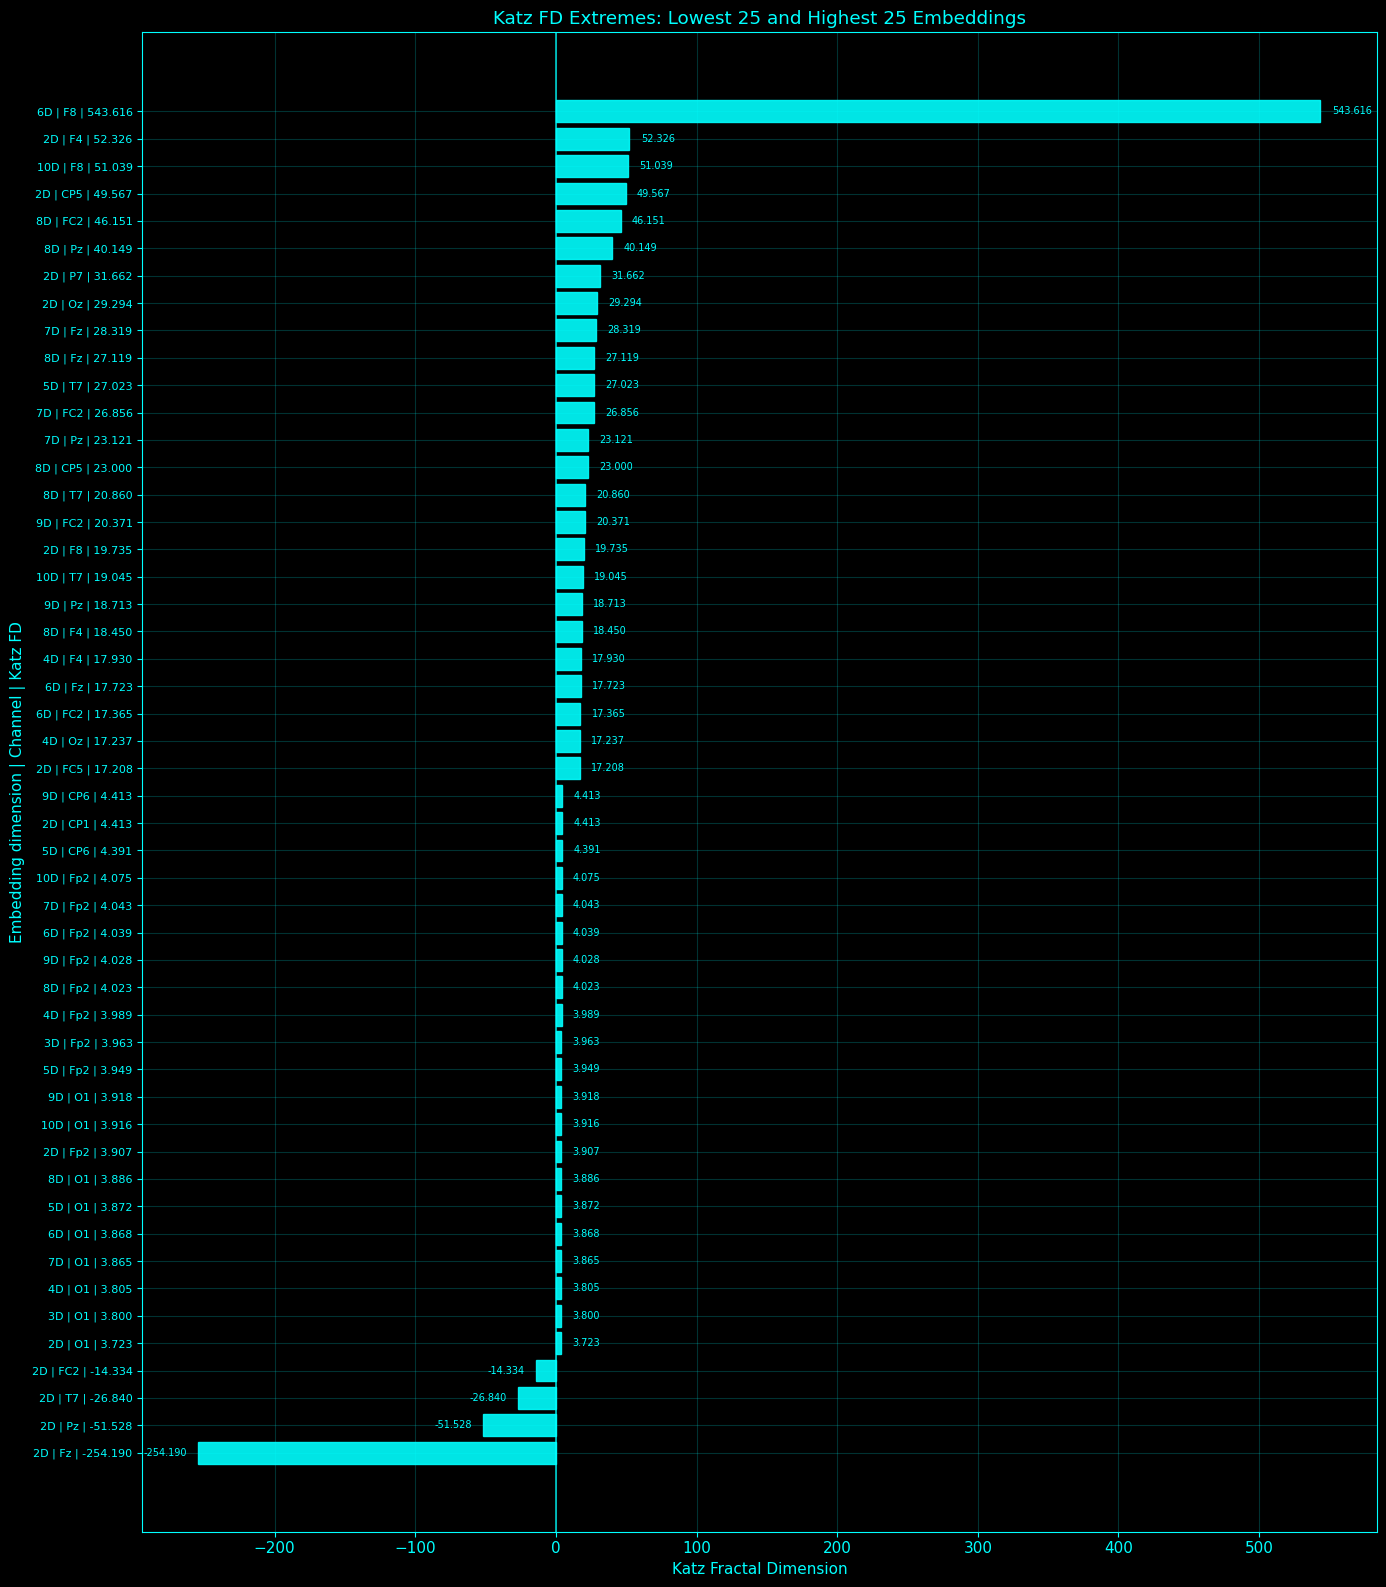


Readable Plot 1 saved to: /home/a/projects/Complete-Neural-Signal-Analysis/results/katz_fractal_dimension/plots/katz_fd_extreme_embeddings_barh_readable.png

PLOT 2 — Mean Katz FD versus Embedding Dimension

What you are seeing:
  - Each point is the average Katz FD for one embedding dimension.
  - The shaded region shows plus and minus one standard deviation.
  - The x-axis is embedding dimension.
  - The y-axis is mean Katz Fractal Dimension.
  - This plot shows whether average trajectory complexity changes as embedding dimension increases.

Patterns to look for:
  - Look for an upward trend; this means Katz FD increases in higher-dimensional embeddings.
  - Look for a flat trend; this means average Katz FD is stable across dimensions.
  - Look for a downward trend; this means higher-dimensional embeddings have lower Katz FD on average.
  - Look for a sudden jump between two adjacent dimensions.
  - Look for a plateau at higher dimensions.
  - Look for large shaded bands; this means

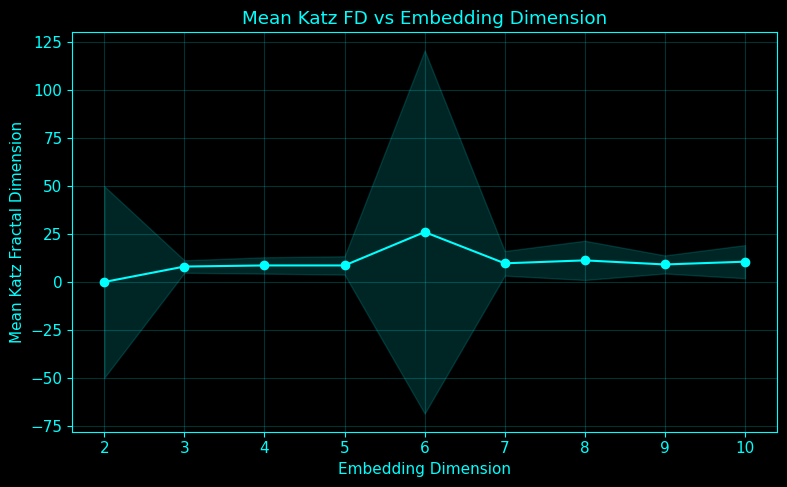


PLOT 3 — Katz FD by Channel and Embedding Dimension

What you are seeing:
  - Each row is one EEG channel.
  - Each column is one embedding dimension.
  - Each cell color represents the Katz FD value for that channel and dimension.
  - Brighter or stronger cells indicate higher Katz FD.
  - Darker cells indicate lower Katz FD.

Patterns to look for:
  - Look for rows that are high across many dimensions; these channels are consistently more winding.
  - Look for rows that are low across many dimensions; these channels are consistently simpler.
  - Look for columns that are high for many channels; that embedding dimension generally raises Katz FD.
  - Look for columns that are low for many channels; that embedding dimension generally lowers Katz FD.
  - Look for isolated bright cells; these may be one-off high-complexity estimates.
  - Look for isolated dark cells; these may be one-off low-complexity estimates.
  - Look for smooth changes from left to right within a row.
  - Look for s

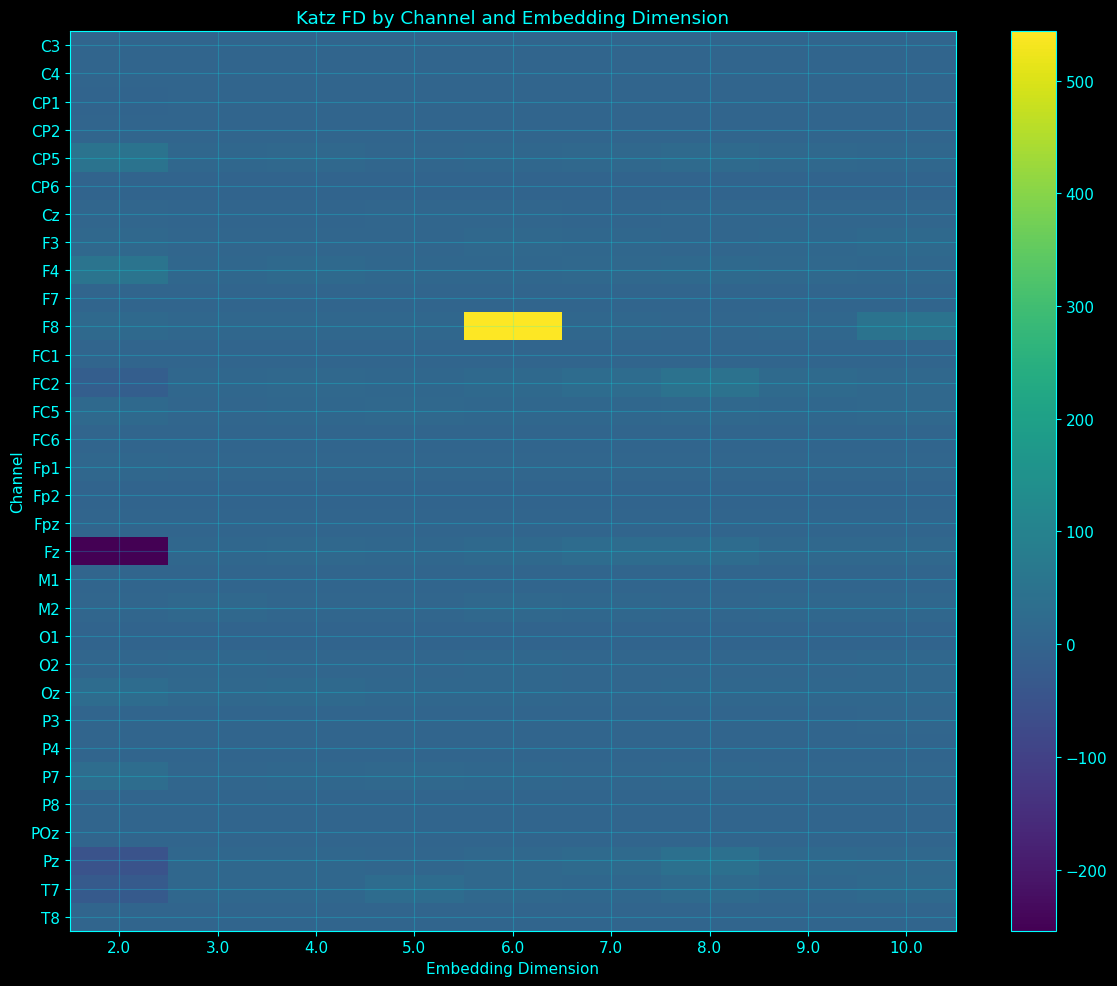


PLOT 4 — Katz FD Trajectories Across Embedding Dimensions

What you are seeing:
  - Each cyan line is one EEG channel.
  - The x-axis is embedding dimension.
  - The y-axis is Katz Fractal Dimension.
  - Each line shows how Katz FD changes for one channel as embedding dimension increases.
  - This plot emphasizes the shape of each channel's dimension trajectory.

Patterns to look for:
  - Look for channels that rise steadily across dimensions.
  - Look for channels that stay nearly flat across dimensions.
  - Look for channels that decrease across dimensions.
  - Look for channels that jump suddenly at one dimension.
  - Look for channels that cross each other; this means rankings change with dimension.
  - Look for a tight bundle of lines; this means channels behave similarly.
  - Look for a wide spread of lines; this means channels differ strongly.
  - Look for outlier trajectories far above the rest.
  - Look for outlier trajectories far below the rest.
  - Look for whether high-di

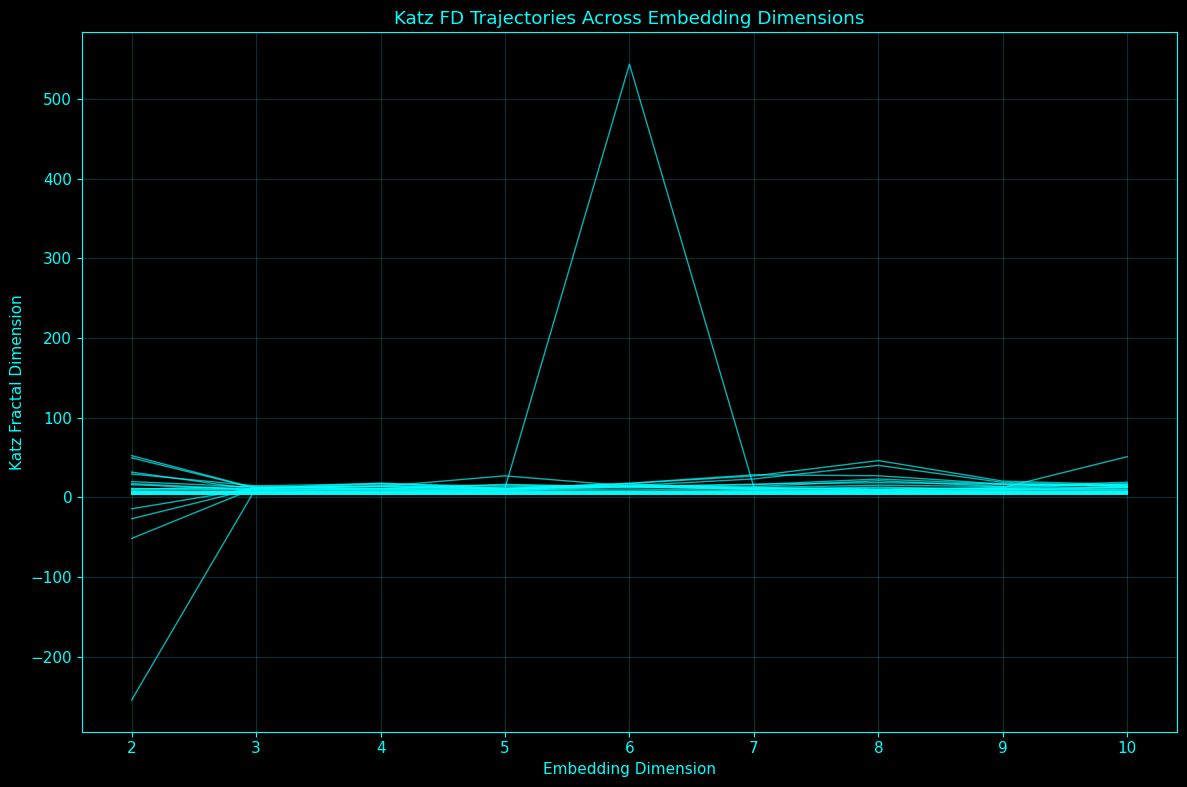


Saved main CSV: /home/a/projects/Complete-Neural-Signal-Analysis/results/katz_fractal_dimension/katz_fd_per_embedding.csv
Saved by-dimension CSV: /home/a/projects/Complete-Neural-Signal-Analysis/results/katz_fractal_dimension/katz_fd_by_dimension.csv
Saved by-channel CSV: /home/a/projects/Complete-Neural-Signal-Analysis/results/katz_fractal_dimension/katz_fd_by_channel.csv
Saved matrix CSV: /home/a/projects/Complete-Neural-Signal-Analysis/results/katz_fractal_dimension/katz_fd_channel_dimension_matrix.csv
Saved summary TXT: /home/a/projects/Complete-Neural-Signal-Analysis/results/katz_fractal_dimension/katz_fd_summary.txt
Saved plots to: /home/a/projects/Complete-Neural-Signal-Analysis/results/katz_fractal_dimension/plots


# Interpretation of Katz Fractal Dimension Results

This report interprets the numerical Katz Fractal Dimension results after all plots and tables have been created. The central question is how winding or geometrically indirect the embedded EEG trajectories are, and whether that behavior changes across channels and embedding dimensions.

---

## 1. Overall Katz FD distribution

- Valid Katz FD results: **288**
- Mean Katz FD: **10.2348**
- Median Katz FD: **7.0053**
- Standard deviation: **36.1530**
- Minimum Katz FD: **-254.1904**
- Maximum Katz FD: **543.6163**
- Range: **797.8067**

**Interpretation:** The spread is large. The embedding trajectories differ strongly in path complexity, or some files may be affected by unusual trajectory behavior.

Katz FD is controlled by how much longer the actual trajectory is than the direct start-to-end distance. Values near each other mean the embeddings have similar path tortuosity. A wider spread means some trajectories are much more winding than others.

---

## 2. Highest and lowest individual embeddings

Highest Katz FD embeddings:

- **6dembedded_F8**: channel=F8, embedding_dimension=6.0000, katz_fd=543.6163, n_samples=106924.0000, state_dim=6.0000
- **2dembedded_F4**: channel=F4, embedding_dimension=2.0000, katz_fd=52.3255, n_samples=106941.0000, state_dim=2.0000
- **10dembedded_F8**: channel=F8, embedding_dimension=10.0000, katz_fd=51.0389, n_samples=106908.0000, state_dim=10.0000
- **2dembedded_CP5**: channel=CP5, embedding_dimension=2.0000, katz_fd=49.5666, n_samples=106941.0000, state_dim=2.0000
- **8dembedded_FC2**: channel=FC2, embedding_dimension=8.0000, katz_fd=46.1515, n_samples=106923.0000, state_dim=8.0000
- **8dembedded_Pz**: channel=Pz, embedding_dimension=8.0000, katz_fd=40.1493, n_samples=106923.0000, state_dim=8.0000
- **2dembedded_P7**: channel=P7, embedding_dimension=2.0000, katz_fd=31.6621, n_samples=106941.0000, state_dim=2.0000
- **2dembedded_Oz**: channel=Oz, embedding_dimension=2.0000, katz_fd=29.2941, n_samples=106941.0000, state_dim=2.0000
- **7dembedded_Fz**: channel=Fz, embedding_dimension=7.0000, katz_fd=28.3190, n_samples=106926.0000, state_dim=7.0000
- **8dembedded_Fz**: channel=Fz, embedding_dimension=8.0000, katz_fd=27.1192, n_samples=106923.0000, state_dim=8.0000
- **5dembedded_T7**: channel=T7, embedding_dimension=5.0000, katz_fd=27.0229, n_samples=106936.0000, state_dim=5.0000
- **7dembedded_FC2**: channel=FC2, embedding_dimension=7.0000, katz_fd=26.8560, n_samples=106926.0000, state_dim=7.0000

Lowest Katz FD embeddings:

- **2dembedded_Fz**: channel=Fz, embedding_dimension=2.0000, katz_fd=-254.1904, n_samples=106941.0000, state_dim=2.0000
- **2dembedded_Pz**: channel=Pz, embedding_dimension=2.0000, katz_fd=-51.5278, n_samples=106941.0000, state_dim=2.0000
- **2dembedded_T7**: channel=T7, embedding_dimension=2.0000, katz_fd=-26.8404, n_samples=106941.0000, state_dim=2.0000
- **2dembedded_FC2**: channel=FC2, embedding_dimension=2.0000, katz_fd=-14.3340, n_samples=106941.0000, state_dim=2.0000
- **2dembedded_O1**: channel=O1, embedding_dimension=2.0000, katz_fd=3.7233, n_samples=106941.0000, state_dim=2.0000
- **3dembedded_O1**: channel=O1, embedding_dimension=3.0000, katz_fd=3.7998, n_samples=106938.0000, state_dim=3.0000
- **4dembedded_O1**: channel=O1, embedding_dimension=4.0000, katz_fd=3.8051, n_samples=106932.0000, state_dim=4.0000
- **7dembedded_O1**: channel=O1, embedding_dimension=7.0000, katz_fd=3.8650, n_samples=106920.0000, state_dim=7.0000
- **6dembedded_O1**: channel=O1, embedding_dimension=6.0000, katz_fd=3.8676, n_samples=106924.0000, state_dim=6.0000
- **5dembedded_O1**: channel=O1, embedding_dimension=5.0000, katz_fd=3.8725, n_samples=106928.0000, state_dim=5.0000
- **8dembedded_O1**: channel=O1, embedding_dimension=8.0000, katz_fd=3.8859, n_samples=106916.0000, state_dim=8.0000
- **2dembedded_Fp2**: channel=Fp2, embedding_dimension=2.0000, katz_fd=3.9071, n_samples=106941.0000, state_dim=2.0000

The highest individual Katz FD appears in **6dembedded_F8**, with Katz FD=543.6163. This embedding has the most winding trajectory among the valid files analyzed.

The lowest individual Katz FD appears in **2dembedded_Fz**, with Katz FD=-254.1904. This embedding has the most direct or least winding trajectory among the valid files analyzed.

Individual extremes are useful for finding candidates, but they should not be the only conclusion. A channel that is consistently high across dimensions is stronger evidence than one isolated high file.

---

## 3. Embedding-dimension pattern

- Linear trend of mean Katz FD across embedding dimension: **0.8654**
- Trend interpretation: **The mean Katz FD increases with embedding dimension. This suggests that trajectories become more winding or geometrically indirect in higher-dimensional embeddings.**

The embedding dimension with the highest mean Katz FD is **6D**, with mean Katz FD=26.0350.
The embedding dimension with the lowest mean Katz FD is **2D**, with mean Katz FD=0.0185.

Mean Katz FD by embedding dimension:

- **2.0**: n_records=32.0000, mean_katz_fd=0.0185, std_katz_fd=49.8736, min_katz_fd=-254.1904, max_katz_fd=52.3255
- **3.0**: n_records=32.0000, mean_katz_fd=8.0625, std_katz_fd=3.2501, min_katz_fd=3.7998, max_katz_fd=14.3683
- **4.0**: n_records=32.0000, mean_katz_fd=8.6280, std_katz_fd=4.2654, min_katz_fd=3.8051, max_katz_fd=17.9298
- **5.0**: n_records=32.0000, mean_katz_fd=8.6294, std_katz_fd=4.7774, min_katz_fd=3.8725, max_katz_fd=27.0229
- **6.0**: n_records=32.0000, mean_katz_fd=26.0350, std_katz_fd=94.5578, min_katz_fd=3.8676, max_katz_fd=543.6163
- **7.0**: n_records=32.0000, mean_katz_fd=9.7343, std_katz_fd=6.4044, min_katz_fd=3.8650, max_katz_fd=28.3190
- **8.0**: n_records=32.0000, mean_katz_fd=11.2725, std_katz_fd=10.2202, min_katz_fd=3.8859, max_katz_fd=46.1515
- **9.0**: n_records=32.0000, mean_katz_fd=9.1400, std_katz_fd=4.7060, min_katz_fd=3.9181, max_katz_fd=20.3711
- **10.0**: n_records=32.0000, mean_katz_fd=10.5931, std_katz_fd=8.6316, min_katz_fd=3.9157, max_katz_fd=51.0389

If mean Katz FD increases with embedding dimension, the reconstructed trajectories become more winding in higher-dimensional spaces. If it stays flat, the estimate is more stable across dimensions. If it decreases, the higher-dimensional representation may be making the trajectory more direct relative to its total path length.

---

## 4. Channel-level pattern

Channels with highest mean Katz FD:

- **F8**: n_records=9.0000, mean_katz_fd=76.0368, std_katz_fd=175.8200, min_katz_fd=9.7466, max_katz_fd=543.6163
- **F4**: n_records=9.0000, mean_katz_fd=19.0635, std_katz_fd=12.7498, min_katz_fd=11.1874, max_katz_fd=52.3255
- **CP5**: n_records=9.0000, mean_katz_fd=18.6859, std_katz_fd=12.1530, min_katz_fd=10.2578, max_katz_fd=49.5666
- **FC2**: n_records=9.0000, mean_katz_fd=16.8962, std_katz_fd=15.8175, min_katz_fd=-14.3340, max_katz_fd=46.1515
- **Oz**: n_records=9.0000, mean_katz_fd=14.8597, std_katz_fd=5.7862, min_katz_fd=10.3018, max_katz_fd=29.2941
- **P7**: n_records=9.0000, mean_katz_fd=13.9976, std_katz_fd=6.9469, min_katz_fd=9.7220, max_katz_fd=31.6621
- **FC5**: n_records=9.0000, mean_katz_fd=13.7423, std_katz_fd=2.5421, min_katz_fd=9.6917, max_katz_fd=17.2076
- **F3**: n_records=9.0000, mean_katz_fd=12.3588, std_katz_fd=3.2868, min_katz_fd=9.1092, max_katz_fd=17.0422
- **T7**: n_records=9.0000, mean_katz_fd=11.8671, std_katz_fd=15.3107, min_katz_fd=-26.8404, max_katz_fd=27.0229
- **M2**: n_records=9.0000, mean_katz_fd=11.7179, std_katz_fd=2.0575, min_katz_fd=9.5419, max_katz_fd=15.6637
- **Pz**: n_records=9.0000, mean_katz_fd=10.5970, std_katz_fd=24.9908, min_katz_fd=-51.5278, max_katz_fd=40.1493
- **O2**: n_records=9.0000, mean_katz_fd=10.2137, std_katz_fd=1.8313, min_katz_fd=8.0492, max_katz_fd=13.3956

Channels with lowest mean Katz FD:

- **Fz**: n_records=9.0000, mean_katz_fd=-12.4663, std_katz_fd=90.8512, min_katz_fd=-254.1904, max_katz_fd=28.3190
- **O1**: n_records=9.0000, mean_katz_fd=3.8503, std_katz_fd=0.0631, min_katz_fd=3.7233, max_katz_fd=3.9181
- **Fp2**: n_records=9.0000, mean_katz_fd=4.0017, std_katz_fd=0.0535, min_katz_fd=3.9071, max_katz_fd=4.0746
- **CP6**: n_records=9.0000, mean_katz_fd=4.4412, std_katz_fd=0.0293, min_katz_fd=4.3908, max_katz_fd=4.4713
- **CP1**: n_records=9.0000, mean_katz_fd=4.5725, std_katz_fd=0.0798, min_katz_fd=4.4128, max_katz_fd=4.6570
- **C4**: n_records=9.0000, mean_katz_fd=4.7623, std_katz_fd=0.0461, min_katz_fd=4.6867, max_katz_fd=4.8192
- **M1**: n_records=9.0000, mean_katz_fd=5.1000, std_katz_fd=0.1002, min_katz_fd=4.9451, max_katz_fd=5.2788
- **POz**: n_records=9.0000, mean_katz_fd=5.1132, std_katz_fd=0.1593, min_katz_fd=4.8672, max_katz_fd=5.3309
- **CP2**: n_records=9.0000, mean_katz_fd=5.2982, std_katz_fd=0.0965, min_katz_fd=5.1686, max_katz_fd=5.4563
- **FC6**: n_records=9.0000, mean_katz_fd=5.3381, std_katz_fd=0.0966, min_katz_fd=5.1710, max_katz_fd=5.4497
- **Fpz**: n_records=9.0000, mean_katz_fd=5.3438, std_katz_fd=0.1481, min_katz_fd=5.1541, max_katz_fd=5.5948
- **C3**: n_records=9.0000, mean_katz_fd=5.8376, std_katz_fd=0.1480, min_katz_fd=5.6279, max_katz_fd=6.0467

The channel with the highest average Katz FD is **F8**, with mean Katz FD=76.0368. This channel has the most winding embedded trajectories on average across available dimensions.

The channel with the lowest average Katz FD is **Fz**, with mean Katz FD=-12.4663. This channel has the most direct embedded trajectories on average across available dimensions.

A channel-level conclusion is strongest when a channel is high or low across several embedding dimensions, not only at one dimension. The heatmap and trajectory plot should be used to check this consistency.

---

## 5. Stability across embedding dimensions

Channels with greatest variability across dimensions:

- **F8**: std_katz_fd=175.8200, mean_katz_fd=76.0368, min_katz_fd=9.7466, max_katz_fd=543.6163
- **Fz**: std_katz_fd=90.8512, mean_katz_fd=-12.4663, min_katz_fd=-254.1904, max_katz_fd=28.3190
- **Pz**: std_katz_fd=24.9908, mean_katz_fd=10.5970, min_katz_fd=-51.5278, max_katz_fd=40.1493
- **FC2**: std_katz_fd=15.8175, mean_katz_fd=16.8962, min_katz_fd=-14.3340, max_katz_fd=46.1515
- **T7**: std_katz_fd=15.3107, mean_katz_fd=11.8671, min_katz_fd=-26.8404, max_katz_fd=27.0229
- **F4**: std_katz_fd=12.7498, mean_katz_fd=19.0635, min_katz_fd=11.1874, max_katz_fd=52.3255
- **CP5**: std_katz_fd=12.1530, mean_katz_fd=18.6859, min_katz_fd=10.2578, max_katz_fd=49.5666
- **P7**: std_katz_fd=6.9469, mean_katz_fd=13.9976, min_katz_fd=9.7220, max_katz_fd=31.6621
- **Oz**: std_katz_fd=5.7862, mean_katz_fd=14.8597, min_katz_fd=10.3018, max_katz_fd=29.2941
- **F3**: std_katz_fd=3.2868, mean_katz_fd=12.3588, min_katz_fd=9.1092, max_katz_fd=17.0422
- **FC5**: std_katz_fd=2.5421, mean_katz_fd=13.7423, min_katz_fd=9.6917, max_katz_fd=17.2076
- **M2**: std_katz_fd=2.0575, mean_katz_fd=11.7179, min_katz_fd=9.5419, max_katz_fd=15.6637

Channels with greatest stability across dimensions:

- **CP6**: std_katz_fd=0.0293, mean_katz_fd=4.4412, min_katz_fd=4.3908, max_katz_fd=4.4713
- **C4**: std_katz_fd=0.0461, mean_katz_fd=4.7623, min_katz_fd=4.6867, max_katz_fd=4.8192
- **Fp2**: std_katz_fd=0.0535, mean_katz_fd=4.0017, min_katz_fd=3.9071, max_katz_fd=4.0746
- **O1**: std_katz_fd=0.0631, mean_katz_fd=3.8503, min_katz_fd=3.7233, max_katz_fd=3.9181
- **CP1**: std_katz_fd=0.0798, mean_katz_fd=4.5725, min_katz_fd=4.4128, max_katz_fd=4.6570
- **CP2**: std_katz_fd=0.0965, mean_katz_fd=5.2982, min_katz_fd=5.1686, max_katz_fd=5.4563
- **FC6**: std_katz_fd=0.0966, mean_katz_fd=5.3381, min_katz_fd=5.1710, max_katz_fd=5.4497
- **M1**: std_katz_fd=0.1002, mean_katz_fd=5.1000, min_katz_fd=4.9451, max_katz_fd=5.2788
- **C3**: std_katz_fd=0.1480, mean_katz_fd=5.8376, min_katz_fd=5.6279, max_katz_fd=6.0467
- **Fpz**: std_katz_fd=0.1481, mean_katz_fd=5.3438, min_katz_fd=5.1541, max_katz_fd=5.5948
- **T8**: std_katz_fd=0.1503, mean_katz_fd=5.8528, min_katz_fd=5.6286, max_katz_fd=6.0624
- **POz**: std_katz_fd=0.1593, mean_katz_fd=5.1132, min_katz_fd=4.8672, max_katz_fd=5.3309

The channel with the greatest Katz FD variability across dimensions is **F8**. The channel's Katz FD changes strongly across embedding dimensions and deserves closer inspection.

The channel with the most stable Katz FD across dimensions is **CP6**. The channel's Katz FD changes modestly across embedding dimensions.

High variability across dimensions means the interpretation depends strongly on embedding dimension. Low variability means the channel's Katz FD is more robust to the choice of embedding dimension.

---

## 6. Channel trends across dimensions

Channels with strongest increasing Katz FD trend:

- **Fz**: dimension_slope=18.8619, dimension_range=282.5094, first_dimension_katz_fd=-254.1904, last_dimension_katz_fd=14.4835, last_minus_first=268.6739
- **Pz**: dimension_slope=5.8315, dimension_range=91.6771, first_dimension_katz_fd=-51.5278, last_dimension_katz_fd=14.4091, last_minus_first=65.9368
- **FC2**: dimension_slope=3.7006, dimension_range=60.4854, first_dimension_katz_fd=-14.3340, last_dimension_katz_fd=15.9922, last_minus_first=30.3262
- **T7**: dimension_slope=3.1756, dimension_range=53.8634, first_dimension_katz_fd=-26.8404, last_dimension_katz_fd=19.0454, last_minus_first=45.8859
- **F8**: dimension_slope=2.0368, dimension_range=533.8697, first_dimension_katz_fd=19.7352, last_dimension_katz_fd=51.0389, last_minus_first=31.3038
- **FC5**: dimension_slope=0.2313, dimension_range=7.5159, first_dimension_katz_fd=17.2076, last_dimension_katz_fd=16.3188, last_minus_first=-0.8888
- **F3**: dimension_slope=0.2277, dimension_range=7.9331, first_dimension_katz_fd=15.9360, last_dimension_katz_fd=17.0422, last_minus_first=1.1062
- **P3**: dimension_slope=0.1092, dimension_range=1.6086, first_dimension_katz_fd=6.8991, last_dimension_katz_fd=7.9781, last_minus_first=1.0790
- **P8**: dimension_slope=0.0859, dimension_range=0.9399, first_dimension_katz_fd=5.3981, last_dimension_katz_fd=6.3380, last_minus_first=0.9399
- **P4**: dimension_slope=0.0744, dimension_range=0.8427, first_dimension_katz_fd=6.7664, last_dimension_katz_fd=7.4610, last_minus_first=0.6946

Channels with strongest decreasing Katz FD trend:

- **F4**: dimension_slope=-2.2203, dimension_range=41.1381, first_dimension_katz_fd=52.3255, last_dimension_katz_fd=13.6689, last_minus_first=-38.6566
- **CP5**: dimension_slope=-1.7480, dimension_range=39.3088, first_dimension_katz_fd=49.5666, last_dimension_katz_fd=13.8043, last_minus_first=-35.7623
- **Oz**: dimension_slope=-1.5317, dimension_range=18.9923, first_dimension_katz_fd=29.2941, last_dimension_katz_fd=12.3288, last_minus_first=-16.9652
- **P7**: dimension_slope=-1.4709, dimension_range=21.9401, first_dimension_katz_fd=31.6621, last_dimension_katz_fd=10.4189, last_minus_first=-21.2432
- **F7**: dimension_slope=-0.0429, dimension_range=0.8558, first_dimension_katz_fd=7.5561, last_dimension_katz_fd=7.1896, last_minus_first=-0.3664
- **Fp1**: dimension_slope=-0.0369, dimension_range=3.4639, first_dimension_katz_fd=11.2725, last_dimension_katz_fd=10.0625, last_minus_first=-1.2101
- **T8**: dimension_slope=-0.0099, dimension_range=0.4338, first_dimension_katz_fd=6.0624, last_dimension_katz_fd=5.9832, last_minus_first=-0.0791
- **FC6**: dimension_slope=-0.0016, dimension_range=0.2787, first_dimension_katz_fd=5.4361, last_dimension_katz_fd=5.4497, last_minus_first=0.0137
- **CP6**: dimension_slope=-0.0003, dimension_range=0.0805, first_dimension_katz_fd=4.4290, last_dimension_katz_fd=4.4612, last_minus_first=0.0322
- **C4**: dimension_slope=0.0147, dimension_range=0.1325, first_dimension_katz_fd=4.6867, last_dimension_katz_fd=4.7959, last_minus_first=0.1092

Channels with flattest Katz FD trend across dimensions:

- **CP6**: dimension_slope=-0.0003, dimension_range=0.0805, first_dimension_katz_fd=4.4290, last_dimension_katz_fd=4.4612, last_minus_first=0.0322
- **FC6**: dimension_slope=-0.0016, dimension_range=0.2787, first_dimension_katz_fd=5.4361, last_dimension_katz_fd=5.4497, last_minus_first=0.0137
- **T8**: dimension_slope=-0.0099, dimension_range=0.4338, first_dimension_katz_fd=6.0624, last_dimension_katz_fd=5.9832, last_minus_first=-0.0791
- **C4**: dimension_slope=0.0147, dimension_range=0.1325, first_dimension_katz_fd=4.6867, last_dimension_katz_fd=4.7959, last_minus_first=0.1092
- **Fp2**: dimension_slope=0.0171, dimension_range=0.1675, first_dimension_katz_fd=3.9071, last_dimension_katz_fd=4.0746, last_minus_first=0.1675
- **M1**: dimension_slope=0.0192, dimension_range=0.3338, first_dimension_katz_fd=5.1071, last_dimension_katz_fd=5.2788, last_minus_first=0.1718
- **O1**: dimension_slope=0.0213, dimension_range=0.1948, first_dimension_katz_fd=3.7233, last_dimension_katz_fd=3.9157, last_minus_first=0.1923
- **Cz**: dimension_slope=0.0231, dimension_range=1.2046, first_dimension_katz_fd=8.3190, last_dimension_katz_fd=8.0222, last_minus_first=-0.2969
- **CP1**: dimension_slope=0.0240, dimension_range=0.2442, first_dimension_katz_fd=4.4128, last_dimension_katz_fd=4.6570, last_minus_first=0.2442
- **CP2**: dimension_slope=0.0286, dimension_range=0.2878, first_dimension_katz_fd=5.1686, last_dimension_katz_fd=5.4563, last_minus_first=0.2878

A strongly increasing channel becomes more winding as embedding dimension increases. A strongly decreasing channel becomes less winding relative to its total path length. A flat channel is more stable across embedding dimensions and may be easier to interpret.

---

## 7. What makes a result stronger

The strongest Katz FD interpretations are supported by several signs at once:

- The channel has high mean Katz FD across dimensions.
- The channel appears high in the heatmap across several columns.
- The channel trajectory is stable rather than erratic.
- The result is not caused by one isolated embedding file.
- The trend across dimensions is interpretable rather than noisy.
- The highest channels make sense when compared with the full ranking plot.

Findings that need caution:

- One isolated embedding has very high Katz FD while the same channel is ordinary elsewhere.
- A channel has high variability across dimensions.
- A heatmap cell is extreme but the trajectory plot shows instability.
- Results are dominated by one embedding dimension.
- Very high Katz FD appears in only one file and not in the channel mean.
- Missing values or file-loading issues affect the channel-by-dimension matrix.

---

## 8. Final synthesis

The strongest average high-complexity channel candidate is **F8**. The strongest individual high-complexity embedding candidate is **6dembedded_F8**. The embedding dimension with the highest average Katz FD is **6D**. The channel with the flattest Katz FD trend across dimensions is **CP6**. 

The safest conclusion is not simply that one file has the largest Katz FD. The stronger conclusion is that an EEG channel shows consistently higher embedded trajectory complexity when its Katz FD is high across multiple embedding dimensions, stable enough to trust, and visible in both the heatmap and trajectory plot.

---

## 9. One-sentence takeaway

Katz FD measures how winding each embedded EEG trajectory is, and the most reliable findings are the ones that remain consistent across channels, embedding dimensions, summary tables, and plots.


In [12]:
import os
import glob
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from IPython.display import Markdown, display
    CAN_DISPLAY_MARKDOWN = True
except Exception:
    Markdown = None
    display = None
    CAN_DISPLAY_MARKDOWN = False

# -------------------------------------------------------
# CONFIG
# -------------------------------------------------------
base_dir = "/home/a/projects/Complete-Neural-Signal-Analysis"

embedding_dirs = [
    os.path.join(base_dir, "embedding_data", "2dembedding_data"),
    os.path.join(base_dir, "embedding_data", "3dembedding_data"),
    os.path.join(base_dir, "embedding_data", "embeddings_4to10"),
]

out_dir = os.path.join(base_dir, "results", "katz_fractal_dimension")
plots_dir = os.path.join(out_dir, "plots")
os.makedirs(out_dir, exist_ok=True)
os.makedirs(plots_dir, exist_ok=True)

ACCENT = "cyan"
BG = "black"
eps = 1e-12

plt.rcParams.update({
    "figure.facecolor": BG,
    "axes.facecolor": BG,
    "savefig.facecolor": BG,
    "text.color": ACCENT,
    "axes.labelcolor": ACCENT,
    "axes.edgecolor": ACCENT,
    "axes.titlecolor": ACCENT,
    "xtick.color": ACCENT,
    "ytick.color": ACCENT,
    "grid.color": ACCENT,
})

# -------------------------------------------------------
# STYLE
# -------------------------------------------------------
def style_ax(ax):
    ax.set_facecolor(BG)
    ax.tick_params(colors=ACCENT)
    ax.grid(True, alpha=0.20, color=ACCENT)
    for spine in ax.spines.values():
        spine.set_color(ACCENT)

# -------------------------------------------------------
# DESCRIPTION HELPER FOR PLOTS
# -------------------------------------------------------
def print_plot_description(title, what_you_see, patterns_to_look_for, cautions=None):
    print("\n" + "=" * 92)
    print(title)
    print("=" * 92)
    print("\nWhat you are seeing:")
    for item in what_you_see:
        print(f"  - {item}")
    print("\nPatterns to look for:")
    for item in patterns_to_look_for:
        print(f"  - {item}")
    if cautions:
        print("\nCautions:")
        for item in cautions:
            print(f"  - {item}")
    print("=" * 92 + "\n")

# -------------------------------------------------------
# HELPERS
# -------------------------------------------------------
def gather_embedding_files(search_dirs):
    files = []
    used_dirs = []
    for d in search_dirs:
        if os.path.isdir(d):
            these = sorted(glob.glob(os.path.join(d, "*.npy")))
            if these:
                used_dirs.append(d)
                files.extend(these)
    return used_dirs, sorted(files)

def infer_embedding_dim(stem, data):
    m = re.match(r"^(\d+)dembedded_", stem)
    if m:
        return int(m.group(1))
    if data.ndim == 2:
        return int(data.shape[1])
    return np.nan

def infer_channel_name(stem):
    if "dembedded_" in stem:
        return stem.split("dembedded_", 1)[1]
    return stem

def katz_fd(data):
    """
    Katz fractal dimension for a trajectory.

    Works for:
    - 1D signal: shape (N,)
    - embedded trajectory: shape (N, D)
    """
    x = np.asarray(data, dtype=float)

    if x.ndim == 1:
        n = len(x)
        if n < 2:
            return np.nan

        step_dist = np.abs(np.diff(x))
        L = np.sum(step_dist)
        d = np.abs(x[-1] - x[0])

    elif x.ndim == 2:
        n = x.shape[0]
        if n < 2:
            return np.nan

        diffs = np.diff(x, axis=0)
        step_dist = np.sqrt(np.sum(diffs ** 2, axis=1))
        L = np.sum(step_dist)
        d = np.sqrt(np.sum((x[-1] - x[0]) ** 2))

    else:
        raise ValueError(f"Unsupported array shape for Katz FD: {x.shape}")

    if L <= 0 or d <= 0:
        return np.nan

    fd = np.log10(n) / (np.log10(d / (L + eps)) + np.log10(n) + eps)
    return float(fd)

def fmt(x, digits=4):
    try:
        if x is None or not np.isfinite(x):
            return "not available"
        return f"{x:.{digits}f}"
    except Exception:
        return str(x)

def bullet_rows(df, name_col, value_cols, n=10):
    if df is None or len(df) == 0:
        return "- No values available."

    lines = []

    for _, row in df.head(n).iterrows():
        name = row.get(name_col, "unknown")
        pieces = []
        for col in value_cols:
            if col in row:
                pieces.append(f"{col}={fmt(row[col])}")
        lines.append(f"- **{name}**: " + ", ".join(pieces))

    return "\n".join(lines)

def describe_spread(value_range):
    if not np.isfinite(value_range):
        return "The spread cannot be summarized because valid values are unavailable."
    if value_range < 0.02:
        return "The spread is very small. Katz FD values are tightly clustered, so the embeddings have similar path complexity."
    if value_range < 0.05:
        return "The spread is modest. Some embeddings differ, but the differences should be interpreted carefully."
    if value_range < 0.10:
        return "The spread is noticeable. Some embeddings are meaningfully more winding or complex than others."
    return "The spread is large. The embedding trajectories differ strongly in path complexity, or some files may be affected by unusual trajectory behavior."

def describe_dimension_trend(slope):
    if not np.isfinite(slope):
        return "The trend across embedding dimension cannot be summarized because the slope is unavailable."
    if abs(slope) < 0.005:
        return "The mean Katz FD is nearly flat across embedding dimensions. This suggests that the average path-complexity estimate is fairly stable as dimension changes."
    if slope > 0:
        return "The mean Katz FD increases with embedding dimension. This suggests that trajectories become more winding or geometrically indirect in higher-dimensional embeddings."
    return "The mean Katz FD decreases with embedding dimension. This suggests that higher-dimensional embeddings may make the trajectory more direct relative to its total path length."

def describe_channel_variability(std_value):
    if not np.isfinite(std_value):
        return "The channel variability cannot be summarized because valid values are unavailable."
    if std_value < 0.01:
        return "The channel's Katz FD is very stable across embedding dimensions."
    if std_value < 0.03:
        return "The channel's Katz FD changes modestly across embedding dimensions."
    return "The channel's Katz FD changes strongly across embedding dimensions and deserves closer inspection."

# -------------------------------------------------------
# FIND FILES
# -------------------------------------------------------
used_dirs, file_paths = gather_embedding_files(embedding_dirs)

if not file_paths:
    raise FileNotFoundError(
        "No embedding .npy files found in:\n" + "\n".join(embedding_dirs)
    )

print("Using embedding directories:")
for d in used_dirs:
    print(" ", d)

print(f"\nFound {len(file_paths)} embedding files total.")

# -------------------------------------------------------
# COMPUTE KATZ FD
# -------------------------------------------------------
records = []

for idx, fp in enumerate(file_paths, start=1):
    file_name = os.path.basename(fp)
    stem = os.path.splitext(file_name)[0]

    rec = {
        "file": file_name,
        "stem": stem,
        "path": fp,
        "source_dir": os.path.basename(os.path.dirname(fp)),
        "channel": None,
        "embedding_dimension": None,
        "n_samples": None,
        "state_dim": None,
        "katz_fd": np.nan,
        "status": "ok",
        "error": "",
    }

    try:
        data = np.load(fp, allow_pickle=True)
        data = np.asarray(data, dtype=float)

        rec["n_samples"] = int(data.shape[0]) if data.ndim >= 1 else np.nan
        rec["state_dim"] = int(data.shape[1]) if data.ndim == 2 else 1
        rec["embedding_dimension"] = infer_embedding_dim(stem, data)
        rec["channel"] = infer_channel_name(stem)
        rec["katz_fd"] = katz_fd(data)

        print(f"[{idx}/{len(file_paths)}] {file_name} -> Katz FD = {rec['katz_fd']:.6f}")

    except Exception as e:
        rec["status"] = "error"
        rec["error"] = f"{type(e).__name__}: {e}"
        print(f"[{idx}/{len(file_paths)}] {file_name} -> ERROR: {rec['error']}")

    records.append(rec)

df = pd.DataFrame(records)

# -------------------------------------------------------
# SAVE MAIN CSV
# -------------------------------------------------------
results_csv = os.path.join(out_dir, "katz_fd_per_embedding.csv")
df.to_csv(results_csv, index=False)

# -------------------------------------------------------
# FILTER SUCCESSFUL RESULTS
# -------------------------------------------------------
df_ok = df[df["status"] == "ok"].copy()
df_ok = df_ok[np.isfinite(df_ok["katz_fd"])].copy()

if df_ok.empty:
    raise ValueError("No valid Katz FD results were computed.")

# -------------------------------------------------------
# SUMMARY TABLES
# -------------------------------------------------------
by_dim_df = (
    df_ok.groupby("embedding_dimension", dropna=True)
    .agg(
        n_records=("katz_fd", "count"),
        mean_katz_fd=("katz_fd", "mean"),
        std_katz_fd=("katz_fd", "std"),
        min_katz_fd=("katz_fd", "min"),
        max_katz_fd=("katz_fd", "max"),
    )
    .reset_index()
    .sort_values("embedding_dimension")
)

by_channel_df = (
    df_ok.groupby("channel", dropna=True)
    .agg(
        n_records=("katz_fd", "count"),
        mean_katz_fd=("katz_fd", "mean"),
        std_katz_fd=("katz_fd", "std"),
        min_katz_fd=("katz_fd", "min"),
        max_katz_fd=("katz_fd", "max"),
    )
    .reset_index()
    .sort_values("channel")
)

channel_dim_matrix = df_ok.pivot_table(
    index="channel",
    columns="embedding_dimension",
    values="katz_fd",
    aggfunc="mean"
).sort_index()

by_dim_csv = os.path.join(out_dir, "katz_fd_by_dimension.csv")
by_channel_csv = os.path.join(out_dir, "katz_fd_by_channel.csv")
matrix_csv = os.path.join(out_dir, "katz_fd_channel_dimension_matrix.csv")

by_dim_df.to_csv(by_dim_csv, index=False)
by_channel_df.to_csv(by_channel_csv, index=False)
channel_dim_matrix.to_csv(matrix_csv)

summary_txt = os.path.join(out_dir, "katz_fd_summary.txt")
with open(summary_txt, "w") as f:
    f.write("Katz Fractal Dimension Summary\n")
    f.write("=============================\n\n")
    f.write(f"Total files found: {len(file_paths)}\n")
    f.write(f"Successful results: {len(df_ok)}\n")
    f.write(f"Errors: {int((df['status'] == 'error').sum())}\n\n")

    f.write("Embedding directories used:\n")
    for d in used_dirs:
        f.write(f"  {d}\n")

    f.write("\nMean Katz FD by embedding dimension:\n")
    for _, row in by_dim_df.iterrows():
        f.write(
            f"  {int(row['embedding_dimension'])}D: "
            f"n={int(row['n_records'])}, "
            f"mean={row['mean_katz_fd']:.6f}, "
            f"std={0.0 if pd.isna(row['std_katz_fd']) else row['std_katz_fd']:.6f}\n"
        )

# -------------------------------------------------------
# PLOT 1: READABLE BARH OF EXTREME EMBEDDINGS ONLY
# -------------------------------------------------------
print_plot_description(
    title="PLOT 1 — Highest and Lowest Katz FD Embeddings",
    what_you_see=[
        "This plot shows only the most extreme Katz FD values, not every embedding file.",
        "The upper group contains the highest Katz FD embeddings.",
        "The lower group contains the lowest Katz FD embeddings.",
        "Each horizontal bar is one embedding file.",
        "The x-axis is Katz Fractal Dimension.",
        "The y-axis label shows embedding dimension and EEG channel.",
        "This version avoids the unreadable label crowding that happens when hundreds of embeddings are plotted at once.",
    ],
    patterns_to_look_for=[
        "Look for the highest positive Katz FD values; these embeddings have the most winding trajectories.",
        "Look for extremely large positive values; these may be real, but they may also indicate numerical instability.",
        "Look for negative Katz FD values; these usually require caution because Katz FD is expected to be positive in ordinary interpretation.",
        "Look for whether extreme values come from one channel repeatedly.",
        "Look for whether extreme values come from one embedding dimension repeatedly.",
        "Look for whether one embedding is far away from all others.",
        "Look for whether high and low extremes are symmetric or whether one side is much more extreme.",
        "Look for whether the same channel appears in both high and low extremes at different embedding dimensions.",
        "Look for whether 2D, 3D, or higher-dimensional embeddings dominate the extremes.",
        "Look for values that are so large that they compress the rest of the plot.",
    ],
    cautions=[
        "Very large positive or negative Katz FD values often occur when the end-to-end distance is very small compared with the total path length.",
        "A negative Katz FD value should not be interpreted as normal low complexity; it is usually a warning sign for the formula geometry or the trajectory endpoint relation.",
        "This plot is for identifying extreme cases. Use the heatmap and channel summaries for stable channel-level interpretation.",
    ],
)

# Sort all valid embeddings
plot_df_all = df_ok.copy()
plot_df_all = plot_df_all[np.isfinite(plot_df_all["katz_fd"])].copy()

# Number of extremes to display from each end
N_EXTREME = 25

lowest_df = plot_df_all.sort_values("katz_fd", ascending=True).head(N_EXTREME)
highest_df = plot_df_all.sort_values("katz_fd", ascending=False).head(N_EXTREME)

# Combine lowest and highest extremes, remove duplicates in case dataset is small
plot_df = pd.concat([lowest_df, highest_df], axis=0)
plot_df = plot_df.drop_duplicates(subset=["file", "stem", "channel", "embedding_dimension"])
plot_df = plot_df.sort_values("katz_fd", ascending=True).reset_index(drop=True)

# Create readable labels
plot_df["readable_label"] = (
    plot_df["embedding_dimension"].astype("Int64").astype(str)
    + "D | "
    + plot_df["channel"].astype(str)
    + " | "
    + plot_df["katz_fd"].map(lambda x: f"{x:.3f}" if np.isfinite(x) else "nan")
)

print("Lowest Katz FD embeddings shown in Plot 1:")
print(
    lowest_df[
        ["stem", "channel", "embedding_dimension", "katz_fd", "n_samples", "state_dim"]
    ].to_string(index=False)
)

print("\nHighest Katz FD embeddings shown in Plot 1:")
print(
    highest_df[
        ["stem", "channel", "embedding_dimension", "katz_fd", "n_samples", "state_dim"]
    ].to_string(index=False)
)

# Outlier warning
negative_count = int((plot_df_all["katz_fd"] < 0).sum())
very_large_count = int((plot_df_all["katz_fd"].abs() > 10).sum())

print("\nKatz FD value check:")
print(f"  Negative Katz FD values: {negative_count}")
print(f"  Absolute Katz FD values greater than 10: {very_large_count}")

if negative_count > 0 or very_large_count > 0:
    print(
        "\nWarning: Some Katz FD values are extreme or negative. "
        "This usually happens when the trajectory's end-to-end distance is very small "
        "relative to the total path length, making the Katz formula numerically unstable. "
        "Inspect these embeddings before treating them as ordinary complexity values."
    )

# Dynamic figure height based on number of displayed rows
fig_height = max(8, 0.32 * len(plot_df))

fig, ax = plt.subplots(figsize=(14, fig_height), facecolor=BG)
style_ax(ax)

y_positions = np.arange(len(plot_df))

ax.barh(
    y_positions,
    plot_df["katz_fd"].values,
    color=ACCENT,
    edgecolor=ACCENT,
    alpha=0.9
)

ax.axvline(0, color=ACCENT, linewidth=1.2, alpha=0.8)

ax.set_yticks(y_positions)
ax.set_yticklabels(plot_df["readable_label"].values, fontsize=8, color=ACCENT)

ax.set_title(
    f"Katz FD Extremes: Lowest {N_EXTREME} and Highest {N_EXTREME} Embeddings"
)
ax.set_xlabel("Katz Fractal Dimension")
ax.set_ylabel("Embedding dimension | Channel | Katz FD")

# Add value labels at the end of bars
x_values = plot_df["katz_fd"].values
x_min = np.nanmin(x_values)
x_max = np.nanmax(x_values)
x_range = x_max - x_min if np.isfinite(x_max - x_min) and x_max > x_min else 1.0
label_offset = 0.01 * x_range

for i, val in enumerate(x_values):
    if not np.isfinite(val):
        continue

    if val >= 0:
        ha = "left"
        x_text = val + label_offset
    else:
        ha = "right"
        x_text = val - label_offset

    ax.text(
        x_text,
        i,
        f"{val:.3f}",
        va="center",
        ha=ha,
        fontsize=7,
        color=ACCENT
    )

plot1_path = os.path.join(plots_dir, "katz_fd_extreme_embeddings_barh_readable.png")
plt.tight_layout()
plt.savefig(plot1_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()

print(f"\nReadable Plot 1 saved to: {plot1_path}")

# -------------------------------------------------------
# PLOT 2: MEAN KATZ FD VS EMBEDDING DIMENSION
# -------------------------------------------------------
print_plot_description(
    title="PLOT 2 — Mean Katz FD versus Embedding Dimension",
    what_you_see=[
        "Each point is the average Katz FD for one embedding dimension.",
        "The shaded region shows plus and minus one standard deviation.",
        "The x-axis is embedding dimension.",
        "The y-axis is mean Katz Fractal Dimension.",
        "This plot shows whether average trajectory complexity changes as embedding dimension increases.",
    ],
    patterns_to_look_for=[
        "Look for an upward trend; this means Katz FD increases in higher-dimensional embeddings.",
        "Look for a flat trend; this means average Katz FD is stable across dimensions.",
        "Look for a downward trend; this means higher-dimensional embeddings have lower Katz FD on average.",
        "Look for a sudden jump between two adjacent dimensions.",
        "Look for a plateau at higher dimensions.",
        "Look for large shaded bands; this means channels vary strongly at that dimension.",
        "Look for small shaded bands; this means channels agree more strongly at that dimension.",
        "Look for dimensions where the mean changes but the variability also becomes large.",
        "Look for whether the first few dimensions behave differently from later dimensions.",
        "Look for whether higher dimensions stabilize or continue changing.",
    ],
    cautions=[
        "The mean can be pulled by a few extreme channels.",
        "The shaded band should be considered before interpreting the line alone.",
        "An increasing trend may reflect richer geometry, but it may also reflect how the embedding construction changes with dimension.",
    ],
)

fig, ax = plt.subplots(figsize=(8, 5), facecolor=BG)
style_ax(ax)

x = by_dim_df["embedding_dimension"].values
y = by_dim_df["mean_katz_fd"].values
s = by_dim_df["std_katz_fd"].fillna(0.0).values

print("Mean Katz FD by embedding dimension:")
print(by_dim_df.to_string(index=False))

ax.plot(x, y, marker="o", color=ACCENT, linewidth=1.5)
ax.fill_between(x, y - s, y + s, color=ACCENT, alpha=0.15)
ax.set_title("Mean Katz FD vs Embedding Dimension")
ax.set_xlabel("Embedding Dimension")
ax.set_ylabel("Mean Katz Fractal Dimension")

plot2_path = os.path.join(plots_dir, "mean_katz_fd_vs_dimension.png")
plt.tight_layout()
plt.savefig(plot2_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# -------------------------------------------------------
# PLOT 3: CHANNEL x DIMENSION HEATMAP
# -------------------------------------------------------
print_plot_description(
    title="PLOT 3 — Katz FD by Channel and Embedding Dimension",
    what_you_see=[
        "Each row is one EEG channel.",
        "Each column is one embedding dimension.",
        "Each cell color represents the Katz FD value for that channel and dimension.",
        "Brighter or stronger cells indicate higher Katz FD.",
        "Darker cells indicate lower Katz FD.",
    ],
    patterns_to_look_for=[
        "Look for rows that are high across many dimensions; these channels are consistently more winding.",
        "Look for rows that are low across many dimensions; these channels are consistently simpler.",
        "Look for columns that are high for many channels; that embedding dimension generally raises Katz FD.",
        "Look for columns that are low for many channels; that embedding dimension generally lowers Katz FD.",
        "Look for isolated bright cells; these may be one-off high-complexity estimates.",
        "Look for isolated dark cells; these may be one-off low-complexity estimates.",
        "Look for smooth changes from left to right within a row.",
        "Look for sudden jumps between adjacent dimensions.",
        "Look for channel groups that show similar patterns.",
        "Look for whether frontal, central, parietal, or occipital channels behave similarly.",
    ],
    cautions=[
        "Missing values are displayed as zero in the plotted matrix, so check the CSV for true missingness.",
        "A stable high row is more convincing than one isolated bright cell.",
        "Heatmap color is relative to the plotted data range.",
    ],
)

fig, ax = plt.subplots(figsize=(12, 10), facecolor=BG)
style_ax(ax)

heat_vals = channel_dim_matrix.values.astype(float)
plot_vals = np.where(np.isnan(heat_vals), 0.0, heat_vals)

print("Channel x dimension Katz FD matrix:")
print(channel_dim_matrix.to_string())

im = ax.imshow(plot_vals, aspect="auto")
ax.set_title("Katz FD by Channel and Embedding Dimension")
ax.set_xlabel("Embedding Dimension")
ax.set_ylabel("Channel")
ax.set_xticks(np.arange(len(channel_dim_matrix.columns)))
ax.set_xticklabels(channel_dim_matrix.columns.values)
ax.set_yticks(np.arange(len(channel_dim_matrix.index)))
ax.set_yticklabels(channel_dim_matrix.index.values)

cbar = plt.colorbar(im, ax=ax)
cbar.outline.set_edgecolor(ACCENT)
cbar.ax.tick_params(color=ACCENT)
for label in cbar.ax.get_yticklabels():
    label.set_color(ACCENT)

plot3_path = os.path.join(plots_dir, "katz_fd_channel_dimension_heatmap.png")
plt.tight_layout()
plt.savefig(plot3_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# -------------------------------------------------------
# PLOT 4: CHANNEL TRAJECTORIES ACROSS DIMENSIONS
# -------------------------------------------------------
print_plot_description(
    title="PLOT 4 — Katz FD Trajectories Across Embedding Dimensions",
    what_you_see=[
        "Each cyan line is one EEG channel.",
        "The x-axis is embedding dimension.",
        "The y-axis is Katz Fractal Dimension.",
        "Each line shows how Katz FD changes for one channel as embedding dimension increases.",
        "This plot emphasizes the shape of each channel's dimension trajectory.",
    ],
    patterns_to_look_for=[
        "Look for channels that rise steadily across dimensions.",
        "Look for channels that stay nearly flat across dimensions.",
        "Look for channels that decrease across dimensions.",
        "Look for channels that jump suddenly at one dimension.",
        "Look for channels that cross each other; this means rankings change with dimension.",
        "Look for a tight bundle of lines; this means channels behave similarly.",
        "Look for a wide spread of lines; this means channels differ strongly.",
        "Look for outlier trajectories far above the rest.",
        "Look for outlier trajectories far below the rest.",
        "Look for whether high-dimensional values converge or diverge.",
    ],
    cautions=[
        "This plot can become visually dense when many channels are included.",
        "A line that changes sharply should be checked in the heatmap and CSV.",
        "Trajectory shape across dimensions is often more informative than one value alone.",
    ],
)

fig, ax = plt.subplots(figsize=(12, 8), facecolor=BG)
style_ax(ax)

for ch in channel_dim_matrix.index:
    y = channel_dim_matrix.loc[ch].values.astype(float)
    x = np.array(channel_dim_matrix.columns.values, dtype=float)
    mask = np.isfinite(y)
    if np.sum(mask) >= 2:
        ax.plot(x[mask], y[mask], color=ACCENT, linewidth=1.0, alpha=0.7)

ax.set_title("Katz FD Trajectories Across Embedding Dimensions")
ax.set_xlabel("Embedding Dimension")
ax.set_ylabel("Katz Fractal Dimension")

plot4_path = os.path.join(plots_dir, "katz_fd_trajectories_across_dimensions.png")
plt.tight_layout()
plt.savefig(plot4_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()

print(f"\nSaved main CSV: {results_csv}")
print(f"Saved by-dimension CSV: {by_dim_csv}")
print(f"Saved by-channel CSV: {by_channel_csv}")
print(f"Saved matrix CSV: {matrix_csv}")
print(f"Saved summary TXT: {summary_txt}")
print(f"Saved plots to: {plots_dir}")

# -------------------------------------------------------
# FINAL NUMERICAL INTERPRETATION
# -------------------------------------------------------
all_values = df_ok["katz_fd"].to_numpy(dtype=float)
global_mean = float(np.nanmean(all_values))
global_median = float(np.nanmedian(all_values))
global_std = float(np.nanstd(all_values, ddof=1)) if len(all_values) > 1 else 0.0
global_min = float(np.nanmin(all_values))
global_max = float(np.nanmax(all_values))
global_range = global_max - global_min

highest_embeddings = df_ok.sort_values("katz_fd", ascending=False).copy()
lowest_embeddings = df_ok.sort_values("katz_fd", ascending=True).copy()

highest_channels = by_channel_df.sort_values("mean_katz_fd", ascending=False).copy()
lowest_channels = by_channel_df.sort_values("mean_katz_fd", ascending=True).copy()
most_variable_channels = by_channel_df.sort_values("std_katz_fd", ascending=False).copy()
most_stable_channels = by_channel_df.sort_values("std_katz_fd", ascending=True).copy()

if len(by_dim_df) >= 2:
    dim_slope = float(np.polyfit(by_dim_df["embedding_dimension"], by_dim_df["mean_katz_fd"], 1)[0])
else:
    dim_slope = np.nan

if len(by_dim_df) > 0:
    highest_dim_row = by_dim_df.sort_values("mean_katz_fd", ascending=False).iloc[0]
    lowest_dim_row = by_dim_df.sort_values("mean_katz_fd", ascending=True).iloc[0]
else:
    highest_dim_row = None
    lowest_dim_row = None

channel_trend_rows = []

for ch_name in channel_dim_matrix.index:
    vals = channel_dim_matrix.loc[ch_name].to_numpy(dtype=float)
    dims = np.array(channel_dim_matrix.columns.values, dtype=float)
    mask = np.isfinite(vals) & np.isfinite(dims)

    if np.sum(mask) >= 2:
        slope = float(np.polyfit(dims[mask], vals[mask], 1)[0])
        value_range = float(np.nanmax(vals[mask]) - np.nanmin(vals[mask]))
        first_val = float(vals[mask][0])
        last_val = float(vals[mask][-1])
    else:
        slope = np.nan
        value_range = np.nan
        first_val = np.nan
        last_val = np.nan

    channel_trend_rows.append({
        "channel": ch_name,
        "dimension_slope": slope,
        "dimension_range": value_range,
        "first_dimension_katz_fd": first_val,
        "last_dimension_katz_fd": last_val,
        "last_minus_first": last_val - first_val if np.isfinite(last_val) and np.isfinite(first_val) else np.nan,
    })

channel_trend_df = pd.DataFrame(channel_trend_rows)

rising_channels = channel_trend_df.sort_values("dimension_slope", ascending=False).copy()
falling_channels = channel_trend_df.sort_values("dimension_slope", ascending=True).copy()
stable_by_slope = channel_trend_df.copy()
stable_by_slope["abs_dimension_slope"] = stable_by_slope["dimension_slope"].abs()
stable_by_slope = stable_by_slope.sort_values("abs_dimension_slope", ascending=True)

report = ""

report += "# Interpretation of Katz Fractal Dimension Results\n\n"

report += (
    "This report interprets the numerical Katz Fractal Dimension results after all plots and tables have been created. "
    "The central question is how winding or geometrically indirect the embedded EEG trajectories are, and whether that behavior changes across channels and embedding dimensions.\n\n"
)

report += "---\n\n"

report += "## 1. Overall Katz FD distribution\n\n"

report += f"- Valid Katz FD results: **{len(df_ok)}**\n"
report += f"- Mean Katz FD: **{fmt(global_mean)}**\n"
report += f"- Median Katz FD: **{fmt(global_median)}**\n"
report += f"- Standard deviation: **{fmt(global_std)}**\n"
report += f"- Minimum Katz FD: **{fmt(global_min)}**\n"
report += f"- Maximum Katz FD: **{fmt(global_max)}**\n"
report += f"- Range: **{fmt(global_range)}**\n\n"

report += f"**Interpretation:** {describe_spread(global_range)}\n\n"

report += (
    "Katz FD is controlled by how much longer the actual trajectory is than the direct start-to-end distance. "
    "Values near each other mean the embeddings have similar path tortuosity. A wider spread means some trajectories are much more winding than others.\n\n"
)

report += "---\n\n"

report += "## 2. Highest and lowest individual embeddings\n\n"

report += "Highest Katz FD embeddings:\n\n"
report += bullet_rows(
    highest_embeddings,
    "stem",
    ["channel", "embedding_dimension", "katz_fd", "n_samples", "state_dim"],
    n=12,
)
report += "\n\n"

report += "Lowest Katz FD embeddings:\n\n"
report += bullet_rows(
    lowest_embeddings,
    "stem",
    ["channel", "embedding_dimension", "katz_fd", "n_samples", "state_dim"],
    n=12,
)
report += "\n\n"

if len(highest_embeddings) > 0:
    top_embedding = highest_embeddings.iloc[0]
    report += (
        f"The highest individual Katz FD appears in **{top_embedding['stem']}**, "
        f"with Katz FD={fmt(top_embedding['katz_fd'])}. "
        "This embedding has the most winding trajectory among the valid files analyzed.\n\n"
    )

if len(lowest_embeddings) > 0:
    low_embedding = lowest_embeddings.iloc[0]
    report += (
        f"The lowest individual Katz FD appears in **{low_embedding['stem']}**, "
        f"with Katz FD={fmt(low_embedding['katz_fd'])}. "
        "This embedding has the most direct or least winding trajectory among the valid files analyzed.\n\n"
    )

report += (
    "Individual extremes are useful for finding candidates, but they should not be the only conclusion. "
    "A channel that is consistently high across dimensions is stronger evidence than one isolated high file.\n\n"
)

report += "---\n\n"

report += "## 3. Embedding-dimension pattern\n\n"

report += f"- Linear trend of mean Katz FD across embedding dimension: **{fmt(dim_slope)}**\n"
report += f"- Trend interpretation: **{describe_dimension_trend(dim_slope)}**\n\n"

if highest_dim_row is not None:
    report += (
        f"The embedding dimension with the highest mean Katz FD is **{int(highest_dim_row['embedding_dimension'])}D**, "
        f"with mean Katz FD={fmt(highest_dim_row['mean_katz_fd'])}.\n"
    )

if lowest_dim_row is not None:
    report += (
        f"The embedding dimension with the lowest mean Katz FD is **{int(lowest_dim_row['embedding_dimension'])}D**, "
        f"with mean Katz FD={fmt(lowest_dim_row['mean_katz_fd'])}.\n\n"
    )

report += "Mean Katz FD by embedding dimension:\n\n"
report += bullet_rows(
    by_dim_df,
    "embedding_dimension",
    ["n_records", "mean_katz_fd", "std_katz_fd", "min_katz_fd", "max_katz_fd"],
    n=len(by_dim_df),
)
report += "\n\n"

report += (
    "If mean Katz FD increases with embedding dimension, the reconstructed trajectories become more winding in higher-dimensional spaces. "
    "If it stays flat, the estimate is more stable across dimensions. If it decreases, the higher-dimensional representation may be making the trajectory more direct relative to its total path length.\n\n"
)

report += "---\n\n"

report += "## 4. Channel-level pattern\n\n"

report += "Channels with highest mean Katz FD:\n\n"
report += bullet_rows(
    highest_channels,
    "channel",
    ["n_records", "mean_katz_fd", "std_katz_fd", "min_katz_fd", "max_katz_fd"],
    n=12,
)
report += "\n\n"

report += "Channels with lowest mean Katz FD:\n\n"
report += bullet_rows(
    lowest_channels,
    "channel",
    ["n_records", "mean_katz_fd", "std_katz_fd", "min_katz_fd", "max_katz_fd"],
    n=12,
)
report += "\n\n"

if len(highest_channels) > 0:
    top_channel = highest_channels.iloc[0]
    report += (
        f"The channel with the highest average Katz FD is **{top_channel['channel']}**, "
        f"with mean Katz FD={fmt(top_channel['mean_katz_fd'])}. "
        "This channel has the most winding embedded trajectories on average across available dimensions.\n\n"
    )

if len(lowest_channels) > 0:
    low_channel = lowest_channels.iloc[0]
    report += (
        f"The channel with the lowest average Katz FD is **{low_channel['channel']}**, "
        f"with mean Katz FD={fmt(low_channel['mean_katz_fd'])}. "
        "This channel has the most direct embedded trajectories on average across available dimensions.\n\n"
    )

report += (
    "A channel-level conclusion is strongest when a channel is high or low across several embedding dimensions, not only at one dimension. "
    "The heatmap and trajectory plot should be used to check this consistency.\n\n"
)

report += "---\n\n"

report += "## 5. Stability across embedding dimensions\n\n"

report += "Channels with greatest variability across dimensions:\n\n"
report += bullet_rows(
    most_variable_channels,
    "channel",
    ["std_katz_fd", "mean_katz_fd", "min_katz_fd", "max_katz_fd"],
    n=12,
)
report += "\n\n"

report += "Channels with greatest stability across dimensions:\n\n"
report += bullet_rows(
    most_stable_channels,
    "channel",
    ["std_katz_fd", "mean_katz_fd", "min_katz_fd", "max_katz_fd"],
    n=12,
)
report += "\n\n"

if len(most_variable_channels) > 0:
    var_ch = most_variable_channels.iloc[0]
    report += (
        f"The channel with the greatest Katz FD variability across dimensions is **{var_ch['channel']}**. "
        f"{describe_channel_variability(var_ch['std_katz_fd'])}\n\n"
    )

if len(most_stable_channels) > 0:
    stable_ch = most_stable_channels.iloc[0]
    report += (
        f"The channel with the most stable Katz FD across dimensions is **{stable_ch['channel']}**. "
        f"{describe_channel_variability(stable_ch['std_katz_fd'])}\n\n"
    )

report += (
    "High variability across dimensions means the interpretation depends strongly on embedding dimension. "
    "Low variability means the channel's Katz FD is more robust to the choice of embedding dimension.\n\n"
)

report += "---\n\n"

report += "## 6. Channel trends across dimensions\n\n"

report += "Channels with strongest increasing Katz FD trend:\n\n"
report += bullet_rows(
    rising_channels,
    "channel",
    ["dimension_slope", "dimension_range", "first_dimension_katz_fd", "last_dimension_katz_fd", "last_minus_first"],
    n=10,
)
report += "\n\n"

report += "Channels with strongest decreasing Katz FD trend:\n\n"
report += bullet_rows(
    falling_channels,
    "channel",
    ["dimension_slope", "dimension_range", "first_dimension_katz_fd", "last_dimension_katz_fd", "last_minus_first"],
    n=10,
)
report += "\n\n"

report += "Channels with flattest Katz FD trend across dimensions:\n\n"
report += bullet_rows(
    stable_by_slope,
    "channel",
    ["dimension_slope", "dimension_range", "first_dimension_katz_fd", "last_dimension_katz_fd", "last_minus_first"],
    n=10,
)
report += "\n\n"

report += (
    "A strongly increasing channel becomes more winding as embedding dimension increases. "
    "A strongly decreasing channel becomes less winding relative to its total path length. "
    "A flat channel is more stable across embedding dimensions and may be easier to interpret.\n\n"
)

report += "---\n\n"

report += "## 7. What makes a result stronger\n\n"

report += (
    "The strongest Katz FD interpretations are supported by several signs at once:\n\n"
    "- The channel has high mean Katz FD across dimensions.\n"
    "- The channel appears high in the heatmap across several columns.\n"
    "- The channel trajectory is stable rather than erratic.\n"
    "- The result is not caused by one isolated embedding file.\n"
    "- The trend across dimensions is interpretable rather than noisy.\n"
    "- The highest channels make sense when compared with the full ranking plot.\n\n"
)

report += "Findings that need caution:\n\n"
report += (
    "- One isolated embedding has very high Katz FD while the same channel is ordinary elsewhere.\n"
    "- A channel has high variability across dimensions.\n"
    "- A heatmap cell is extreme but the trajectory plot shows instability.\n"
    "- Results are dominated by one embedding dimension.\n"
    "- Very high Katz FD appears in only one file and not in the channel mean.\n"
    "- Missing values or file-loading issues affect the channel-by-dimension matrix.\n\n"
)

report += "---\n\n"

report += "## 8. Final synthesis\n\n"

if len(highest_channels) > 0:
    report += (
        f"The strongest average high-complexity channel candidate is **{highest_channels.iloc[0]['channel']}**. "
    )

if len(highest_embeddings) > 0:
    report += (
        f"The strongest individual high-complexity embedding candidate is **{highest_embeddings.iloc[0]['stem']}**. "
    )

if highest_dim_row is not None:
    report += (
        f"The embedding dimension with the highest average Katz FD is **{int(highest_dim_row['embedding_dimension'])}D**. "
    )

if len(stable_by_slope) > 0:
    report += (
        f"The channel with the flattest Katz FD trend across dimensions is **{stable_by_slope.iloc[0]['channel']}**. "
    )

report += "\n\n"

report += (
    "The safest conclusion is not simply that one file has the largest Katz FD. "
    "The stronger conclusion is that an EEG channel shows consistently higher embedded trajectory complexity when its Katz FD is high across multiple embedding dimensions, stable enough to trust, and visible in both the heatmap and trajectory plot.\n\n"
)

report += "---\n\n"

report += "## 9. One-sentence takeaway\n\n"

report += (
    "Katz FD measures how winding each embedded EEG trajectory is, and the most reliable findings are the ones that remain consistent across channels, embedding dimensions, summary tables, and plots.\n"
)

if CAN_DISPLAY_MARKDOWN:
    display(Markdown(report))
else:
    print(report)

katz_fd_interpretation_report = report

<div style="font-size:14px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:22px;border-radius:10px;margin:10px;line-height:1.6;">
<div style="border-bottom:1px solid #404040;margin-bottom:16px;padding-bottom:10px;">
<h2 style="color:#E8E8E8;margin:0;">Manual Wavelet-Based Hurst Exponent Analysis of EEG</h2>
<p style="margin:8px 0 0 0;">This analysis estimates the Hurst exponent of each EEG channel using a manually implemented discrete wavelet transform. The purpose is to describe how signal roughness, persistence, and scale-dependent structure vary across channels, brain regions, hemispheres, and time windows. The code does not simply ask whether a signal is large or small. It asks a subtler question: how does the signal's variability behave when we look at it through progressively coarser time scales?</p>
</div>
<div style="background-color:#222222;border-left:4px solid #D0D0D0;padding:12px 14px;border-radius:6px;margin-bottom:18px;">
<h3 style="color:#E8E8E8;margin-top:0;">The Basic Question</h3>
<p style="margin-bottom:0;">A signal can be noisy in the ordinary sense, but that is not the same as being scale-structured. The Hurst exponent tries to capture whether fluctuations are mostly short-lived and rough, or whether they show longer-range persistence across time scales. If a signal has persistent structure, large movements tend to be followed by large movements in a related direction. If it is anti-persistent, increases tend to be followed by decreases. If it is closer to random roughness, the signal has weaker memory across scales.</p>
</div>
<div style="display:flex;flex-wrap:wrap;gap:18px;">
<div style="flex:1;min-width:320px;">
<h3 style="color:#E8E8E8;margin-top:0;">1. What the Code Loads</h3>
<p>The code loads an EEG array from <code>eeg_data_with_channels.npy</code>. It then extracts a defined time segment from the recording using the sampling rate and the selected start and end times. The selected EEG segment is treated as the material for the whole analysis.</p>
<p>The code expects a channel layout with standard electrode names such as Fp1, Fpz, Fp2, F3, Fz, C3, Cz, Pz, O1, Oz, and O2. If the data are stored as channels by time instead of time by channels, the code automatically transposes the array so the time dimension comes first.</p>
<p>Each channel is analyzed separately. This is important because the Hurst exponent is not only a global property of the full EEG recording. It can differ across scalp locations, regions, hemispheres, and time windows.</p>
<h3 style="color:#E8E8E8;">2. Why Use Wavelets?</h3>
<p>A wavelet transform is a way of looking at a signal through several time scales. Fine scales capture fast detail. Coarse scales capture slower structure. This is especially useful for EEG because EEG is not usually made of one clean rhythm. It contains activity at many scales at once.</p>
<p>One may imagine looking at a landscape from different distances. Up close, one sees stones and grass. From farther away, one sees hills. From even farther away, one sees the shape of the valley. Wavelets do something similar for a signal. They separate the signal into detail components at different scales.</p>
<p>The code implements the wavelet transform manually, rather than relying on an external wavelet library. It uses either the Haar wavelet for speed or the db4 wavelet for a smoother and more common wavelet-analysis choice.</p>
</div>
<div style="flex:1;min-width:320px;">
<h3 style="color:#E8E8E8;margin-top:0;">3. What the Hurst Exponent Means</h3>
<p>The Hurst exponent, usually written as \(H\), is a compact measure of scale-dependent behavior. In broad terms, \(H\) describes how signal roughness changes as the observation scale changes.</p>
<p>If \(H\) is relatively high, the signal has stronger persistence. This means the signal tends to show smoother, more slowly varying, more scale-organized behavior. If \(H\) is lower, the signal is rougher and less persistent. It changes more abruptly across scales.</p>
<p>For EEG interpretation, a high Hurst value can indicate stronger long-range or scale-consistent structure in that channel. A low Hurst value can indicate rougher, more irregular, more rapidly changing structure. These are not diagnoses. They are mathematical descriptions of the signal segment.</p>
<h3 style="color:#E8E8E8;">4. The Fractal-Dimension Proxy</h3>
<p>The code also computes a simple fractal-dimension proxy:</p>
<p style="text-align:center;">\(D \approx 2-H\)</p>
<p>This approximation is often used for graph-like time series. If \(H\) is high, the graph is smoother and the proxy dimension is lower. If \(H\) is low, the graph is rougher and the proxy dimension is higher. The interpretation is therefore inverted: high Hurst suggests smoother persistent structure, while high \(2-H\) suggests rougher fractal-like structure.</p>
</div>
</div>
<div style="margin-top:18px;border-top:1px solid #404040;padding-top:16px;">
<h3 style="color:#E8E8E8;margin-top:0;">5. How the Wavelet Hurst Estimate Is Built</h3>
<p>The code first standardizes each EEG channel so that differences in voltage scale do not dominate the result. Then it performs a discrete wavelet decomposition. At each wavelet level, it extracts detail coefficients. These detail coefficients describe how much variation exists at that scale.</p>
<p>For every level, the code calculates the standard deviation of the detail coefficients. Then it studies how this standard deviation changes as the scale increases. The central scaling relationship is examined in log-log form:</p>
<p style="text-align:center;">\(\log_2(\mathrm{std}(\mathrm{detail}))\) versus \(\log_2(\mathrm{scale})\)</p>
<p>The slope of this line is used as the Hurst estimate in this implementation. If the points form a clean straight line, the scaling relationship is more reliable. If the points are curved or scattered, the Hurst estimate should be interpreted cautiously.</p>
</div>
<div style="display:flex;flex-wrap:wrap;gap:18px;margin-top:12px;">
<div style="flex:1;min-width:320px;">
<h3 style="color:#E8E8E8;">6. Why Fit Quality Matters</h3>
<p>The code calculates an \(R^2\) value for each channel's scaling fit. This value tells us how well the log-log points follow a straight line. A high \(R^2\) means the wavelet detail statistics behave consistently across scales. A lower \(R^2\) means the scaling pattern is less clean.</p>
<p>This distinction is essential. A channel may have a high Hurst value, but if the fit quality is poor, that value is less trustworthy. The strongest interpretations come from channels where the Hurst value is interesting and the fit quality is high.</p>
<h3 style="color:#E8E8E8;">7. What the Detail Energy Means</h3>
<p>The code also calculates wavelet detail energy. Detail energy describes how much signal power appears at each wavelet scale. Relative detail energy shows how the total detail energy is distributed across levels.</p>
<p>If most energy is concentrated at fine levels, the signal contains stronger fast-scale detail. If energy shifts toward coarse levels, the signal contains stronger slow-scale structure. These energy maps are useful because they show the raw scale distribution that supports the Hurst estimate.</p>
</div>
<div style="flex:1;min-width:320px;">
<h3 style="color:#E8E8E8;">8. Regional and Hemispheric Interpretation</h3>
<p>The code assigns each channel to a hemisphere and a broad scalp region. This allows the analysis to move beyond individual channels. A single channel can be unusual because of local noise or electrode effects. A regional pattern is more informative because several anatomically related channels show similar behavior.</p>
<p>The left-right asymmetry plot compares homologous pairs such as F3-F4, C3-C4, P3-P4, and O1-O2. A strong asymmetry in one pair is interesting, but a repeated asymmetry across several related pairs is more meaningful.</p>
<h3 style="color:#E8E8E8;">9. Temporal Stability</h3>
<p>The code can divide the EEG segment into multiple windows and repeat the Hurst calculation in each window. This asks whether the result is stable over time. A channel may have a high full-segment Hurst value because it is consistently persistent, or because one time window dominates the estimate.</p>
<p>Temporal stability is therefore a reliability check. A stable result across windows is easier to interpret than a result that changes strongly over time.</p>
</div>
</div>
<div style="margin-top:18px;border-top:1px solid #404040;padding-top:16px;">
<h3 style="color:#E8E8E8;margin-top:0;">10. What the Plots Show</h3>
<p>The raw EEG plot shows the signal segment used for analysis. The Hurst bar plot ranks channels by scale persistence. The fit-quality plot shows which channel estimates are trustworthy. The scaling curves show the actual log-log relationship used to estimate \(H\). The detail standard-deviation and energy heatmaps show how scale statistics vary by channel. The fractal-dimension proxy plot converts \(H\) into \(2-H\). The regional, hemisphere, scalp-map, and temporal plots help determine whether the result is spatially organized and stable over time.</p>
<p>The safest interpretation comes from agreement between several views: high or low Hurst value, strong fit quality, coherent scaling curve, plausible regional structure, and temporal stability.</p>
</div>
<div style="margin-top:18px;background-color:#222222;border-left:4px solid #D0D0D0;padding:12px 14px;border-radius:6px;">
<h3 style="color:#E8E8E8;margin-top:0;">Core Intuition</h3>
<p style="margin-bottom:0;">This analysis asks how EEG fluctuations behave across time scales. Wavelets separate the signal into fine and coarse details. The Hurst exponent summarizes how those details scale. High \(H\) suggests smoother, more persistent scale structure. Low \(H\) suggests rougher, less persistent structure. The strongest conclusions are those supported by clean scaling fits, coherent spatial patterns, and stability across time windows.</p>
</div>
</div>

Running manual wavelet Hurst analysis with fast options
FAST_OPTION: ultra
Wavelet: haar
Requested max_level: 5
Temporal stability enabled: True
Loaded EEG shape: (4227788, 32)
Using segment: [814.571, 921.515] sec
Segment shape: (106944, 32)
Fp1: H=0.332388 | D≈1.667612 | R²=0.707782 | levels=5 | 0.652s
Fpz: H=0.313869 | D≈1.686131 | R²=0.658950 | levels=5 | 0.645s
Fp2: H=0.337692 | D≈1.662308 | R²=0.701391 | levels=5 | 0.648s
F7: H=0.206144 | D≈1.793856 | R²=0.281318 | levels=5 | 0.637s
F3: H=0.162726 | D≈1.837274 | R²=0.166744 | levels=5 | 0.641s
Fz: H=0.186824 | D≈1.813176 | R²=0.239644 | levels=5 | 0.651s
F4: H=0.175662 | D≈1.824338 | R²=0.180620 | levels=5 | 0.647s
F8: H=0.219604 | D≈1.780396 | R²=0.293555 | levels=5 | 0.653s
FC5: H=0.185036 | D≈1.814964 | R²=0.194978 | levels=5 | 0.654s
FC1: H=0.106883 | D≈1.893117 | R²=0.054588 | levels=5 | 0.653s
FC2: H=0.112412 | D≈1.887588 | R²=0.061571 | levels=5 | 0.637s
FC6: H=0.173679 | D≈1.826321 | R²=0.165353 | levels=5 | 0.655s
M1: H=

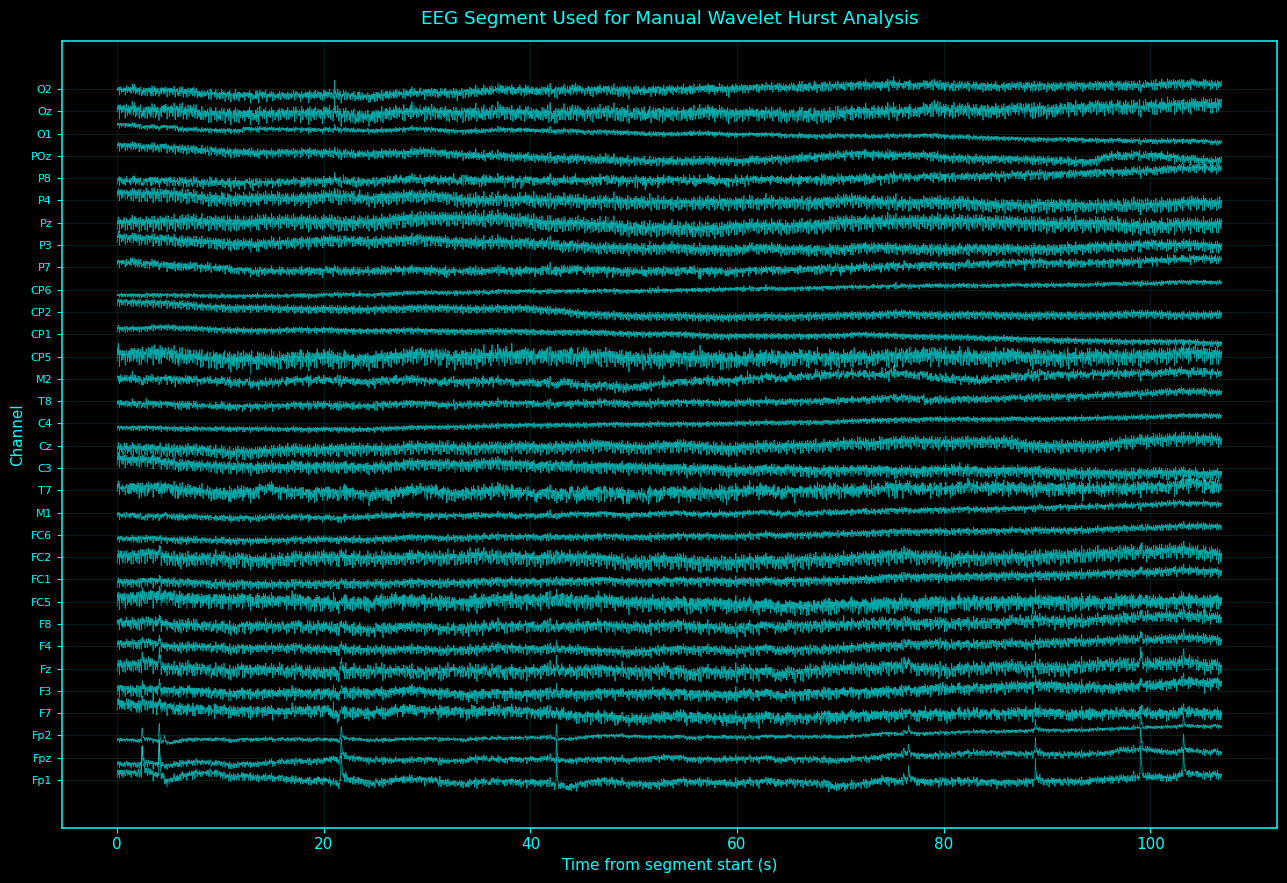


PLOT 1 — Hurst Exponent per EEG Channel

What you are seeing:
  - Each horizontal bar is one EEG channel.
  - The x-axis is the wavelet-based Hurst exponent.
  - Channels are sorted from lower Hurst to higher Hurst.
  - The dashed vertical line marks the mean Hurst value.
  - The dotted vertical line marks the median Hurst value.
  - Higher Hurst values indicate stronger scale persistence.
  - Lower Hurst values indicate rougher or less persistent scale behavior.

Patterns to look for:
  - Look for the highest-H channels; these show the strongest scale persistence.
  - Look for the lowest-H channels; these show rougher scale behavior.
  - Look for whether high-H channels cluster in a region such as frontal, parietal, or occipital.
  - Look for whether left and right homologous channels are similar.
  - Look for one channel far above all others.
  - Look for one channel far below all others.
  - Look for whether values are tightly grouped or widely spread.
  - Look for whether mean and

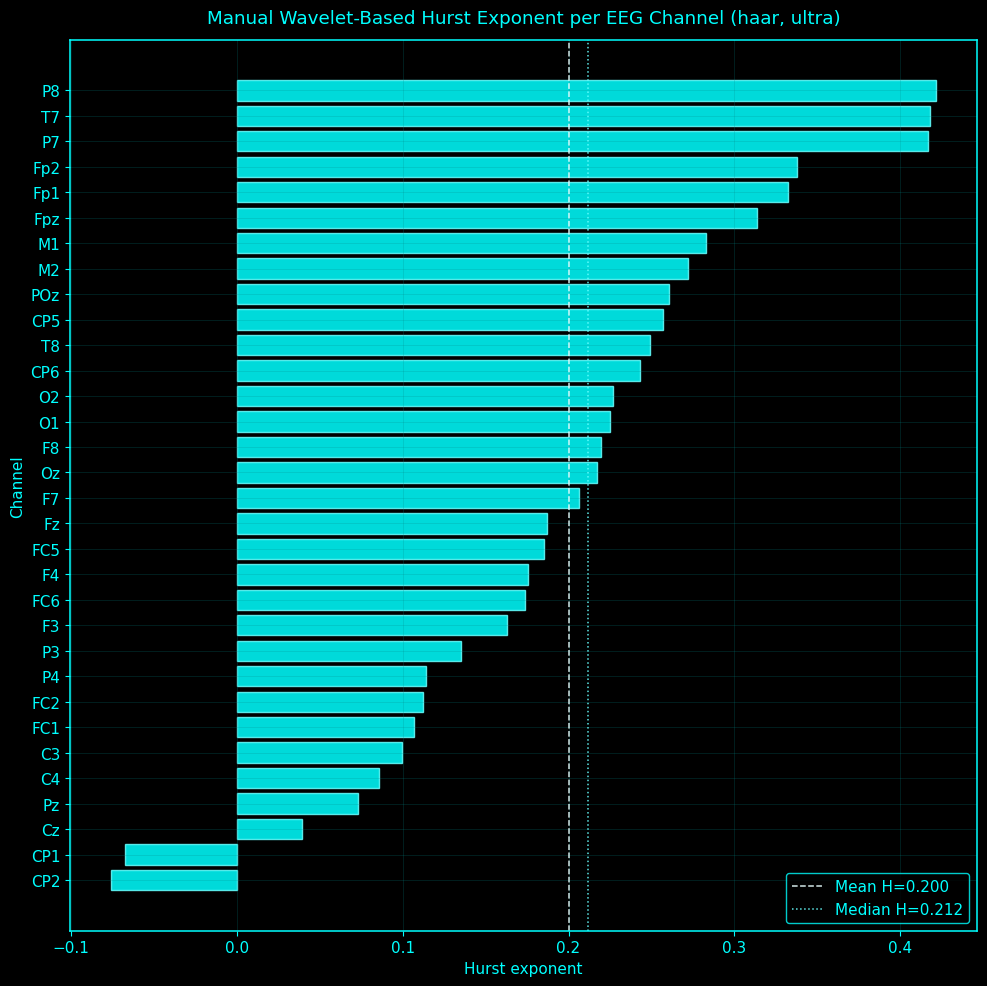


PLOT 2 — Scaling Fit Quality per EEG Channel

What you are seeing:
  - Each horizontal bar is one EEG channel.
  - The x-axis is the R² of the log-log wavelet scaling fit.
  - The dashed line marks R²=0.95.
  - The dotted line marks R²=0.90.
  - Higher R² means the detail-coefficient scaling is closer to a straight line.
  - Lower R² means the Hurst estimate is less reliable.

Patterns to look for:
  - Look for channels above R²=0.95; these have cleaner scaling fits.
  - Look for channels below R²=0.90; these need caution.
  - Look for whether high-H channels also have high R².
  - Look for whether low-H channels have low R².
  - Look for one channel with much worse fit quality than the rest.
  - Look for whether an entire region has weaker fit quality.
  - Look for whether mastoid channels differ from scalp channels.
  - Look for whether R² values are tightly grouped near 1.
  - Look for whether any channel has a valid Hurst value but poor scaling fit.
  - Look for whether the weakes

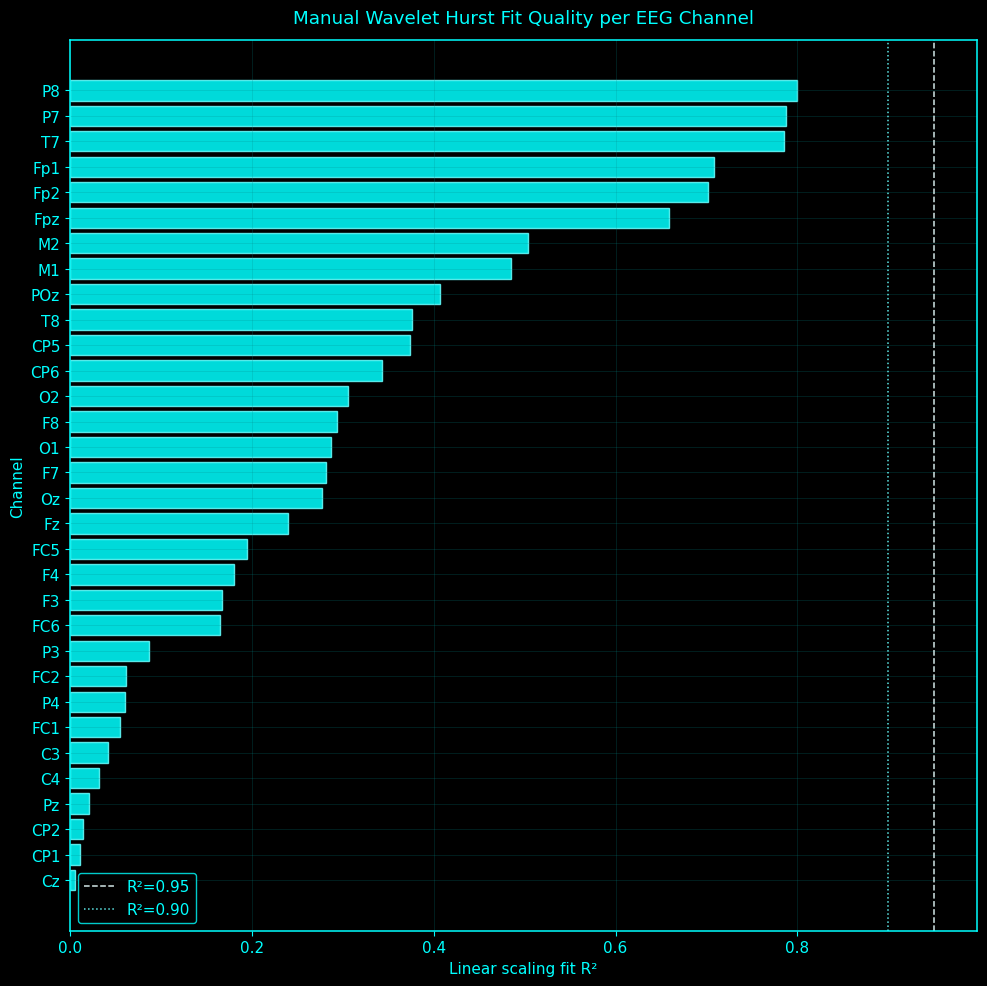


PLOT 3 — Wavelet Scaling Curves Across Channels

What you are seeing:
  - Each line is one channel's wavelet scaling relationship.
  - The x-axis is log2(scale).
  - The y-axis is log2 of the standard deviation of detail coefficients.
  - The slope of each line is used as the Hurst estimate.
  - Straighter lines indicate cleaner scale behavior.

Patterns to look for:
  - Look for lines with steep positive slopes; these correspond to higher Hurst values.
  - Look for flatter lines; these correspond to lower Hurst values.
  - Look for whether most channels have similar slopes.
  - Look for channels with curves rather than straight lines.
  - Look for lines that cross strongly across scale.
  - Look for one curve far above or below the rest.
  - Look for whether the spread between channels grows at coarse scales.
  - Look for whether fine-scale levels behave differently from coarse-scale levels.
  - Look for channels whose scaling line looks unstable.
  - Look for broad agreement between

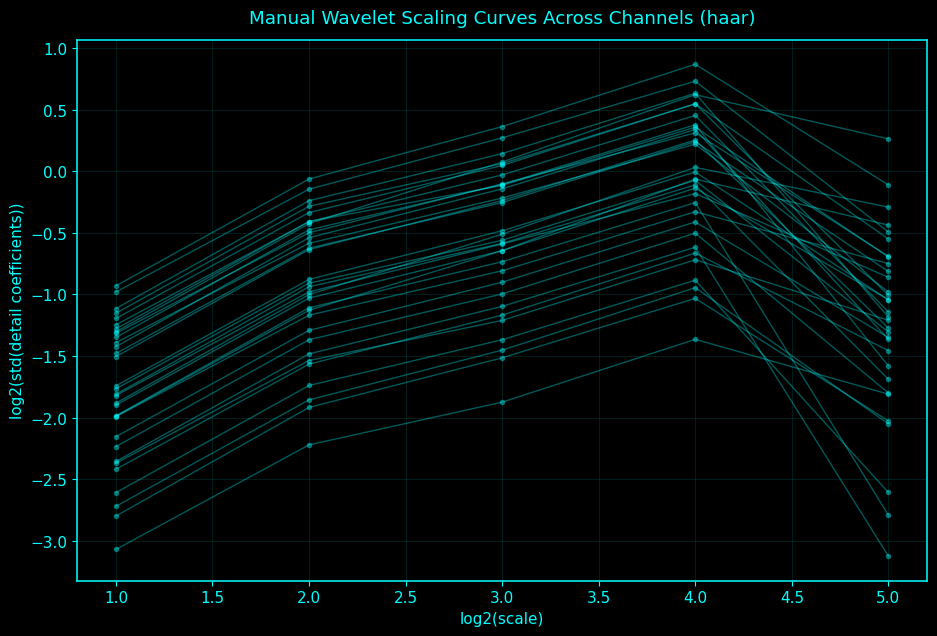


PLOT 4 — Scaling Curve Gallery for Selected Channels

What you are seeing:
  - Each panel shows one selected channel.
  - The cyan points are observed log-log wavelet detail statistics.
  - The white dashed line is the linear fit.
  - The title shows the channel, Hurst estimate, and fit R².
  - The selected channels prioritize high fit quality and high Hurst values.

Patterns to look for:
  - Look for panels where points lie close to the dashed fit line.
  - Look for panels where the slope is steep.
  - Look for panels where the slope is flat.
  - Look for curved patterns rather than straight patterns.
  - Look for a single scale level that breaks the line.
  - Look for whether high-H channels also have visually clean fits.
  - Look for whether selected channels share similar scaling shapes.
  - Look for whether coarse-scale points dominate the slope.
  - Look for whether fine-scale points dominate the slope.
  - Look for channels whose R² looks inconsistent with the visual pattern.



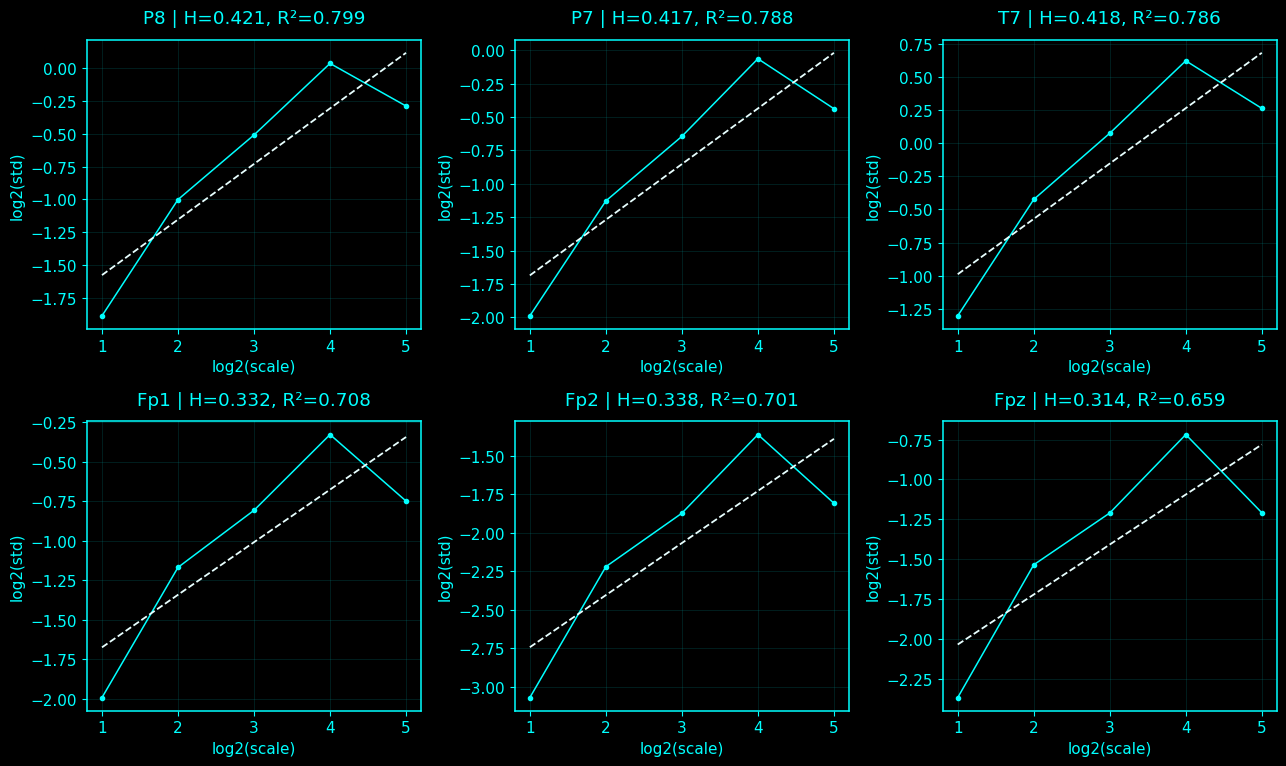


PLOT 5 — Hurst Exponent versus Scaling Fit Reliability

What you are seeing:
  - Each point is one EEG channel.
  - The x-axis is the Hurst exponent.
  - The y-axis is fit R².
  - Larger points represent channels with more wavelet levels.
  - The horizontal dashed line marks R²=0.95.
  - The vertical dotted line marks the mean Hurst value.

Patterns to look for:
  - Look for points in the upper-right: high Hurst with strong fit quality.
  - Look for points in the upper-left: low Hurst with strong fit quality.
  - Look for points in the lower-right: high Hurst but weaker fit quality.
  - Look for points in the lower-left: low Hurst and weaker fit quality.
  - Look for channels below R²=0.95.
  - Look for outliers far to the right.
  - Look for outliers far to the left.
  - Look for whether high-H channels generally have good R².
  - Look for whether fit quality is unrelated to Hurst value.
  - Look for labeled channels that deserve closer inspection.

Cautions:
  - High Hurst with low 

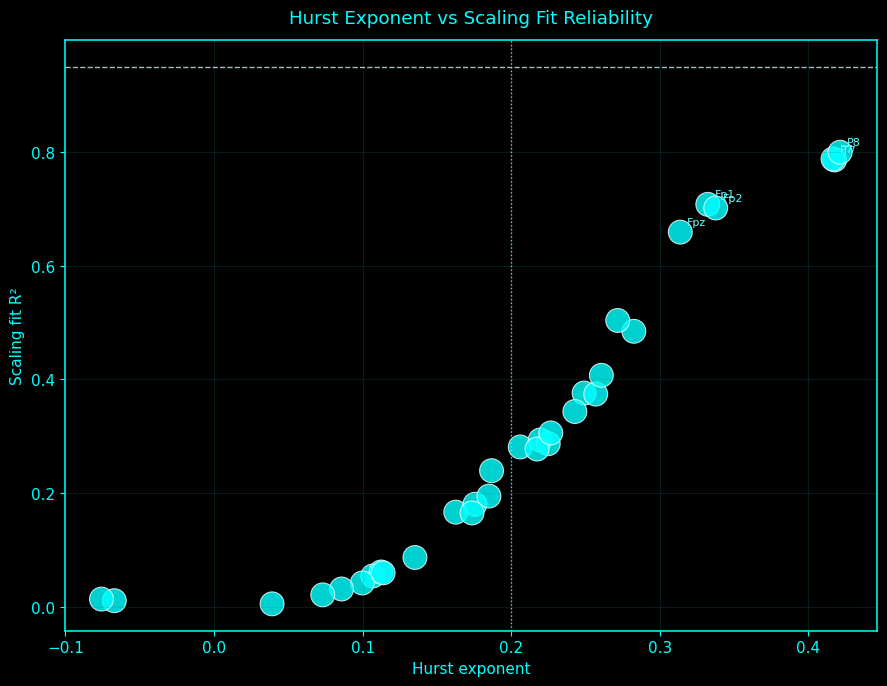


PLOT 6 — Wavelet Detail Standard-Deviation Scale Map

What you are seeing:
  - Each row is one EEG channel.
  - Each column is one wavelet detail level, from fine to coarse.
  - The color shows log2 standard deviation of detail coefficients.
  - Rows are sorted by Hurst exponent.
  - This plot shows the raw scale pattern behind the Hurst estimate.

Patterns to look for:
  - Look for channels with high values across many levels.
  - Look for channels with strong fine-scale detail.
  - Look for channels with strong coarse-scale detail.
  - Look for smooth left-to-right gradients.
  - Look for abrupt changes between neighboring levels.
  - Look for rows that resemble each other.
  - Look for rows that differ strongly from all others.
  - Look for whether high-H channels have systematic coarse-scale behavior.
  - Look for whether low-H channels have more fine-scale dominance.
  - Look for missing or irregular level patterns.

Cautions:
  - This plot shows scale statistics, not the final H

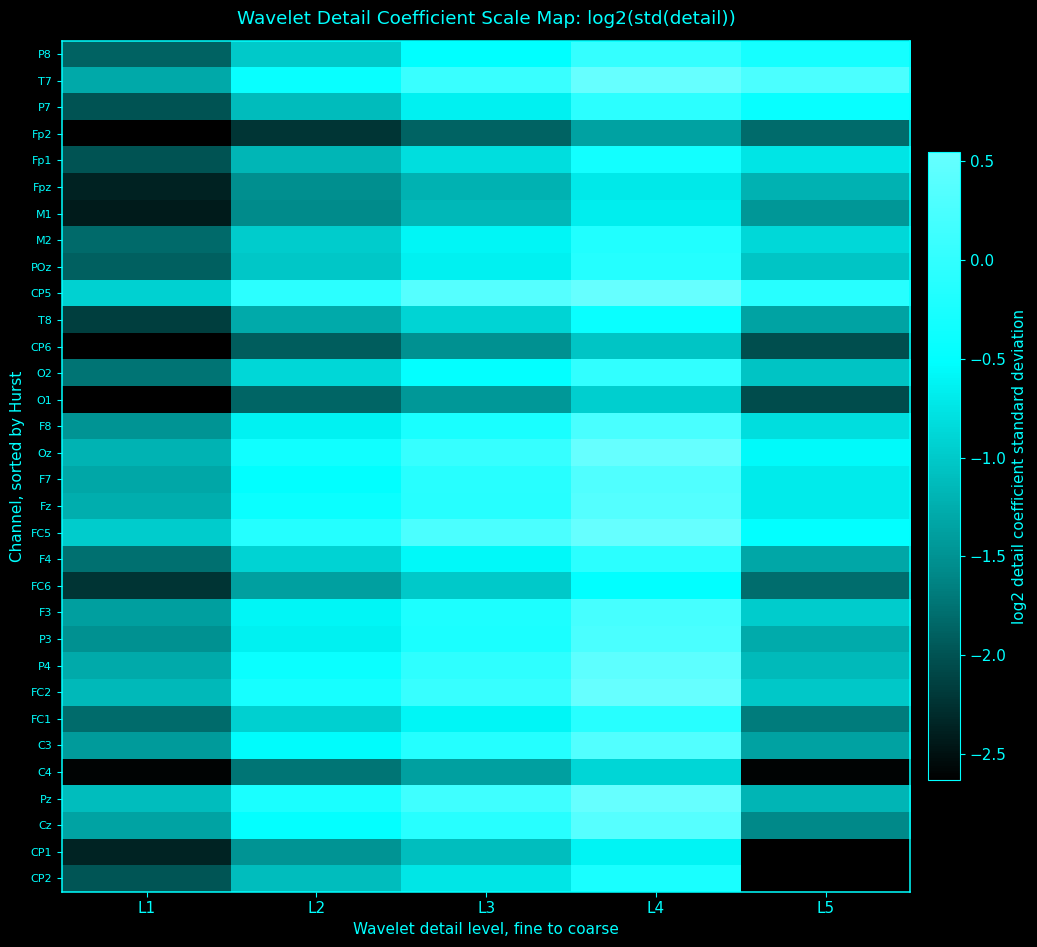


PLOT 7 — Relative Wavelet Detail Energy by Channel

What you are seeing:
  - Each row is one EEG channel.
  - Each column is a wavelet detail level.
  - Each cell shows the fraction of total detail energy at that level.
  - Rows are sorted by Hurst exponent.
  - This plot shows where each channel's wavelet detail energy is concentrated.

Patterns to look for:
  - Look for energy concentrated at fine levels.
  - Look for energy concentrated at coarse levels.
  - Look for channels with energy spread evenly across levels.
  - Look for high-H channels with stronger coarse-scale energy.
  - Look for low-H channels with stronger fine-scale energy.
  - Look for one level dominating many channels.
  - Look for one channel with a very different energy pattern.
  - Look for whether regional channel groups have similar energy distributions.
  - Look for whether the energy map agrees with the standard-deviation heatmap.
  - Look for missing or unexpectedly sparse energy patterns.

Cautions:
  - R

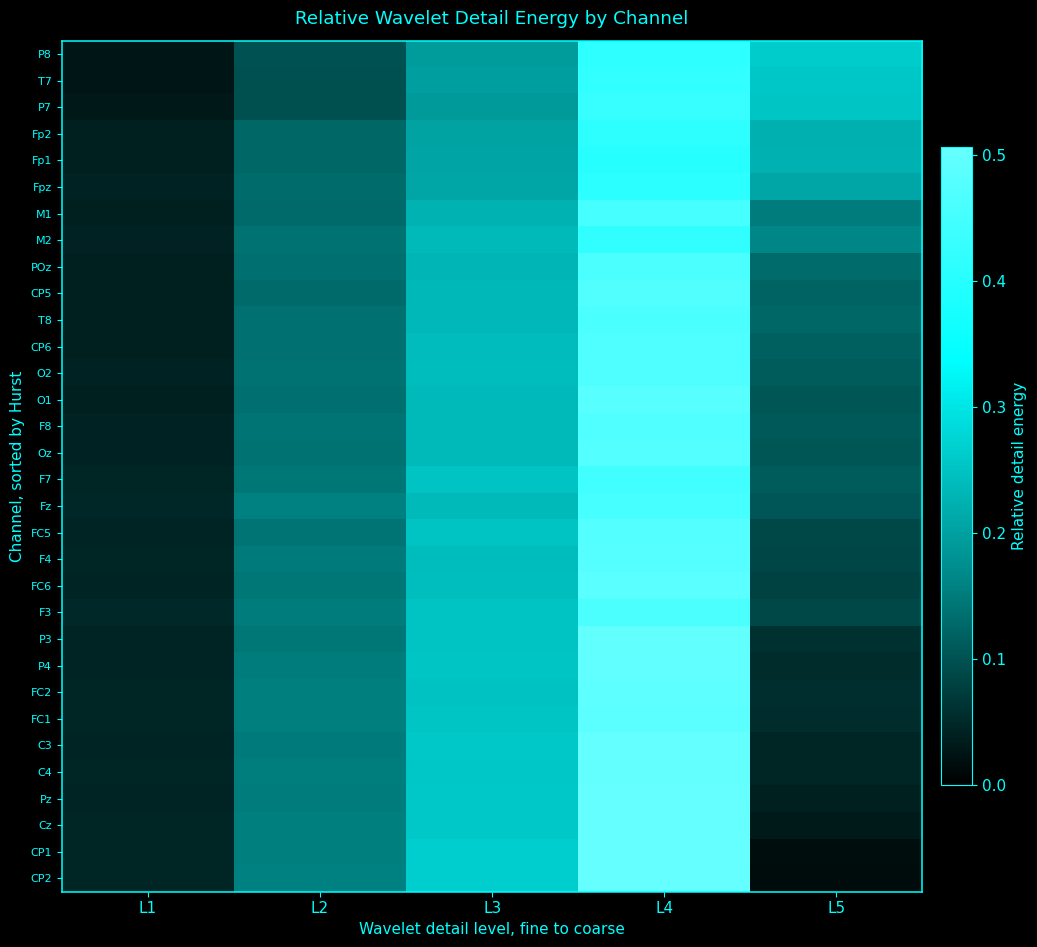


PLOT 8 — Fractal-Dimension Proxy from Wavelet Hurst

What you are seeing:
  - Each horizontal bar is one EEG channel.
  - The x-axis is the proxy value D≈2-H.
  - Channels with lower Hurst have higher proxy dimension.
  - Channels with higher Hurst have lower proxy dimension.
  - This plot expresses roughness rather than persistence.

Patterns to look for:
  - Look for the highest proxy values; these correspond to rougher channels.
  - Look for the lowest proxy values; these correspond to smoother, more persistent channels.
  - Look for whether proxy ranking reverses the Hurst ranking as expected.
  - Look for regional clustering of high proxy values.
  - Look for regional clustering of low proxy values.
  - Look for isolated high-proxy channels.
  - Look for isolated low-proxy channels.
  - Look for left-right similarity.
  - Look for whether mastoid channels differ from scalp channels.
  - Look for whether proxy results agree with raw and wavelet-scale plots.

Cautions:
  - D≈2-H is

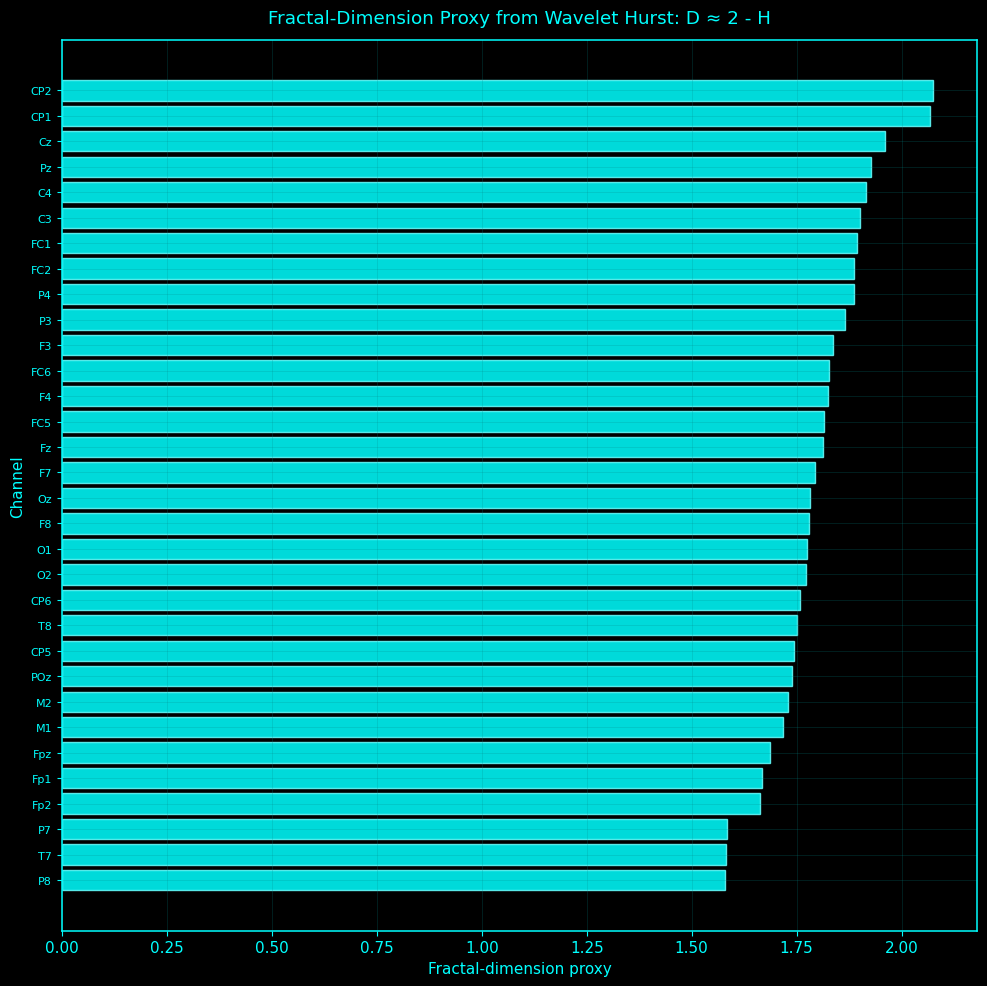


PLOT 9 — Regional Summary of Wavelet Hurst Exponent

What you are seeing:
  - Each horizontal bar is one broad scalp region.
  - The x-axis is mean Hurst exponent.
  - Error bars show standard deviation within the region.
  - Text labels show number of channels and mean fit R².
  - This plot summarizes channel values into regional patterns.

Patterns to look for:
  - Look for the region with highest mean Hurst.
  - Look for the region with lowest mean Hurst.
  - Look for large error bars, which indicate heterogeneous channels inside a region.
  - Look for small error bars, which indicate regional consistency.
  - Look for regions with high mean Hurst and high mean R².
  - Look for regions with high mean Hurst but low mean R².
  - Look for whether frontal, parietal, and occipital regions differ.
  - Look for whether central-temporal channels differ from other regions.
  - Look for regions with few channels, where averages are less stable.
  - Look for whether regional results agree wit

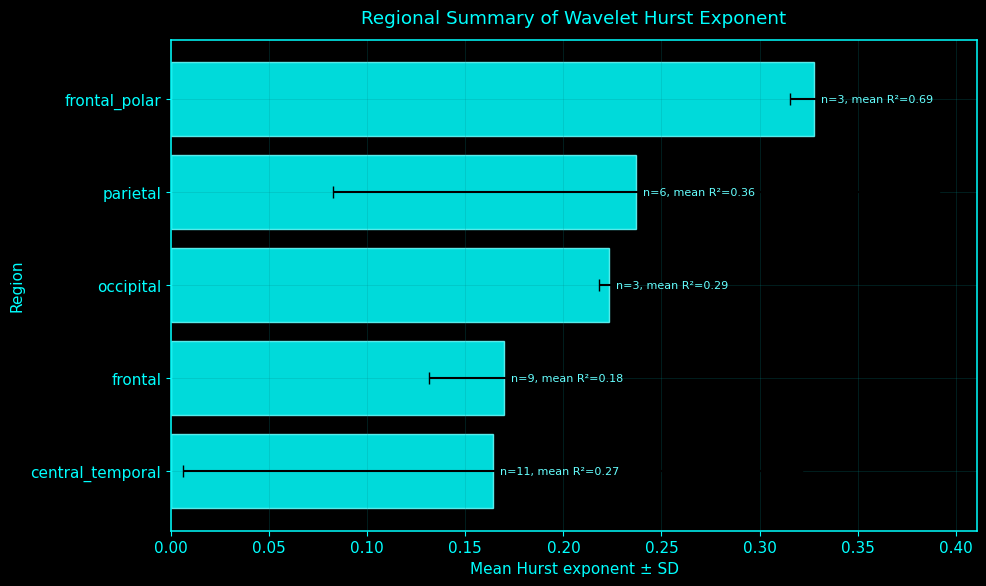


PLOT 10 — Homologous Left-Right Hurst Asymmetry

What you are seeing:
  - Each horizontal bar compares one left-right homologous channel pair.
  - The x-axis is H_left minus H_right.
  - The vertical zero line means both sides have equal Hurst.
  - Bars to the right mean the left channel has higher Hurst.
  - Bars to the left mean the right channel has higher Hurst.

Patterns to look for:
  - Look for bars far from zero.
  - Look for many bars leaning leftward.
  - Look for many bars leaning rightward.
  - Look for one isolated asymmetric pair.
  - Look for asymmetry concentrated in frontal pairs.
  - Look for asymmetry concentrated in central pairs.
  - Look for asymmetry concentrated in parietal or occipital pairs.
  - Look for pairs very close to zero.
  - Look for whether asymmetry agrees with the scalp map.
  - Look for whether asymmetry could be driven by one low-quality channel.

Cautions:
  - Asymmetry can reflect signal structure, but also electrode quality or local artifacts

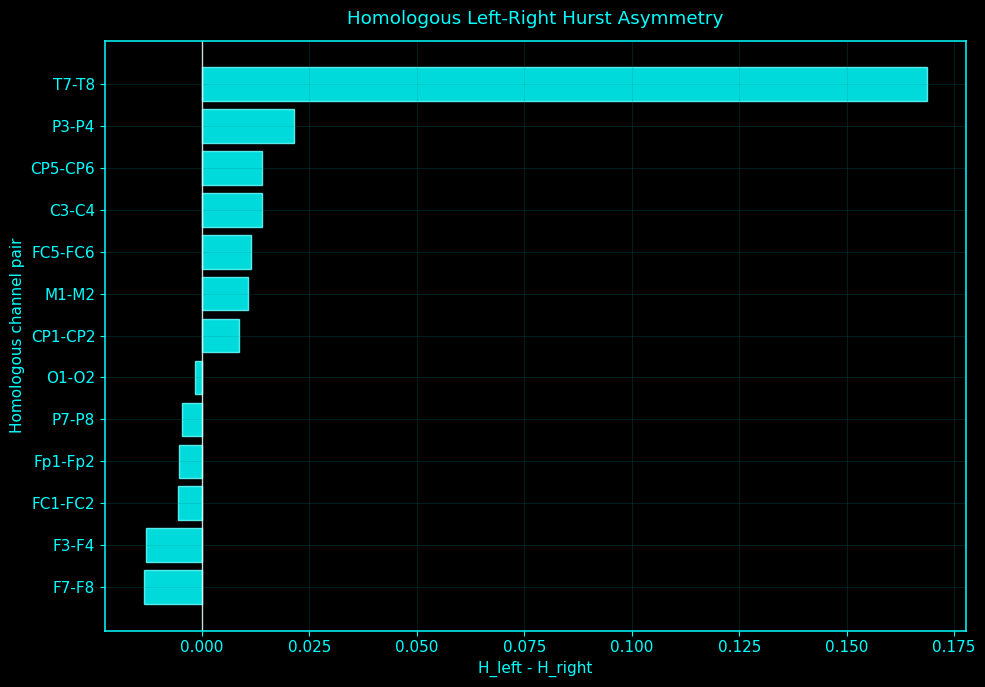


PLOT 11 — Approximate Scalp Map of Wavelet Hurst Exponent

What you are seeing:
  - Each labeled point is one EEG electrode in an approximate scalp position.
  - The color shows the Hurst exponent at that electrode.
  - The circular outline gives spatial context for the head.
  - Frontal electrodes appear toward the top.
  - Occipital electrodes appear toward the bottom.

Patterns to look for:
  - Look for spatial clusters of high Hurst.
  - Look for spatial clusters of low Hurst.
  - Look for anterior-posterior gradients.
  - Look for left-right imbalance.
  - Look for isolated high-H electrodes.
  - Look for isolated low-H electrodes.
  - Look for whether neighboring electrodes are similar.
  - Look for whether mastoid electrodes are unusual.
  - Look for whether scalp-map patterns agree with regional summaries.
  - Look for whether map patterns agree with the Hurst bar plot.

Cautions:
  - This is an approximate electrode layout, not a full interpolated topographic map.
  - One iso

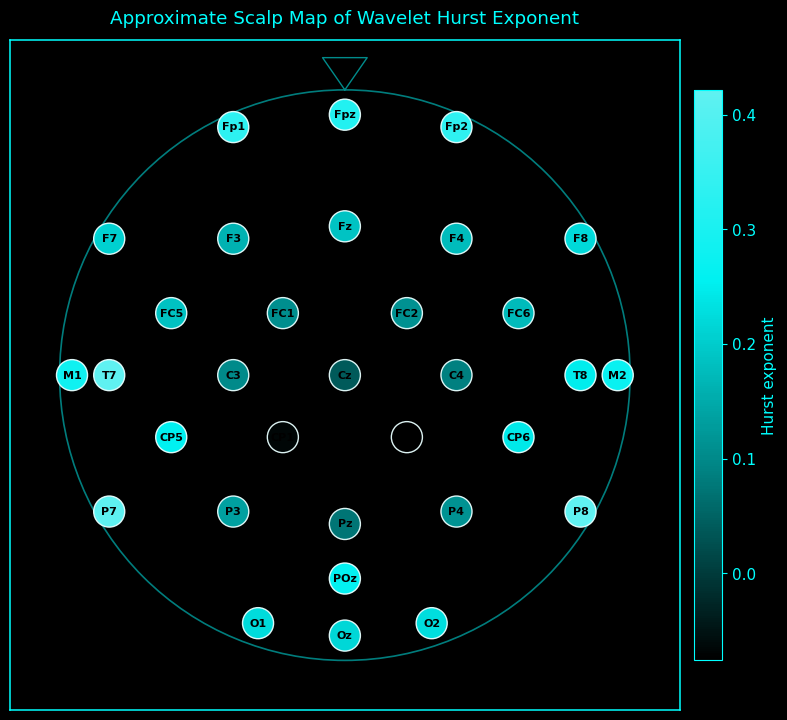


PLOT 12 — Temporal Stability of Wavelet Hurst Estimate

What you are seeing:
  - Each point is one time window.
  - The cyan line shows mean Hurst across channels in each window.
  - The shaded region shows plus and minus one standard deviation.
  - The white line shows mean fit R² across channels.
  - This plot shows whether Hurst estimates are stable over time.

Patterns to look for:
  - Look for a flat mean-H line across windows.
  - Look for a rising mean-H trend.
  - Look for a falling mean-H trend.
  - Look for one window very different from the others.
  - Look for large shaded bands in certain windows.
  - Look for whether R² remains high across windows.
  - Look for windows where Hurst changes and R² drops.
  - Look for whether variability across channels increases over time.
  - Look for temporal state changes.
  - Look for whether the full-segment result is supported by window-level stability.

Cautions:
  - Windowed estimates use less data than full-segment estimates.
  - 

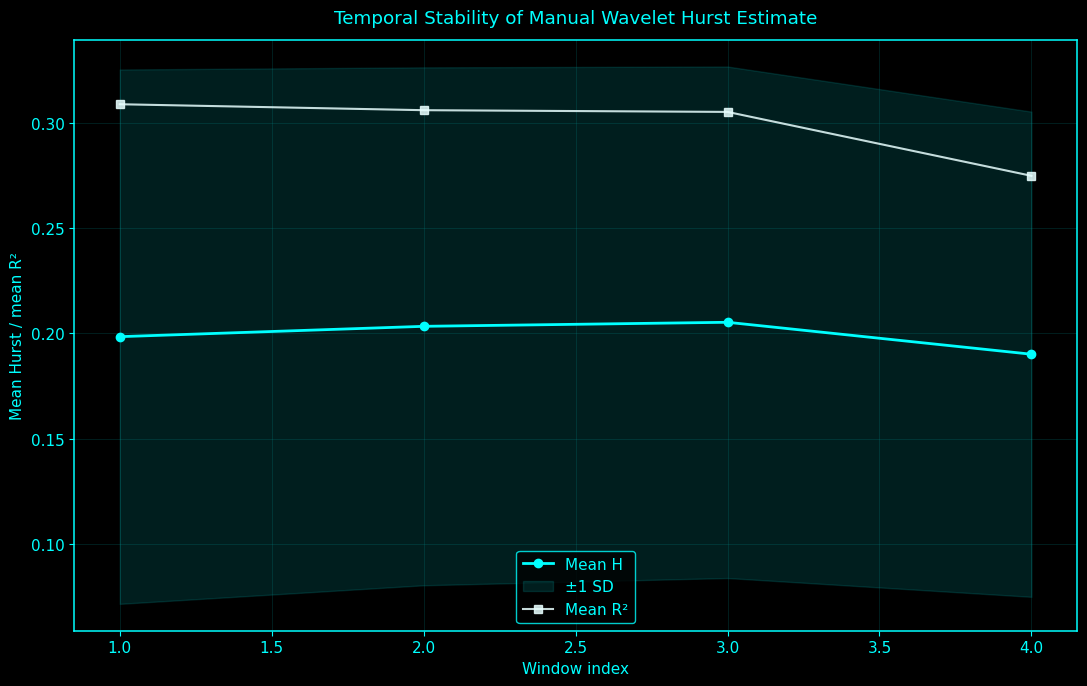


PLOT 13 — Temporal Hurst Heatmap by Channel

What you are seeing:
  - Each row is one EEG channel.
  - Each column is one time window.
  - Each cell shows the Hurst exponent for that channel in that window.
  - Rows are sorted by mean Hurst.
  - This plot shows channel-level temporal stability.

Patterns to look for:
  - Look for rows with stable color across windows.
  - Look for rows that change strongly across windows.
  - Look for vertical stripes where many channels change together.
  - Look for isolated channel-window events.
  - Look for consistently high-H channels.
  - Look for consistently low-H channels.
  - Look for whether high-H channels remain high in every window.
  - Look for whether the ranking changes over time.
  - Look for global state changes across windows.
  - Look for channels whose temporal pattern may indicate artifacts.

Cautions:
  - Windowed Hurst estimates are less stable than full-segment estimates.
  - A single unusual window should be checked against 

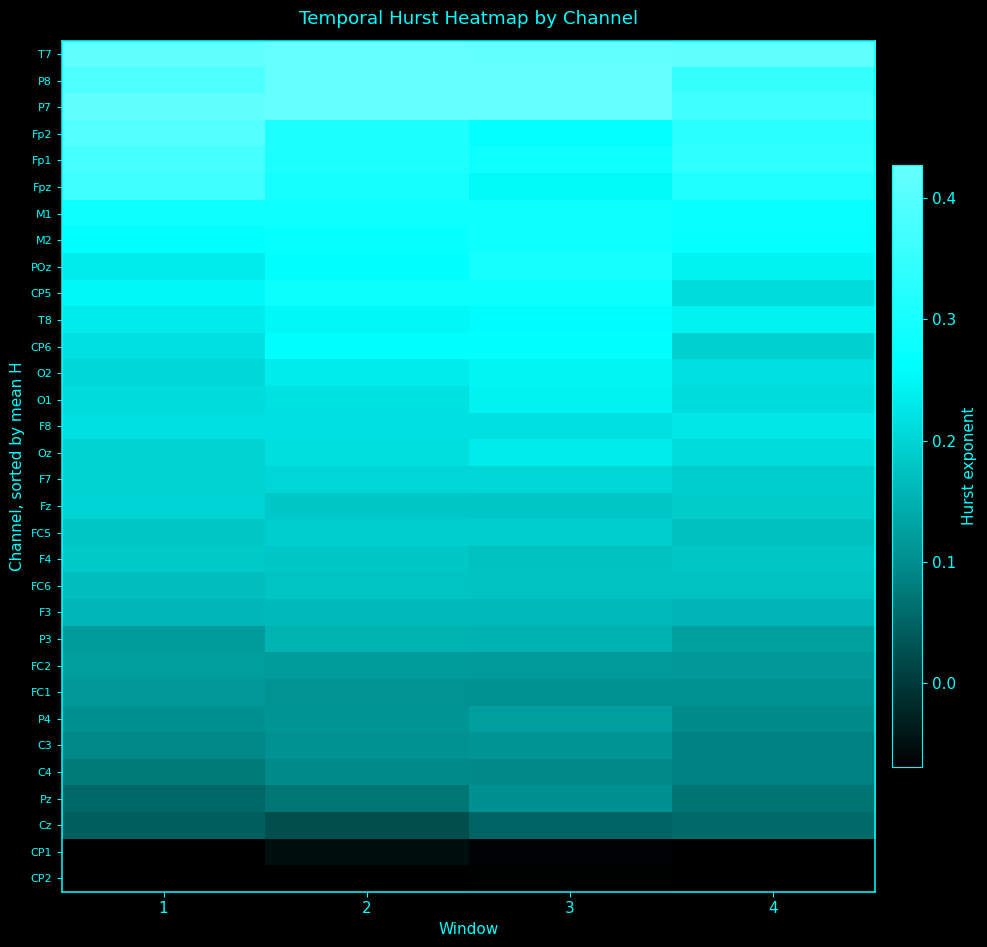


MANUAL WAVELET HURST ANALYSIS SUMMARY
FAST_OPTION: ultra
Wavelet: haar
Rows computed: 32
Channels analyzed: 32
Mean Hurst: 0.200190
Median Hurst: 0.211805
Mean fit R²: 0.303527
Total elapsed: 0.80 min

Top 10 channels by Hurst exponent:
channel  hurst_exponent  fractal_dimension_proxy   fit_r2  n_levels hemisphere           region
     P8        0.421421                 1.578579 0.799365         5      right         parietal
     T7        0.417742                 1.582258 0.785763         5       left central_temporal
     P7        0.416687                 1.583313 0.787534         5       left         parietal
    Fp2        0.337692                 1.662308 0.701391         5      right    frontal_polar
    Fp1        0.332388                 1.667612 0.707782         5       left    frontal_polar
    Fpz        0.313869                 1.686131 0.658950         5    midline    frontal_polar
     M1        0.282589                 1.717411 0.484634         5       left central_tem

# Interpretation of Manual Wavelet Hurst Results

This report interprets the numerical results after the wavelet-Hurst analysis has finished. The goal is to connect the Hurst values, scaling fit quality, regional structure, hemispheric structure, wavelet-energy behavior, and temporal stability into a careful reading of the EEG segment.

---

## 1. Overall Hurst distribution

- Valid channels: **32**
- Mean Hurst: **0.2002**
- Median Hurst: **0.2118**
- Standard deviation of Hurst: **0.1220**
- Minimum Hurst: **-0.0758**
- Maximum Hurst: **0.4214**
- Hurst range: **0.4972**
- Mean fractal-dimension proxy D≈2-H: **1.7998**
- Median fractal-dimension proxy D≈2-H: **1.7882**

The Hurst values show a wide spread. This indicates strong channel-to-channel differences in scale-persistence behavior or possible channel-specific artifacts.

A higher Hurst value means stronger persistence across scales. A lower Hurst value means rougher, less persistent behavior. The proxy D≈2-H reverses this interpretation: lower Hurst gives a higher roughness proxy.

---

## 2. Channels with highest and lowest Hurst values

Highest Hurst channels:

- **P8**: hurst_exponent=0.4214, fractal_dimension_proxy=1.5786, fit_r2=0.7994, n_levels=5.0000, region=parietal, hemisphere=right
- **T7**: hurst_exponent=0.4177, fractal_dimension_proxy=1.5823, fit_r2=0.7858, n_levels=5.0000, region=central_temporal, hemisphere=left
- **P7**: hurst_exponent=0.4167, fractal_dimension_proxy=1.5833, fit_r2=0.7875, n_levels=5.0000, region=parietal, hemisphere=left
- **Fp2**: hurst_exponent=0.3377, fractal_dimension_proxy=1.6623, fit_r2=0.7014, n_levels=5.0000, region=frontal_polar, hemisphere=right
- **Fp1**: hurst_exponent=0.3324, fractal_dimension_proxy=1.6676, fit_r2=0.7078, n_levels=5.0000, region=frontal_polar, hemisphere=left
- **Fpz**: hurst_exponent=0.3139, fractal_dimension_proxy=1.6861, fit_r2=0.6590, n_levels=5.0000, region=frontal_polar, hemisphere=midline
- **M1**: hurst_exponent=0.2826, fractal_dimension_proxy=1.7174, fit_r2=0.4846, n_levels=5.0000, region=central_temporal, hemisphere=left
- **M2**: hurst_exponent=0.2717, fractal_dimension_proxy=1.7283, fit_r2=0.5037, n_levels=5.0000, region=central_temporal, hemisphere=right
- **POz**: hurst_exponent=0.2607, fractal_dimension_proxy=1.7393, fit_r2=0.4073, n_levels=5.0000, region=parietal, hemisphere=midline
- **CP5**: hurst_exponent=0.2569, fractal_dimension_proxy=1.7431, fit_r2=0.3743, n_levels=5.0000, region=central_temporal, hemisphere=left

Lowest Hurst channels:

- **CP2**: hurst_exponent=-0.0758, fractal_dimension_proxy=2.0758, fit_r2=0.0140, n_levels=5.0000, region=central_temporal, hemisphere=right
- **CP1**: hurst_exponent=-0.0671, fractal_dimension_proxy=2.0671, fit_r2=0.0112, n_levels=5.0000, region=central_temporal, hemisphere=left
- **Cz**: hurst_exponent=0.0391, fractal_dimension_proxy=1.9609, fit_r2=0.0056, n_levels=5.0000, region=central_temporal, hemisphere=midline
- **Pz**: hurst_exponent=0.0732, fractal_dimension_proxy=1.9268, fit_r2=0.0214, n_levels=5.0000, region=parietal, hemisphere=midline
- **C4**: hurst_exponent=0.0859, fractal_dimension_proxy=1.9141, fit_r2=0.0317, n_levels=5.0000, region=central_temporal, hemisphere=right
- **C3**: hurst_exponent=0.0998, fractal_dimension_proxy=1.9002, fit_r2=0.0423, n_levels=5.0000, region=central_temporal, hemisphere=left
- **FC1**: hurst_exponent=0.1069, fractal_dimension_proxy=1.8931, fit_r2=0.0546, n_levels=5.0000, region=frontal, hemisphere=left
- **FC2**: hurst_exponent=0.1124, fractal_dimension_proxy=1.8876, fit_r2=0.0616, n_levels=5.0000, region=frontal, hemisphere=right
- **P4**: hurst_exponent=0.1138, fractal_dimension_proxy=1.8862, fit_r2=0.0601, n_levels=5.0000, region=parietal, hemisphere=right
- **P3**: hurst_exponent=0.1352, fractal_dimension_proxy=1.8648, fit_r2=0.0871, n_levels=5.0000, region=parietal, hemisphere=left

The highest Hurst channel is **P8** with H=0.4214. This is a lower Hurst value, suggesting rougher or less persistent scale behavior. The scaling fit is weak, so this channel should be interpreted cautiously.

The lowest Hurst channel is **CP2** with H=-0.0758. This is a lower Hurst value, suggesting rougher or less persistent scale behavior. The scaling fit is weak, so this channel should be interpreted cautiously.

The highest and lowest channels identify candidates, but the interpretation is strongest when those channels also show good fit quality, coherent scaling curves, and plausible spatial organization.

---

## 3. Fit quality and reliability

- Mean fit R²: **0.3035**
- Median fit R²: **0.2795**
- Minimum fit R²: **0.0056**

**Overall reliability reading:** The scaling fit is weak, so this channel should be interpreted cautiously.

Weakest scaling fits:

- **Cz**: fit_r2=0.0056, hurst_exponent=0.0391, fractal_dimension_proxy=1.9609, n_levels=5.0000, region=central_temporal
- **CP1**: fit_r2=0.0112, hurst_exponent=-0.0671, fractal_dimension_proxy=2.0671, n_levels=5.0000, region=central_temporal
- **CP2**: fit_r2=0.0140, hurst_exponent=-0.0758, fractal_dimension_proxy=2.0758, n_levels=5.0000, region=central_temporal
- **Pz**: fit_r2=0.0214, hurst_exponent=0.0732, fractal_dimension_proxy=1.9268, n_levels=5.0000, region=parietal
- **C4**: fit_r2=0.0317, hurst_exponent=0.0859, fractal_dimension_proxy=1.9141, n_levels=5.0000, region=central_temporal
- **C3**: fit_r2=0.0423, hurst_exponent=0.0998, fractal_dimension_proxy=1.9002, n_levels=5.0000, region=central_temporal
- **FC1**: fit_r2=0.0546, hurst_exponent=0.1069, fractal_dimension_proxy=1.8931, n_levels=5.0000, region=frontal
- **P4**: fit_r2=0.0601, hurst_exponent=0.1138, fractal_dimension_proxy=1.8862, n_levels=5.0000, region=parietal
- **FC2**: fit_r2=0.0616, hurst_exponent=0.1124, fractal_dimension_proxy=1.8876, n_levels=5.0000, region=frontal
- **P3**: fit_r2=0.0871, hurst_exponent=0.1352, fractal_dimension_proxy=1.8648, n_levels=5.0000, region=parietal

Strongest scaling fits:

- **P8**: fit_r2=0.7994, hurst_exponent=0.4214, fractal_dimension_proxy=1.5786, n_levels=5.0000, region=parietal
- **P7**: fit_r2=0.7875, hurst_exponent=0.4167, fractal_dimension_proxy=1.5833, n_levels=5.0000, region=parietal
- **T7**: fit_r2=0.7858, hurst_exponent=0.4177, fractal_dimension_proxy=1.5823, n_levels=5.0000, region=central_temporal
- **Fp1**: fit_r2=0.7078, hurst_exponent=0.3324, fractal_dimension_proxy=1.6676, n_levels=5.0000, region=frontal_polar
- **Fp2**: fit_r2=0.7014, hurst_exponent=0.3377, fractal_dimension_proxy=1.6623, n_levels=5.0000, region=frontal_polar
- **Fpz**: fit_r2=0.6590, hurst_exponent=0.3139, fractal_dimension_proxy=1.6861, n_levels=5.0000, region=frontal_polar
- **M2**: fit_r2=0.5037, hurst_exponent=0.2717, fractal_dimension_proxy=1.7283, n_levels=5.0000, region=central_temporal
- **M1**: fit_r2=0.4846, hurst_exponent=0.2826, fractal_dimension_proxy=1.7174, n_levels=5.0000, region=central_temporal
- **POz**: fit_r2=0.4073, hurst_exponent=0.2607, fractal_dimension_proxy=1.7393, n_levels=5.0000, region=parietal
- **T8**: fit_r2=0.3761, hurst_exponent=0.2491, fractal_dimension_proxy=1.7509, n_levels=5.0000, region=central_temporal

Some high-Hurst channels have fit R² below 0.95. These channels may still be interesting, but they should be inspected in the scaling-curve plots before being treated as strong findings:

- **P8**: hurst_exponent=0.4214, fit_r2=0.7994, n_levels=5.0000, region=parietal, hemisphere=right
- **T7**: hurst_exponent=0.4177, fit_r2=0.7858, n_levels=5.0000, region=central_temporal, hemisphere=left
- **P7**: hurst_exponent=0.4167, fit_r2=0.7875, n_levels=5.0000, region=parietal, hemisphere=left
- **Fp2**: hurst_exponent=0.3377, fit_r2=0.7014, n_levels=5.0000, region=frontal_polar, hemisphere=right
- **Fp1**: hurst_exponent=0.3324, fit_r2=0.7078, n_levels=5.0000, region=frontal_polar, hemisphere=left
- **Fpz**: hurst_exponent=0.3139, fit_r2=0.6590, n_levels=5.0000, region=frontal_polar, hemisphere=midline
- **M1**: hurst_exponent=0.2826, fit_r2=0.4846, n_levels=5.0000, region=central_temporal, hemisphere=left
- **M2**: hurst_exponent=0.2717, fit_r2=0.5037, n_levels=5.0000, region=central_temporal, hemisphere=right
- **POz**: hurst_exponent=0.2607, fit_r2=0.4073, n_levels=5.0000, region=parietal, hemisphere=midline
- **CP5**: hurst_exponent=0.2569, fit_r2=0.3743, n_levels=5.0000, region=central_temporal, hemisphere=left

The rule for interpretation is straightforward: the Hurst value tells us what is interesting; the fit R² tells us how confidently we should read it.

---

## 4. Fractal-dimension proxy

Highest D≈2-H proxy channels:

- **CP2**: fractal_dimension_proxy=2.0758, hurst_exponent=-0.0758, fit_r2=0.0140, region=central_temporal, hemisphere=right
- **CP1**: fractal_dimension_proxy=2.0671, hurst_exponent=-0.0671, fit_r2=0.0112, region=central_temporal, hemisphere=left
- **Cz**: fractal_dimension_proxy=1.9609, hurst_exponent=0.0391, fit_r2=0.0056, region=central_temporal, hemisphere=midline
- **Pz**: fractal_dimension_proxy=1.9268, hurst_exponent=0.0732, fit_r2=0.0214, region=parietal, hemisphere=midline
- **C4**: fractal_dimension_proxy=1.9141, hurst_exponent=0.0859, fit_r2=0.0317, region=central_temporal, hemisphere=right
- **C3**: fractal_dimension_proxy=1.9002, hurst_exponent=0.0998, fit_r2=0.0423, region=central_temporal, hemisphere=left
- **FC1**: fractal_dimension_proxy=1.8931, hurst_exponent=0.1069, fit_r2=0.0546, region=frontal, hemisphere=left
- **FC2**: fractal_dimension_proxy=1.8876, hurst_exponent=0.1124, fit_r2=0.0616, region=frontal, hemisphere=right
- **P4**: fractal_dimension_proxy=1.8862, hurst_exponent=0.1138, fit_r2=0.0601, region=parietal, hemisphere=right
- **P3**: fractal_dimension_proxy=1.8648, hurst_exponent=0.1352, fit_r2=0.0871, region=parietal, hemisphere=left

The proxy D≈2-H emphasizes roughness rather than persistence. Channels with high proxy values have lower Hurst values. Thus, if the Hurst bar plot identifies smoother persistent channels, the proxy plot identifies the opposite side: channels with rougher scale structure.

---

## 5. Regional pattern

Regional Hurst summary:

- **frontal_polar**: mean_hurst=0.3280, std_hurst=0.0125, mean_proxy=1.6720, mean_r2=0.6894, n=3.0000
- **parietal**: mean_hurst=0.2369, std_hurst=0.1544, mean_proxy=1.7631, mean_r2=0.3605, n=6.0000
- **occipital**: mean_hurst=0.2230, std_hurst=0.0049, mean_proxy=1.7770, mean_r2=0.2903, n=3.0000
- **frontal**: mean_hurst=0.1699, std_hurst=0.0382, mean_proxy=1.8301, mean_r2=0.1820, n=9.0000
- **central_temporal**: mean_hurst=0.1639, std_hurst=0.1578, mean_proxy=1.8361, mean_r2=0.2703, n=11.0000

The region with the highest mean Hurst is **frontal_polar** (mean H=0.3280, mean R²=0.6894). The region with the lowest mean Hurst is **central_temporal** (mean H=0.1639, mean R²=0.2703).

A regional conclusion is stronger when the region has several channels, low within-region spread, and high mean fit quality. If a region has a large standard deviation, the regional average may be hiding mixed channel behavior.

---

## 6. Hemispheric pattern

Hemisphere Hurst summary:

- **left**: mean_hurst=0.2123, std_hurst=0.1343, mean_proxy=1.7877, mean_r2=0.3281, n=13.0000
- **right**: mean_hurst=0.1965, std_hurst=0.1238, mean_proxy=1.8035, mean_r2=0.2952, n=13.0000
- **midline**: mean_hurst=0.1819, std_hurst=0.1069, mean_proxy=1.8181, mean_r2=0.2684, n=6.0000

The left-minus-right mean Hurst difference is **0.0158**. This is a small hemispheric difference, suggesting broadly balanced left-right scale persistence.

The strongest asymmetry interpretation comes from repeated left-right differences across several homologous pairs, not from one pair alone.

---

## 7. Temporal stability

Channels with highest temporal Hurst variability:

- **P8**: std_window_hurst=0.0584, mean_window_hurst=0.4160, mean_window_r2=0.7796, n_windows=4.0000
- **Fp2**: std_window_hurst=0.0540, mean_window_hurst=0.3266, mean_window_r2=0.6528, n_windows=4.0000
- **Fpz**: std_window_hurst=0.0456, mean_window_hurst=0.3070, mean_window_r2=0.6265, n_windows=4.0000
- **Fp1**: std_window_hurst=0.0407, mean_window_hurst=0.3258, mean_window_r2=0.6782, n_windows=4.0000
- **P7**: std_window_hurst=0.0355, mean_window_hurst=0.4153, mean_window_r2=0.7813, n_windows=4.0000
- **CP6**: std_window_hurst=0.0344, mean_window_hurst=0.2360, mean_window_r2=0.3252, n_windows=4.0000
- **CP5**: std_window_hurst=0.0321, mean_window_hurst=0.2569, mean_window_r2=0.3769, n_windows=4.0000
- **POz**: std_window_hurst=0.0278, mean_window_hurst=0.2608, mean_window_r2=0.4084, n_windows=4.0000
- **Pz**: std_window_hurst=0.0211, mean_window_hurst=0.0743, mean_window_r2=0.0241, n_windows=4.0000
- **O2**: std_window_hurst=0.0178, mean_window_hurst=0.2263, mean_window_r2=0.3056, n_windows=4.0000

Channels with lowest temporal Hurst variability:

- **F3**: std_window_hurst=0.0029, mean_window_hurst=0.1602, mean_window_r2=0.1608, n_windows=4.0000
- **FC2**: std_window_hurst=0.0036, mean_window_hurst=0.1195, mean_window_r2=0.0712, n_windows=4.0000
- **FC6**: std_window_hurst=0.0041, mean_window_hurst=0.1752, mean_window_r2=0.1688, n_windows=4.0000
- **FC1**: std_window_hurst=0.0046, mean_window_hurst=0.1091, mean_window_r2=0.0575, n_windows=4.0000
- **M1**: std_window_hurst=0.0050, mean_window_hurst=0.2827, mean_window_r2=0.4851, n_windows=4.0000
- **F4**: std_window_hurst=0.0051, mean_window_hurst=0.1803, mean_window_r2=0.1926, n_windows=4.0000
- **T7**: std_window_hurst=0.0054, mean_window_hurst=0.4194, mean_window_r2=0.7895, n_windows=4.0000
- **F7**: std_window_hurst=0.0055, mean_window_hurst=0.1984, mean_window_r2=0.2574, n_windows=4.0000
- **F8**: std_window_hurst=0.0056, mean_window_hurst=0.2207, mean_window_r2=0.2967, n_windows=4.0000
- **CP2**: std_window_hurst=0.0060, mean_window_hurst=-0.0734, mean_window_r2=0.0132, n_windows=4.0000

Window-level temporal summary:

- **1.0**: mean_hurst=0.1984, std_hurst=0.1269, mean_r2=0.3088, n=32.0000
- **2.0**: mean_hurst=0.2033, std_hurst=0.1230, mean_r2=0.3060, n=32.0000
- **3.0**: mean_hurst=0.2053, std_hurst=0.1215, mean_r2=0.3052, n=32.0000
- **4.0**: mean_hurst=0.1901, std_hurst=0.1152, mean_r2=0.2748, n=32.0000

The channel with the largest window-to-window Hurst variability is **P8** (STD across windows=0.0584). The most temporally stable channel is **F3** (STD across windows=0.0029).

A full-segment Hurst result is more convincing when the temporal-window analysis shows similar values across windows. If a channel varies strongly across windows, the full-segment value may be summarizing a nonstationary process.

---

## 8. What makes a result stronger

A Hurst result is stronger when several signs agree:

- The channel has a high or low Hurst value relative to the rest.
- The scaling fit R² is high.
- The scaling curve looks approximately linear.
- The wavelet detail maps support the scale pattern.
- Neighboring or related channels show similar behavior.
- Regional and scalp-map views agree.
- Temporal-window results are stable.

A Hurst result needs caution when:

- The Hurst value is extreme but the fit R² is weak.
- One channel is isolated from all neighboring channels.
- The scaling curve is visibly curved or dominated by one level.
- The result appears only in the full segment but not across temporal windows.
- A channel has unusual raw EEG activity or visible artifacts.
- The result is driven by too few wavelet levels.

---

## 9. Final synthesis

The strongest high-Hurst channel candidate is **P8** (H=0.4214, R²=0.7994). The strongest low-Hurst channel candidate is **CP2** (H=-0.0758, R²=0.0140). The highest-Hurst region is **frontal_polar** (mean H=0.3280). 

The safest conclusion is not simply that one channel has the largest Hurst value. The stronger conclusion is that a channel or region shows scale-persistent EEG structure when the Hurst value, fit quality, scaling-curve shape, spatial organization, and temporal stability all support the same reading.

---

## 10. One-sentence takeaway

The wavelet-Hurst analysis estimates how EEG structure changes across time scales, and the most reliable findings are those where Hurst magnitude is supported by clean scaling fits, coherent spatial patterns, and stability across time windows.


In [14]:
import os
import time
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

try:
    from IPython.display import display, Markdown
    _HAVE_IPYTHON_DISPLAY = True
except Exception:
    display = None
    Markdown = None
    _HAVE_IPYTHON_DISPLAY = False

# -------------------------------------------------------
# CONFIG
# -------------------------------------------------------
base_dir = "/home/a/projects/Complete-Neural-Signal-Analysis"
eeg_path = os.path.join(base_dir, "eeg_data_with_channels.npy")

out_dir = os.path.join(base_dir, "results", "wavelet_hurst_exponent_manual_expert_fast")
plots_dir = os.path.join(out_dir, "plots")
scaling_dir = os.path.join(plots_dir, "per_channel_scaling_curves")

os.makedirs(out_dir, exist_ok=True)
os.makedirs(plots_dir, exist_ok=True)
os.makedirs(scaling_dir, exist_ok=True)

FAST_OPTION = "ultra"

if FAST_OPTION == "ultra":
    wavelet_name = "haar"
    max_level = 5
    run_temporal_stability = True
    temporal_windows = 4
    max_channels = None
    save_per_channel_scaling_curves = False
    scaling_gallery_top_n = 6
    raw_plot_max_points = 4000

elif FAST_OPTION == "fast":
    wavelet_name = "db4"
    max_level = 8
    run_temporal_stability = True
    temporal_windows = 8
    max_channels = None
    save_per_channel_scaling_curves = True
    scaling_gallery_top_n = 9
    raw_plot_max_points = 12000

elif FAST_OPTION == "balanced":
    wavelet_name = "db4"
    max_level = 10
    run_temporal_stability = True
    temporal_windows = 14
    max_channels = None
    save_per_channel_scaling_curves = True
    scaling_gallery_top_n = 12
    raw_plot_max_points = 24000

elif FAST_OPTION == "full":
    wavelet_name = "db4"
    max_level = None
    run_temporal_stability = True
    temporal_windows = 24
    max_channels = None
    save_per_channel_scaling_curves = True
    scaling_gallery_top_n = 16
    raw_plot_max_points = None

else:
    raise ValueError("FAST_OPTION must be one of: 'ultra', 'fast', 'balanced', 'full'.")

sampling_rate = 1000
start_time, end_time = 814.571, 921.515
start_index, end_index = int(start_time * sampling_rate), int(end_time * sampling_rate)

SHOW_PLOTS_IN_NOTEBOOK = True
SAVE_PLOTS_TO_DISK = True

ACCENT = "#00FFFF"
ACCENT_SOFT = "#66FFFF"
ACCENT_DIM = "#008B8B"
WHITE = "#E8FFFF"
BLACK = "#000000"
eps = 1e-12

eeg_channel_names = [
    "Fp1", "Fpz", "Fp2", "F7", "F3", "Fz", "F4", "F8", "FC5", "FC1", "FC2", "FC6",
    "M1", "T7", "C3", "Cz", "C4", "T8", "M2", "CP5", "CP1", "CP2", "CP6",
    "P7", "P3", "Pz", "P4", "P8", "POz", "O1", "Oz", "O2"
]

if max_channels is not None:
    eeg_channel_names = eeg_channel_names[:max_channels]

left_channels = ["Fp1", "F7", "F3", "FC5", "FC1", "M1", "T7", "C3", "CP5", "CP1", "P7", "P3", "O1"]
right_channels = ["Fp2", "F8", "F4", "FC2", "FC6", "M2", "T8", "C4", "CP2", "CP6", "P8", "P4", "O2"]
midline_channels = ["Fpz", "Fz", "Cz", "Pz", "POz", "Oz"]

electrode_xy = {
    "Fp1": (-0.45, 1.00), "Fpz": (0.00, 1.05), "Fp2": (0.45, 1.00),
    "F7": (-0.95, 0.55), "F3": (-0.45, 0.55), "Fz": (0.00, 0.60), "F4": (0.45, 0.55), "F8": (0.95, 0.55),
    "FC5": (-0.70, 0.25), "FC1": (-0.25, 0.25), "FC2": (0.25, 0.25), "FC6": (0.70, 0.25),
    "M1": (-1.10, 0.00), "T7": (-0.95, 0.00), "C3": (-0.45, 0.00), "Cz": (0.00, 0.00), "C4": (0.45, 0.00), "T8": (0.95, 0.00), "M2": (1.10, 0.00),
    "CP5": (-0.70, -0.25), "CP1": (-0.25, -0.25), "CP2": (0.25, -0.25), "CP6": (0.70, -0.25),
    "P7": (-0.95, -0.55), "P3": (-0.45, -0.55), "Pz": (0.00, -0.60), "P4": (0.45, -0.55), "P8": (0.95, -0.55),
    "POz": (0.00, -0.82), "O1": (-0.35, -1.00), "Oz": (0.00, -1.05), "O2": (0.35, -1.00),
}

CYAN_DIVERGING_CMAP = LinearSegmentedColormap.from_list(
    "cyan_diverging",
    [ACCENT_DIM, BLACK, ACCENT_SOFT],
    N=256,
)

CYAN_SEQUENTIAL_CMAP = LinearSegmentedColormap.from_list(
    "cyan_sequential",
    [BLACK, ACCENT_DIM, ACCENT, ACCENT_SOFT],
    N=256,
)

plt.rcParams.update({
    "figure.facecolor": BLACK,
    "axes.facecolor": BLACK,
    "savefig.facecolor": BLACK,
    "text.color": ACCENT,
    "axes.labelcolor": ACCENT,
    "axes.edgecolor": ACCENT,
    "axes.titlecolor": ACCENT,
    "xtick.color": ACCENT,
    "ytick.color": ACCENT,
    "grid.color": ACCENT_DIM,
    "legend.facecolor": BLACK,
    "legend.edgecolor": ACCENT,
    "legend.labelcolor": ACCENT,
    "font.size": 11,
})

rng = np.random.default_rng(42)

# -------------------------------------------------------
# STYLE
# -------------------------------------------------------
def style_ax(ax, title=None, xlabel=None, ylabel=None, grid=True):
    ax.set_facecolor(BLACK)

    for spine in ax.spines.values():
        spine.set_color(ACCENT)
        spine.set_linewidth(1.1)

    ax.tick_params(axis="x", colors=ACCENT, labelcolor=ACCENT)
    ax.tick_params(axis="y", colors=ACCENT, labelcolor=ACCENT)

    if title is not None:
        ax.set_title(title, color=ACCENT, pad=12)

    if xlabel is not None:
        ax.set_xlabel(xlabel, color=ACCENT)

    if ylabel is not None:
        ax.set_ylabel(ylabel, color=ACCENT)

    if grid:
        ax.grid(True, alpha=0.22, color=ACCENT_DIM, linewidth=0.7)
    else:
        ax.grid(False)

def save_fig(fig, path, show=True):
    fig.tight_layout()

    if SAVE_PLOTS_TO_DISK and path is not None:
        fig.savefig(path, dpi=220, bbox_inches="tight", facecolor=BLACK)

    if SHOW_PLOTS_IN_NOTEBOOK and show and _HAVE_IPYTHON_DISPLAY:
        display(fig)

    plt.close(fig)

def short_label(x, max_len=24):
    x = str(x)
    return x if len(x) <= max_len else x[:max_len - 1] + "…"

def print_plot_description(title, what_you_see, patterns_to_look_for, cautions=None):
    print("\n" + "=" * 96)
    print(title)
    print("=" * 96)
    print("\nWhat you are seeing:")
    for item in what_you_see:
        print(f"  - {item}")
    print("\nPatterns to look for:")
    for item in patterns_to_look_for:
        print(f"  - {item}")
    if cautions:
        print("\nCautions:")
        for item in cautions:
            print(f"  - {item}")
    print("=" * 96 + "\n")

# -------------------------------------------------------
# HELPERS
# -------------------------------------------------------
def ensure_time_channel_layout(x, n_channels_expected):
    x = np.asarray(x, dtype=float)

    if x.ndim != 2:
        raise ValueError(f"Expected 2D EEG array, got shape {x.shape}")

    if x.shape[1] == n_channels_expected:
        return x

    if x.shape[0] == n_channels_expected:
        return x.T

    if x.shape[1] >= n_channels_expected:
        return x[:, :n_channels_expected]

    if x.shape[0] >= n_channels_expected:
        return x.T[:, :n_channels_expected]

    raise ValueError(f"Unexpected EEG shape: {x.shape}")

def safe_zscore_1d(x):
    x = np.asarray(x, dtype=float).reshape(-1)
    x = np.where(np.isfinite(x), x, np.nan)

    if np.any(~np.isfinite(x)):
        med = np.nanmedian(x)
        if not np.isfinite(med):
            med = 0.0
        x = np.nan_to_num(x, nan=med, posinf=med, neginf=med)

    return (x - np.mean(x)) / (np.std(x) + eps)

def downsample_for_plot(X, max_points=None):
    X = np.asarray(X)

    if max_points is None or X.shape[0] <= max_points:
        return X, np.arange(X.shape[0])

    step = int(np.ceil(X.shape[0] / max_points))
    idx = np.arange(0, X.shape[0], step)

    return X[idx], idx

def get_wavelet_filters(name="db4"):
    name = name.lower()

    if name == "haar":
        h = np.array([
            1 / np.sqrt(2),
            1 / np.sqrt(2)
        ], dtype=float)

    elif name == "db4":
        h = np.array([
            -0.010597401785069032,
             0.0328830116668852,
             0.030841381835560764,
            -0.18703481171888114,
            -0.027983769416859854,
             0.6308807679298587,
             0.7148465705529157,
             0.2303778133088965
        ], dtype=float)

    else:
        raise ValueError("Unsupported wavelet. Use 'haar' or 'db4'.")

    g = ((-1) ** np.arange(len(h))) * h[::-1]

    return h, g

def dwt_single_level_periodic(x, h, g):
    x = np.asarray(x, dtype=float).reshape(-1)
    n = len(x)
    L = len(h)

    if n < L:
        raise ValueError("Signal too short for one DWT level with chosen filter.")

    out_len = n // 2

    if out_len < 1:
        raise ValueError("Signal too short after decimation.")

    a = np.zeros(out_len, dtype=float)
    d = np.zeros(out_len, dtype=float)

    for k in range(out_len):
        idx = (2 * k + np.arange(L)) % n
        segment = x[idx]
        a[k] = np.sum(h * segment)
        d[k] = np.sum(g * segment)

    return a, d

def max_dwt_level(n, filter_len):
    level = 0
    current_n = int(n)

    while current_n >= filter_len and current_n >= 2:
        current_n = current_n // 2
        level += 1

    return max(level, 0)

def wavedec_manual(x, wavelet="db4", level=None):
    h, g = get_wavelet_filters(wavelet)
    x = np.asarray(x, dtype=float).reshape(-1)

    if level is None:
        level = max_dwt_level(len(x), len(h))

    if level < 2:
        raise ValueError("Need at least 2 levels for stable wavelet Hurst estimation.")

    a = x.copy()
    details = []

    for _ in range(level):
        a, d = dwt_single_level_periodic(a, h, g)
        details.append(d)

        if len(a) < 2:
            break

    if len(details) < 2:
        raise ValueError("Too few valid detail levels after decomposition.")

    return a, details

def fit_line_r2(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    mask = np.isfinite(x) & np.isfinite(y)

    if np.sum(mask) < 2:
        return np.nan, np.nan, np.nan, None

    x = x[mask]
    y = y[mask]

    slope, intercept = np.polyfit(x, y, 1)
    y_hat = slope * x + intercept

    ss_res = np.sum((y - y_hat) ** 2)
    ss_tot = np.sum((y - np.mean(y)) ** 2)
    r2 = 1.0 - ss_res / (ss_tot + eps)

    return float(slope), float(intercept), float(r2), y_hat

def estimate_hurst_exponent_from_details(details):
    n_levels = len(details)
    scales = np.array([2 ** j for j in range(1, n_levels + 1)], dtype=float)
    stdevs = np.array([np.std(d, ddof=1) for d in details], dtype=float)
    energies = np.array([np.mean(np.asarray(d, dtype=float) ** 2) for d in details], dtype=float)

    valid = np.isfinite(stdevs) & (stdevs > 0)

    if np.sum(valid) < 2:
        return {
            "hurst_exponent": np.nan,
            "fit_r2": np.nan,
            "scales": scales,
            "detail_stdevs": stdevs,
            "detail_energies": energies,
            "log2_scales_fit": None,
            "log2_stdevs_fit": None,
            "fit_line": None,
            "slope": np.nan,
            "intercept": np.nan,
        }

    x = np.log2(scales[valid])
    y = np.log2(stdevs[valid])

    slope, intercept, r2, y_hat = fit_line_r2(x, y)

    return {
        "hurst_exponent": float(slope),
        "fit_r2": float(r2),
        "scales": scales,
        "detail_stdevs": stdevs,
        "detail_energies": energies,
        "log2_scales_fit": x,
        "log2_stdevs_fit": y,
        "fit_line": y_hat,
        "slope": slope,
        "intercept": intercept,
    }

def wavelet_fractal_analysis_manual(signal, wavelet="db4", max_level=None):
    signal = np.asarray(signal, dtype=float).reshape(-1)
    signal = safe_zscore_1d(signal)

    h, _ = get_wavelet_filters(wavelet)
    level_allowed = max_dwt_level(len(signal), len(h))

    if level_allowed < 2:
        raise ValueError(f"Signal too short for stable wavelet Hurst estimate with wavelet={wavelet}.")

    level = level_allowed if max_level is None else min(max_level, level_allowed)

    if level < 2:
        raise ValueError("Need at least 2 valid levels.")

    approx_final, details = wavedec_manual(signal, wavelet=wavelet, level=level)
    scaling = estimate_hurst_exponent_from_details(details)

    total_detail_energy = float(np.sum(scaling["detail_energies"]))
    relative_energies = scaling["detail_energies"] / (total_detail_energy + eps)

    return {
        "hurst_exponent": scaling["hurst_exponent"],
        "fit_r2": scaling["fit_r2"],
        "n_levels": int(len(details)),
        "scales": scaling["scales"],
        "detail_stdevs": scaling["detail_stdevs"],
        "detail_energies": scaling["detail_energies"],
        "relative_detail_energies": relative_energies,
        "log2_scales_fit": scaling["log2_scales_fit"],
        "log2_stdevs_fit": scaling["log2_stdevs_fit"],
        "fit_line": scaling["fit_line"],
        "slope": scaling["slope"],
        "intercept": scaling["intercept"],
        "approx_final": approx_final,
        "details": details,
        "level_allowed": level_allowed,
        "level_used": level,
    }

def compute_temporal_hurst(EEG_segment, channel_names, wavelet="db4", max_level=None, n_windows=8):
    n = EEG_segment.shape[0]
    window_len = max(2048, n // max(n_windows, 1))

    rows = []

    for w in range(n_windows):
        s = w * window_len
        e = min(n, s + window_len)

        if e - s < 2048:
            continue

        for i, channel in enumerate(channel_names):
            signal = EEG_segment[s:e, i]

            try:
                res = wavelet_fractal_analysis_manual(signal, wavelet=wavelet, max_level=max_level)
                rows.append({
                    "window": w + 1,
                    "channel": channel,
                    "start_sample": s,
                    "end_sample": e,
                    "start_sec_relative": s / sampling_rate,
                    "end_sec_relative": e / sampling_rate,
                    "hurst_exponent": res["hurst_exponent"],
                    "fit_r2": res["fit_r2"],
                    "n_levels": res["n_levels"],
                    "status": "ok",
                    "error": "",
                })
            except Exception as e2:
                rows.append({
                    "window": w + 1,
                    "channel": channel,
                    "start_sample": s,
                    "end_sample": e,
                    "start_sec_relative": s / sampling_rate,
                    "end_sec_relative": e / sampling_rate,
                    "hurst_exponent": np.nan,
                    "fit_r2": np.nan,
                    "n_levels": np.nan,
                    "status": "error",
                    "error": f"{type(e2).__name__}: {e2}",
                })

    return pd.DataFrame(rows)

def add_channel_metadata(results_df):
    df = results_df.copy()

    hemisphere = []
    region = []

    for ch in df["channel"]:
        if ch in left_channels:
            hemisphere.append("left")
        elif ch in right_channels:
            hemisphere.append("right")
        elif ch in midline_channels:
            hemisphere.append("midline")
        else:
            hemisphere.append("unknown")

        if ch.startswith("Fp"):
            region.append("frontal_polar")
        elif ch.startswith("F") or ch.startswith("FC"):
            region.append("frontal")
        elif ch.startswith("C") or ch.startswith("T") or ch.startswith("M"):
            region.append("central_temporal")
        elif ch.startswith("CP") or ch.startswith("P"):
            region.append("parietal")
        elif ch.startswith("PO") or ch.startswith("O"):
            region.append("occipital")
        else:
            region.append("unknown")

    df["hemisphere"] = hemisphere
    df["region"] = region
    df["fractal_dimension_proxy"] = 2.0 - df["hurst_exponent"]
    df["quality_weighted_hurst"] = df["hurst_exponent"] * df["fit_r2"]

    return df

def fmt(x, digits=4):
    try:
        if x is None or not np.isfinite(x):
            return "not available"
        return f"{x:.{digits}f}"
    except Exception:
        return str(x)

def bullet_rows(df, name_col, value_cols, n=10):
    if df is None or len(df) == 0:
        return "- No values available."

    lines = []

    for _, row in df.head(n).iterrows():
        name = row.get(name_col, "unknown")
        pieces = []

        for col in value_cols:
            if col in row:
                pieces.append(f"{col}={fmt(row[col])}")

        lines.append(f"- **{name}**: " + ", ".join(pieces))

    return "\n".join(lines)

def interpret_hurst_level(h):
    if not np.isfinite(h):
        return "The Hurst value is unavailable."
    if h >= 0.75:
        return "This is a relatively high Hurst value, suggesting stronger scale persistence and smoother long-range structure."
    if h >= 0.55:
        return "This is a moderately high Hurst value, suggesting some persistent scale structure."
    if h >= 0.45:
        return "This is close to a middle range, suggesting neither very strong persistence nor very strong anti-persistence."
    return "This is a lower Hurst value, suggesting rougher or less persistent scale behavior."

def interpret_fit_quality(r2):
    if not np.isfinite(r2):
        return "Fit quality is unavailable."
    if r2 >= 0.98:
        return "The scaling fit is very strong."
    if r2 >= 0.95:
        return "The scaling fit is good."
    if r2 >= 0.90:
        return "The scaling fit is usable but should be interpreted carefully."
    return "The scaling fit is weak, so this channel should be interpreted cautiously."

# -------------------------------------------------------
# PLOTS
# -------------------------------------------------------
def plot_raw_eeg_offset(EEG_segment, channel_names):
    print_plot_description(
        title="PLOT 0 — Raw EEG Segment Used for the Analysis",
        what_you_see=[
            "Each trace is one EEG channel from the selected time segment.",
            "The traces are z-scored and vertically offset so they can be viewed together.",
            "The x-axis shows time from the beginning of the selected segment.",
            "The y-axis lists channels rather than physical voltage units because the traces are offset for visibility.",
            "This plot shows the actual signal material used before wavelet decomposition.",
        ],
        patterns_to_look_for=[
            "Look for channels with unusually large excursions compared with the rest.",
            "Look for flat or nearly flat channels, which may indicate poor signal or a preprocessing issue.",
            "Look for brief large transients that appear in many channels at the same time.",
            "Look for one-channel spikes that may indicate local electrode artifacts.",
            "Look for slow drifts across many channels.",
            "Look for channels that are visibly noisier than neighboring channels.",
            "Look for repeated rhythmic structure that appears across multiple channels.",
            "Look for whether frontal channels show blink-like events.",
            "Look for whether mastoid channels behave differently from scalp channels.",
            "Look for time periods where the signal changes state globally.",
        ],
        cautions=[
            "This plot is z-scored and offset, so vertical position is not raw voltage.",
            "The plot is downsampled when needed for display speed.",
            "Visual inspection should support, not replace, the numerical wavelet analysis.",
        ],
    )

    Xp, idx = downsample_for_plot(EEG_segment, raw_plot_max_points)
    t = idx / sampling_rate
    Xz = np.column_stack([safe_zscore_1d(Xp[:, i]) for i in range(Xp.shape[1])])
    offset = 5.0

    fig_height = min(10.5, max(6.0, 0.28 * len(channel_names)))
    fig, ax = plt.subplots(figsize=(13, fig_height))

    for i, ch in enumerate(channel_names):
        ax.plot(
            t,
            Xz[:, i] + i * offset,
            color=ACCENT,
            linewidth=0.55,
            alpha=0.65,
        )

    ax.set_yticks(np.arange(len(channel_names)) * offset)
    ax.set_yticklabels(channel_names, color=ACCENT, fontsize=8)

    style_ax(
        ax,
        title="EEG Segment Used for Manual Wavelet Hurst Analysis",
        xlabel="Time from segment start (s)",
        ylabel="Channel",
    )

    path = os.path.join(plots_dir, "00_raw_eeg_segment_offset_black_cyan.png")
    save_fig(fig, path)
    return path

def plot_hurst_bar(results_df):
    print_plot_description(
        title="PLOT 1 — Hurst Exponent per EEG Channel",
        what_you_see=[
            "Each horizontal bar is one EEG channel.",
            "The x-axis is the wavelet-based Hurst exponent.",
            "Channels are sorted from lower Hurst to higher Hurst.",
            "The dashed vertical line marks the mean Hurst value.",
            "The dotted vertical line marks the median Hurst value.",
            "Higher Hurst values indicate stronger scale persistence.",
            "Lower Hurst values indicate rougher or less persistent scale behavior.",
        ],
        patterns_to_look_for=[
            "Look for the highest-H channels; these show the strongest scale persistence.",
            "Look for the lowest-H channels; these show rougher scale behavior.",
            "Look for whether high-H channels cluster in a region such as frontal, parietal, or occipital.",
            "Look for whether left and right homologous channels are similar.",
            "Look for one channel far above all others.",
            "Look for one channel far below all others.",
            "Look for whether values are tightly grouped or widely spread.",
            "Look for whether mean and median are close together.",
            "Look for whether mastoid channels differ from scalp channels.",
            "Look for whether midline channels behave differently from lateral channels.",
        ],
        cautions=[
            "A high Hurst value should be interpreted together with fit R².",
            "One isolated high or low channel may reflect local signal quality.",
            "The Hurst exponent describes scale behavior, not voltage amplitude.",
        ],
    )

    plot_df = results_df.copy().sort_values("hurst_exponent", ascending=True, na_position="first")

    print("Highest Hurst channels:")
    print(plot_df.sort_values("hurst_exponent", ascending=False)[["channel", "hurst_exponent", "fit_r2", "fractal_dimension_proxy", "region", "hemisphere"]].head(10).to_string(index=False))

    print("\nLowest Hurst channels:")
    print(plot_df.sort_values("hurst_exponent", ascending=True)[["channel", "hurst_exponent", "fit_r2", "fractal_dimension_proxy", "region", "hemisphere"]].head(10).to_string(index=False))

    fig, ax = plt.subplots(figsize=(10, 10))

    ax.barh(
        plot_df["channel"].values,
        plot_df["hurst_exponent"].fillna(0.0).values,
        color=ACCENT,
        edgecolor=ACCENT_SOFT,
        alpha=0.86,
    )

    mean_h = plot_df["hurst_exponent"].mean()
    med_h = plot_df["hurst_exponent"].median()

    ax.axvline(mean_h, color=WHITE, linestyle="--", linewidth=1.1, alpha=0.90, label=f"Mean H={mean_h:.3f}")
    ax.axvline(med_h, color=ACCENT_SOFT, linestyle=":", linewidth=1.1, alpha=0.90, label=f"Median H={med_h:.3f}")

    style_ax(
        ax,
        title=f"Manual Wavelet-Based Hurst Exponent per EEG Channel ({wavelet_name}, {FAST_OPTION})",
        xlabel="Hurst exponent",
        ylabel="Channel",
    )

    leg = ax.legend(loc="best", frameon=True)
    for text in leg.get_texts():
        text.set_color(ACCENT)

    path = os.path.join(plots_dir, "01_manual_wavelet_hurst_barh_black_cyan.png")
    save_fig(fig, path)
    return path

def plot_fit_r2_bar(results_df):
    print_plot_description(
        title="PLOT 2 — Scaling Fit Quality per EEG Channel",
        what_you_see=[
            "Each horizontal bar is one EEG channel.",
            "The x-axis is the R² of the log-log wavelet scaling fit.",
            "The dashed line marks R²=0.95.",
            "The dotted line marks R²=0.90.",
            "Higher R² means the detail-coefficient scaling is closer to a straight line.",
            "Lower R² means the Hurst estimate is less reliable.",
        ],
        patterns_to_look_for=[
            "Look for channels above R²=0.95; these have cleaner scaling fits.",
            "Look for channels below R²=0.90; these need caution.",
            "Look for whether high-H channels also have high R².",
            "Look for whether low-H channels have low R².",
            "Look for one channel with much worse fit quality than the rest.",
            "Look for whether an entire region has weaker fit quality.",
            "Look for whether mastoid channels differ from scalp channels.",
            "Look for whether R² values are tightly grouped near 1.",
            "Look for whether any channel has a valid Hurst value but poor scaling fit.",
            "Look for whether the weakest channels should be excluded from interpretation.",
        ],
        cautions=[
            "Fit quality is a reliability check, not a signal-complexity measure.",
            "A high Hurst value with low R² is less convincing.",
            "R² can be high even with few wavelet levels, so also check the number of levels.",
        ],
    )

    plot_df = results_df.copy().sort_values("fit_r2", ascending=True, na_position="first")

    print("Weakest scaling fits:")
    print(plot_df[["channel", "hurst_exponent", "fit_r2", "n_levels", "region", "hemisphere"]].head(10).to_string(index=False))

    print("\nStrongest scaling fits:")
    print(plot_df.sort_values("fit_r2", ascending=False)[["channel", "hurst_exponent", "fit_r2", "n_levels", "region", "hemisphere"]].head(10).to_string(index=False))

    fig, ax = plt.subplots(figsize=(10, 10))

    ax.barh(
        plot_df["channel"].values,
        plot_df["fit_r2"].fillna(0.0).values,
        color=ACCENT,
        edgecolor=ACCENT_SOFT,
        alpha=0.86,
    )

    ax.axvline(0.95, color=WHITE, linestyle="--", linewidth=1.1, alpha=0.90, label="R²=0.95")
    ax.axvline(0.90, color=ACCENT_SOFT, linestyle=":", linewidth=1.1, alpha=0.90, label="R²=0.90")

    style_ax(
        ax,
        title="Manual Wavelet Hurst Fit Quality per EEG Channel",
        xlabel="Linear scaling fit R²",
        ylabel="Channel",
    )

    leg = ax.legend(loc="best", frameon=True)
    for text in leg.get_texts():
        text.set_color(ACCENT)

    path = os.path.join(plots_dir, "02_manual_wavelet_hurst_fit_r2_barh_black_cyan.png")
    save_fig(fig, path)
    return path

def plot_scaling_curves_all(channel_results):
    print_plot_description(
        title="PLOT 3 — Wavelet Scaling Curves Across Channels",
        what_you_see=[
            "Each line is one channel's wavelet scaling relationship.",
            "The x-axis is log2(scale).",
            "The y-axis is log2 of the standard deviation of detail coefficients.",
            "The slope of each line is used as the Hurst estimate.",
            "Straighter lines indicate cleaner scale behavior.",
        ],
        patterns_to_look_for=[
            "Look for lines with steep positive slopes; these correspond to higher Hurst values.",
            "Look for flatter lines; these correspond to lower Hurst values.",
            "Look for whether most channels have similar slopes.",
            "Look for channels with curves rather than straight lines.",
            "Look for lines that cross strongly across scale.",
            "Look for one curve far above or below the rest.",
            "Look for whether the spread between channels grows at coarse scales.",
            "Look for whether fine-scale levels behave differently from coarse-scale levels.",
            "Look for channels whose scaling line looks unstable.",
            "Look for broad agreement between this plot and the Hurst bar plot.",
        ],
        cautions=[
            "This plot overlays many channels, so individual details can be hidden.",
            "A clean Hurst estimate should come from approximately linear log-log scaling.",
            "Use the gallery plot to inspect selected channels more clearly.",
        ],
    )

    fig, ax = plt.subplots(figsize=(9.5, 6.5))

    for channel, res in channel_results.items():
        x = res.get("log2_scales_fit", None)
        y = res.get("log2_stdevs_fit", None)

        if x is None or y is None:
            continue

        ax.plot(
            x,
            y,
            marker="o",
            linewidth=1.0,
            markersize=3,
            alpha=0.35,
            color=ACCENT,
        )

    style_ax(
        ax,
        title=f"Manual Wavelet Scaling Curves Across Channels ({wavelet_name})",
        xlabel="log2(scale)",
        ylabel="log2(std(detail coefficients))",
    )

    path = os.path.join(plots_dir, "03_manual_wavelet_scaling_curves_all_channels_black_cyan.png")
    save_fig(fig, path)
    return path

def plot_individual_scaling_curves(channel_results):
    saved = []

    if not save_per_channel_scaling_curves:
        return saved

    print_plot_description(
        title="OPTIONAL SAVED PLOTS — Individual Channel Scaling Curves",
        what_you_see=[
            "Each saved figure shows one channel's wavelet scaling relationship.",
            "The observed log-log detail statistics are plotted with a fitted line.",
            "The title reports the Hurst estimate and fit R².",
            "These plots are saved to disk rather than displayed one by one.",
        ],
        patterns_to_look_for=[
            "Look for channels where observed points closely follow the fit line.",
            "Look for curvature in the scaling points.",
            "Look for one scale level far away from the fitted line.",
            "Look for high Hurst channels with clean fits.",
            "Look for high Hurst channels with poor fits.",
            "Look for low Hurst channels with clean fits.",
            "Look for whether errors occur mostly at fine or coarse scales.",
            "Look for channels whose scaling pattern differs strongly from the group.",
        ],
        cautions=[
            "Individual plots are most useful for checking suspicious channels.",
            "Do not rely on the Hurst number alone if the fitted line is visibly poor.",
        ],
    )

    for channel, res in channel_results.items():
        x = res.get("log2_scales_fit", None)
        y = res.get("log2_stdevs_fit", None)
        yhat = res.get("fit_line", None)

        if x is None or y is None or yhat is None or len(x) < 2:
            continue

        fig, ax = plt.subplots(figsize=(6.5, 4.5))

        ax.plot(
            x,
            y,
            marker="o",
            color=ACCENT,
            linewidth=1.2,
            label="Observed",
        )

        ax.plot(
            x,
            yhat,
            linestyle="--",
            color=WHITE,
            linewidth=1.4,
            label="Linear fit",
        )

        style_ax(
            ax,
            title=f"{channel}: Manual Wavelet Scaling | H={res['hurst_exponent']:.3f}, R²={res['fit_r2']:.3f}",
            xlabel="log2(scale)",
            ylabel="log2(std(detail coeffs))",
        )

        leg = ax.legend(loc="best", frameon=True)
        for text in leg.get_texts():
            text.set_color(ACCENT)

        out_path = os.path.join(scaling_dir, f"{channel}_manual_wavelet_scaling_black_cyan.png")
        save_fig(fig, out_path, show=False)
        saved.append(out_path)

    return saved

def plot_scaling_curve_gallery(results_df, channel_results):
    print_plot_description(
        title="PLOT 4 — Scaling Curve Gallery for Selected Channels",
        what_you_see=[
            "Each panel shows one selected channel.",
            "The cyan points are observed log-log wavelet detail statistics.",
            "The white dashed line is the linear fit.",
            "The title shows the channel, Hurst estimate, and fit R².",
            "The selected channels prioritize high fit quality and high Hurst values.",
        ],
        patterns_to_look_for=[
            "Look for panels where points lie close to the dashed fit line.",
            "Look for panels where the slope is steep.",
            "Look for panels where the slope is flat.",
            "Look for curved patterns rather than straight patterns.",
            "Look for a single scale level that breaks the line.",
            "Look for whether high-H channels also have visually clean fits.",
            "Look for whether selected channels share similar scaling shapes.",
            "Look for whether coarse-scale points dominate the slope.",
            "Look for whether fine-scale points dominate the slope.",
            "Look for channels whose R² looks inconsistent with the visual pattern.",
        ],
        cautions=[
            "This gallery shows selected channels, not all channels.",
            "Good visual linearity supports the Hurst estimate.",
            "If the scaling curve is curved, one slope may oversimplify the channel.",
        ],
    )

    df = results_df.copy()
    df = df[np.isfinite(df["hurst_exponent"]) & np.isfinite(df["fit_r2"])]
    df = df.sort_values(["fit_r2", "hurst_exponent"], ascending=False).head(scaling_gallery_top_n)

    if df.empty:
        return None

    print("Channels selected for scaling gallery:")
    print(df[["channel", "hurst_exponent", "fit_r2", "n_levels", "region", "hemisphere"]].to_string(index=False))

    n = len(df)
    ncols = 3
    nrows = int(math.ceil(n / ncols))

    fig, axes = plt.subplots(nrows, ncols, figsize=(13, 3.9 * nrows), squeeze=False)
    fig.patch.set_facecolor(BLACK)

    for ax in axes.ravel():
        ax.set_facecolor(BLACK)
        ax.axis("off")

    for ax, (_, row) in zip(axes.ravel(), df.iterrows()):
        ax.axis("on")
        ch = row["channel"]
        res = channel_results.get(ch, None)

        if res is None:
            ax.text(0.5, 0.5, "Missing result", transform=ax.transAxes, color=ACCENT, ha="center", va="center")
            style_ax(ax, title=ch)
            continue

        x = res.get("log2_scales_fit", None)
        y = res.get("log2_stdevs_fit", None)
        yhat = res.get("fit_line", None)

        if x is not None and y is not None:
            ax.plot(x, y, marker="o", color=ACCENT, linewidth=1.1, markersize=3, label="Observed")

        if x is not None and yhat is not None:
            ax.plot(x, yhat, color=WHITE, linestyle="--", linewidth=1.3, label="Fit")

        style_ax(
            ax,
            title=f"{ch} | H={row['hurst_exponent']:.3f}, R²={row['fit_r2']:.3f}",
            xlabel="log2(scale)",
            ylabel="log2(std)",
        )

    path = os.path.join(plots_dir, "04_scaling_curve_gallery_top_channels_black_cyan.png")
    save_fig(fig, path)
    return path

def plot_hurst_vs_fit_quality(results_df):
    print_plot_description(
        title="PLOT 5 — Hurst Exponent versus Scaling Fit Reliability",
        what_you_see=[
            "Each point is one EEG channel.",
            "The x-axis is the Hurst exponent.",
            "The y-axis is fit R².",
            "Larger points represent channels with more wavelet levels.",
            "The horizontal dashed line marks R²=0.95.",
            "The vertical dotted line marks the mean Hurst value.",
        ],
        patterns_to_look_for=[
            "Look for points in the upper-right: high Hurst with strong fit quality.",
            "Look for points in the upper-left: low Hurst with strong fit quality.",
            "Look for points in the lower-right: high Hurst but weaker fit quality.",
            "Look for points in the lower-left: low Hurst and weaker fit quality.",
            "Look for channels below R²=0.95.",
            "Look for outliers far to the right.",
            "Look for outliers far to the left.",
            "Look for whether high-H channels generally have good R².",
            "Look for whether fit quality is unrelated to Hurst value.",
            "Look for labeled channels that deserve closer inspection.",
        ],
        cautions=[
            "High Hurst with low R² should not be overinterpreted.",
            "A point's location combines magnitude and reliability.",
            "The number of wavelet levels also affects confidence.",
        ],
    )

    df = results_df.copy()
    df = df[np.isfinite(df["hurst_exponent"]) & np.isfinite(df["fit_r2"])]

    if df.empty:
        return None

    fig, ax = plt.subplots(figsize=(9, 7))

    sizes = 70 + 45 * df["n_levels"].to_numpy(dtype=float)

    ax.scatter(
        df["hurst_exponent"],
        df["fit_r2"],
        s=sizes,
        c=ACCENT,
        edgecolors=WHITE,
        linewidths=0.8,
        alpha=0.82,
    )

    ax.axhline(0.95, color=WHITE, linestyle="--", linewidth=1.0, alpha=0.75)
    ax.axvline(df["hurst_exponent"].mean(), color=ACCENT_SOFT, linestyle=":", linewidth=1.0, alpha=0.85)

    for _, row in df.sort_values("hurst_exponent", ascending=False).head(6).iterrows():
        ax.annotate(
            row["channel"],
            (row["hurst_exponent"], row["fit_r2"]),
            xytext=(5, 5),
            textcoords="offset points",
            color=ACCENT_SOFT,
            fontsize=8,
        )

    style_ax(
        ax,
        title="Hurst Exponent vs Scaling Fit Reliability",
        xlabel="Hurst exponent",
        ylabel="Scaling fit R²",
    )

    path = os.path.join(plots_dir, "05_hurst_vs_fit_quality_black_cyan.png")
    save_fig(fig, path)
    return path

def plot_detail_stdev_heatmap(channel_results):
    print_plot_description(
        title="PLOT 6 — Wavelet Detail Standard-Deviation Scale Map",
        what_you_see=[
            "Each row is one EEG channel.",
            "Each column is one wavelet detail level, from fine to coarse.",
            "The color shows log2 standard deviation of detail coefficients.",
            "Rows are sorted by Hurst exponent.",
            "This plot shows the raw scale pattern behind the Hurst estimate.",
        ],
        patterns_to_look_for=[
            "Look for channels with high values across many levels.",
            "Look for channels with strong fine-scale detail.",
            "Look for channels with strong coarse-scale detail.",
            "Look for smooth left-to-right gradients.",
            "Look for abrupt changes between neighboring levels.",
            "Look for rows that resemble each other.",
            "Look for rows that differ strongly from all others.",
            "Look for whether high-H channels have systematic coarse-scale behavior.",
            "Look for whether low-H channels have more fine-scale dominance.",
            "Look for missing or irregular level patterns.",
        ],
        cautions=[
            "This plot shows scale statistics, not the final Hurst value directly.",
            "Color is relative to the plotted range.",
            "The interpretation should agree with the scaling curves.",
        ],
    )

    channels = list(channel_results.keys())

    if len(channels) == 0:
        return None

    max_levels_found = max(len(channel_results[ch]["detail_stdevs"]) for ch in channels)

    M = np.full((len(channels), max_levels_found), np.nan, dtype=float)

    for i, ch in enumerate(channels):
        vals = np.asarray(channel_results[ch]["detail_stdevs"], dtype=float)
        M[i, :len(vals)] = np.log2(vals + eps)

    order_metric = np.array([channel_results[ch]["hurst_exponent"] for ch in channels])
    order = np.argsort(order_metric)[::-1]
    M = M[order]
    ordered_channels = [channels[i] for i in order]

    fig_height = min(10.5, max(7.0, 0.30 * len(ordered_channels)))
    fig, ax = plt.subplots(figsize=(10.5, fig_height))

    finite = M[np.isfinite(M)]
    vmin = np.nanpercentile(finite, 3) if finite.size else 0
    vmax = np.nanpercentile(finite, 97) if finite.size else 1

    im = ax.imshow(
        M,
        aspect="auto",
        interpolation="nearest",
        cmap=CYAN_SEQUENTIAL_CMAP,
        vmin=vmin,
        vmax=vmax,
    )

    ax.set_xticks(np.arange(max_levels_found))
    ax.set_xticklabels([f"L{j + 1}" for j in range(max_levels_found)], color=ACCENT)

    ax.set_yticks(np.arange(len(ordered_channels)))
    ax.set_yticklabels(ordered_channels, color=ACCENT, fontsize=8)

    style_ax(
        ax,
        title="Wavelet Detail Coefficient Scale Map: log2(std(detail))",
        xlabel="Wavelet detail level, fine to coarse",
        ylabel="Channel, sorted by Hurst",
        grid=False,
    )

    cbar = fig.colorbar(im, ax=ax, fraction=0.035, pad=0.02)
    cbar.ax.yaxis.set_tick_params(color=ACCENT)
    plt.setp(cbar.ax.get_yticklabels(), color=ACCENT)
    cbar.outline.set_edgecolor(ACCENT)
    cbar.set_label("log2 detail coefficient standard deviation", color=ACCENT)

    path = os.path.join(plots_dir, "06_wavelet_detail_stdev_heatmap_black_cyan.png")
    save_fig(fig, path)
    return path

def plot_relative_energy_heatmap(channel_results):
    print_plot_description(
        title="PLOT 7 — Relative Wavelet Detail Energy by Channel",
        what_you_see=[
            "Each row is one EEG channel.",
            "Each column is a wavelet detail level.",
            "Each cell shows the fraction of total detail energy at that level.",
            "Rows are sorted by Hurst exponent.",
            "This plot shows where each channel's wavelet detail energy is concentrated.",
        ],
        patterns_to_look_for=[
            "Look for energy concentrated at fine levels.",
            "Look for energy concentrated at coarse levels.",
            "Look for channels with energy spread evenly across levels.",
            "Look for high-H channels with stronger coarse-scale energy.",
            "Look for low-H channels with stronger fine-scale energy.",
            "Look for one level dominating many channels.",
            "Look for one channel with a very different energy pattern.",
            "Look for whether regional channel groups have similar energy distributions.",
            "Look for whether the energy map agrees with the standard-deviation heatmap.",
            "Look for missing or unexpectedly sparse energy patterns.",
        ],
        cautions=[
            "Relative energy sums across levels, so it shows distribution rather than total power.",
            "High energy at a level does not automatically imply high Hurst.",
            "Use this plot together with the scaling-fit plots.",
        ],
    )

    channels = list(channel_results.keys())

    if len(channels) == 0:
        return None

    max_levels_found = max(len(channel_results[ch]["relative_detail_energies"]) for ch in channels)
    M = np.full((len(channels), max_levels_found), np.nan, dtype=float)

    for i, ch in enumerate(channels):
        vals = np.asarray(channel_results[ch]["relative_detail_energies"], dtype=float)
        M[i, :len(vals)] = vals

    order_metric = np.array([channel_results[ch]["hurst_exponent"] for ch in channels])
    order = np.argsort(order_metric)[::-1]
    M = M[order]
    ordered_channels = [channels[i] for i in order]

    fig_height = min(10.5, max(7.0, 0.30 * len(ordered_channels)))
    fig, ax = plt.subplots(figsize=(10.5, fig_height))

    vmax = np.nanpercentile(M, 98)
    if not np.isfinite(vmax) or vmax <= 0:
        vmax = 1.0

    im = ax.imshow(
        M,
        aspect="auto",
        interpolation="nearest",
        cmap=CYAN_SEQUENTIAL_CMAP,
        vmin=0,
        vmax=vmax,
    )

    ax.set_xticks(np.arange(max_levels_found))
    ax.set_xticklabels([f"L{j + 1}" for j in range(max_levels_found)], color=ACCENT)

    ax.set_yticks(np.arange(len(ordered_channels)))
    ax.set_yticklabels(ordered_channels, color=ACCENT, fontsize=8)

    style_ax(
        ax,
        title="Relative Wavelet Detail Energy by Channel",
        xlabel="Wavelet detail level, fine to coarse",
        ylabel="Channel, sorted by Hurst",
        grid=False,
    )

    cbar = fig.colorbar(im, ax=ax, fraction=0.035, pad=0.02)
    cbar.ax.yaxis.set_tick_params(color=ACCENT)
    plt.setp(cbar.ax.get_yticklabels(), color=ACCENT)
    cbar.outline.set_edgecolor(ACCENT)
    cbar.set_label("Relative detail energy", color=ACCENT)

    path = os.path.join(plots_dir, "07_relative_wavelet_energy_heatmap_black_cyan.png")
    save_fig(fig, path)
    return path

def plot_fractal_dimension_proxy(results_df):
    print_plot_description(
        title="PLOT 8 — Fractal-Dimension Proxy from Wavelet Hurst",
        what_you_see=[
            "Each horizontal bar is one EEG channel.",
            "The x-axis is the proxy value D≈2-H.",
            "Channels with lower Hurst have higher proxy dimension.",
            "Channels with higher Hurst have lower proxy dimension.",
            "This plot expresses roughness rather than persistence.",
        ],
        patterns_to_look_for=[
            "Look for the highest proxy values; these correspond to rougher channels.",
            "Look for the lowest proxy values; these correspond to smoother, more persistent channels.",
            "Look for whether proxy ranking reverses the Hurst ranking as expected.",
            "Look for regional clustering of high proxy values.",
            "Look for regional clustering of low proxy values.",
            "Look for isolated high-proxy channels.",
            "Look for isolated low-proxy channels.",
            "Look for left-right similarity.",
            "Look for whether mastoid channels differ from scalp channels.",
            "Look for whether proxy results agree with raw and wavelet-scale plots.",
        ],
        cautions=[
            "D≈2-H is a proxy, not a direct geometric measurement.",
            "The proxy is most useful for relative channel comparison.",
            "Poor Hurst fit quality also weakens the proxy interpretation.",
        ],
    )

    df = results_df.copy()
    df = df[np.isfinite(df["fractal_dimension_proxy"])].sort_values("fractal_dimension_proxy", ascending=True)

    if df.empty:
        return None

    fig, ax = plt.subplots(figsize=(10, 10))

    y = np.arange(len(df))

    ax.barh(
        y,
        df["fractal_dimension_proxy"],
        color=ACCENT,
        edgecolor=ACCENT_SOFT,
        alpha=0.86,
    )

    ax.set_yticks(y)
    ax.set_yticklabels(df["channel"], color=ACCENT, fontsize=8)

    style_ax(
        ax,
        title="Fractal-Dimension Proxy from Wavelet Hurst: D ≈ 2 - H",
        xlabel="Fractal-dimension proxy",
        ylabel="Channel",
    )

    path = os.path.join(plots_dir, "08_fractal_dimension_proxy_barh_black_cyan.png")
    save_fig(fig, path)
    return path

def plot_region_summary(results_df):
    print_plot_description(
        title="PLOT 9 — Regional Summary of Wavelet Hurst Exponent",
        what_you_see=[
            "Each horizontal bar is one broad scalp region.",
            "The x-axis is mean Hurst exponent.",
            "Error bars show standard deviation within the region.",
            "Text labels show number of channels and mean fit R².",
            "This plot summarizes channel values into regional patterns.",
        ],
        patterns_to_look_for=[
            "Look for the region with highest mean Hurst.",
            "Look for the region with lowest mean Hurst.",
            "Look for large error bars, which indicate heterogeneous channels inside a region.",
            "Look for small error bars, which indicate regional consistency.",
            "Look for regions with high mean Hurst and high mean R².",
            "Look for regions with high mean Hurst but low mean R².",
            "Look for whether frontal, parietal, and occipital regions differ.",
            "Look for whether central-temporal channels differ from other regions.",
            "Look for regions with few channels, where averages are less stable.",
            "Look for whether regional results agree with the scalp map.",
        ],
        cautions=[
            "Regional averages can hide individual channel outliers.",
            "Regions with few channels should be interpreted carefully.",
            "Mean Hurst should be checked together with mean R².",
        ],
    )

    df = results_df.copy()
    df = df[np.isfinite(df["hurst_exponent"])]

    if df.empty:
        return None

    grouped = (
        df.groupby("region")
        .agg(
            mean_hurst=("hurst_exponent", "mean"),
            std_hurst=("hurst_exponent", "std"),
            mean_r2=("fit_r2", "mean"),
            n=("channel", "count"),
        )
        .reset_index()
        .sort_values("mean_hurst", ascending=True)
    )

    print("Regional summary:")
    print(grouped.to_string(index=False))

    fig, ax = plt.subplots(figsize=(10, 6))

    y = np.arange(len(grouped))

    ax.barh(
        y,
        grouped["mean_hurst"],
        xerr=grouped["std_hurst"].fillna(0.0),
        color=ACCENT,
        edgecolor=ACCENT_SOFT,
        alpha=0.86,
        capsize=4,
    )

    ax.set_yticks(y)
    ax.set_yticklabels(grouped["region"], color=ACCENT)

    for yi, (_, row) in zip(y, grouped.iterrows()):
        ax.text(
            row["mean_hurst"],
            yi,
            f"  n={int(row['n'])}, mean R²={row['mean_r2']:.2f}",
            va="center",
            ha="left",
            color=ACCENT_SOFT,
            fontsize=8,
        )

    style_ax(
        ax,
        title="Regional Summary of Wavelet Hurst Exponent",
        xlabel="Mean Hurst exponent ± SD",
        ylabel="Region",
    )

    path = os.path.join(plots_dir, "09_regional_hurst_summary_black_cyan.png")
    save_fig(fig, path)
    return path

def plot_hemisphere_asymmetry(results_df):
    print_plot_description(
        title="PLOT 10 — Homologous Left-Right Hurst Asymmetry",
        what_you_see=[
            "Each horizontal bar compares one left-right homologous channel pair.",
            "The x-axis is H_left minus H_right.",
            "The vertical zero line means both sides have equal Hurst.",
            "Bars to the right mean the left channel has higher Hurst.",
            "Bars to the left mean the right channel has higher Hurst.",
        ],
        patterns_to_look_for=[
            "Look for bars far from zero.",
            "Look for many bars leaning leftward.",
            "Look for many bars leaning rightward.",
            "Look for one isolated asymmetric pair.",
            "Look for asymmetry concentrated in frontal pairs.",
            "Look for asymmetry concentrated in central pairs.",
            "Look for asymmetry concentrated in parietal or occipital pairs.",
            "Look for pairs very close to zero.",
            "Look for whether asymmetry agrees with the scalp map.",
            "Look for whether asymmetry could be driven by one low-quality channel.",
        ],
        cautions=[
            "Asymmetry can reflect signal structure, but also electrode quality or local artifacts.",
            "A repeated asymmetry pattern across several pairs is stronger than one isolated pair.",
            "Check fit quality for both channels in any strongly asymmetric pair.",
        ],
    )

    df = results_df.copy()
    df = df[np.isfinite(df["hurst_exponent"])]

    left = df[df["hemisphere"] == "left"][["channel", "hurst_exponent"]].copy()
    right = df[df["hemisphere"] == "right"][["channel", "hurst_exponent"]].copy()

    if left.empty or right.empty:
        return None

    homolog_pairs = [
        ("Fp1", "Fp2"),
        ("F7", "F8"),
        ("F3", "F4"),
        ("FC5", "FC6"),
        ("FC1", "FC2"),
        ("M1", "M2"),
        ("T7", "T8"),
        ("C3", "C4"),
        ("CP5", "CP6"),
        ("CP1", "CP2"),
        ("P7", "P8"),
        ("P3", "P4"),
        ("O1", "O2"),
    ]

    rows = []

    hdict = dict(zip(df["channel"], df["hurst_exponent"]))

    for l, r in homolog_pairs:
        if l in hdict and r in hdict and np.isfinite(hdict[l]) and np.isfinite(hdict[r]):
            rows.append({
                "pair": f"{l}-{r}",
                "left": l,
                "right": r,
                "H_left": hdict[l],
                "H_right": hdict[r],
                "H_left_minus_right": hdict[l] - hdict[r],
            })

    asym_df = pd.DataFrame(rows)

    if asym_df.empty:
        return None

    asym_csv = os.path.join(out_dir, f"manual_wavelet_hurst_hemisphere_asymmetry_{FAST_OPTION}.csv")
    asym_df.to_csv(asym_csv, index=False)

    print("Strongest left-right Hurst asymmetries:")
    tmp = asym_df.copy()
    tmp["abs_asymmetry"] = tmp["H_left_minus_right"].abs()
    print(tmp.sort_values("abs_asymmetry", ascending=False).head(10).to_string(index=False))

    plot_df = asym_df.sort_values("H_left_minus_right", ascending=True)

    fig, ax = plt.subplots(figsize=(10, 7))

    y = np.arange(len(plot_df))

    ax.barh(
        y,
        plot_df["H_left_minus_right"],
        color=ACCENT,
        edgecolor=ACCENT_SOFT,
        alpha=0.86,
    )

    ax.axvline(0, color=WHITE, linewidth=1.0, alpha=0.85)

    ax.set_yticks(y)
    ax.set_yticklabels(plot_df["pair"], color=ACCENT)

    style_ax(
        ax,
        title="Homologous Left-Right Hurst Asymmetry",
        xlabel="H_left - H_right",
        ylabel="Homologous channel pair",
    )

    path = os.path.join(plots_dir, "10_hemisphere_hurst_asymmetry_black_cyan.png")
    save_fig(fig, path)
    return path

def plot_topographic_hurst(results_df):
    print_plot_description(
        title="PLOT 11 — Approximate Scalp Map of Wavelet Hurst Exponent",
        what_you_see=[
            "Each labeled point is one EEG electrode in an approximate scalp position.",
            "The color shows the Hurst exponent at that electrode.",
            "The circular outline gives spatial context for the head.",
            "Frontal electrodes appear toward the top.",
            "Occipital electrodes appear toward the bottom.",
        ],
        patterns_to_look_for=[
            "Look for spatial clusters of high Hurst.",
            "Look for spatial clusters of low Hurst.",
            "Look for anterior-posterior gradients.",
            "Look for left-right imbalance.",
            "Look for isolated high-H electrodes.",
            "Look for isolated low-H electrodes.",
            "Look for whether neighboring electrodes are similar.",
            "Look for whether mastoid electrodes are unusual.",
            "Look for whether scalp-map patterns agree with regional summaries.",
            "Look for whether map patterns agree with the Hurst bar plot.",
        ],
        cautions=[
            "This is an approximate electrode layout, not a full interpolated topographic map.",
            "One isolated bright point should be checked against fit quality and raw signal.",
            "Spatially coherent patterns are stronger than isolated points.",
        ],
    )

    df = results_df.copy()
    df = df[np.isfinite(df["hurst_exponent"])]

    if df.empty:
        return None

    xs = []
    ys = []
    vals = []
    labels = []

    for _, row in df.iterrows():
        ch = row["channel"]

        if ch in electrode_xy:
            x, y = electrode_xy[ch]
            xs.append(x)
            ys.append(y)
            vals.append(row["hurst_exponent"])
            labels.append(ch)

    if len(vals) == 0:
        return None

    xs = np.asarray(xs)
    ys = np.asarray(ys)
    vals = np.asarray(vals)

    fig, ax = plt.subplots(figsize=(8, 8))

    head = plt.Circle((0, 0), 1.15, color=ACCENT_DIM, fill=False, linewidth=1.2, alpha=0.9)
    ax.add_patch(head)

    nose_x = [0.0, -0.09, 0.09, 0.0]
    nose_y = [1.15, 1.28, 1.28, 1.15]
    ax.plot(nose_x, nose_y, color=ACCENT_DIM, linewidth=1.0)

    sc = ax.scatter(
        xs,
        ys,
        c=vals,
        s=500,
        cmap=CYAN_SEQUENTIAL_CMAP,
        edgecolors=WHITE,
        linewidths=1.0,
        alpha=0.95,
    )

    for x, y, ch in zip(xs, ys, labels):
        ax.text(
            x,
            y,
            ch,
            ha="center",
            va="center",
            color=BLACK,
            fontsize=8,
            fontweight="bold",
        )

    ax.set_aspect("equal", adjustable="box")
    ax.set_xlim(-1.35, 1.35)
    ax.set_ylim(-1.35, 1.35)
    ax.set_xticks([])
    ax.set_yticks([])

    style_ax(
        ax,
        title="Approximate Scalp Map of Wavelet Hurst Exponent",
        xlabel="",
        ylabel="",
        grid=False,
    )

    cbar = fig.colorbar(sc, ax=ax, fraction=0.040, pad=0.02)
    cbar.ax.yaxis.set_tick_params(color=ACCENT)
    plt.setp(cbar.ax.get_yticklabels(), color=ACCENT)
    cbar.outline.set_edgecolor(ACCENT)
    cbar.set_label("Hurst exponent", color=ACCENT)

    path = os.path.join(plots_dir, "11_topographic_hurst_map_black_cyan.png")
    save_fig(fig, path)
    return path

def plot_temporal_stability(temporal_df):
    print_plot_description(
        title="PLOT 12 — Temporal Stability of Wavelet Hurst Estimate",
        what_you_see=[
            "Each point is one time window.",
            "The cyan line shows mean Hurst across channels in each window.",
            "The shaded region shows plus and minus one standard deviation.",
            "The white line shows mean fit R² across channels.",
            "This plot shows whether Hurst estimates are stable over time.",
        ],
        patterns_to_look_for=[
            "Look for a flat mean-H line across windows.",
            "Look for a rising mean-H trend.",
            "Look for a falling mean-H trend.",
            "Look for one window very different from the others.",
            "Look for large shaded bands in certain windows.",
            "Look for whether R² remains high across windows.",
            "Look for windows where Hurst changes and R² drops.",
            "Look for whether variability across channels increases over time.",
            "Look for temporal state changes.",
            "Look for whether the full-segment result is supported by window-level stability.",
        ],
        cautions=[
            "Windowed estimates use less data than full-segment estimates.",
            "A temporal change can reflect real dynamics or artifacts.",
            "Interpret temporal changes together with the raw EEG plot.",
        ],
    )

    if temporal_df.empty:
        return None

    grouped = (
        temporal_df.groupby("window")
        .agg(
            mean_hurst=("hurst_exponent", "mean"),
            std_hurst=("hurst_exponent", "std"),
            mean_r2=("fit_r2", "mean"),
            n=("channel", "count"),
        )
        .reset_index()
    )

    print("Temporal summary by window:")
    print(grouped.to_string(index=False))

    fig, ax = plt.subplots(figsize=(11, 7))

    ax.plot(
        grouped["window"],
        grouped["mean_hurst"],
        marker="o",
        color=ACCENT,
        linewidth=2.0,
        label="Mean H",
    )

    ax.fill_between(
        grouped["window"],
        grouped["mean_hurst"] - grouped["std_hurst"],
        grouped["mean_hurst"] + grouped["std_hurst"],
        color=ACCENT,
        alpha=0.12,
        label="±1 SD",
    )

    ax.plot(
        grouped["window"],
        grouped["mean_r2"],
        marker="s",
        color=WHITE,
        linewidth=1.5,
        alpha=0.85,
        label="Mean R²",
    )

    style_ax(
        ax,
        title="Temporal Stability of Manual Wavelet Hurst Estimate",
        xlabel="Window index",
        ylabel="Mean Hurst / mean R²",
    )

    leg = ax.legend(loc="best", frameon=True)
    for text in leg.get_texts():
        text.set_color(ACCENT)

    path = os.path.join(plots_dir, "12_temporal_hurst_stability_black_cyan.png")
    save_fig(fig, path)
    return path

def plot_temporal_channel_heatmap(temporal_df):
    print_plot_description(
        title="PLOT 13 — Temporal Hurst Heatmap by Channel",
        what_you_see=[
            "Each row is one EEG channel.",
            "Each column is one time window.",
            "Each cell shows the Hurst exponent for that channel in that window.",
            "Rows are sorted by mean Hurst.",
            "This plot shows channel-level temporal stability.",
        ],
        patterns_to_look_for=[
            "Look for rows with stable color across windows.",
            "Look for rows that change strongly across windows.",
            "Look for vertical stripes where many channels change together.",
            "Look for isolated channel-window events.",
            "Look for consistently high-H channels.",
            "Look for consistently low-H channels.",
            "Look for whether high-H channels remain high in every window.",
            "Look for whether the ranking changes over time.",
            "Look for global state changes across windows.",
            "Look for channels whose temporal pattern may indicate artifacts.",
        ],
        cautions=[
            "Windowed Hurst estimates are less stable than full-segment estimates.",
            "A single unusual window should be checked against raw EEG.",
            "Temporal heatmap patterns should agree with the temporal summary line plot.",
        ],
    )

    if temporal_df.empty:
        return None

    pivot = temporal_df.pivot_table(
        index="channel",
        columns="window",
        values="hurst_exponent",
        aggfunc="mean",
    )

    if pivot.empty:
        return None

    order = pivot.mean(axis=1).sort_values(ascending=False).index
    pivot = pivot.loc[order]

    M = pivot.to_numpy(dtype=float)

    fig_height = min(10.5, max(7.0, 0.30 * len(pivot.index)))
    fig, ax = plt.subplots(figsize=(10, fig_height))

    finite = M[np.isfinite(M)]
    vmin = np.nanpercentile(finite, 3) if finite.size else 0
    vmax = np.nanpercentile(finite, 97) if finite.size else 1

    im = ax.imshow(
        M,
        aspect="auto",
        interpolation="nearest",
        cmap=CYAN_SEQUENTIAL_CMAP,
        vmin=vmin,
        vmax=vmax,
    )

    ax.set_xticks(np.arange(len(pivot.columns)))
    ax.set_xticklabels(pivot.columns, color=ACCENT)

    ax.set_yticks(np.arange(len(pivot.index)))
    ax.set_yticklabels(pivot.index, color=ACCENT, fontsize=8)

    style_ax(
        ax,
        title="Temporal Hurst Heatmap by Channel",
        xlabel="Window",
        ylabel="Channel, sorted by mean H",
        grid=False,
    )

    cbar = fig.colorbar(im, ax=ax, fraction=0.035, pad=0.02)
    cbar.ax.yaxis.set_tick_params(color=ACCENT)
    plt.setp(cbar.ax.get_yticklabels(), color=ACCENT)
    cbar.outline.set_edgecolor(ACCENT)
    cbar.set_label("Hurst exponent", color=ACCENT)

    path = os.path.join(plots_dir, "13_temporal_channel_hurst_heatmap_black_cyan.png")
    save_fig(fig, path)
    return path

# -------------------------------------------------------
# LOAD EEG
# -------------------------------------------------------
start_all = time.perf_counter()

print("Running manual wavelet Hurst analysis with fast options", flush=True)
print(f"FAST_OPTION: {FAST_OPTION}", flush=True)
print(f"Wavelet: {wavelet_name}", flush=True)
print(f"Requested max_level: {max_level}", flush=True)
print(f"Temporal stability enabled: {run_temporal_stability}", flush=True)

EEG_data = np.load(eeg_path, allow_pickle=True)
EEG_data = ensure_time_channel_layout(EEG_data, len(eeg_channel_names))
EEG_segment = EEG_data[start_index:end_index, :len(eeg_channel_names)]

print(f"Loaded EEG shape: {EEG_data.shape}", flush=True)
print(f"Using segment: [{start_time}, {end_time}] sec", flush=True)
print(f"Segment shape: {EEG_segment.shape}", flush=True)

# -------------------------------------------------------
# RUN MANUAL WAVELET HURST ANALYSIS
# -------------------------------------------------------
records = []
channel_results = {}

for i, channel in enumerate(eeg_channel_names):
    signal = EEG_segment[:, i]

    try:
        t0 = time.perf_counter()

        res = wavelet_fractal_analysis_manual(
            signal,
            wavelet=wavelet_name,
            max_level=max_level,
        )

        elapsed = time.perf_counter() - t0

        channel_results[channel] = res

        rec = {
            "channel": channel,
            "hurst_exponent": res["hurst_exponent"],
            "fractal_dimension_proxy": 2.0 - res["hurst_exponent"],
            "fit_r2": res["fit_r2"],
            "n_levels": res["n_levels"],
            "level_allowed": res["level_allowed"],
            "level_used": res["level_used"],
            "signal_length": len(signal),
            "wavelet": wavelet_name,
            "FAST_OPTION": FAST_OPTION,
            "elapsed_sec": elapsed,
            "status": "ok",
            "error": "",
        }

        print(
            f"{channel}: H={res['hurst_exponent']:.6f} | "
            f"D≈{2.0 - res['hurst_exponent']:.6f} | "
            f"R²={res['fit_r2']:.6f} | levels={res['n_levels']} | {elapsed:.3f}s",
            flush=True,
        )

    except Exception as e:
        rec = {
            "channel": channel,
            "hurst_exponent": np.nan,
            "fractal_dimension_proxy": np.nan,
            "fit_r2": np.nan,
            "n_levels": np.nan,
            "level_allowed": np.nan,
            "level_used": np.nan,
            "signal_length": len(signal),
            "wavelet": wavelet_name,
            "FAST_OPTION": FAST_OPTION,
            "elapsed_sec": np.nan,
            "status": "error",
            "error": f"{type(e).__name__}: {e}",
        }

        print(f"{channel}: ERROR -> {rec['error']}", flush=True)

    records.append(rec)

results_df = pd.DataFrame(records)
results_df = add_channel_metadata(results_df)

# -------------------------------------------------------
# OPTIONAL TEMPORAL STABILITY
# -------------------------------------------------------
if run_temporal_stability:
    print("\nComputing temporal Hurst stability windows...", flush=True)
    temporal_df = compute_temporal_hurst(
        EEG_segment,
        eeg_channel_names,
        wavelet=wavelet_name,
        max_level=max_level,
        n_windows=temporal_windows,
    )
else:
    temporal_df = pd.DataFrame()

# -------------------------------------------------------
# SAVE RESULTS
# -------------------------------------------------------
results_csv = os.path.join(out_dir, f"manual_wavelet_hurst_per_channel_{FAST_OPTION}.csv")
results_df.to_csv(results_csv, index=False)

temporal_csv = os.path.join(out_dir, f"manual_wavelet_hurst_temporal_windows_{FAST_OPTION}.csv")
if not temporal_df.empty:
    temporal_df.to_csv(temporal_csv, index=False)

summary_txt = os.path.join(out_dir, f"manual_wavelet_hurst_summary_{FAST_OPTION}.txt")

with open(summary_txt, "w") as f:
    f.write("Manual Wavelet-Based Hurst Exponent Analysis\n")
    f.write("===========================================\n\n")
    f.write(f"EEG path: {eeg_path}\n")
    f.write(f"Segment: [{start_time}, {end_time}] sec\n")
    f.write(f"Sampling rate: {sampling_rate} Hz\n")
    f.write(f"Wavelet: {wavelet_name}\n")
    f.write(f"FAST_OPTION: {FAST_OPTION}\n")
    f.write(f"Max level request: {max_level}\n")
    f.write(f"Channels analyzed: {len(results_df)}\n")
    f.write(f"Temporal stability enabled: {run_temporal_stability}\n")
    f.write(f"Temporal windows: {temporal_windows}\n\n")

    f.write("Per-channel results:\n")
    for _, row in results_df.iterrows():
        if pd.notna(row["hurst_exponent"]):
            f.write(
                f"{row['channel']}: "
                f"H={row['hurst_exponent']:.6f}, "
                f"D_proxy={row['fractal_dimension_proxy']:.6f}, "
                f"R²={row['fit_r2']:.6f}, "
                f"levels={int(row['n_levels'])}, "
                f"hemisphere={row['hemisphere']}, "
                f"region={row['region']}\n"
            )
        else:
            f.write(f"{row['channel']}: ERROR -> {row.get('error', 'unknown')}\n")

    f.write("\nRegional means:\n")
    regional = (
        results_df.groupby("region")
        .agg(
            mean_hurst=("hurst_exponent", "mean"),
            std_hurst=("hurst_exponent", "std"),
            mean_r2=("fit_r2", "mean"),
            n=("channel", "count"),
        )
        .reset_index()
    )

    for _, row in regional.iterrows():
        f.write(
            f"{row['region']}: mean_H={row['mean_hurst']:.6f}, "
            f"std_H={row['std_hurst']:.6f}, mean_R2={row['mean_r2']:.6f}, n={int(row['n'])}\n"
        )

# -------------------------------------------------------
# PLOTS
# -------------------------------------------------------
print("\nGenerating plots...", flush=True)

plot_paths = []

plot_paths.append(plot_raw_eeg_offset(EEG_segment, eeg_channel_names))
plot_paths.append(plot_hurst_bar(results_df))
plot_paths.append(plot_fit_r2_bar(results_df))
plot_paths.append(plot_scaling_curves_all(channel_results))
plot_paths.append(plot_scaling_curve_gallery(results_df, channel_results))
plot_paths.append(plot_hurst_vs_fit_quality(results_df))
plot_paths.append(plot_detail_stdev_heatmap(channel_results))
plot_paths.append(plot_relative_energy_heatmap(channel_results))
plot_paths.append(plot_fractal_dimension_proxy(results_df))
plot_paths.append(plot_region_summary(results_df))
plot_paths.append(plot_hemisphere_asymmetry(results_df))
plot_paths.append(plot_topographic_hurst(results_df))

if not temporal_df.empty:
    plot_paths.append(plot_temporal_stability(temporal_df))
    plot_paths.append(plot_temporal_channel_heatmap(temporal_df))

per_channel_paths = plot_individual_scaling_curves(channel_results)
plot_paths.extend(per_channel_paths)

plot_paths = [p for p in plot_paths if p is not None]

# -------------------------------------------------------
# FINAL SUMMARY
# -------------------------------------------------------
elapsed_all = time.perf_counter() - start_all

print("\n" + "=" * 88)
print("MANUAL WAVELET HURST ANALYSIS SUMMARY")
print("=" * 88)
print(f"FAST_OPTION: {FAST_OPTION}")
print(f"Wavelet: {wavelet_name}")
print(f"Rows computed: {len(results_df)}")
print(f"Channels analyzed: {results_df['channel'].nunique()}")
print(f"Mean Hurst: {results_df['hurst_exponent'].mean():.6f}")
print(f"Median Hurst: {results_df['hurst_exponent'].median():.6f}")
print(f"Mean fit R²: {results_df['fit_r2'].mean():.6f}")
print(f"Total elapsed: {elapsed_all / 60:.2f} min")

print("\nTop 10 channels by Hurst exponent:")
cols = ["channel", "hurst_exponent", "fractal_dimension_proxy", "fit_r2", "n_levels", "hemisphere", "region"]
print(results_df.sort_values("hurst_exponent", ascending=False)[cols].head(10).to_string(index=False))

print("\nLowest 10 channels by Hurst exponent:")
print(results_df.sort_values("hurst_exponent", ascending=True)[cols].head(10).to_string(index=False))

print("\nRegional summary:")
regional_summary = (
    results_df.groupby("region")
    .agg(
        mean_hurst=("hurst_exponent", "mean"),
        std_hurst=("hurst_exponent", "std"),
        mean_r2=("fit_r2", "mean"),
        n=("channel", "count"),
    )
    .reset_index()
)
print(regional_summary.to_string(index=False))

print("\nSaved outputs:")
print(f"Results CSV: {results_csv}")
if not temporal_df.empty:
    print(f"Temporal CSV: {temporal_csv}")
print(f"Summary TXT: {summary_txt}")

print("\nSaved plots:")
for p in plot_paths:
    print(p)

print("\nDone.")

# -------------------------------------------------------
# FINAL NUMERICAL INTERPRETATION REPORT
# -------------------------------------------------------
valid_df = results_df.copy()
valid_df = valid_df[np.isfinite(valid_df["hurst_exponent"])].copy()

high_hurst_df = valid_df.sort_values("hurst_exponent", ascending=False)
low_hurst_df = valid_df.sort_values("hurst_exponent", ascending=True)
high_proxy_df = valid_df.sort_values("fractal_dimension_proxy", ascending=False)
weak_fit_df = valid_df.sort_values("fit_r2", ascending=True)
strong_fit_df = valid_df.sort_values("fit_r2", ascending=False)

h_values = valid_df["hurst_exponent"].to_numpy(dtype=float)
r2_values = valid_df["fit_r2"].to_numpy(dtype=float)
proxy_values = valid_df["fractal_dimension_proxy"].to_numpy(dtype=float)

mean_h = float(np.nanmean(h_values)) if len(h_values) else np.nan
median_h = float(np.nanmedian(h_values)) if len(h_values) else np.nan
std_h = float(np.nanstd(h_values, ddof=1)) if len(h_values) > 1 else 0.0
min_h = float(np.nanmin(h_values)) if len(h_values) else np.nan
max_h = float(np.nanmax(h_values)) if len(h_values) else np.nan
range_h = max_h - min_h if np.isfinite(max_h) and np.isfinite(min_h) else np.nan

mean_r2 = float(np.nanmean(r2_values)) if len(r2_values) else np.nan
median_r2 = float(np.nanmedian(r2_values)) if len(r2_values) else np.nan
min_r2 = float(np.nanmin(r2_values)) if len(r2_values) else np.nan

mean_proxy = float(np.nanmean(proxy_values)) if len(proxy_values) else np.nan
median_proxy = float(np.nanmedian(proxy_values)) if len(proxy_values) else np.nan

region_report_df = (
    valid_df.groupby("region")
    .agg(
        mean_hurst=("hurst_exponent", "mean"),
        std_hurst=("hurst_exponent", "std"),
        mean_proxy=("fractal_dimension_proxy", "mean"),
        mean_r2=("fit_r2", "mean"),
        n=("channel", "count"),
    )
    .reset_index()
    .sort_values("mean_hurst", ascending=False)
)

hemisphere_report_df = (
    valid_df.groupby("hemisphere")
    .agg(
        mean_hurst=("hurst_exponent", "mean"),
        std_hurst=("hurst_exponent", "std"),
        mean_proxy=("fractal_dimension_proxy", "mean"),
        mean_r2=("fit_r2", "mean"),
        n=("channel", "count"),
    )
    .reset_index()
    .sort_values("mean_hurst", ascending=False)
)

if not temporal_df.empty:
    temporal_valid = temporal_df[np.isfinite(temporal_df["hurst_exponent"])].copy()
    temporal_channel_summary = (
        temporal_valid.groupby("channel")
        .agg(
            mean_window_hurst=("hurst_exponent", "mean"),
            std_window_hurst=("hurst_exponent", "std"),
            mean_window_r2=("fit_r2", "mean"),
            n_windows=("window", "count"),
        )
        .reset_index()
        .sort_values("std_window_hurst", ascending=False)
    )

    temporal_window_summary = (
        temporal_valid.groupby("window")
        .agg(
            mean_hurst=("hurst_exponent", "mean"),
            std_hurst=("hurst_exponent", "std"),
            mean_r2=("fit_r2", "mean"),
            n=("channel", "count"),
        )
        .reset_index()
    )
else:
    temporal_valid = pd.DataFrame()
    temporal_channel_summary = pd.DataFrame()
    temporal_window_summary = pd.DataFrame()

report = ""

report += "# Interpretation of Manual Wavelet Hurst Results\n\n"

report += (
    "This report interprets the numerical results after the wavelet-Hurst analysis has finished. "
    "The goal is to connect the Hurst values, scaling fit quality, regional structure, hemispheric structure, wavelet-energy behavior, and temporal stability into a careful reading of the EEG segment.\n\n"
)

report += "---\n\n"

report += "## 1. Overall Hurst distribution\n\n"

report += f"- Valid channels: **{len(valid_df)}**\n"
report += f"- Mean Hurst: **{fmt(mean_h)}**\n"
report += f"- Median Hurst: **{fmt(median_h)}**\n"
report += f"- Standard deviation of Hurst: **{fmt(std_h)}**\n"
report += f"- Minimum Hurst: **{fmt(min_h)}**\n"
report += f"- Maximum Hurst: **{fmt(max_h)}**\n"
report += f"- Hurst range: **{fmt(range_h)}**\n"
report += f"- Mean fractal-dimension proxy D≈2-H: **{fmt(mean_proxy)}**\n"
report += f"- Median fractal-dimension proxy D≈2-H: **{fmt(median_proxy)}**\n\n"

if np.isfinite(range_h):
    if range_h < 0.05:
        report += (
            "The Hurst values are tightly grouped. This means the analyzed channels have broadly similar scale-persistence behavior in this segment.\n\n"
        )
    elif range_h < 0.15:
        report += (
            "The Hurst values show a moderate spread. This suggests meaningful channel-to-channel differences, but not an extreme separation.\n\n"
        )
    else:
        report += (
            "The Hurst values show a wide spread. This indicates strong channel-to-channel differences in scale-persistence behavior or possible channel-specific artifacts.\n\n"
        )

report += (
    "A higher Hurst value means stronger persistence across scales. A lower Hurst value means rougher, less persistent behavior. "
    "The proxy D≈2-H reverses this interpretation: lower Hurst gives a higher roughness proxy.\n\n"
)

report += "---\n\n"

report += "## 2. Channels with highest and lowest Hurst values\n\n"

report += "Highest Hurst channels:\n\n"
report += bullet_rows(
    high_hurst_df,
    "channel",
    ["hurst_exponent", "fractal_dimension_proxy", "fit_r2", "n_levels", "region", "hemisphere"],
    n=10,
)
report += "\n\n"

report += "Lowest Hurst channels:\n\n"
report += bullet_rows(
    low_hurst_df,
    "channel",
    ["hurst_exponent", "fractal_dimension_proxy", "fit_r2", "n_levels", "region", "hemisphere"],
    n=10,
)
report += "\n\n"

if len(high_hurst_df) > 0:
    top_row = high_hurst_df.iloc[0]
    report += (
        f"The highest Hurst channel is **{top_row['channel']}** with H={fmt(top_row['hurst_exponent'])}. "
        f"{interpret_hurst_level(top_row['hurst_exponent'])} "
        f"{interpret_fit_quality(top_row['fit_r2'])}\n\n"
    )

if len(low_hurst_df) > 0:
    low_row = low_hurst_df.iloc[0]
    report += (
        f"The lowest Hurst channel is **{low_row['channel']}** with H={fmt(low_row['hurst_exponent'])}. "
        f"{interpret_hurst_level(low_row['hurst_exponent'])} "
        f"{interpret_fit_quality(low_row['fit_r2'])}\n\n"
    )

report += (
    "The highest and lowest channels identify candidates, but the interpretation is strongest when those channels also show good fit quality, coherent scaling curves, and plausible spatial organization.\n\n"
)

report += "---\n\n"

report += "## 3. Fit quality and reliability\n\n"

report += f"- Mean fit R²: **{fmt(mean_r2)}**\n"
report += f"- Median fit R²: **{fmt(median_r2)}**\n"
report += f"- Minimum fit R²: **{fmt(min_r2)}**\n\n"

report += f"**Overall reliability reading:** {interpret_fit_quality(median_r2)}\n\n"

report += "Weakest scaling fits:\n\n"
report += bullet_rows(
    weak_fit_df,
    "channel",
    ["fit_r2", "hurst_exponent", "fractal_dimension_proxy", "n_levels", "region"],
    n=10,
)
report += "\n\n"

report += "Strongest scaling fits:\n\n"
report += bullet_rows(
    strong_fit_df,
    "channel",
    ["fit_r2", "hurst_exponent", "fractal_dimension_proxy", "n_levels", "region"],
    n=10,
)
report += "\n\n"

lower_confidence_high_h = high_hurst_df[
    (high_hurst_df["fit_r2"] < 0.95)
].copy()

if len(lower_confidence_high_h) > 0:
    report += (
        "Some high-Hurst channels have fit R² below 0.95. These channels may still be interesting, but they should be inspected in the scaling-curve plots before being treated as strong findings:\n\n"
    )
    report += bullet_rows(
        lower_confidence_high_h,
        "channel",
        ["hurst_exponent", "fit_r2", "n_levels", "region", "hemisphere"],
        n=10,
    )
    report += "\n\n"
else:
    report += (
        "No high-Hurst channels were flagged below the R²=0.95 reliability reference. This strengthens the high-Hurst ranking, assuming the scaling curves also look approximately linear.\n\n"
    )

report += (
    "The rule for interpretation is straightforward: the Hurst value tells us what is interesting; the fit R² tells us how confidently we should read it.\n\n"
)

report += "---\n\n"

report += "## 4. Fractal-dimension proxy\n\n"

report += "Highest D≈2-H proxy channels:\n\n"
report += bullet_rows(
    high_proxy_df,
    "channel",
    ["fractal_dimension_proxy", "hurst_exponent", "fit_r2", "region", "hemisphere"],
    n=10,
)
report += "\n\n"

report += (
    "The proxy D≈2-H emphasizes roughness rather than persistence. Channels with high proxy values have lower Hurst values. "
    "Thus, if the Hurst bar plot identifies smoother persistent channels, the proxy plot identifies the opposite side: channels with rougher scale structure.\n\n"
)

report += "---\n\n"

report += "## 5. Regional pattern\n\n"

if len(region_report_df) > 0:
    report += "Regional Hurst summary:\n\n"
    report += bullet_rows(
        region_report_df,
        "region",
        ["mean_hurst", "std_hurst", "mean_proxy", "mean_r2", "n"],
        n=len(region_report_df),
    )
    report += "\n\n"

    top_region = region_report_df.iloc[0]
    bottom_region = region_report_df.sort_values("mean_hurst", ascending=True).iloc[0]

    report += (
        f"The region with the highest mean Hurst is **{top_region['region']}** "
        f"(mean H={fmt(top_region['mean_hurst'])}, mean R²={fmt(top_region['mean_r2'])}). "
        f"The region with the lowest mean Hurst is **{bottom_region['region']}** "
        f"(mean H={fmt(bottom_region['mean_hurst'])}, mean R²={fmt(bottom_region['mean_r2'])}).\n\n"
    )

    report += (
        "A regional conclusion is stronger when the region has several channels, low within-region spread, and high mean fit quality. "
        "If a region has a large standard deviation, the regional average may be hiding mixed channel behavior.\n\n"
    )
else:
    report += "Regional summary was unavailable.\n\n"

report += "---\n\n"

report += "## 6. Hemispheric pattern\n\n"

if len(hemisphere_report_df) > 0:
    report += "Hemisphere Hurst summary:\n\n"
    report += bullet_rows(
        hemisphere_report_df,
        "hemisphere",
        ["mean_hurst", "std_hurst", "mean_proxy", "mean_r2", "n"],
        n=len(hemisphere_report_df),
    )
    report += "\n\n"

    if "left" in set(hemisphere_report_df["hemisphere"]) and "right" in set(hemisphere_report_df["hemisphere"]):
        left_mean = hemisphere_report_df.loc[hemisphere_report_df["hemisphere"] == "left", "mean_hurst"].iloc[0]
        right_mean = hemisphere_report_df.loc[hemisphere_report_df["hemisphere"] == "right", "mean_hurst"].iloc[0]
        diff_lr = left_mean - right_mean

        report += (
            f"The left-minus-right mean Hurst difference is **{fmt(diff_lr)}**. "
        )

        if abs(diff_lr) < 0.03:
            report += "This is a small hemispheric difference, suggesting broadly balanced left-right scale persistence.\n\n"
        elif diff_lr > 0:
            report += "This suggests higher average scale persistence on the left side, but homologous pair results should be checked.\n\n"
        else:
            report += "This suggests higher average scale persistence on the right side, but homologous pair results should be checked.\n\n"
else:
    report += "Hemisphere summary was unavailable.\n\n"

report += (
    "The strongest asymmetry interpretation comes from repeated left-right differences across several homologous pairs, not from one pair alone.\n\n"
)

report += "---\n\n"

report += "## 7. Temporal stability\n\n"

if not temporal_df.empty and len(temporal_channel_summary) > 0:
    report += "Channels with highest temporal Hurst variability:\n\n"
    report += bullet_rows(
        temporal_channel_summary,
        "channel",
        ["std_window_hurst", "mean_window_hurst", "mean_window_r2", "n_windows"],
        n=10,
    )
    report += "\n\n"

    stable_temporal_df = temporal_channel_summary.sort_values("std_window_hurst", ascending=True)
    report += "Channels with lowest temporal Hurst variability:\n\n"
    report += bullet_rows(
        stable_temporal_df,
        "channel",
        ["std_window_hurst", "mean_window_hurst", "mean_window_r2", "n_windows"],
        n=10,
    )
    report += "\n\n"

    report += "Window-level temporal summary:\n\n"
    report += bullet_rows(
        temporal_window_summary,
        "window",
        ["mean_hurst", "std_hurst", "mean_r2", "n"],
        n=len(temporal_window_summary),
    )
    report += "\n\n"

    most_variable_time_ch = temporal_channel_summary.iloc[0]
    most_stable_time_ch = stable_temporal_df.iloc[0]

    report += (
        f"The channel with the largest window-to-window Hurst variability is **{most_variable_time_ch['channel']}** "
        f"(STD across windows={fmt(most_variable_time_ch['std_window_hurst'])}). "
        f"The most temporally stable channel is **{most_stable_time_ch['channel']}** "
        f"(STD across windows={fmt(most_stable_time_ch['std_window_hurst'])}).\n\n"
    )

    report += (
        "A full-segment Hurst result is more convincing when the temporal-window analysis shows similar values across windows. "
        "If a channel varies strongly across windows, the full-segment value may be summarizing a nonstationary process.\n\n"
    )
else:
    report += (
        "Temporal stability results were not available or were disabled. Without temporal windows, the analysis describes the selected segment as a whole but cannot tell whether the result is stable within that segment.\n\n"
    )

report += "---\n\n"

report += "## 8. What makes a result stronger\n\n"

report += (
    "A Hurst result is stronger when several signs agree:\n\n"
    "- The channel has a high or low Hurst value relative to the rest.\n"
    "- The scaling fit R² is high.\n"
    "- The scaling curve looks approximately linear.\n"
    "- The wavelet detail maps support the scale pattern.\n"
    "- Neighboring or related channels show similar behavior.\n"
    "- Regional and scalp-map views agree.\n"
    "- Temporal-window results are stable.\n\n"
)

report += "A Hurst result needs caution when:\n\n"

report += (
    "- The Hurst value is extreme but the fit R² is weak.\n"
    "- One channel is isolated from all neighboring channels.\n"
    "- The scaling curve is visibly curved or dominated by one level.\n"
    "- The result appears only in the full segment but not across temporal windows.\n"
    "- A channel has unusual raw EEG activity or visible artifacts.\n"
    "- The result is driven by too few wavelet levels.\n\n"
)

report += "---\n\n"

report += "## 9. Final synthesis\n\n"

if len(high_hurst_df) > 0:
    report += (
        f"The strongest high-Hurst channel candidate is **{high_hurst_df.iloc[0]['channel']}** "
        f"(H={fmt(high_hurst_df.iloc[0]['hurst_exponent'])}, R²={fmt(high_hurst_df.iloc[0]['fit_r2'])}). "
    )

if len(low_hurst_df) > 0:
    report += (
        f"The strongest low-Hurst channel candidate is **{low_hurst_df.iloc[0]['channel']}** "
        f"(H={fmt(low_hurst_df.iloc[0]['hurst_exponent'])}, R²={fmt(low_hurst_df.iloc[0]['fit_r2'])}). "
    )

if len(region_report_df) > 0:
    report += (
        f"The highest-Hurst region is **{region_report_df.iloc[0]['region']}** "
        f"(mean H={fmt(region_report_df.iloc[0]['mean_hurst'])}). "
    )

report += "\n\n"

report += (
    "The safest conclusion is not simply that one channel has the largest Hurst value. "
    "The stronger conclusion is that a channel or region shows scale-persistent EEG structure when the Hurst value, fit quality, scaling-curve shape, spatial organization, and temporal stability all support the same reading.\n\n"
)

report += "---\n\n"

report += "## 10. One-sentence takeaway\n\n"

report += (
    "The wavelet-Hurst analysis estimates how EEG structure changes across time scales, and the most reliable findings are those where Hurst magnitude is supported by clean scaling fits, coherent spatial patterns, and stability across time windows.\n"
)

if _HAVE_IPYTHON_DISPLAY:
    display(Markdown(report))
else:
    print(report)

wavelet_hurst_interpretation_report = report

# Multifractal Analysis

<div style="font-size:14px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:22px;border-radius:10px;margin:10px;line-height:1.6;">
<div style="border-bottom:1px solid #404040;margin-bottom:16px;padding-bottom:10px;">
<h2 style="color:#E8E8E8;margin:0;">Multifractal Detrended Fluctuation Analysis of EEG</h2>
<p style="margin:8px 0 0 0;">This section explains a manual Multifractal Detrended Fluctuation Analysis, abbreviated MFDFA, applied to EEG data. The purpose is to study how the irregularity of an EEG signal behaves across many time scales, and whether that behavior is simple enough to be described by one scaling exponent or rich enough to require a whole spectrum of scaling exponents.</p>
</div>
<div style="background-color:#222222;border-left:4px solid #D0D0D0;padding:12px 14px;border-radius:6px;margin-bottom:18px;">
<h3 style="color:#E8E8E8;margin-top:0;">The Central Question</h3>
<p style="margin-bottom:0;">Ordinary signal analysis often asks how large a signal is, how fast it oscillates, or how much power it has in a frequency band. MFDFA asks a different question: <b>when we look at the signal through small, medium, and large time windows, does its roughness scale in one simple way, or does it scale differently for small fluctuations and large fluctuations?</b> This is why it is called multifractal. It does not assume that one exponent is enough.</p>
</div>
<div style="display:flex;flex-wrap:wrap;gap:18px;">
<div style="flex:1;min-width:320px;">
<h3 style="color:#E8E8E8;margin-top:0;">1. Why EEG Needs Scale-Based Analysis</h3>
<p>EEG is not usually a smooth sine wave. It contains fast changes, slow changes, bursts, pauses, rhythms, transients, and noise-like structure. A single number such as the average amplitude cannot describe this richness. Even a single frequency band is often not enough, because the same channel can contain structure at many time scales at once.</p>
<p>MFDFA treats the EEG as a signal whose fluctuations can be examined at many window sizes. A small window sees short and rapid variations. A larger window sees slower and broader variations. The method asks whether the signal's fluctuation size follows a consistent scaling law as the window size changes.</p>
<p>A simple signal may have nearly one scaling behavior. A richer signal may behave differently for small fluctuations than for large fluctuations. MFDFA is designed to reveal this difference.</p>
<h3 style="color:#E8E8E8;">2. The First Step: Standardization and Profile</h3>
<p>The code first loads the EEG data, selects a time segment, and analyzes each EEG channel separately. Each channel can be standardized so that the mean is near zero and the standard deviation is near one. This prevents simple voltage scale from dominating the analysis.</p>
<p>Then the code builds a cumulative profile of the signal. Instead of analyzing the raw signal directly, it integrates the demeaned signal:</p>
<p style="text-align:center;">\(Y(k)=\sum_{i=1}^{k}(x_i-\bar{x})\)</p>
<p>This profile is useful because fluctuation analysis studies how the accumulated signal deviates from local trends. It is similar to watching how a walker drifts over time rather than only looking at each individual step.</p>
</div>
<div style="flex:1;min-width:320px;">
<h3 style="color:#E8E8E8;margin-top:0;">3. Dividing the Signal into Scales</h3>
<p>The code chooses several scale sizes \(s\). A scale is simply a window length. For each scale, the profile is divided into segments of length \(s\). The code uses both forward and backward segmentation so that data near the end of the signal are not ignored.</p>
<p>For each segment, the code fits a polynomial trend. In this script, the default polynomial order is usually 1, meaning a straight line is removed from each segment. This is the detrending step. It is important because we do not want slow local drift to be mistaken for true fluctuation structure.</p>
<p>After removing the local trend, the code measures the remaining variance in each segment. This variance tells us how strongly the profile fluctuates around the local trend at that scale.</p>
<h3 style="color:#E8E8E8;">4. What the q Values Do</h3>
<p>The letter \(q\) controls which fluctuation sizes receive the most attention. Negative \(q\) values emphasize small fluctuations. Positive \(q\) values emphasize large fluctuations. \(q=0\) is handled specially using a logarithmic average, because the ordinary formula would involve division by zero.</p>
<p>This is the key to multifractal analysis. If small and large fluctuations scale in the same way, then the signal is closer to monofractal behavior. If small and large fluctuations scale differently, the signal has richer multifractal structure.</p>
</div>
</div>
<div style="margin-top:18px;border-top:1px solid #404040;padding-top:16px;">
<h3 style="color:#E8E8E8;margin-top:0;">5. The Fluctuation Function \(F_q(s)\)</h3>
<p>For every scale \(s\) and every \(q\), the code computes a fluctuation function \(F_q(s)\). This function answers the question: at this window size, how large are the fluctuations when we emphasize small, medium, or large deviations?</p>
<p>In practical terms, the code computes the residual variance after detrending each segment. Then it combines the segment variances according to the chosen \(q\). The result is a table of values: rows are scales, columns are \(q\) values.</p>
<p>The important scaling relationship is:</p>
<p style="text-align:center;">\(F_q(s)\sim s^{h(q)}\)</p>
<p>Taking logarithms gives a straight-line fitting problem:</p>
<p style="text-align:center;">\(\log(F_q(s))\approx h(q)\log(s)+C\)</p>
<p>The slope of this line is \(h(q)\), the generalized Hurst exponent. If this line fits well, the scaling estimate is more trustworthy. If it fits poorly, the result for that \(q\) should be interpreted cautiously.</p>
</div>
<div style="display:flex;flex-wrap:wrap;gap:18px;margin-top:12px;">
<div style="flex:1;min-width:320px;">
<h3 style="color:#E8E8E8;">6. Generalized Hurst Exponent \(h(q)\)</h3>
<p>The function \(h(q)\) tells us how fluctuations scale for different fluctuation sizes. If \(h(q)\) is nearly flat across \(q\), the signal behaves more like a single-scaling object. If \(h(q)\) changes strongly across \(q\), the signal has different scaling behavior for small and large fluctuations.</p>
<p>Negative \(q\) values are more sensitive to small quiet fluctuations. Positive \(q\) values are more sensitive to large bursts or strong deviations. Therefore, the left side and right side of the \(h(q)\) curve tell different stories about the signal.</p>
<p>The code stores \(h(q)\), the fit quality for each \(q\), and the number of fit points used. These are not cosmetic details. They are needed to decide whether the numerical result is stable and believable.</p>
<h3 style="color:#E8E8E8;">7. The Multifractal Spectrum</h3>
<p>From \(h(q)\), the code computes \(\tau(q)=q h(q)-1\). Then it estimates:</p>
<p style="text-align:center;">\(\alpha=\frac{d\tau}{dq}\)</p>
<p>and</p>
<p style="text-align:center;">\(f(\alpha)=q\alpha-\tau(q)\)</p>
<p>The resulting curve \(f(\alpha)\) is the multifractal spectrum. The horizontal spread of this curve is called the alpha width. A wider spectrum usually means richer multifractal behavior. A narrower spectrum means the signal is closer to one dominant scaling behavior.</p>
</div>
<div style="flex:1;min-width:320px;">
<h3 style="color:#E8E8E8;">8. Alpha Width and Asymmetry</h3>
<p>The alpha width is calculated as:</p>
<p style="text-align:center;">\(\Delta\alpha=\alpha_{\max}-\alpha_{\min}\)</p>
<p>A larger \(\Delta\alpha\) suggests a broader range of scaling exponents. In plain language, the signal has more than one style of roughness. A small \(\Delta\alpha\) means the signal behaves more uniformly across fluctuation sizes.</p>
<p>The asymmetry compares the right and left sides of the spectrum around its peak. If the right side is wider than the left, the spectrum is stretched toward one type of fluctuation behavior. If the left side is wider, it is stretched in the other direction. This helps distinguish whether multifractality is dominated more by small-fluctuation structure or large-fluctuation structure.</p>
<h3 style="color:#E8E8E8;">9. Why Fit Quality Matters</h3>
<p>MFDFA depends on fitting straight lines in log-log space. A large alpha width is more convincing when the \(F_q(s)\) curves scale cleanly and the \(h(q)\) fits have high \(R^2\). A large alpha width with poor fit quality may be a warning sign rather than a strong result.</p>
<p>Therefore, the code does not only report alpha width. It also reports mean fit quality, minimum fit quality, \(h(q)\) range, asymmetry, and a combined complexity score. The safest interpretation comes from agreement between these quantities.</p>
</div>
</div>
<div style="margin-top:18px;border-top:1px solid #404040;padding-top:16px;">
<h3 style="color:#E8E8E8;margin-top:0;">10. Spatial and Temporal Interpretation</h3>
<p>The code also attaches each channel to a rough scalp region and hemisphere. This allows us to ask whether multifractal structure is spatially organized. A single high channel can be interesting, but several nearby high channels are more convincing.</p>
<p>The code can also run a temporal stability analysis. It divides the EEG segment into windows and recomputes key MFDFA metrics. This asks whether the multifractal result is stable through time or driven by one part of the segment.</p>
<p>Thus, the strongest conclusion is not just "this channel is high." The strongest conclusion is: this channel or region has high alpha width, good scaling fit quality, coherent spectrum shape, reasonable spatial organization, and stable behavior across time windows.</p>
</div>
<div style="margin-top:18px;background-color:#222222;border-left:4px solid #D0D0D0;padding:12px 14px;border-radius:6px;">
<h3 style="color:#E8E8E8;margin-top:0;">Core Intuition</h3>
<p style="margin-bottom:0;">MFDFA asks whether EEG fluctuations scale in one simple way or in many different ways. Small fluctuations, typical fluctuations, and large fluctuations are examined separately through the \(q\) parameter. The generalized Hurst curve \(h(q)\) shows how scaling changes with \(q\). The multifractal spectrum \(f(\alpha)\) summarizes the range of scaling behaviors. A wider, well-fitted spectrum suggests richer multifractal structure. A narrow or poorly fitted spectrum should be interpreted more carefully.</p>
</div>
</div>

Running manual MFDFA analysis
FAST_OPTION: ultra
EEG path: /home/a/projects/Complete-Neural-Signal-Analysis/eeg_data_with_channels.npy
q values: -4.0 to 4.0 (17 values)
scale powers: 0.8 to 3.45 (14 requested)
poly_order: 1
save_per_channel_plots: False
run_temporal_stability: False
Loaded EEG segment: 106944 samples x 32 channels
Segment: [814.571, 921.515] sec
Using scales: [6, 10, 16, 25, 41, 65, 105, 168, 269, 431, 689, 1102, 1762, 2818]
Done Fp1: width=0.36982, asym=-0.36982, h0=0.88815, R²=0.9797, 0.10s
Done Fpz: width=0.34146, asym=-0.34146, h0=0.89052, R²=0.9830, 0.06s
Done Fp2: width=0.33773, asym=-0.33773, h0=0.88612, R²=0.9798, 0.05s
Done F7: width=0.08539, asym=-0.08539, h0=0.75031, R²=0.9769, 0.05s
Done F3: width=0.15522, asym=-0.15522, h0=0.73708, R²=0.9725, 0.05s
Done Fz: width=0.22376, asym=-0.22376, h0=0.79885, R²=0.9775, 0.05s
Done F4: width=0.17828, asym=-0.17828, h0=0.77110, R²=0.9654, 0.05s
Done F8: width=0.07381, asym=-0.07381, h0=0.77400, R²=0.9781, 0.06s
Done FC

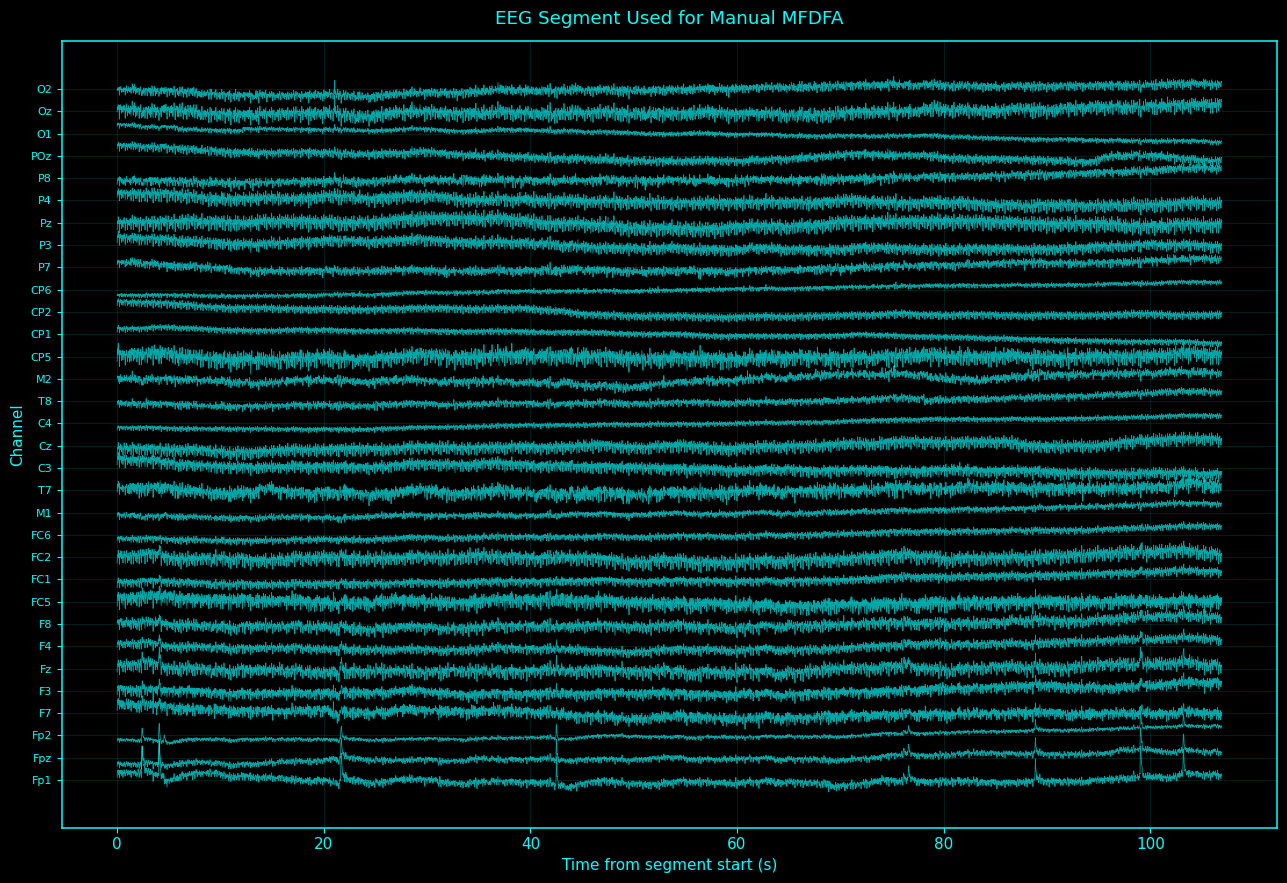


PLOT 1 — Multifractal Spectrum Width by Channel

What you are seeing:
  - Each horizontal bar is one EEG channel.
  - The x-axis is alpha width, also called Δα.
  - Channels are sorted from narrowest to widest spectrum.
  - The vertical dashed line marks the mean alpha width.
  - A wider spectrum indicates a broader range of scaling exponents.

Patterns to look for:
  - Look for the widest-spectrum channels.
  - Look for the narrowest-spectrum channels.
  - Look for whether high-width channels cluster in one scalp region.
  - Look for whether low-width channels cluster in one scalp region.
  - Look for one channel far wider than all others.
  - Look for tightly grouped channels, which means similar multifractal spread.
  - Look for whether mastoid channels differ from scalp channels.
  - Look for whether frontal, parietal, or occipital channels dominate the high-width end.
  - Look for whether channels with high width also have good fit quality later.
  - Look for whether high width a

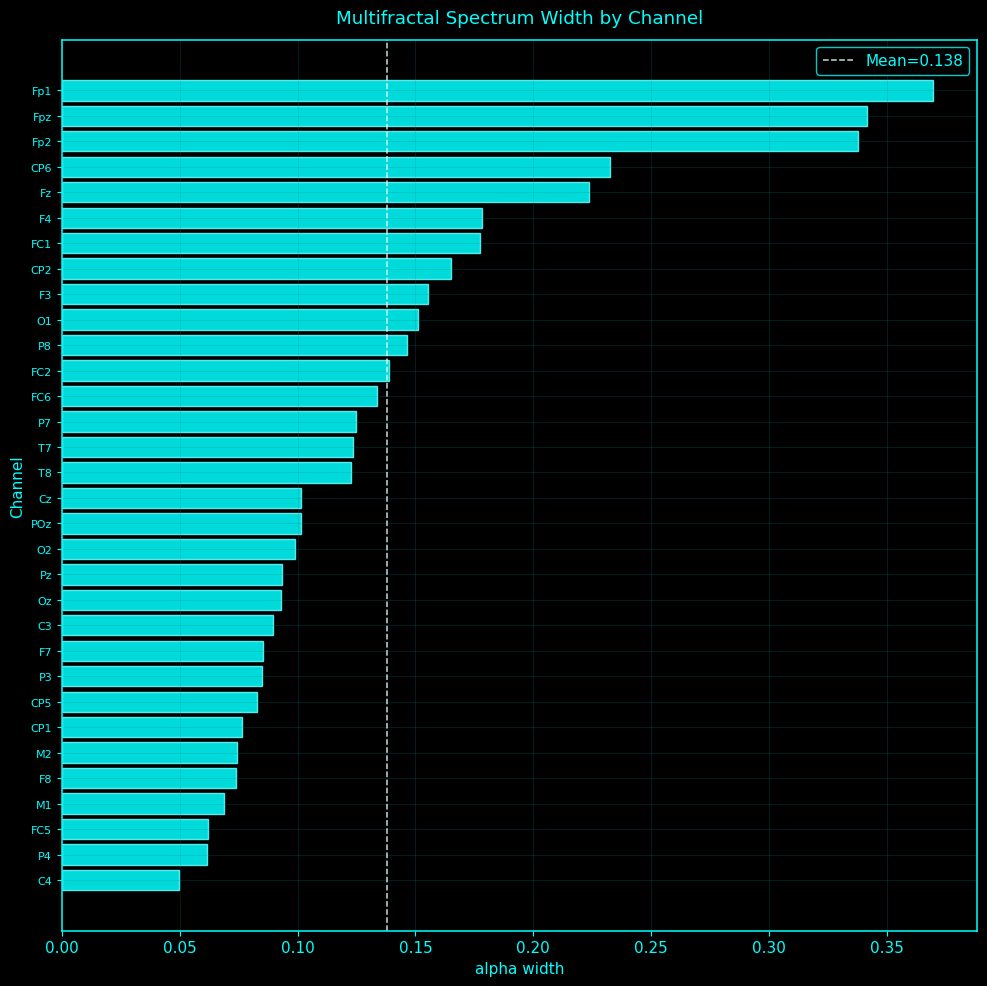


PLOT 2 — Multifractal Spectrum Asymmetry by Channel

What you are seeing:
  - Each horizontal bar is one EEG channel.
  - The x-axis is right width minus left width of the multifractal spectrum.
  - The vertical zero line means the spectrum is balanced around its peak.
  - Positive values mean the right side of the spectrum is wider.
  - Negative values mean the left side of the spectrum is wider.

Patterns to look for:
  - Look for channels far to the positive side.
  - Look for channels far to the negative side.
  - Look for channels close to zero.
  - Look for whether asymmetry direction is consistent across many channels.
  - Look for whether one region tends to have positive asymmetry.
  - Look for whether one region tends to have negative asymmetry.
  - Look for isolated strong asymmetry.
  - Look for whether high-width channels also have strong asymmetry.
  - Look for whether asymmetry is driven by a few channels.
  - Look for left-right homologous channels with similar asymmet

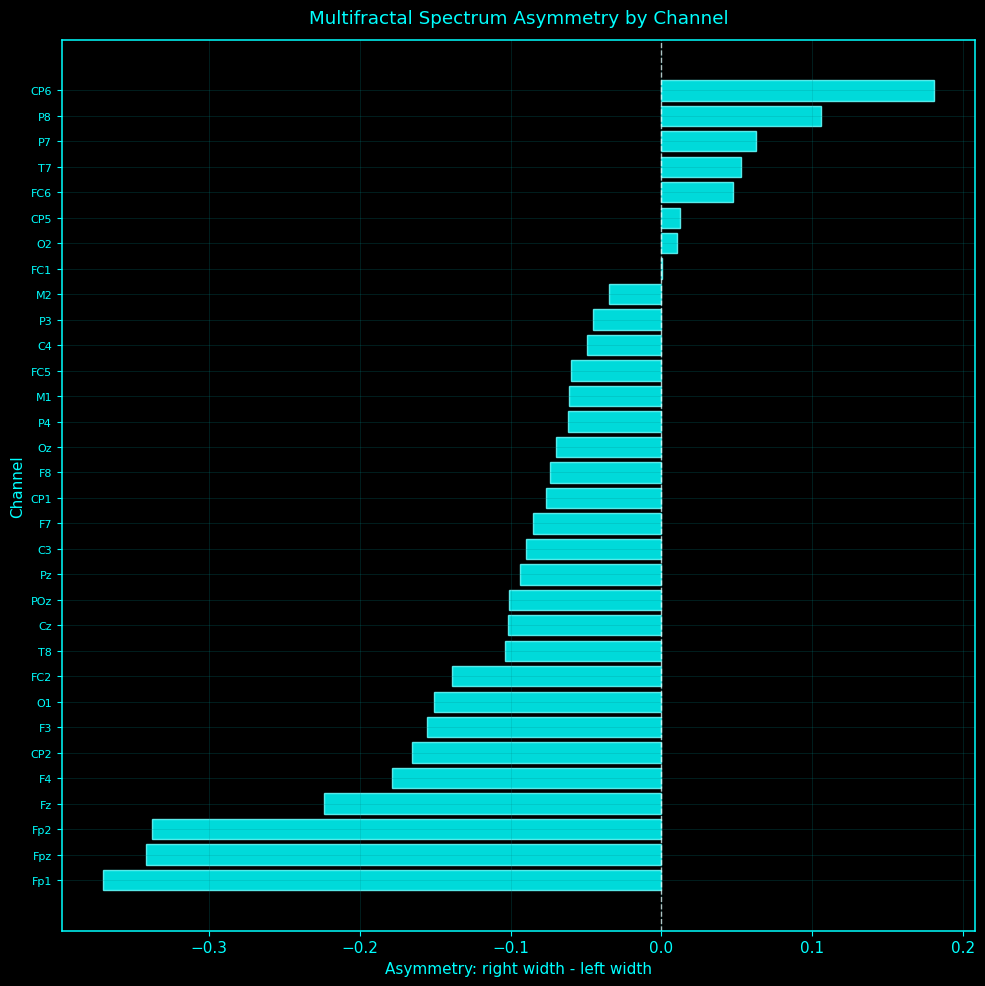


PLOT 3 — Generalized Hurst Exponent Curves Across Channels

What you are seeing:
  - Each faint cyan curve is one channel's h(q) curve.
  - The white curve is the mean h(q) across channels.
  - The dashed cyan curve is the median h(q) across channels.
  - The x-axis is q, which controls whether small or large fluctuations are emphasized.
  - The y-axis is h(q), the generalized Hurst exponent.

Patterns to look for:
  - Look for whether h(q) changes strongly across q.
  - Look for whether h(q) is nearly flat across q.
  - Look for whether curves slope downward as q increases.
  - Look for whether curves slope upward as q increases.
  - Look for channels that separate strongly from the group.
  - Look for whether mean and median curves are close together.
  - Look for whether negative-q behavior differs strongly from positive-q behavior.
  - Look for whether high-q behavior is unstable or scattered.
  - Look for whether all channels share the same broad shape.
  - Look for channels with

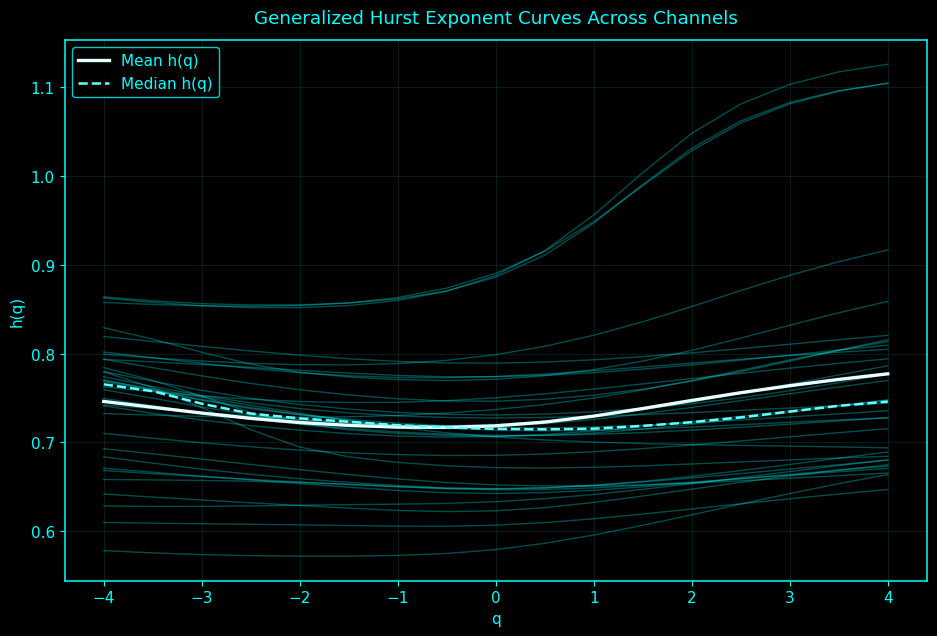


PLOT 4 — Multifractal Spectra Across Channels

What you are seeing:
  - Each cyan curve is one channel's multifractal spectrum f(alpha).
  - The x-axis is alpha, the local scaling strength.
  - The y-axis is f(alpha), the spectrum value.
  - Wider curves indicate broader scaling diversity.
  - Narrower curves indicate more uniform scaling behavior.

Patterns to look for:
  - Look for wide spectra.
  - Look for narrow spectra.
  - Look for spectra shifted left or right.
  - Look for spectra with different peak locations.
  - Look for curves with strong left or right asymmetry.
  - Look for curves that are smooth and compact.
  - Look for jagged or irregular curves.
  - Look for channels whose spectra are far from the group.
  - Look for whether most spectra overlap strongly.
  - Look for whether the spectrum shapes agree with alpha-width rankings.

Cautions:
  - The spectrum is derived from numerical derivatives, so noisy h(q) can distort it.
  - Very irregular spectra should be checke

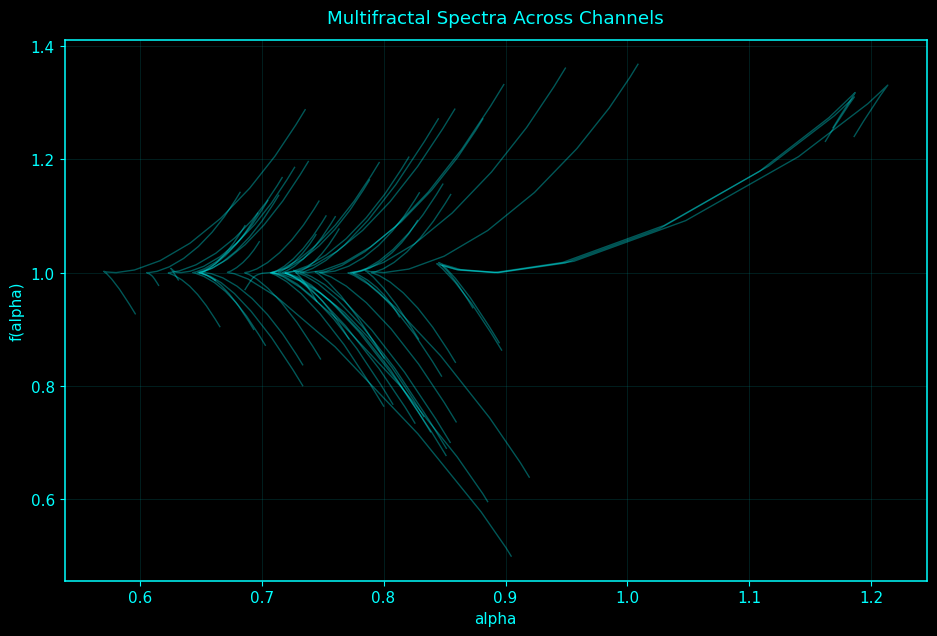


PLOT 5 — Generalized Hurst Exponent Heatmap h(q)

What you are seeing:
  - Each row is one EEG channel.
  - Each column is one q value.
  - Each cell color shows h(q) for that channel and q.
  - Rows are sorted by mean h(q).
  - This plot shows how scaling changes across fluctuation emphasis.

Patterns to look for:
  - Look for rows that stay bright across q.
  - Look for rows that stay dark across q.
  - Look for strong left-to-right gradients.
  - Look for channels that are high at negative q but low at positive q.
  - Look for channels that are low at negative q but high at positive q.
  - Look for abrupt changes at q=0.
  - Look for groups of channels with similar q-patterns.
  - Look for isolated unusual rows.
  - Look for whether high-alpha-width channels show strong q-dependence.
  - Look for whether mean h(q) varies smoothly across q.

Cautions:
  - Heatmap color is relative to the plotted range.
  - Endpoint q values can be less stable.
  - Use this together with h(q) curves 

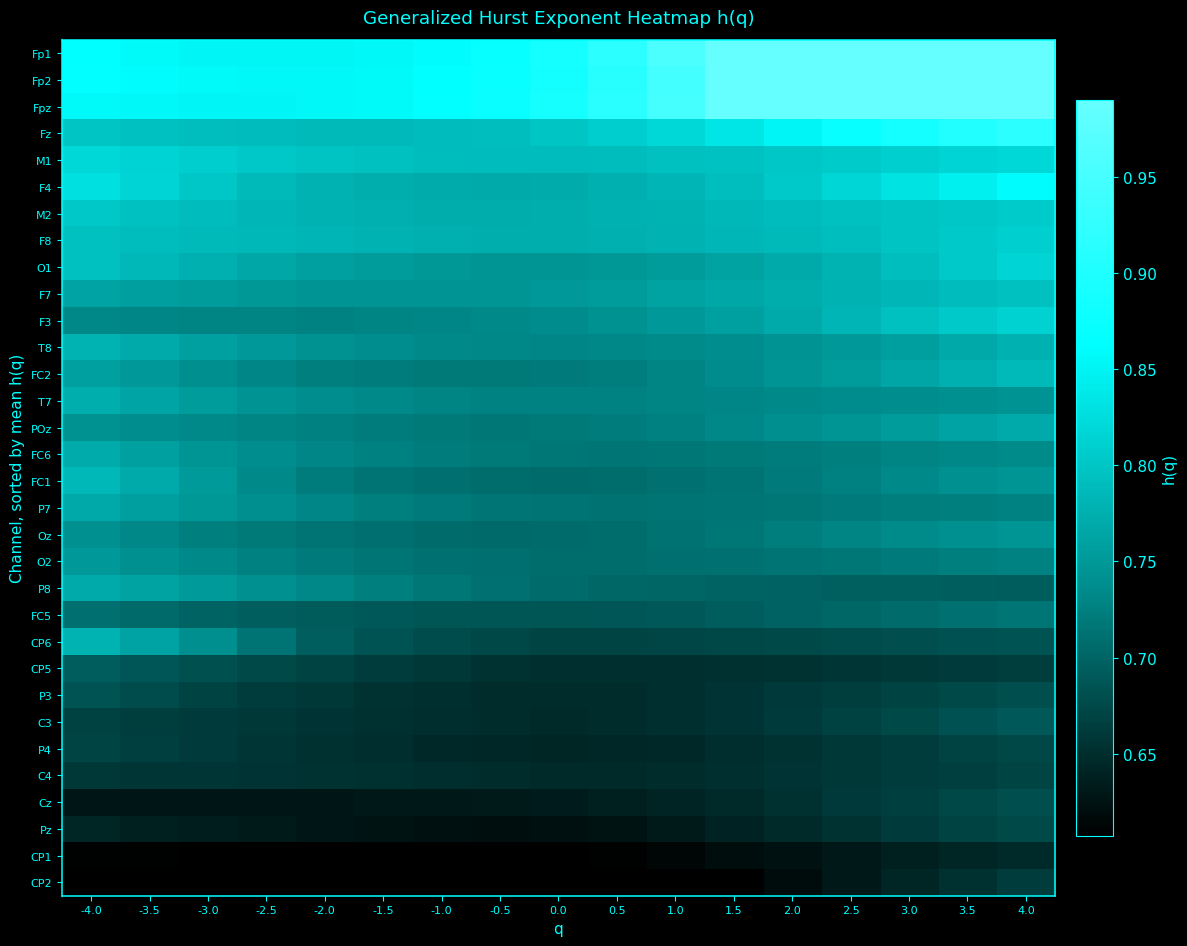


PLOT 6 — MFDFA Summary Metric Heatmap

What you are seeing:
  - Each row is one EEG channel.
  - Each column is one summary metric.
  - Columns are normalized independently from 0 to 1 for visual comparison.
  - Rows are sorted by multifractal complexity score.
  - This plot compares multiple numerical summaries at once.

Patterns to look for:
  - Look for channels bright across several important metrics.
  - Look for channels with high alpha width but low fit quality.
  - Look for channels with high complexity score.
  - Look for channels with high hq_range.
  - Look for channels with strong asymmetry.
  - Look for channels with high h(q=0).
  - Look for rows where metrics disagree.
  - Look for rows where metrics agree strongly.
  - Look for whether fit quality supports the high-complexity rows.
  - Look for regional clustering in adjacent channel names.

Cautions:
  - Column normalization means colors cannot be compared as raw magnitudes across columns.
  - Use the CSV for exact va

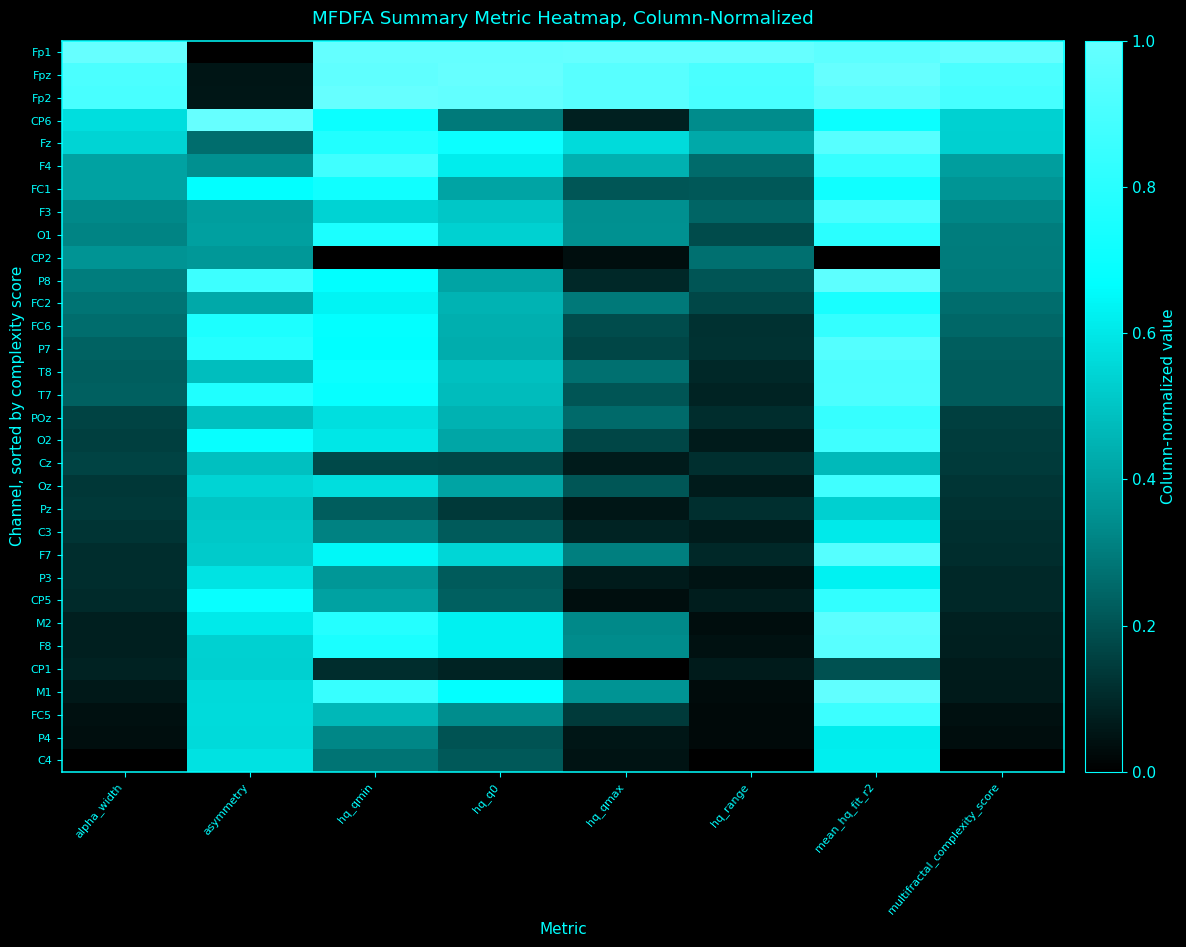


PLOT 7 — Multifractal Width versus h(q=0)

What you are seeing:
  - Each point is one EEG channel.
  - The x-axis is h(q=0), a central scaling estimate.
  - The y-axis is alpha width, the spread of the multifractal spectrum.
  - Point size reflects mean h(q) fit R².
  - Labels mark high-scoring channels.

Patterns to look for:
  - Look for points high on the y-axis.
  - Look for points far to the right.
  - Look for points far to the left.
  - Look for upper-right channels: high h0 and broad spectrum.
  - Look for upper-left channels: low h0 and broad spectrum.
  - Look for lower points: narrow spectra.
  - Look for large points with high alpha width.
  - Look for small points with high alpha width.
  - Look for clusters of channels.
  - Look for isolated labeled channels.

Cautions:
  - A high-width point with small marker size may have weaker fit quality.
  - h(q=0) and alpha width describe different aspects of scaling.
  - Use this plot to separate central scaling level from multif

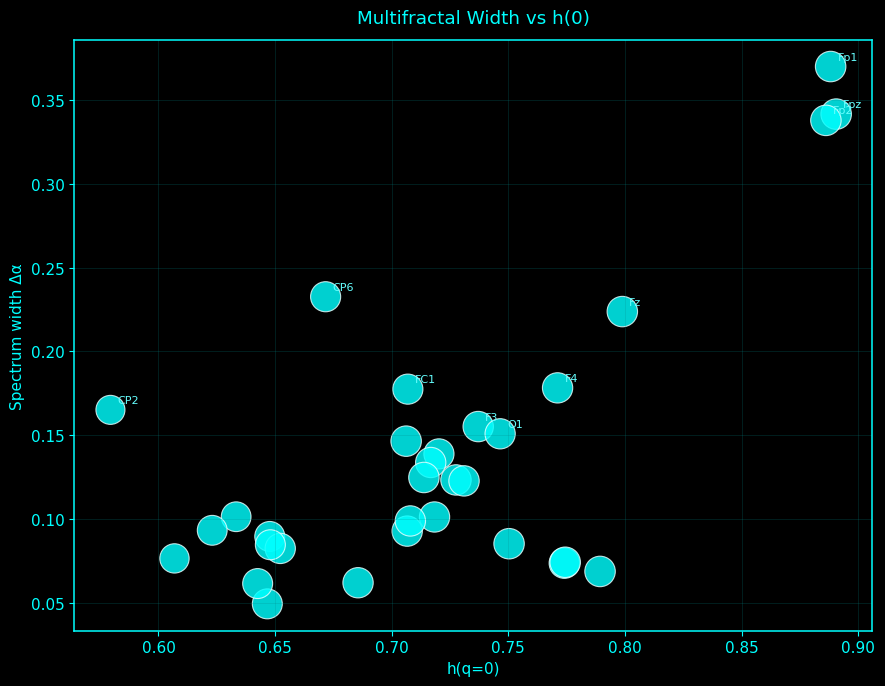


PLOT 8 — Spectrum Gallery for Channels with Widest Spectra

What you are seeing:
  - Each panel shows one channel's multifractal spectrum.
  - The x-axis is alpha.
  - The y-axis is f(alpha).
  - Channels are selected by largest alpha width.
  - The title shows width and asymmetry.

Patterns to look for:
  - Look for broad spectra.
  - Look for narrow spectra even within this selected group.
  - Look for right-skewed spectra.
  - Look for left-skewed spectra.
  - Look for smooth spectrum shapes.
  - Look for jagged spectrum shapes.
  - Look for spectra shifted to larger alpha.
  - Look for spectra shifted to smaller alpha.
  - Look for channels with similar spectrum shapes.
  - Look for channels where the spectrum appears unstable.

Cautions:
  - This gallery shows selected channels, not all channels.
  - A wide spectrum should be checked against fit quality.
  - Jagged spectra may reflect numerical instability.



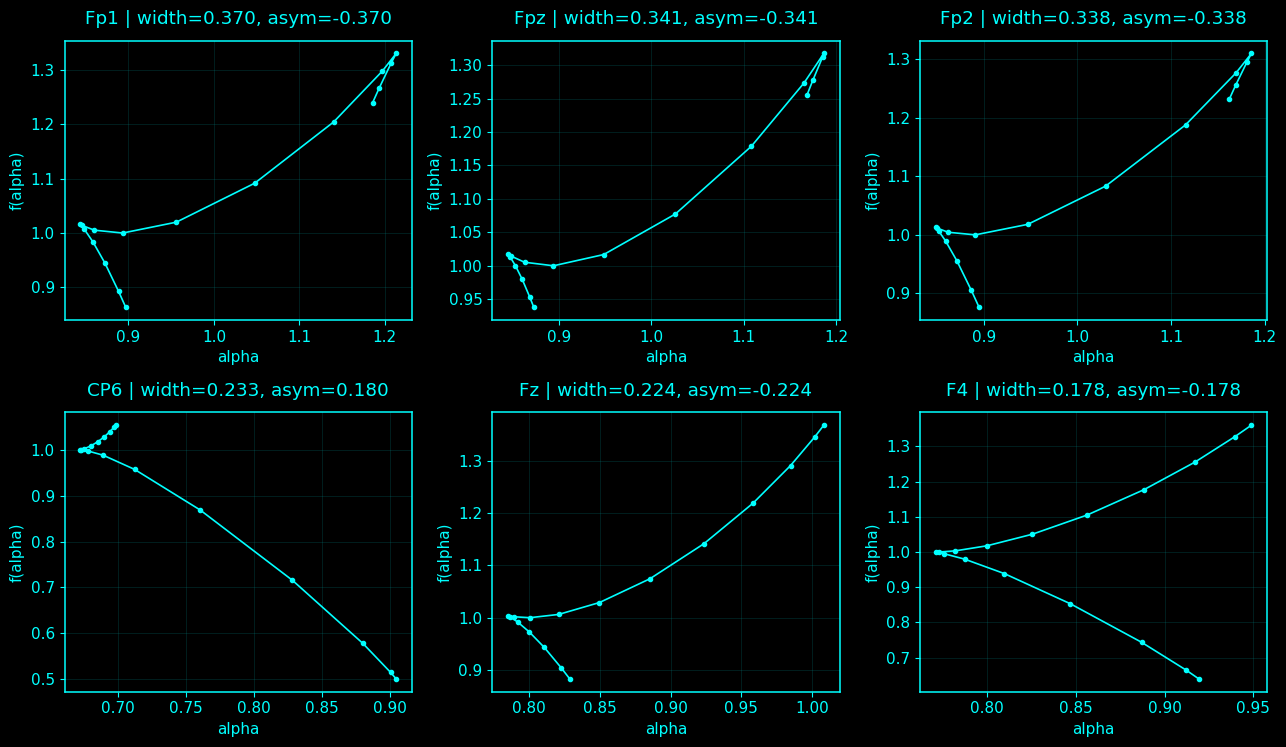


PLOT 9 — Fq Scaling Gallery for High-Score Channels

What you are seeing:
  - Each panel shows log Fq(s) versus log scale for one selected channel.
  - Three representative q values are plotted: lowest q, q near zero, and highest q.
  - Channels are selected by multifractal complexity score.
  - Different q curves show how small, typical, and large fluctuations scale.
  - Straighter lines indicate cleaner scaling.

Patterns to look for:
  - Look for approximately straight scaling lines.
  - Look for curvature in any q curve.
  - Look for separation between low-q and high-q curves.
  - Look for channels where all q curves scale similarly.
  - Look for channels where q curves have different slopes.
  - Look for unstable behavior at the smallest scales.
  - Look for unstable behavior at the largest scales.
  - Look for one q curve dominating the pattern.
  - Look for whether high-score channels have clean scaling.
  - Look for channels where score is high but scaling looks poor.

Caution

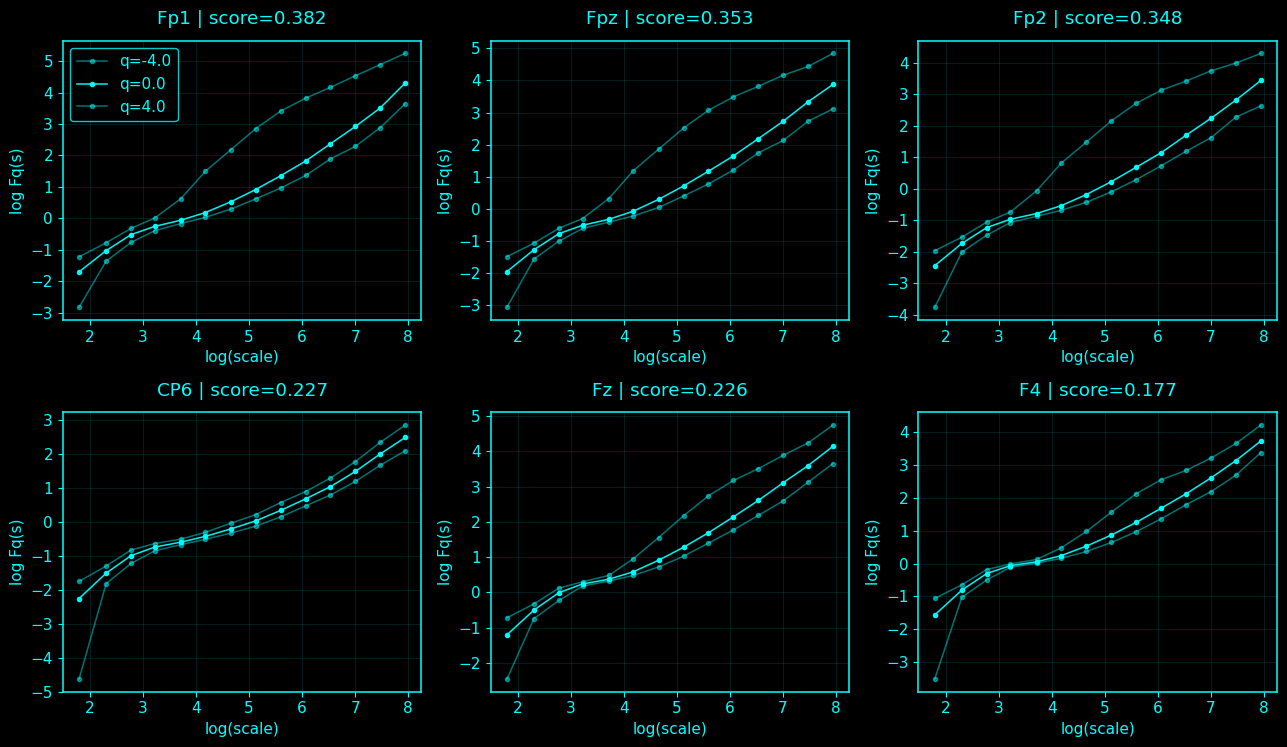


PLOT 10 — Approximate Scalp Map of MFDFA Spectrum Width

What you are seeing:
  - Each labeled point is one EEG electrode.
  - Electrode position is approximate.
  - Color shows alpha width at that electrode.
  - Frontal channels are toward the top.
  - Occipital channels are toward the bottom.

Patterns to look for:
  - Look for spatial clusters of high alpha width.
  - Look for spatial clusters of low alpha width.
  - Look for anterior-posterior gradients.
  - Look for left-right imbalance.
  - Look for isolated high-width electrodes.
  - Look for isolated low-width electrodes.
  - Look for whether neighboring electrodes agree.
  - Look for whether mastoid channels are unusual.
  - Look for whether the scalp map agrees with regional summaries.
  - Look for whether spatial patterns agree with the alpha-width bar plot.

Cautions:
  - This is an approximate scalp layout, not an interpolated clinical topography.
  - Spatially coherent patterns are stronger than isolated points.
  - Chec

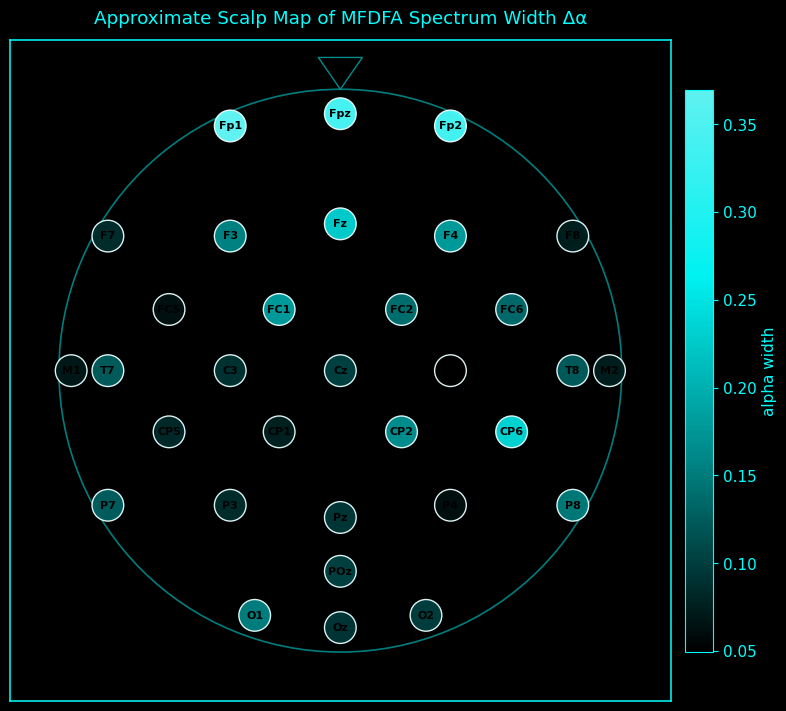


PLOT 11 — Regional Summary of MFDFA Spectrum Width

What you are seeing:
  - Each horizontal bar is one broad scalp region.
  - The x-axis is mean alpha width.
  - Error bars show standard deviation within the region.
  - Text labels show number of channels and mean fit R².
  - This plot summarizes channel-level multifractal spread by region.

Patterns to look for:
  - Look for the region with highest mean alpha width.
  - Look for the region with lowest mean alpha width.
  - Look for large error bars.
  - Look for small error bars.
  - Look for regions with high width and high R².
  - Look for regions with high width but weak R².
  - Look for whether frontal, parietal, and occipital regions differ.
  - Look for whether central-temporal channels differ.
  - Look for regions with few channels.
  - Look for agreement with the scalp map.

Cautions:
  - Regional averages can hide channel-level outliers.
  - Regions with few channels should be interpreted carefully.
  - A regional result i

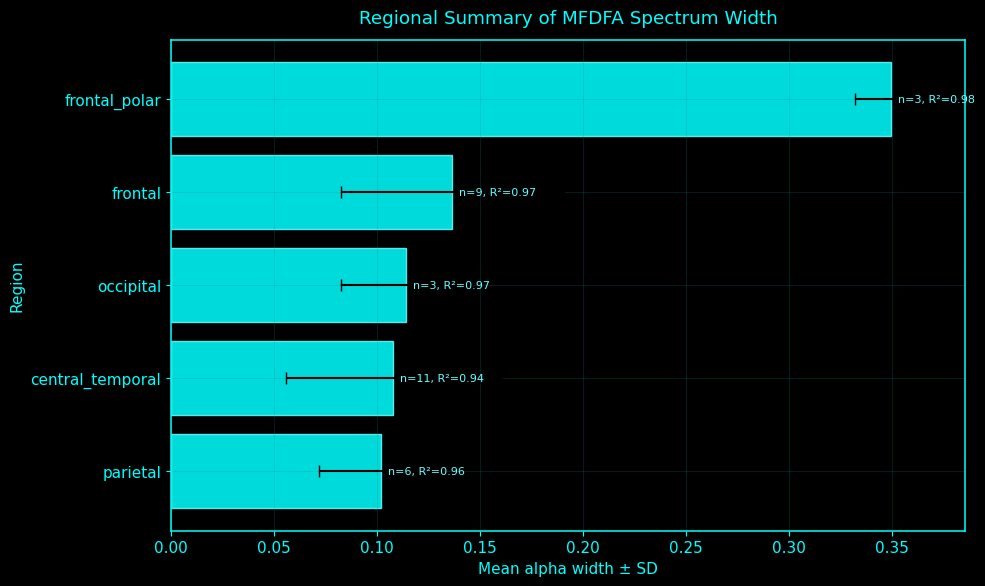


PLOT 12 — Homologous Left-Right MFDFA Width Asymmetry

What you are seeing:
  - Each horizontal bar is one homologous left-right channel pair.
  - The x-axis is left alpha width minus right alpha width.
  - The vertical zero line indicates equal left and right alpha width.
  - Bars to the right mean the left channel has wider spectrum.
  - Bars to the left mean the right channel has wider spectrum.

Patterns to look for:
  - Look for pairs far from zero.
  - Look for many pairs leaning left.
  - Look for many pairs leaning right.
  - Look for one isolated asymmetric pair.
  - Look for frontal asymmetry.
  - Look for central asymmetry.
  - Look for parietal or occipital asymmetry.
  - Look for pairs close to zero.
  - Look for whether asymmetry agrees with scalp map.
  - Look for whether asymmetry might be driven by one low-quality channel.

Cautions:
  - A repeated pattern across several pairs is stronger than one isolated pair.
  - Check fit quality for strongly asymmetric pairs.
  -

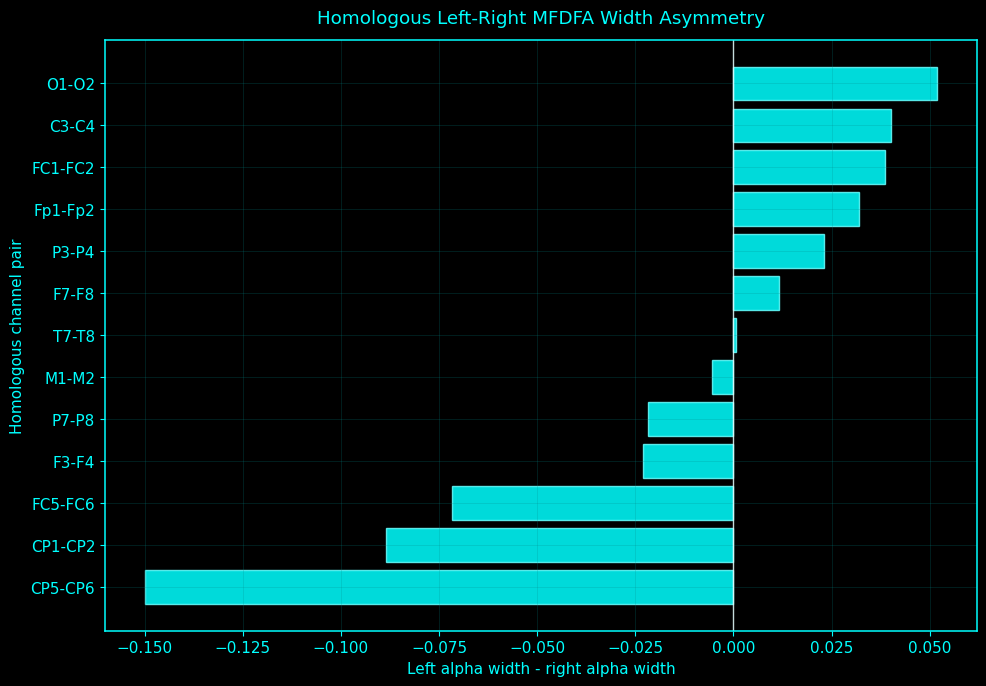


MANUAL MFDFA ANALYSIS SUMMARY
FAST_OPTION: ultra
Rows computed: 32
Channels analyzed: 32
Scales used: 14
q values used: 17
Mean alpha width: 0.138133
Median alpha width: 0.112151
Mean h(q=0): 0.718706
Mean h(q) fit R²: 0.958709
Total elapsed: 0.15 min

Top 15 channels by multifractal complexity score:
channel  alpha_width  asymmetry  hq_qmin    hq_q0  hq_qmax  mean_hq_fit_r2  multifractal_complexity_score hemisphere           region
    Fp1     0.369818  -0.369818 0.862622 0.888154 1.125833        0.979719                       0.382417       left    frontal_polar
    Fpz     0.341461  -0.341461 0.857638 0.890523 1.104632        0.982953                       0.352831    midline    frontal_polar
    Fp2     0.337733  -0.337733 0.863890 0.886121 1.104393        0.979767                       0.347663      right    frontal_polar
    CP6     0.232611   0.180424 0.779566 0.671661 0.684475        0.950185                       0.227005      right central_temporal
     Fz     0.223755  -0.2

# Interpretation of Manual MFDFA Results

This report interprets the numerical results after the MFDFA run has finished. The goal is to connect alpha width, spectrum asymmetry, generalized Hurst behavior, fit quality, spatial organization, and temporal stability into a careful reading of the EEG segment.

---

## 1. Overall multifractal spread

- Valid channels: **32**
- Mean alpha width: **0.1381**
- Median alpha width: **0.1122**
- Standard deviation of alpha width: **0.0827**
- Minimum alpha width: **0.0495**
- Maximum alpha width: **0.3698**
- Alpha-width range: **0.3203**
- Mean h(q=0): **0.7187**
- Median h(q=0): **0.7153**
- Mean complexity score: **0.1362**
- Median complexity score: **0.1102**

**Interpretation:** The alpha width is modest, suggesting limited multifractal spread.

The channel-to-channel alpha-width spread is large. This suggests strong spatial heterogeneity in multifractal behavior or possible channel-specific instability.

Alpha width is the main measure of how broad the multifractal spectrum is. A broader spectrum means the signal contains a wider range of scaling behaviors. A narrow spectrum means the signal behaves more uniformly across fluctuation sizes.

---

## 2. Channels with strongest and weakest multifractal spread

Highest alpha-width channels:

- **Fp1**: alpha_width=0.3698, asymmetry=-0.3698, hq_q0=0.8882, mean_hq_fit_r2=0.9797, multifractal_complexity_score=0.3824, region=frontal_polar, hemisphere=left
- **Fpz**: alpha_width=0.3415, asymmetry=-0.3415, hq_q0=0.8905, mean_hq_fit_r2=0.9830, multifractal_complexity_score=0.3528, region=frontal_polar, hemisphere=midline
- **Fp2**: alpha_width=0.3377, asymmetry=-0.3377, hq_q0=0.8861, mean_hq_fit_r2=0.9798, multifractal_complexity_score=0.3477, region=frontal_polar, hemisphere=right
- **CP6**: alpha_width=0.2326, asymmetry=0.1804, hq_q0=0.6717, mean_hq_fit_r2=0.9502, multifractal_complexity_score=0.2270, region=central_temporal, hemisphere=right
- **Fz**: alpha_width=0.2238, asymmetry=-0.2238, hq_q0=0.7989, mean_hq_fit_r2=0.9775, multifractal_complexity_score=0.2261, region=frontal, hemisphere=midline
- **F4**: alpha_width=0.1783, asymmetry=-0.1783, hq_q0=0.7711, mean_hq_fit_r2=0.9654, multifractal_complexity_score=0.1767, region=frontal, hemisphere=right
- **FC1**: alpha_width=0.1775, asymmetry=0.0004, hq_q0=0.7069, mean_hq_fit_r2=0.9519, multifractal_complexity_score=0.1690, region=frontal, hemisphere=left
- **CP2**: alpha_width=0.1652, asymmetry=-0.1652, hq_q0=0.5794, mean_hq_fit_r2=0.8722, multifractal_complexity_score=0.1476, region=central_temporal, hemisphere=right
- **F3**: alpha_width=0.1552, asymmetry=-0.1552, hq_q0=0.7371, mean_hq_fit_r2=0.9725, multifractal_complexity_score=0.1545, region=frontal, hemisphere=left
- **O1**: alpha_width=0.1509, asymmetry=-0.1509, hq_q0=0.7465, mean_hq_fit_r2=0.9611, multifractal_complexity_score=0.1483, region=occipital, hemisphere=left
- **P8**: alpha_width=0.1465, asymmetry=0.1058, hq_q0=0.7062, mean_hq_fit_r2=0.9795, multifractal_complexity_score=0.1458, region=parietal, hemisphere=right
- **FC2**: alpha_width=0.1389, asymmetry=-0.1389, hq_q0=0.7202, mean_hq_fit_r2=0.9545, multifractal_complexity_score=0.1354, region=frontal, hemisphere=right

Lowest alpha-width channels:

- **C4**: alpha_width=0.0495, asymmetry=-0.0495, hq_q0=0.6467, mean_hq_fit_r2=0.9412, multifractal_complexity_score=0.0470, region=central_temporal, hemisphere=right
- **P4**: alpha_width=0.0616, asymmetry=-0.0616, hq_q0=0.6425, mean_hq_fit_r2=0.9402, multifractal_complexity_score=0.0585, region=parietal, hemisphere=right
- **FC5**: alpha_width=0.0621, asymmetry=-0.0596, hq_q0=0.6856, mean_hq_fit_r2=0.9676, multifractal_complexity_score=0.0606, region=frontal, hemisphere=left
- **M1**: alpha_width=0.0689, asymmetry=-0.0612, hq_q0=0.7893, mean_hq_fit_r2=0.9810, multifractal_complexity_score=0.0682, region=central_temporal, hemisphere=left
- **F8**: alpha_width=0.0738, asymmetry=-0.0738, hq_q0=0.7740, mean_hq_fit_r2=0.9781, multifractal_complexity_score=0.0730, region=frontal, hemisphere=right
- **M2**: alpha_width=0.0743, asymmetry=-0.0350, hq_q0=0.7744, mean_hq_fit_r2=0.9794, multifractal_complexity_score=0.0732, region=central_temporal, hemisphere=right
- **CP1**: alpha_width=0.0766, asymmetry=-0.0766, hq_q0=0.6069, mean_hq_fit_r2=0.8941, multifractal_complexity_score=0.0693, region=central_temporal, hemisphere=left
- **CP5**: alpha_width=0.0826, asymmetry=0.0121, hq_q0=0.6522, mean_hq_fit_r2=0.9641, multifractal_complexity_score=0.0798, region=central_temporal, hemisphere=left
- **P3**: alpha_width=0.0848, asymmetry=-0.0454, hq_q0=0.6480, mean_hq_fit_r2=0.9420, multifractal_complexity_score=0.0804, region=parietal, hemisphere=left
- **F7**: alpha_width=0.0854, asymmetry=-0.0854, hq_q0=0.7503, mean_hq_fit_r2=0.9769, multifractal_complexity_score=0.0845, region=frontal, hemisphere=left
- **C3**: alpha_width=0.0897, asymmetry=-0.0897, hq_q0=0.6477, mean_hq_fit_r2=0.9396, multifractal_complexity_score=0.0854, region=central_temporal, hemisphere=left
- **Oz**: alpha_width=0.0929, asymmetry=-0.0697, hq_q0=0.7066, mean_hq_fit_r2=0.9694, multifractal_complexity_score=0.0910, region=occipital, hemisphere=midline

The widest spectrum is found in **Fp1** (alpha width=0.3698). The alpha width is large, suggesting broad scaling diversity or possible instability that should be checked against fit quality. The scaling fits are good.

The narrowest spectrum is found in **C4** (alpha width=0.0495). This channel shows the most compact scaling-spectrum estimate among the valid channels.

The highest-width channels are candidates for richer multifractal behavior, but they become convincing only when the fit quality and spectrum shape are also acceptable.

---

## 3. Complexity-score ranking

Top channels by multifractal complexity score:

- **Fp1**: multifractal_complexity_score=0.3824, alpha_width=0.3698, asymmetry=-0.3698, hq_q0=0.8882, mean_hq_fit_r2=0.9797, region=frontal_polar, hemisphere=left
- **Fpz**: multifractal_complexity_score=0.3528, alpha_width=0.3415, asymmetry=-0.3415, hq_q0=0.8905, mean_hq_fit_r2=0.9830, region=frontal_polar, hemisphere=midline
- **Fp2**: multifractal_complexity_score=0.3477, alpha_width=0.3377, asymmetry=-0.3377, hq_q0=0.8861, mean_hq_fit_r2=0.9798, region=frontal_polar, hemisphere=right
- **CP6**: multifractal_complexity_score=0.2270, alpha_width=0.2326, asymmetry=0.1804, hq_q0=0.6717, mean_hq_fit_r2=0.9502, region=central_temporal, hemisphere=right
- **Fz**: multifractal_complexity_score=0.2261, alpha_width=0.2238, asymmetry=-0.2238, hq_q0=0.7989, mean_hq_fit_r2=0.9775, region=frontal, hemisphere=midline
- **F4**: multifractal_complexity_score=0.1767, alpha_width=0.1783, asymmetry=-0.1783, hq_q0=0.7711, mean_hq_fit_r2=0.9654, region=frontal, hemisphere=right
- **FC1**: multifractal_complexity_score=0.1690, alpha_width=0.1775, asymmetry=0.0004, hq_q0=0.7069, mean_hq_fit_r2=0.9519, region=frontal, hemisphere=left
- **F3**: multifractal_complexity_score=0.1545, alpha_width=0.1552, asymmetry=-0.1552, hq_q0=0.7371, mean_hq_fit_r2=0.9725, region=frontal, hemisphere=left
- **O1**: multifractal_complexity_score=0.1483, alpha_width=0.1509, asymmetry=-0.1509, hq_q0=0.7465, mean_hq_fit_r2=0.9611, region=occipital, hemisphere=left
- **CP2**: multifractal_complexity_score=0.1476, alpha_width=0.1652, asymmetry=-0.1652, hq_q0=0.5794, mean_hq_fit_r2=0.8722, region=central_temporal, hemisphere=right
- **P8**: multifractal_complexity_score=0.1458, alpha_width=0.1465, asymmetry=0.1058, hq_q0=0.7062, mean_hq_fit_r2=0.9795, region=parietal, hemisphere=right
- **FC2**: multifractal_complexity_score=0.1354, alpha_width=0.1389, asymmetry=-0.1389, hq_q0=0.7202, mean_hq_fit_r2=0.9545, region=frontal, hemisphere=right

The highest combined score is found in **Fp1** (score=0.3824, width=0.3698, R²=0.9797). This channel is a leading candidate because the score combines spectrum width, fit quality, and asymmetry information.

The score is a ranking aid, not a law of nature. It is useful because it avoids ranking only by width, but the individual components should still be inspected.

---

## 4. Spectrum asymmetry

- Mean asymmetry: **-0.0842**
- Median asymmetry: **-0.0752**

Strongest absolute asymmetry channels:

- **Fp1**: asymmetry=-0.3698, abs_asymmetry=0.3698, alpha_width=0.3698, hq_q0=0.8882, mean_hq_fit_r2=0.9797, region=frontal_polar
- **Fpz**: asymmetry=-0.3415, abs_asymmetry=0.3415, alpha_width=0.3415, hq_q0=0.8905, mean_hq_fit_r2=0.9830, region=frontal_polar
- **Fp2**: asymmetry=-0.3377, abs_asymmetry=0.3377, alpha_width=0.3377, hq_q0=0.8861, mean_hq_fit_r2=0.9798, region=frontal_polar
- **Fz**: asymmetry=-0.2238, abs_asymmetry=0.2238, alpha_width=0.2238, hq_q0=0.7989, mean_hq_fit_r2=0.9775, region=frontal
- **CP6**: asymmetry=0.1804, abs_asymmetry=0.1804, alpha_width=0.2326, hq_q0=0.6717, mean_hq_fit_r2=0.9502, region=central_temporal
- **F4**: asymmetry=-0.1783, abs_asymmetry=0.1783, alpha_width=0.1783, hq_q0=0.7711, mean_hq_fit_r2=0.9654, region=frontal
- **CP2**: asymmetry=-0.1652, abs_asymmetry=0.1652, alpha_width=0.1652, hq_q0=0.5794, mean_hq_fit_r2=0.8722, region=central_temporal
- **F3**: asymmetry=-0.1552, abs_asymmetry=0.1552, alpha_width=0.1552, hq_q0=0.7371, mean_hq_fit_r2=0.9725, region=frontal
- **O1**: asymmetry=-0.1509, abs_asymmetry=0.1509, alpha_width=0.1509, hq_q0=0.7465, mean_hq_fit_r2=0.9611, region=occipital
- **FC2**: asymmetry=-0.1389, abs_asymmetry=0.1389, alpha_width=0.1389, hq_q0=0.7202, mean_hq_fit_r2=0.9545, region=frontal
- **P8**: asymmetry=0.1058, abs_asymmetry=0.1058, alpha_width=0.1465, hq_q0=0.7062, mean_hq_fit_r2=0.9795, region=parietal
- **T8**: asymmetry=-0.1033, abs_asymmetry=0.1033, alpha_width=0.1228, hq_q0=0.7310, mean_hq_fit_r2=0.9733, region=central_temporal

The strongest spectrum asymmetry is found in **Fp1** (asymmetry=-0.3698). The spectrum is wider on the left side of the peak.

Asymmetry helps explain what kind of multifractal spread is present. A balanced wide spectrum and a strongly skewed wide spectrum are not the same pattern. Therefore, width should be interpreted together with asymmetry.

---

## 5. Fit quality and reliability

- Mean h(q) fit R²: **0.9587**
- Median h(q) fit R²: **0.9665**
- Minimum mean h(q) fit R²: **0.8722**

**Overall fit-quality reading:** The scaling fits are good.

Weakest mean h(q) fit-quality channels:

- **CP2**: mean_hq_fit_r2=0.8722, min_hq_fit_r2=0.8287, alpha_width=0.1652, asymmetry=-0.1652, hq_q0=0.5794, region=central_temporal
- **CP1**: mean_hq_fit_r2=0.8941, min_hq_fit_r2=0.8571, alpha_width=0.0766, asymmetry=-0.0766, hq_q0=0.6069, region=central_temporal
- **Cz**: mean_hq_fit_r2=0.9244, min_hq_fit_r2=0.8758, alpha_width=0.1015, asymmetry=-0.1015, hq_q0=0.6333, region=central_temporal
- **Pz**: mean_hq_fit_r2=0.9312, min_hq_fit_r2=0.8713, alpha_width=0.0934, asymmetry=-0.0934, hq_q0=0.6231, region=parietal
- **C3**: mean_hq_fit_r2=0.9396, min_hq_fit_r2=0.8852, alpha_width=0.0897, asymmetry=-0.0897, hq_q0=0.6477, region=central_temporal
- **P4**: mean_hq_fit_r2=0.9402, min_hq_fit_r2=0.8951, alpha_width=0.0616, asymmetry=-0.0616, hq_q0=0.6425, region=parietal
- **C4**: mean_hq_fit_r2=0.9412, min_hq_fit_r2=0.8970, alpha_width=0.0495, asymmetry=-0.0495, hq_q0=0.6467, region=central_temporal
- **P3**: mean_hq_fit_r2=0.9420, min_hq_fit_r2=0.8794, alpha_width=0.0848, asymmetry=-0.0454, hq_q0=0.6480, region=parietal
- **CP6**: mean_hq_fit_r2=0.9502, min_hq_fit_r2=0.8475, alpha_width=0.2326, asymmetry=0.1804, hq_q0=0.6717, region=central_temporal
- **FC1**: mean_hq_fit_r2=0.9519, min_hq_fit_r2=0.8605, alpha_width=0.1775, asymmetry=0.0004, hq_q0=0.7069, region=frontal
- **FC2**: mean_hq_fit_r2=0.9545, min_hq_fit_r2=0.8875, alpha_width=0.1389, asymmetry=-0.1389, hq_q0=0.7202, region=frontal
- **O1**: mean_hq_fit_r2=0.9611, min_hq_fit_r2=0.9151, alpha_width=0.1509, asymmetry=-0.1509, hq_q0=0.7465, region=occipital

Strongest mean h(q) fit-quality channels:

- **Fpz**: mean_hq_fit_r2=0.9830, min_hq_fit_r2=0.9665, alpha_width=0.3415, asymmetry=-0.3415, hq_q0=0.8905, region=frontal_polar
- **M1**: mean_hq_fit_r2=0.9810, min_hq_fit_r2=0.9567, alpha_width=0.0689, asymmetry=-0.0612, hq_q0=0.7893, region=central_temporal
- **Fp2**: mean_hq_fit_r2=0.9798, min_hq_fit_r2=0.9555, alpha_width=0.3377, asymmetry=-0.3377, hq_q0=0.8861, region=frontal_polar
- **Fp1**: mean_hq_fit_r2=0.9797, min_hq_fit_r2=0.9618, alpha_width=0.3698, asymmetry=-0.3698, hq_q0=0.8882, region=frontal_polar
- **P8**: mean_hq_fit_r2=0.9795, min_hq_fit_r2=0.9515, alpha_width=0.1465, asymmetry=0.1058, hq_q0=0.7062, region=parietal
- **M2**: mean_hq_fit_r2=0.9794, min_hq_fit_r2=0.9651, alpha_width=0.0743, asymmetry=-0.0350, hq_q0=0.7744, region=central_temporal
- **F8**: mean_hq_fit_r2=0.9781, min_hq_fit_r2=0.9472, alpha_width=0.0738, asymmetry=-0.0738, hq_q0=0.7740, region=frontal
- **Fz**: mean_hq_fit_r2=0.9775, min_hq_fit_r2=0.9479, alpha_width=0.2238, asymmetry=-0.2238, hq_q0=0.7989, region=frontal
- **F7**: mean_hq_fit_r2=0.9769, min_hq_fit_r2=0.9565, alpha_width=0.0854, asymmetry=-0.0854, hq_q0=0.7503, region=frontal
- **P7**: mean_hq_fit_r2=0.9763, min_hq_fit_r2=0.9437, alpha_width=0.1249, asymmetry=0.0630, hq_q0=0.7138, region=parietal
- **T7**: mean_hq_fit_r2=0.9737, min_hq_fit_r2=0.9412, alpha_width=0.1234, asymmetry=0.0526, hq_q0=0.7275, region=central_temporal
- **T8**: mean_hq_fit_r2=0.9733, min_hq_fit_r2=0.9275, alpha_width=0.1228, asymmetry=-0.1033, hq_q0=0.7310, region=central_temporal

Some high-width channels have mean fit R² below 0.95. These channels may still be important, but they should be inspected with the Fq scaling gallery before being treated as strong findings:

- **CP2**: alpha_width=0.1652, mean_hq_fit_r2=0.8722, min_hq_fit_r2=0.8287, asymmetry=-0.1652, region=central_temporal
- **Cz**: alpha_width=0.1015, mean_hq_fit_r2=0.9244, min_hq_fit_r2=0.8758, asymmetry=-0.1015, region=central_temporal
- **Pz**: alpha_width=0.0934, mean_hq_fit_r2=0.9312, min_hq_fit_r2=0.8713, asymmetry=-0.0934, region=parietal
- **C3**: alpha_width=0.0897, mean_hq_fit_r2=0.9396, min_hq_fit_r2=0.8852, asymmetry=-0.0897, region=central_temporal
- **P3**: alpha_width=0.0848, mean_hq_fit_r2=0.9420, min_hq_fit_r2=0.8794, asymmetry=-0.0454, region=parietal
- **CP1**: alpha_width=0.0766, mean_hq_fit_r2=0.8941, min_hq_fit_r2=0.8571, asymmetry=-0.0766, region=central_temporal
- **P4**: alpha_width=0.0616, mean_hq_fit_r2=0.9402, min_hq_fit_r2=0.8951, asymmetry=-0.0616, region=parietal
- **C4**: alpha_width=0.0495, mean_hq_fit_r2=0.9412, min_hq_fit_r2=0.8970, asymmetry=-0.0495, region=central_temporal

The key rule is simple: alpha width tells us what is interesting; fit quality tells us how much confidence to place in it.

---

## 6. Regional pattern

Regional summary:

- **frontal_polar**: mean_alpha_width=0.3497, std_alpha_width=0.0175, mean_asymmetry=-0.3497, mean_hq0=0.8883, mean_r2=0.9808, mean_score=0.3610, n=3.0000
- **frontal**: mean_alpha_width=0.1365, std_alpha_width=0.0542, mean_asymmetry=-0.0963, mean_hq0=0.7401, mean_r2=0.9677, mean_score=0.1344, n=9.0000
- **occipital**: mean_alpha_width=0.1143, std_alpha_width=0.0319, mean_asymmetry=-0.0700, mean_hq0=0.7204, mean_r2=0.9664, mean_score=0.1118, n=3.0000
- **central_temporal**: mean_alpha_width=0.1079, std_alpha_width=0.0523, mean_asymmetry=-0.0397, mean_hq0=0.6782, mean_r2=0.9448, mean_score=0.1032, n=11.0000
- **parietal**: mean_alpha_width=0.1021, std_alpha_width=0.0300, mean_asymmetry=-0.0221, mean_hq0=0.6753, mean_r2=0.9558, mean_score=0.0992, n=6.0000

The region with highest mean alpha width is **frontal_polar** (mean width=0.3497, mean R²=0.9808). The region with lowest mean alpha width is **parietal** (mean width=0.1021, mean R²=0.9558).

A regional interpretation is stronger when the region has several channels, high fit quality, and modest within-region spread. Large regional standard deviation means the region contains mixed channel behavior.

---

## 7. Hemispheric pattern

Hemisphere summary:

- **midline**: mean_alpha_width=0.1590, std_alpha_width=0.1028, mean_asymmetry=-0.1552, mean_hq0=0.7285, mean_r2=0.9585, n=6.0000
- **right**: mean_alpha_width=0.1396, std_alpha_width=0.0790, mean_asymmetry=-0.0614, mean_hq0=0.7175, mean_r2=0.9575, n=13.0000
- **left**: mean_alpha_width=0.1271, std_alpha_width=0.0816, mean_asymmetry=-0.0743, mean_hq0=0.7154, mean_r2=0.9600, n=13.0000

The left-minus-right mean alpha-width difference is **-0.0125**. This is a small hemispheric difference, suggesting broadly balanced left-right multifractal spread.

The strongest asymmetry conclusion comes from repeated left-right differences across several homologous pairs, not from one pair alone.

---

## 8. Temporal stability

Temporal stability results were not available or were disabled. The analysis therefore describes the selected segment as a whole, but does not test whether the MFDFA metrics are stable inside that segment.

---

## 9. What makes a result stronger

A multifractal result is stronger when several signs agree:

- The channel has high alpha width relative to the rest.
- The h(q) curve changes smoothly across q.
- The Fq scaling curves are approximately linear in log-log space.
- The mean h(q) fit R² is high.
- The multifractal spectrum is smooth rather than jagged.
- Neighboring or regionally related channels show similar behavior.
- Temporal-window results are stable, when temporal analysis is enabled.

A result needs caution when:

- Alpha width is high but fit quality is weak.
- The spectrum is jagged or irregular.
- The result is driven by one isolated channel.
- The Fq curves are visibly curved rather than line-like.
- Extreme q values dominate the result.
- The channel has strong raw EEG artifacts.
- The result changes strongly across temporal windows.

---

## 10. Final synthesis

The strongest alpha-width candidate is **Fp1** (width=0.3698, R²=0.9797). The strongest combined-score candidate is **Fp1** (score=0.3824). The highest-width region is **frontal_polar** (mean width=0.3497). 

The safest conclusion is not simply that one channel has the largest alpha width. The stronger conclusion is that a channel or region shows richer multifractal structure when broad spectrum width, good fit quality, smooth h(q) behavior, coherent spectrum shape, spatial organization, and temporal stability all support the same interpretation.

---

## 11. One-sentence takeaway

MFDFA estimates whether EEG fluctuations scale in one simple way or across many scaling behaviors, and the most reliable findings are those where alpha width is supported by clean scaling fits, coherent spectra, spatial consistency, and temporal stability.


In [15]:
import os
import time
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

try:
    from IPython.display import display, Markdown
    _HAVE_IPYTHON_DISPLAY = True
except Exception:
    display = None
    Markdown = None
    _HAVE_IPYTHON_DISPLAY = False

base_dir = "/home/a/projects/Complete-Neural-Signal-Analysis"
eeg_path = os.path.join(base_dir, "eeg_data_with_channels.npy")

out_dir = os.path.join(base_dir, "results", "mfdfa_manual_fast")
plots_dir = os.path.join(out_dir, "plots")
per_channel_dir = os.path.join(plots_dir, "per_channel")
gallery_dir = os.path.join(plots_dir, "galleries")

os.makedirs(out_dir, exist_ok=True)
os.makedirs(plots_dir, exist_ok=True)
os.makedirs(per_channel_dir, exist_ok=True)
os.makedirs(gallery_dir, exist_ok=True)

FAST_OPTION = "ultra"

if FAST_OPTION == "ultra":
    scale_min_power = 0.8
    scale_max_power = 3.45
    n_scales = 14
    q_vals = np.linspace(-4, 4, 17)
    poly_order = 1
    max_channels = None
    raw_plot_max_points = 4000
    save_per_channel_plots = False
    show_per_channel_plots = False
    per_channel_plot_top_n = 0
    spectrum_gallery_top_n = 6
    fq_gallery_top_n = 6
    run_temporal_stability = False
    temporal_windows = 4
    temporal_q_vals = np.array([-4, 0, 4], dtype=float)
    save_Fq_long_csv = True

elif FAST_OPTION == "fast":
    scale_min_power = 0.7
    scale_max_power = 3.75
    n_scales = 20
    q_vals = np.linspace(-5, 5, 25)
    poly_order = 1
    max_channels = None
    raw_plot_max_points = 10000
    save_per_channel_plots = True
    show_per_channel_plots = False
    per_channel_plot_top_n = None
    spectrum_gallery_top_n = 9
    fq_gallery_top_n = 9
    run_temporal_stability = True
    temporal_windows = 6
    temporal_q_vals = np.array([-5, 0, 5], dtype=float)
    save_Fq_long_csv = True

elif FAST_OPTION == "balanced":
    scale_min_power = 0.7
    scale_max_power = 4.0
    n_scales = 30
    q_vals = np.linspace(-5, 5, 41)
    poly_order = 1
    max_channels = None
    raw_plot_max_points = 20000
    save_per_channel_plots = True
    show_per_channel_plots = False
    per_channel_plot_top_n = None
    spectrum_gallery_top_n = 12
    fq_gallery_top_n = 12
    run_temporal_stability = True
    temporal_windows = 10
    temporal_q_vals = np.array([-5, -2, 0, 2, 5], dtype=float)
    save_Fq_long_csv = True

elif FAST_OPTION == "full":
    scale_min_power = 0.7
    scale_max_power = 4.0
    n_scales = 36
    q_vals = np.linspace(-6, 6, 49)
    poly_order = 2
    max_channels = None
    raw_plot_max_points = None
    save_per_channel_plots = True
    show_per_channel_plots = False
    per_channel_plot_top_n = None
    spectrum_gallery_top_n = 16
    fq_gallery_top_n = 16
    run_temporal_stability = True
    temporal_windows = 16
    temporal_q_vals = np.array([-6, -3, 0, 3, 6], dtype=float)
    save_Fq_long_csv = True

else:
    raise ValueError("FAST_OPTION must be one of: 'ultra', 'fast', 'balanced', 'full'.")

sampling_rate = 1000
start_time = 814.571
end_time = 921.515
start_idx = int(start_time * sampling_rate)
end_idx = int(end_time * sampling_rate)

SHOW_PLOTS_IN_NOTEBOOK = True
SAVE_PLOTS_TO_DISK = True
STANDARDIZE_SIGNAL = True

ACCENT = "#00FFFF"
ACCENT_SOFT = "#66FFFF"
ACCENT_DIM = "#008B8B"
WHITE = "#E8FFFF"
BLACK = "#000000"
eps = 1e-12

eeg_channels = [
    "Fp1", "Fpz", "Fp2", "F7", "F3", "Fz", "F4", "F8", "FC5", "FC1", "FC2", "FC6",
    "M1", "T7", "C3", "Cz", "C4", "T8", "M2", "CP5", "CP1", "CP2", "CP6",
    "P7", "P3", "Pz", "P4", "P8", "POz", "O1", "Oz", "O2"
]

if max_channels is not None:
    eeg_channels = eeg_channels[:max_channels]

left_channels = ["Fp1", "F7", "F3", "FC5", "FC1", "M1", "T7", "C3", "CP5", "CP1", "P7", "P3", "O1"]
right_channels = ["Fp2", "F8", "F4", "FC2", "FC6", "M2", "T8", "C4", "CP2", "CP6", "P8", "P4", "O2"]
midline_channels = ["Fpz", "Fz", "Cz", "Pz", "POz", "Oz"]

electrode_xy = {
    "Fp1": (-0.45, 1.00), "Fpz": (0.00, 1.05), "Fp2": (0.45, 1.00),
    "F7": (-0.95, 0.55), "F3": (-0.45, 0.55), "Fz": (0.00, 0.60), "F4": (0.45, 0.55), "F8": (0.95, 0.55),
    "FC5": (-0.70, 0.25), "FC1": (-0.25, 0.25), "FC2": (0.25, 0.25), "FC6": (0.70, 0.25),
    "M1": (-1.10, 0.00), "T7": (-0.95, 0.00), "C3": (-0.45, 0.00), "Cz": (0.00, 0.00), "C4": (0.45, 0.00), "T8": (0.95, 0.00), "M2": (1.10, 0.00),
    "CP5": (-0.70, -0.25), "CP1": (-0.25, -0.25), "CP2": (0.25, -0.25), "CP6": (0.70, -0.25),
    "P7": (-0.95, -0.55), "P3": (-0.45, -0.55), "Pz": (0.00, -0.60), "P4": (0.45, -0.55), "P8": (0.95, -0.55),
    "POz": (0.00, -0.82), "O1": (-0.35, -1.00), "Oz": (0.00, -1.05), "O2": (0.35, -1.00),
}

CYAN_DIVERGING_CMAP = LinearSegmentedColormap.from_list(
    "cyan_diverging",
    [ACCENT_DIM, BLACK, ACCENT_SOFT],
    N=256,
)

CYAN_SEQUENTIAL_CMAP = LinearSegmentedColormap.from_list(
    "cyan_sequential",
    [BLACK, ACCENT_DIM, ACCENT, ACCENT_SOFT],
    N=256,
)

plt.rcParams.update({
    "figure.facecolor": BLACK,
    "axes.facecolor": BLACK,
    "savefig.facecolor": BLACK,
    "text.color": ACCENT,
    "axes.labelcolor": ACCENT,
    "axes.edgecolor": ACCENT,
    "axes.titlecolor": ACCENT,
    "xtick.color": ACCENT,
    "ytick.color": ACCENT,
    "grid.color": ACCENT_DIM,
    "grid.alpha": 0.25,
    "legend.facecolor": BLACK,
    "legend.edgecolor": ACCENT,
    "legend.labelcolor": ACCENT,
    "font.size": 11,
})

def style_ax(ax, title=None, xlabel=None, ylabel=None, grid=True):
    ax.set_facecolor(BLACK)
    for spine in ax.spines.values():
        spine.set_color(ACCENT)
        spine.set_linewidth(1.1)
    ax.tick_params(axis="x", colors=ACCENT, labelcolor=ACCENT)
    ax.tick_params(axis="y", colors=ACCENT, labelcolor=ACCENT)
    if title is not None:
        ax.set_title(title, color=ACCENT, pad=12)
    if xlabel is not None:
        ax.set_xlabel(xlabel, color=ACCENT)
    if ylabel is not None:
        ax.set_ylabel(ylabel, color=ACCENT)
    if grid:
        ax.grid(True, alpha=0.22, color=ACCENT_DIM, linewidth=0.7)
    else:
        ax.grid(False)

def save_fig(fig, path, show=True):
    fig.tight_layout()
    if SAVE_PLOTS_TO_DISK and path is not None:
        fig.savefig(path, dpi=220, bbox_inches="tight", facecolor=BLACK)
    if SHOW_PLOTS_IN_NOTEBOOK and show and _HAVE_IPYTHON_DISPLAY:
        display(fig)
    plt.close(fig)

def short_label(x, max_len=24):
    x = str(x)
    return x if len(x) <= max_len else x[:max_len - 1] + "…"

def print_plot_description(title, what_you_see, patterns_to_look_for, cautions=None):
    print("\n" + "=" * 96)
    print(title)
    print("=" * 96)
    print("\nWhat you are seeing:")
    for item in what_you_see:
        print(f"  - {item}")
    print("\nPatterns to look for:")
    for item in patterns_to_look_for:
        print(f"  - {item}")
    if cautions:
        print("\nCautions:")
        for item in cautions:
            print(f"  - {item}")
    print("=" * 96 + "\n")

def ensure_time_channel_layout(x, n_channels_expected):
    x = np.asarray(x, dtype=float)
    if x.ndim != 2:
        raise ValueError(f"Expected 2D EEG array, got shape {x.shape}")
    if x.shape[1] == n_channels_expected:
        return x
    if x.shape[0] == n_channels_expected:
        return x.T
    if x.shape[1] >= n_channels_expected:
        return x[:, :n_channels_expected]
    if x.shape[0] >= n_channels_expected:
        return x.T[:, :n_channels_expected]
    raise ValueError(f"Unexpected EEG shape: {x.shape}")

def safe_zscore_1d(x):
    x = np.asarray(x, dtype=float).reshape(-1)
    x = np.where(np.isfinite(x), x, np.nan)
    if np.any(~np.isfinite(x)):
        med = np.nanmedian(x)
        if not np.isfinite(med):
            med = 0.0
        x = np.nan_to_num(x, nan=med, posinf=med, neginf=med)
    return (x - np.mean(x)) / (np.std(x) + eps)

def downsample_for_plot(X, max_points=None):
    X = np.asarray(X)
    if max_points is None or X.shape[0] <= max_points:
        return X, np.arange(X.shape[0])
    step = int(np.ceil(X.shape[0] / max_points))
    idx = np.arange(0, X.shape[0], step)
    return X[idx], idx

def add_channel_metadata(df):
    df = df.copy()
    hemisphere = []
    region = []
    for ch in df["channel"]:
        if ch in left_channels:
            hemisphere.append("left")
        elif ch in right_channels:
            hemisphere.append("right")
        elif ch in midline_channels:
            hemisphere.append("midline")
        else:
            hemisphere.append("unknown")
        if ch.startswith("Fp"):
            region.append("frontal_polar")
        elif ch.startswith("F") or ch.startswith("FC"):
            region.append("frontal")
        elif ch.startswith("C") or ch.startswith("T") or ch.startswith("M"):
            region.append("central_temporal")
        elif ch.startswith("CP") or ch.startswith("P"):
            region.append("parietal")
        elif ch.startswith("PO") or ch.startswith("O"):
            region.append("occipital")
        else:
            region.append("unknown")
    df["hemisphere"] = hemisphere
    df["region"] = region
    return df

def make_scales(num_timepoints):
    lag = np.logspace(scale_min_power, scale_max_power, n_scales).astype(int)
    lag = np.unique(lag)
    lag = lag[(lag > poly_order + 2) & (lag < num_timepoints // 4)]
    lag = lag[lag >= 4]
    if len(lag) < 5:
        raise ValueError("Too few valid MFDFA scales after filtering. Increase segment length or reduce scale_min/scale_max.")
    return lag.astype(int)

_projection_cache = {}

def detrend_segments_matrix(segments, order):
    segments = np.asarray(segments, dtype=float)
    nseg, s = segments.shape
    key = (s, order)
    if key not in _projection_cache:
        t = np.linspace(-1, 1, s)
        design_cols = [t ** k for k in range(order + 1)]
        design = np.column_stack(design_cols)
        pinv = np.linalg.pinv(design)
        projection = design @ pinv
        _projection_cache[key] = projection
    P = _projection_cache[key]
    trend = segments @ P.T
    resid = segments - trend
    return resid

def mfdfa_manual_fast(x, scales, q_vals, order=1):
    x = np.asarray(x, dtype=float).reshape(-1)
    if STANDARDIZE_SIGNAL:
        x = safe_zscore_1d(x)
    else:
        x = x - np.mean(x)
    N = len(x)
    profile = np.cumsum(x - np.mean(x))
    Fq = np.full((len(scales), len(q_vals)), np.nan, dtype=float)
    segment_counts = np.zeros(len(scales), dtype=int)
    for si, s in enumerate(scales):
        s = int(s)
        Ns = N // s
        if Ns < 2 or s <= order + 2:
            continue
        forward = profile[:Ns * s].reshape(Ns, s)
        backward = profile[N - Ns * s:].reshape(Ns, s)
        segments = np.vstack([forward, backward])
        resid = detrend_segments_matrix(segments, order=order)
        F2_segments = np.mean(resid ** 2, axis=1)
        F2_segments = np.maximum(F2_segments, eps)
        segment_counts[si] = len(F2_segments)
        log_F2_mean = np.mean(np.log(F2_segments))
        for qi, q in enumerate(q_vals):
            if np.isclose(q, 0.0):
                Fq[si, qi] = np.exp(0.5 * log_F2_mean)
            else:
                Fq[si, qi] = (np.mean(F2_segments ** (q / 2.0))) ** (1.0 / q)
    return np.asarray(scales, dtype=float), Fq, segment_counts

def estimate_hq(scales, Fq, min_points=5):
    scales = np.asarray(scales, dtype=float)
    Fq = np.asarray(Fq, dtype=float)
    log_s = np.log(scales)
    hq = np.full(Fq.shape[1], np.nan, dtype=float)
    intercepts = np.full(Fq.shape[1], np.nan, dtype=float)
    fit_r2 = np.full(Fq.shape[1], np.nan, dtype=float)
    fit_points = np.zeros(Fq.shape[1], dtype=int)
    for qi in range(Fq.shape[1]):
        y = Fq[:, qi]
        mask = np.isfinite(y) & (y > 0) & np.isfinite(log_s)
        if np.sum(mask) >= min_points:
            x_fit = log_s[mask]
            y_fit = np.log(y[mask])
            coef = np.polyfit(x_fit, y_fit, 1)
            y_hat = coef[0] * x_fit + coef[1]
            ss_res = np.sum((y_fit - y_hat) ** 2)
            ss_tot = np.sum((y_fit - np.mean(y_fit)) ** 2)
            hq[qi] = coef[0]
            intercepts[qi] = coef[1]
            fit_r2[qi] = 1.0 - ss_res / (ss_tot + eps)
            fit_points[qi] = int(np.sum(mask))
    return hq, intercepts, fit_r2, fit_points

def multifractal_spectrum_from_hq(q_vals, hq):
    q_vals = np.asarray(q_vals, dtype=float)
    hq = np.asarray(hq, dtype=float)
    tau = np.full_like(q_vals, np.nan, dtype=float)
    alpha = np.full_like(q_vals, np.nan, dtype=float)
    f_alpha = np.full_like(q_vals, np.nan, dtype=float)
    mask = np.isfinite(hq) & np.isfinite(q_vals)
    if np.sum(mask) < 3:
        return tau, alpha, f_alpha
    qv = q_vals[mask]
    hv = hq[mask]
    tau_v = qv * hv - 1.0
    alpha_v = np.gradient(tau_v, qv)
    f_v = qv * alpha_v - tau_v
    tau[mask] = tau_v
    alpha[mask] = alpha_v
    f_alpha[mask] = f_v
    return tau, alpha, f_alpha

def summarize_spectrum(alpha, f_alpha, hq, hq_r2, q_vals):
    mask = np.isfinite(alpha) & np.isfinite(f_alpha)
    def nearest_h(q_target):
        idx = int(np.argmin(np.abs(q_vals - q_target)))
        return float(hq[idx]) if np.isfinite(hq[idx]) else np.nan
    q_min = float(np.nanmin(q_vals))
    q_max = float(np.nanmax(q_vals))
    summary = {
        "hq_qmin": nearest_h(q_min),
        "hq_q0": nearest_h(0.0),
        "hq_qmax": nearest_h(q_max),
        "mean_hq_fit_r2": float(np.nanmean(hq_r2)) if np.any(np.isfinite(hq_r2)) else np.nan,
        "min_hq_fit_r2": float(np.nanmin(hq_r2)) if np.any(np.isfinite(hq_r2)) else np.nan,
        "hq_range": float(np.nanmax(hq) - np.nanmin(hq)) if np.sum(np.isfinite(hq)) >= 2 else np.nan,
    }
    if np.sum(mask) < 3:
        summary.update({
            "alpha_min": np.nan,
            "alpha_max": np.nan,
            "alpha_width": np.nan,
            "alpha_at_peak": np.nan,
            "f_peak": np.nan,
            "asymmetry": np.nan,
            "left_width": np.nan,
            "right_width": np.nan,
            "multifractal_complexity_score": np.nan,
        })
        return summary
    a = alpha[mask]
    f = f_alpha[mask]
    alpha_min = float(np.min(a))
    alpha_max = float(np.max(a))
    alpha_width = float(alpha_max - alpha_min)
    peak_idx = int(np.argmax(f))
    alpha_at_peak = float(a[peak_idx])
    f_peak = float(f[peak_idx])
    left_width = float(alpha_at_peak - alpha_min)
    right_width = float(alpha_max - alpha_at_peak)
    asymmetry = float(right_width - left_width)
    score = (
        alpha_width
        * max(summary["mean_hq_fit_r2"], 0.0)
        * (1.0 + 0.15 * abs(asymmetry))
    )
    summary.update({
        "alpha_min": alpha_min,
        "alpha_max": alpha_max,
        "alpha_width": alpha_width,
        "alpha_at_peak": alpha_at_peak,
        "f_peak": f_peak,
        "asymmetry": asymmetry,
        "left_width": left_width,
        "right_width": right_width,
        "multifractal_complexity_score": float(score),
    })
    return summary

def compute_mfdfa_for_channel(x, scales, q_vals, order):
    scales_out, Fq, segment_counts = mfdfa_manual_fast(x, scales, q_vals, order=order)
    hq, hq_intercepts, hq_r2, hq_fit_points = estimate_hq(scales_out, Fq)
    tau_q, alpha_q, f_alpha_q = multifractal_spectrum_from_hq(q_vals, hq)
    spec_summary = summarize_spectrum(alpha_q, f_alpha_q, hq, hq_r2, q_vals)
    return {
        "scales": scales_out,
        "q_vals": q_vals,
        "Fq": Fq,
        "segment_counts": segment_counts,
        "hq": hq,
        "hq_intercepts": hq_intercepts,
        "hq_r2": hq_r2,
        "hq_fit_points": hq_fit_points,
        "tau_q": tau_q,
        "alpha_q": alpha_q,
        "f_alpha_q": f_alpha_q,
        "summary": spec_summary,
    }

def compute_temporal_mfdfa(EEG_segment, channel_names, scales_base, q_vals_temporal, n_windows=6):
    n = EEG_segment.shape[0]
    window_len = max(int(np.max(scales_base) * 5), n // max(n_windows, 1), 2048)
    rows = []
    for w in range(n_windows):
        s0 = w * window_len
        e0 = min(n, s0 + window_len)
        if e0 - s0 < 2048:
            continue
        local_scales = scales_base[scales_base < (e0 - s0) // 4]
        if len(local_scales) < 5:
            continue
        for ch_idx, ch in enumerate(channel_names):
            try:
                x = EEG_segment[s0:e0, ch_idx]
                res = compute_mfdfa_for_channel(x, local_scales, q_vals_temporal, poly_order)
                summary = res["summary"]
                rows.append({
                    "window": w + 1,
                    "channel": ch,
                    "start_sample": s0,
                    "end_sample": e0,
                    "start_sec_relative": s0 / sampling_rate,
                    "end_sec_relative": e0 / sampling_rate,
                    "alpha_width": summary["alpha_width"],
                    "asymmetry": summary["asymmetry"],
                    "hq_q0": summary["hq_q0"],
                    "mean_hq_fit_r2": summary["mean_hq_fit_r2"],
                    "multifractal_complexity_score": summary["multifractal_complexity_score"],
                    "status": "ok",
                    "error": "",
                })
            except Exception as e:
                rows.append({
                    "window": w + 1,
                    "channel": ch,
                    "start_sample": s0,
                    "end_sample": e0,
                    "start_sec_relative": s0 / sampling_rate,
                    "end_sec_relative": e0 / sampling_rate,
                    "alpha_width": np.nan,
                    "asymmetry": np.nan,
                    "hq_q0": np.nan,
                    "mean_hq_fit_r2": np.nan,
                    "multifractal_complexity_score": np.nan,
                    "status": "error",
                    "error": f"{type(e).__name__}: {e}",
                })
    return pd.DataFrame(rows)

def fmt(x, digits=4):
    try:
        if x is None or not np.isfinite(x):
            return "not available"
        return f"{x:.{digits}f}"
    except Exception:
        return str(x)

def bullet_rows(df, name_col, value_cols, n=10):
    if df is None or len(df) == 0:
        return "- No values available."
    lines = []
    for _, row in df.head(n).iterrows():
        name = row.get(name_col, "unknown")
        pieces = []
        for c in value_cols:
            if c in row:
                pieces.append(f"{c}={fmt(row[c])}")
        lines.append(f"- **{name}**: " + ", ".join(pieces))
    return "\n".join(lines)

def describe_alpha_width(width):
    if not np.isfinite(width):
        return "The alpha width is unavailable."
    if width < 0.05:
        return "The alpha width is very narrow, suggesting close-to-uniform scaling behavior."
    if width < 0.15:
        return "The alpha width is modest, suggesting limited multifractal spread."
    if width < 0.30:
        return "The alpha width is noticeable, suggesting meaningful multifractal spread."
    return "The alpha width is large, suggesting broad scaling diversity or possible instability that should be checked against fit quality."

def describe_fit_r2(r2):
    if not np.isfinite(r2):
        return "Fit quality is unavailable."
    if r2 >= 0.98:
        return "The scaling fits are very strong."
    if r2 >= 0.95:
        return "The scaling fits are good."
    if r2 >= 0.90:
        return "The scaling fits are usable but should be interpreted carefully."
    return "The scaling fits are weak, so conclusions should be cautious."

def describe_asymmetry(a):
    if not np.isfinite(a):
        return "Spectrum asymmetry is unavailable."
    if abs(a) < 0.03:
        return "The spectrum is fairly balanced around its peak."
    if a > 0:
        return "The spectrum is wider on the right side of the peak."
    return "The spectrum is wider on the left side of the peak."

def plot_raw_eeg_offset(EEG_segment, channel_names):
    print_plot_description(
        title="PLOT 0 — Raw EEG Segment Used for Manual MFDFA",
        what_you_see=[
            "Each trace is one EEG channel from the selected time segment.",
            "The traces are z-scored and vertically offset so many channels can be viewed at once.",
            "The x-axis is time from the beginning of the selected segment.",
            "The y-axis lists channels, not raw voltage amplitude, because traces are offset.",
            "This plot shows the signal material before cumulative profiling, detrending, and multifractal scaling.",
        ],
        patterns_to_look_for=[
            "Look for one-channel spikes that may indicate local electrode artifacts.",
            "Look for large transients appearing in many channels at the same time.",
            "Look for flat or nearly flat channels.",
            "Look for very noisy channels compared with neighboring channels.",
            "Look for slow drifts across many channels.",
            "Look for sudden state changes inside the selected segment.",
            "Look for blink-like frontal events.",
            "Look for mastoid channels behaving differently from scalp channels.",
            "Look for periods of unusually regular rhythm.",
            "Look for periods of unusually irregular activity.",
        ],
        cautions=[
            "The plotted traces are standardized and offset, so vertical spacing is for readability.",
            "This is a visual quality check, not the MFDFA result itself.",
            "Visible artifacts can strongly influence multifractal metrics.",
        ],
    )
    Xp, idx = downsample_for_plot(EEG_segment, raw_plot_max_points)
    t = idx / sampling_rate
    Xz = np.column_stack([safe_zscore_1d(Xp[:, i]) for i in range(Xp.shape[1])])
    offset = 5.0
    fig_height = min(10.5, max(6.0, 0.28 * len(channel_names)))
    fig, ax = plt.subplots(figsize=(13, fig_height))
    for i, ch in enumerate(channel_names):
        ax.plot(t, Xz[:, i] + i * offset, color=ACCENT, linewidth=0.55, alpha=0.65)
    ax.set_yticks(np.arange(len(channel_names)) * offset)
    ax.set_yticklabels(channel_names, color=ACCENT, fontsize=8)
    style_ax(ax, title="EEG Segment Used for Manual MFDFA", xlabel="Time from segment start (s)", ylabel="Channel")
    path = os.path.join(plots_dir, f"00_raw_eeg_segment_offset_{FAST_OPTION}.png")
    save_fig(fig, path)
    return path

def plot_per_channel_original_style(channel_name, x, res):
    if not save_per_channel_plots:
        return []
    paths = []
    scales_out = res["scales"]
    Fq = res["Fq"]
    hq = res["hq"]
    alpha_q = res["alpha_q"]
    f_alpha_q = res["f_alpha_q"]
    fig, axes = plt.subplots(1, 2, figsize=(12, 4), facecolor=BLACK)
    ax1, ax2 = axes
    Xp, idx = downsample_for_plot(x, raw_plot_max_points)
    ax1.plot(idx, safe_zscore_1d(Xp), color=ACCENT, linewidth=0.9, alpha=0.85)
    style_ax(ax1, title=f"{channel_name}: EEG Segment", xlabel="Samples", ylabel="Z-scored amplitude")
    for qi in range(len(q_vals)):
        y = Fq[:, qi]
        mask = np.isfinite(y) & (y > 0)
        if np.sum(mask) >= 2:
            alpha = 0.18 if qi not in [0, len(q_vals) // 2, len(q_vals) - 1] else 0.75
            lw = 0.8 if alpha < 0.5 else 1.4
            ax2.loglog(scales_out[mask], y[mask], color=ACCENT, alpha=alpha, linewidth=lw)
    style_ax(ax2, title=f"{channel_name}: Manual MFDFA Fq(s)", xlabel="Scale", ylabel="Fq(s)")
    path1 = os.path.join(per_channel_dir, f"{channel_name}_signal_and_Fq_{FAST_OPTION}.png")
    save_fig(fig, path1, show=show_per_channel_plots)
    paths.append(path1)
    fig, ax = plt.subplots(figsize=(5.5, 4.3), facecolor=BLACK)
    ax.plot(q_vals, hq, marker="o", color=ACCENT, linewidth=1.3, markersize=3)
    style_ax(ax, title=f"{channel_name}: h(q)", xlabel="q", ylabel="Generalized Hurst exponent")
    path2 = os.path.join(per_channel_dir, f"{channel_name}_hq_{FAST_OPTION}.png")
    save_fig(fig, path2, show=show_per_channel_plots)
    paths.append(path2)
    fig, ax = plt.subplots(figsize=(5.5, 4.3), facecolor=BLACK)
    mask = np.isfinite(alpha_q) & np.isfinite(f_alpha_q)
    ax.plot(alpha_q[mask], f_alpha_q[mask], marker="o", color=ACCENT, linewidth=1.3, markersize=3)
    style_ax(ax, title=f"{channel_name}: Multifractal Spectrum", xlabel="alpha", ylabel="f(alpha)")
    path3 = os.path.join(per_channel_dir, f"{channel_name}_multifractal_spectrum_{FAST_OPTION}.png")
    save_fig(fig, path3, show=show_per_channel_plots)
    paths.append(path3)
    return paths

def plot_alpha_width_bar(summary_df):
    print_plot_description(
        title="PLOT 1 — Multifractal Spectrum Width by Channel",
        what_you_see=[
            "Each horizontal bar is one EEG channel.",
            "The x-axis is alpha width, also called Δα.",
            "Channels are sorted from narrowest to widest spectrum.",
            "The vertical dashed line marks the mean alpha width.",
            "A wider spectrum indicates a broader range of scaling exponents.",
        ],
        patterns_to_look_for=[
            "Look for the widest-spectrum channels.",
            "Look for the narrowest-spectrum channels.",
            "Look for whether high-width channels cluster in one scalp region.",
            "Look for whether low-width channels cluster in one scalp region.",
            "Look for one channel far wider than all others.",
            "Look for tightly grouped channels, which means similar multifractal spread.",
            "Look for whether mastoid channels differ from scalp channels.",
            "Look for whether frontal, parietal, or occipital channels dominate the high-width end.",
            "Look for whether channels with high width also have good fit quality later.",
            "Look for whether high width appears in neighboring channels rather than isolated channels.",
        ],
        cautions=[
            "Large alpha width is not automatically trustworthy; check fit quality.",
            "An isolated high-width channel may reflect artifact or unstable scaling.",
            "Alpha width summarizes spread but does not show spectrum shape by itself.",
        ],
    )
    plot_df = summary_df.sort_values("alpha_width", ascending=True, na_position="first")
    print("Highest alpha-width channels:")
    print(plot_df.sort_values("alpha_width", ascending=False)[["channel", "alpha_width", "asymmetry", "hq_q0", "mean_hq_fit_r2", "region", "hemisphere"]].head(12).to_string(index=False))
    fig, ax = plt.subplots(figsize=(10, 10))
    y = np.arange(len(plot_df))
    ax.barh(y, plot_df["alpha_width"].fillna(0.0).values, color=ACCENT, edgecolor=ACCENT_SOFT, alpha=0.86)
    ax.set_yticks(y)
    ax.set_yticklabels(plot_df["channel"].values, color=ACCENT, fontsize=8)
    mean_val = plot_df["alpha_width"].mean()
    ax.axvline(mean_val, color=WHITE, linestyle="--", linewidth=1.1, alpha=0.85, label=f"Mean={mean_val:.3f}")
    style_ax(ax, title="Multifractal Spectrum Width by Channel", xlabel="alpha width", ylabel="Channel")
    leg = ax.legend(loc="best", frameon=True)
    for text in leg.get_texts():
        text.set_color(ACCENT)
    path = os.path.join(plots_dir, f"01_mfdfa_alpha_width_barh_{FAST_OPTION}.png")
    save_fig(fig, path)
    return path

def plot_asymmetry_bar(summary_df):
    print_plot_description(
        title="PLOT 2 — Multifractal Spectrum Asymmetry by Channel",
        what_you_see=[
            "Each horizontal bar is one EEG channel.",
            "The x-axis is right width minus left width of the multifractal spectrum.",
            "The vertical zero line means the spectrum is balanced around its peak.",
            "Positive values mean the right side of the spectrum is wider.",
            "Negative values mean the left side of the spectrum is wider.",
        ],
        patterns_to_look_for=[
            "Look for channels far to the positive side.",
            "Look for channels far to the negative side.",
            "Look for channels close to zero.",
            "Look for whether asymmetry direction is consistent across many channels.",
            "Look for whether one region tends to have positive asymmetry.",
            "Look for whether one region tends to have negative asymmetry.",
            "Look for isolated strong asymmetry.",
            "Look for whether high-width channels also have strong asymmetry.",
            "Look for whether asymmetry is driven by a few channels.",
            "Look for left-right homologous channels with similar asymmetry behavior.",
        ],
        cautions=[
            "Asymmetry interpretation depends on a reliable spectrum shape.",
            "Large asymmetry with weak fit quality should be treated cautiously.",
            "Asymmetry says how the spectrum is stretched, not whether the whole signal is larger.",
        ],
    )
    plot_df = summary_df.sort_values("asymmetry", ascending=True, na_position="first")
    print("Strongest absolute spectrum asymmetries:")
    tmp = plot_df.copy()
    tmp["abs_asymmetry"] = tmp["asymmetry"].abs()
    print(tmp.sort_values("abs_asymmetry", ascending=False)[["channel", "asymmetry", "alpha_width", "hq_q0", "mean_hq_fit_r2", "region"]].head(12).to_string(index=False))
    fig, ax = plt.subplots(figsize=(10, 10))
    y = np.arange(len(plot_df))
    ax.barh(y, plot_df["asymmetry"].fillna(0.0).values, color=ACCENT, edgecolor=ACCENT_SOFT, alpha=0.86)
    ax.axvline(0.0, color=WHITE, linestyle="--", linewidth=1.0, alpha=0.75)
    ax.set_yticks(y)
    ax.set_yticklabels(plot_df["channel"].values, color=ACCENT, fontsize=8)
    style_ax(ax, title="Multifractal Spectrum Asymmetry by Channel", xlabel="Asymmetry: right width - left width", ylabel="Channel")
    path = os.path.join(plots_dir, f"02_mfdfa_asymmetry_barh_{FAST_OPTION}.png")
    save_fig(fig, path)
    return path

def plot_hq_all_channels(mfdfa_results):
    print_plot_description(
        title="PLOT 3 — Generalized Hurst Exponent Curves Across Channels",
        what_you_see=[
            "Each faint cyan curve is one channel's h(q) curve.",
            "The white curve is the mean h(q) across channels.",
            "The dashed cyan curve is the median h(q) across channels.",
            "The x-axis is q, which controls whether small or large fluctuations are emphasized.",
            "The y-axis is h(q), the generalized Hurst exponent.",
        ],
        patterns_to_look_for=[
            "Look for whether h(q) changes strongly across q.",
            "Look for whether h(q) is nearly flat across q.",
            "Look for whether curves slope downward as q increases.",
            "Look for whether curves slope upward as q increases.",
            "Look for channels that separate strongly from the group.",
            "Look for whether mean and median curves are close together.",
            "Look for whether negative-q behavior differs strongly from positive-q behavior.",
            "Look for whether high-q behavior is unstable or scattered.",
            "Look for whether all channels share the same broad shape.",
            "Look for channels with crossing h(q) curves.",
        ],
        cautions=[
            "Strong q-dependence suggests multifractality, but only if fit quality is acceptable.",
            "Extremes at q endpoints can be less stable.",
            "The h(q) curve should be interpreted together with the spectrum and fit-quality metrics.",
        ],
    )
    fig, ax = plt.subplots(figsize=(9.5, 6.5))
    for item in mfdfa_results:
        mask = np.isfinite(item["hq"])
        if np.sum(mask) >= 2:
            ax.plot(q_vals[mask], item["hq"][mask], color=ACCENT, alpha=0.30, linewidth=1.0)
    hq_stack = np.array([item["hq"] for item in mfdfa_results], dtype=float)
    mean_hq = np.nanmean(hq_stack, axis=0)
    med_hq = np.nanmedian(hq_stack, axis=0)
    ax.plot(q_vals, mean_hq, color=WHITE, linewidth=2.4, label="Mean h(q)")
    ax.plot(q_vals, med_hq, color=ACCENT_SOFT, linewidth=1.8, linestyle="--", label="Median h(q)")
    style_ax(ax, title="Generalized Hurst Exponent Curves Across Channels", xlabel="q", ylabel="h(q)")
    leg = ax.legend(loc="best", frameon=True)
    for text in leg.get_texts():
        text.set_color(ACCENT)
    path = os.path.join(plots_dir, f"03_mfdfa_hq_all_channels_{FAST_OPTION}.png")
    save_fig(fig, path)
    return path

def plot_spectra_all_channels(mfdfa_results):
    print_plot_description(
        title="PLOT 4 — Multifractal Spectra Across Channels",
        what_you_see=[
            "Each cyan curve is one channel's multifractal spectrum f(alpha).",
            "The x-axis is alpha, the local scaling strength.",
            "The y-axis is f(alpha), the spectrum value.",
            "Wider curves indicate broader scaling diversity.",
            "Narrower curves indicate more uniform scaling behavior.",
        ],
        patterns_to_look_for=[
            "Look for wide spectra.",
            "Look for narrow spectra.",
            "Look for spectra shifted left or right.",
            "Look for spectra with different peak locations.",
            "Look for curves with strong left or right asymmetry.",
            "Look for curves that are smooth and compact.",
            "Look for jagged or irregular curves.",
            "Look for channels whose spectra are far from the group.",
            "Look for whether most spectra overlap strongly.",
            "Look for whether the spectrum shapes agree with alpha-width rankings.",
        ],
        cautions=[
            "The spectrum is derived from numerical derivatives, so noisy h(q) can distort it.",
            "Very irregular spectra should be checked using Fq scaling fits.",
            "A wide spectrum with poor fit quality should not be overinterpreted.",
        ],
    )
    fig, ax = plt.subplots(figsize=(9.5, 6.5))
    for item in mfdfa_results:
        a = item["alpha_q"]
        f = item["f_alpha_q"]
        mask = np.isfinite(a) & np.isfinite(f)
        if np.sum(mask) >= 2:
            ax.plot(a[mask], f[mask], color=ACCENT, alpha=0.34, linewidth=1.0)
    style_ax(ax, title="Multifractal Spectra Across Channels", xlabel="alpha", ylabel="f(alpha)")
    path = os.path.join(plots_dir, f"04_mfdfa_spectra_all_channels_{FAST_OPTION}.png")
    save_fig(fig, path)
    return path

def plot_hq_heatmap(hq_df):
    print_plot_description(
        title="PLOT 5 — Generalized Hurst Exponent Heatmap h(q)",
        what_you_see=[
            "Each row is one EEG channel.",
            "Each column is one q value.",
            "Each cell color shows h(q) for that channel and q.",
            "Rows are sorted by mean h(q).",
            "This plot shows how scaling changes across fluctuation emphasis.",
        ],
        patterns_to_look_for=[
            "Look for rows that stay bright across q.",
            "Look for rows that stay dark across q.",
            "Look for strong left-to-right gradients.",
            "Look for channels that are high at negative q but low at positive q.",
            "Look for channels that are low at negative q but high at positive q.",
            "Look for abrupt changes at q=0.",
            "Look for groups of channels with similar q-patterns.",
            "Look for isolated unusual rows.",
            "Look for whether high-alpha-width channels show strong q-dependence.",
            "Look for whether mean h(q) varies smoothly across q.",
        ],
        cautions=[
            "Heatmap color is relative to the plotted range.",
            "Endpoint q values can be less stable.",
            "Use this together with h(q) curves and fit R².",
        ],
    )
    pivot = hq_df.pivot_table(index="channel", columns="q", values="hq", aggfunc="mean")
    if pivot.empty:
        return None
    order = pivot.mean(axis=1).sort_values(ascending=False).index
    pivot = pivot.loc[order]
    M = pivot.to_numpy(dtype=float)
    fig_height = min(10.5, max(7.0, 0.30 * len(pivot.index)))
    fig, ax = plt.subplots(figsize=(12, fig_height))
    finite = M[np.isfinite(M)]
    vmin = np.nanpercentile(finite, 3) if finite.size else 0
    vmax = np.nanpercentile(finite, 97) if finite.size else 1
    im = ax.imshow(M, aspect="auto", interpolation="nearest", cmap=CYAN_SEQUENTIAL_CMAP, vmin=vmin, vmax=vmax)
    q_labels = [f"{q:.1f}" if i % max(1, len(pivot.columns) // 10) == 0 else "" for i, q in enumerate(pivot.columns)]
    ax.set_xticks(np.arange(len(pivot.columns)))
    ax.set_xticklabels(q_labels, color=ACCENT, fontsize=8)
    ax.set_yticks(np.arange(len(pivot.index)))
    ax.set_yticklabels(pivot.index, color=ACCENT, fontsize=8)
    style_ax(ax, title="Generalized Hurst Exponent Heatmap h(q)", xlabel="q", ylabel="Channel, sorted by mean h(q)", grid=False)
    cbar = fig.colorbar(im, ax=ax, fraction=0.035, pad=0.02)
    cbar.ax.yaxis.set_tick_params(color=ACCENT)
    plt.setp(cbar.ax.get_yticklabels(), color=ACCENT)
    cbar.outline.set_edgecolor(ACCENT)
    cbar.set_label("h(q)", color=ACCENT)
    path = os.path.join(plots_dir, f"05_hq_heatmap_{FAST_OPTION}.png")
    save_fig(fig, path)
    return path

def plot_summary_metric_heatmap(summary_df):
    print_plot_description(
        title="PLOT 6 — MFDFA Summary Metric Heatmap",
        what_you_see=[
            "Each row is one EEG channel.",
            "Each column is one summary metric.",
            "Columns are normalized independently from 0 to 1 for visual comparison.",
            "Rows are sorted by multifractal complexity score.",
            "This plot compares multiple numerical summaries at once.",
        ],
        patterns_to_look_for=[
            "Look for channels bright across several important metrics.",
            "Look for channels with high alpha width but low fit quality.",
            "Look for channels with high complexity score.",
            "Look for channels with high hq_range.",
            "Look for channels with strong asymmetry.",
            "Look for channels with high h(q=0).",
            "Look for rows where metrics disagree.",
            "Look for rows where metrics agree strongly.",
            "Look for whether fit quality supports the high-complexity rows.",
            "Look for regional clustering in adjacent channel names.",
        ],
        cautions=[
            "Column normalization means colors cannot be compared as raw magnitudes across columns.",
            "Use the CSV for exact values.",
            "A bright score with weak R² should be inspected carefully.",
        ],
    )
    metric_cols = [
        "alpha_width",
        "asymmetry",
        "hq_qmin",
        "hq_q0",
        "hq_qmax",
        "hq_range",
        "mean_hq_fit_r2",
        "multifractal_complexity_score",
    ]
    metric_cols = [c for c in metric_cols if c in summary_df.columns]
    df = summary_df.copy()
    df = df.sort_values("multifractal_complexity_score", ascending=False)
    M = df[metric_cols].to_numpy(dtype=float)
    M_norm = np.zeros_like(M, dtype=float)
    for j in range(M.shape[1]):
        col = M[:, j]
        finite = col[np.isfinite(col)]
        if finite.size == 0 or np.nanmax(finite) == np.nanmin(finite):
            continue
        M_norm[:, j] = (col - np.nanmin(finite)) / (np.nanmax(finite) - np.nanmin(finite) + eps)
    fig_height = min(10.5, max(7.0, 0.30 * len(df)))
    fig, ax = plt.subplots(figsize=(12, fig_height))
    im = ax.imshow(M_norm, aspect="auto", interpolation="nearest", cmap=CYAN_SEQUENTIAL_CMAP, vmin=0, vmax=1)
    ax.set_xticks(np.arange(len(metric_cols)))
    ax.set_xticklabels(metric_cols, rotation=50, ha="right", color=ACCENT, fontsize=8)
    ax.set_yticks(np.arange(len(df)))
    ax.set_yticklabels(df["channel"], color=ACCENT, fontsize=8)
    style_ax(ax, title="MFDFA Summary Metric Heatmap, Column-Normalized", xlabel="Metric", ylabel="Channel, sorted by complexity score", grid=False)
    cbar = fig.colorbar(im, ax=ax, fraction=0.035, pad=0.02)
    cbar.ax.yaxis.set_tick_params(color=ACCENT)
    plt.setp(cbar.ax.get_yticklabels(), color=ACCENT)
    cbar.outline.set_edgecolor(ACCENT)
    cbar.set_label("Column-normalized value", color=ACCENT)
    path = os.path.join(plots_dir, f"06_mfdfa_summary_metric_heatmap_{FAST_OPTION}.png")
    save_fig(fig, path)
    return path

def plot_width_vs_hq0(summary_df):
    print_plot_description(
        title="PLOT 7 — Multifractal Width versus h(q=0)",
        what_you_see=[
            "Each point is one EEG channel.",
            "The x-axis is h(q=0), a central scaling estimate.",
            "The y-axis is alpha width, the spread of the multifractal spectrum.",
            "Point size reflects mean h(q) fit R².",
            "Labels mark high-scoring channels.",
        ],
        patterns_to_look_for=[
            "Look for points high on the y-axis.",
            "Look for points far to the right.",
            "Look for points far to the left.",
            "Look for upper-right channels: high h0 and broad spectrum.",
            "Look for upper-left channels: low h0 and broad spectrum.",
            "Look for lower points: narrow spectra.",
            "Look for large points with high alpha width.",
            "Look for small points with high alpha width.",
            "Look for clusters of channels.",
            "Look for isolated labeled channels.",
        ],
        cautions=[
            "A high-width point with small marker size may have weaker fit quality.",
            "h(q=0) and alpha width describe different aspects of scaling.",
            "Use this plot to separate central scaling level from multifractal spread.",
        ],
    )
    df = summary_df.copy()
    df = df[np.isfinite(df["alpha_width"]) & np.isfinite(df["hq_q0"])]
    if df.empty:
        return None
    fig, ax = plt.subplots(figsize=(9, 7))
    sizes = 70 + 420 * np.clip(df["mean_hq_fit_r2"].fillna(0).to_numpy(dtype=float), 0, 1)
    ax.scatter(df["hq_q0"], df["alpha_width"], s=sizes, c=ACCENT, edgecolors=WHITE, linewidths=0.8, alpha=0.82)
    for _, row in df.sort_values("multifractal_complexity_score", ascending=False).head(10).iterrows():
        ax.annotate(row["channel"], (row["hq_q0"], row["alpha_width"]), xytext=(5, 5), textcoords="offset points", color=ACCENT_SOFT, fontsize=8)
    style_ax(ax, title="Multifractal Width vs h(0)", xlabel="h(q=0)", ylabel="Spectrum width Δα")
    path = os.path.join(plots_dir, f"07_width_vs_hq0_scatter_{FAST_OPTION}.png")
    save_fig(fig, path)
    return path

def plot_spectrum_gallery(mfdfa_results, summary_df):
    print_plot_description(
        title="PLOT 8 — Spectrum Gallery for Channels with Widest Spectra",
        what_you_see=[
            "Each panel shows one channel's multifractal spectrum.",
            "The x-axis is alpha.",
            "The y-axis is f(alpha).",
            "Channels are selected by largest alpha width.",
            "The title shows width and asymmetry.",
        ],
        patterns_to_look_for=[
            "Look for broad spectra.",
            "Look for narrow spectra even within this selected group.",
            "Look for right-skewed spectra.",
            "Look for left-skewed spectra.",
            "Look for smooth spectrum shapes.",
            "Look for jagged spectrum shapes.",
            "Look for spectra shifted to larger alpha.",
            "Look for spectra shifted to smaller alpha.",
            "Look for channels with similar spectrum shapes.",
            "Look for channels where the spectrum appears unstable.",
        ],
        cautions=[
            "This gallery shows selected channels, not all channels.",
            "A wide spectrum should be checked against fit quality.",
            "Jagged spectra may reflect numerical instability.",
        ],
    )
    df = summary_df.copy()
    df = df[np.isfinite(df["alpha_width"])]
    df = df.sort_values("alpha_width", ascending=False).head(spectrum_gallery_top_n)
    if df.empty:
        return None
    result_map = {item["channel"]: item for item in mfdfa_results}
    n = len(df)
    ncols = 3
    nrows = int(math.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(13, 3.8 * nrows), squeeze=False)
    fig.patch.set_facecolor(BLACK)
    for ax in axes.ravel():
        ax.set_facecolor(BLACK)
        ax.axis("off")
    for ax, (_, row) in zip(axes.ravel(), df.iterrows()):
        ax.axis("on")
        item = result_map.get(row["channel"], None)
        if item is None:
            continue
        a = item["alpha_q"]
        f = item["f_alpha_q"]
        mask = np.isfinite(a) & np.isfinite(f)
        ax.plot(a[mask], f[mask], marker="o", color=ACCENT, linewidth=1.2, markersize=3)
        style_ax(ax, title=f"{row['channel']} | width={row['alpha_width']:.3f}, asym={row['asymmetry']:.3f}", xlabel="alpha", ylabel="f(alpha)")
    path = os.path.join(gallery_dir, f"08_spectrum_gallery_top_width_{FAST_OPTION}.png")
    save_fig(fig, path)
    return path

def plot_fq_scaling_gallery(mfdfa_results, summary_df):
    print_plot_description(
        title="PLOT 9 — Fq Scaling Gallery for High-Score Channels",
        what_you_see=[
            "Each panel shows log Fq(s) versus log scale for one selected channel.",
            "Three representative q values are plotted: lowest q, q near zero, and highest q.",
            "Channels are selected by multifractal complexity score.",
            "Different q curves show how small, typical, and large fluctuations scale.",
            "Straighter lines indicate cleaner scaling.",
        ],
        patterns_to_look_for=[
            "Look for approximately straight scaling lines.",
            "Look for curvature in any q curve.",
            "Look for separation between low-q and high-q curves.",
            "Look for channels where all q curves scale similarly.",
            "Look for channels where q curves have different slopes.",
            "Look for unstable behavior at the smallest scales.",
            "Look for unstable behavior at the largest scales.",
            "Look for one q curve dominating the pattern.",
            "Look for whether high-score channels have clean scaling.",
            "Look for channels where score is high but scaling looks poor.",
        ],
        cautions=[
            "This gallery shows selected high-score channels.",
            "If the log-log lines are curved, one scaling slope may be oversimplified.",
            "Good visual scaling supports the numerical MFDFA result.",
        ],
    )
    df = summary_df.copy()
    df = df[np.isfinite(df["multifractal_complexity_score"])]
    df = df.sort_values("multifractal_complexity_score", ascending=False).head(fq_gallery_top_n)
    if df.empty:
        return None
    result_map = {item["channel"]: item for item in mfdfa_results}
    q_targets = [float(np.nanmin(q_vals)), 0.0, float(np.nanmax(q_vals))]
    q_indices = [int(np.argmin(np.abs(q_vals - qt))) for qt in q_targets]
    n = len(df)
    ncols = 3
    nrows = int(math.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(13, 3.8 * nrows), squeeze=False)
    fig.patch.set_facecolor(BLACK)
    for ax in axes.ravel():
        ax.set_facecolor(BLACK)
        ax.axis("off")
    for ax, (_, row) in zip(axes.ravel(), df.iterrows()):
        ax.axis("on")
        item = result_map.get(row["channel"], None)
        if item is None:
            continue
        scales = item["scales"]
        Fq = item["Fq"]
        for qi in q_indices:
            y = Fq[:, qi]
            mask = np.isfinite(y) & (y > 0)
            if np.sum(mask) >= 2:
                ax.plot(
                    np.log(scales[mask]),
                    np.log(y[mask]),
                    marker="o",
                    linewidth=1.1,
                    markersize=3,
                    color=ACCENT,
                    alpha=0.45 if qi != q_indices[1] else 0.95,
                    label=f"q={q_vals[qi]:.1f}",
                )
        style_ax(ax, title=f"{row['channel']} | score={row['multifractal_complexity_score']:.3f}", xlabel="log(scale)", ylabel="log Fq(s)")
    handles, labels = axes.ravel()[0].get_legend_handles_labels()
    if handles:
        leg = axes.ravel()[0].legend(loc="best", frameon=True)
        for text in leg.get_texts():
            text.set_color(ACCENT)
    path = os.path.join(gallery_dir, f"09_fq_scaling_gallery_top_complexity_{FAST_OPTION}.png")
    save_fig(fig, path)
    return path

def plot_topographic_alpha_width(summary_df):
    print_plot_description(
        title="PLOT 10 — Approximate Scalp Map of MFDFA Spectrum Width",
        what_you_see=[
            "Each labeled point is one EEG electrode.",
            "Electrode position is approximate.",
            "Color shows alpha width at that electrode.",
            "Frontal channels are toward the top.",
            "Occipital channels are toward the bottom.",
        ],
        patterns_to_look_for=[
            "Look for spatial clusters of high alpha width.",
            "Look for spatial clusters of low alpha width.",
            "Look for anterior-posterior gradients.",
            "Look for left-right imbalance.",
            "Look for isolated high-width electrodes.",
            "Look for isolated low-width electrodes.",
            "Look for whether neighboring electrodes agree.",
            "Look for whether mastoid channels are unusual.",
            "Look for whether the scalp map agrees with regional summaries.",
            "Look for whether spatial patterns agree with the alpha-width bar plot.",
        ],
        cautions=[
            "This is an approximate scalp layout, not an interpolated clinical topography.",
            "Spatially coherent patterns are stronger than isolated points.",
            "Check fit quality before interpreting a high-width electrode strongly.",
        ],
    )
    df = summary_df.copy()
    df = df[np.isfinite(df["alpha_width"])]
    xs, ys, vals, labels = [], [], [], []
    for _, row in df.iterrows():
        ch = row["channel"]
        if ch in electrode_xy:
            x, y = electrode_xy[ch]
            xs.append(x)
            ys.append(y)
            vals.append(row["alpha_width"])
            labels.append(ch)
    if len(vals) == 0:
        return None
    xs = np.asarray(xs)
    ys = np.asarray(ys)
    vals = np.asarray(vals)
    fig, ax = plt.subplots(figsize=(8, 8))
    head = plt.Circle((0, 0), 1.15, color=ACCENT_DIM, fill=False, linewidth=1.2, alpha=0.9)
    ax.add_patch(head)
    ax.plot([0.0, -0.09, 0.09, 0.0], [1.15, 1.28, 1.28, 1.15], color=ACCENT_DIM, linewidth=1.0)
    sc = ax.scatter(xs, ys, c=vals, s=520, cmap=CYAN_SEQUENTIAL_CMAP, edgecolors=WHITE, linewidths=1.0, alpha=0.95)
    for x, y, ch in zip(xs, ys, labels):
        ax.text(x, y, ch, ha="center", va="center", color=BLACK, fontsize=8, fontweight="bold")
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlim(-1.35, 1.35)
    ax.set_ylim(-1.35, 1.35)
    ax.set_xticks([])
    ax.set_yticks([])
    style_ax(ax, title="Approximate Scalp Map of MFDFA Spectrum Width Δα", xlabel="", ylabel="", grid=False)
    cbar = fig.colorbar(sc, ax=ax, fraction=0.040, pad=0.02)
    cbar.ax.yaxis.set_tick_params(color=ACCENT)
    plt.setp(cbar.ax.get_yticklabels(), color=ACCENT)
    cbar.outline.set_edgecolor(ACCENT)
    cbar.set_label("alpha width", color=ACCENT)
    path = os.path.join(plots_dir, f"10_topographic_alpha_width_{FAST_OPTION}.png")
    save_fig(fig, path)
    return path

def plot_region_summary(summary_df):
    print_plot_description(
        title="PLOT 11 — Regional Summary of MFDFA Spectrum Width",
        what_you_see=[
            "Each horizontal bar is one broad scalp region.",
            "The x-axis is mean alpha width.",
            "Error bars show standard deviation within the region.",
            "Text labels show number of channels and mean fit R².",
            "This plot summarizes channel-level multifractal spread by region.",
        ],
        patterns_to_look_for=[
            "Look for the region with highest mean alpha width.",
            "Look for the region with lowest mean alpha width.",
            "Look for large error bars.",
            "Look for small error bars.",
            "Look for regions with high width and high R².",
            "Look for regions with high width but weak R².",
            "Look for whether frontal, parietal, and occipital regions differ.",
            "Look for whether central-temporal channels differ.",
            "Look for regions with few channels.",
            "Look for agreement with the scalp map.",
        ],
        cautions=[
            "Regional averages can hide channel-level outliers.",
            "Regions with few channels should be interpreted carefully.",
            "A regional result is stronger when within-region spread is small.",
        ],
    )
    df = summary_df.copy()
    df = df[np.isfinite(df["alpha_width"])]
    if df.empty:
        return None
    grouped = (
        df.groupby("region")
        .agg(
            mean_alpha_width=("alpha_width", "mean"),
            std_alpha_width=("alpha_width", "std"),
            mean_asymmetry=("asymmetry", "mean"),
            mean_hq0=("hq_q0", "mean"),
            mean_r2=("mean_hq_fit_r2", "mean"),
            n=("channel", "count"),
        )
        .reset_index()
        .sort_values("mean_alpha_width", ascending=True)
    )
    print("Regional summary:")
    print(grouped.to_string(index=False))
    fig, ax = plt.subplots(figsize=(10, 6))
    y = np.arange(len(grouped))
    ax.barh(y, grouped["mean_alpha_width"], xerr=grouped["std_alpha_width"].fillna(0.0), color=ACCENT, edgecolor=ACCENT_SOFT, alpha=0.86, capsize=4)
    ax.set_yticks(y)
    ax.set_yticklabels(grouped["region"], color=ACCENT)
    for yi, (_, row) in zip(y, grouped.iterrows()):
        ax.text(row["mean_alpha_width"], yi, f"  n={int(row['n'])}, R²={row['mean_r2']:.2f}", va="center", color=ACCENT_SOFT, fontsize=8)
    style_ax(ax, title="Regional Summary of MFDFA Spectrum Width", xlabel="Mean alpha width ± SD", ylabel="Region")
    path = os.path.join(plots_dir, f"11_region_alpha_width_summary_{FAST_OPTION}.png")
    save_fig(fig, path)
    return path

def plot_hemisphere_asymmetry(summary_df):
    print_plot_description(
        title="PLOT 12 — Homologous Left-Right MFDFA Width Asymmetry",
        what_you_see=[
            "Each horizontal bar is one homologous left-right channel pair.",
            "The x-axis is left alpha width minus right alpha width.",
            "The vertical zero line indicates equal left and right alpha width.",
            "Bars to the right mean the left channel has wider spectrum.",
            "Bars to the left mean the right channel has wider spectrum.",
        ],
        patterns_to_look_for=[
            "Look for pairs far from zero.",
            "Look for many pairs leaning left.",
            "Look for many pairs leaning right.",
            "Look for one isolated asymmetric pair.",
            "Look for frontal asymmetry.",
            "Look for central asymmetry.",
            "Look for parietal or occipital asymmetry.",
            "Look for pairs close to zero.",
            "Look for whether asymmetry agrees with scalp map.",
            "Look for whether asymmetry might be driven by one low-quality channel.",
        ],
        cautions=[
            "A repeated pattern across several pairs is stronger than one isolated pair.",
            "Check fit quality for strongly asymmetric pairs.",
            "Left-right asymmetry can reflect signal structure or electrode-specific issues.",
        ],
    )
    df = summary_df.copy()
    homolog_pairs = [
        ("Fp1", "Fp2"), ("F7", "F8"), ("F3", "F4"), ("FC5", "FC6"), ("FC1", "FC2"),
        ("M1", "M2"), ("T7", "T8"), ("C3", "C4"), ("CP5", "CP6"), ("CP1", "CP2"),
        ("P7", "P8"), ("P3", "P4"), ("O1", "O2"),
    ]
    value_map = dict(zip(df["channel"], df["alpha_width"]))
    rows = []
    for l, r in homolog_pairs:
        if l in value_map and r in value_map and np.isfinite(value_map[l]) and np.isfinite(value_map[r]):
            rows.append({
                "pair": f"{l}-{r}",
                "left_channel": l,
                "right_channel": r,
                "left_alpha_width": value_map[l],
                "right_alpha_width": value_map[r],
                "left_minus_right_alpha_width": value_map[l] - value_map[r],
            })
    asym_df = pd.DataFrame(rows)
    if asym_df.empty:
        return None
    asym_csv = os.path.join(out_dir, f"mfdfa_homolog_alpha_width_asymmetry_{FAST_OPTION}.csv")
    asym_df.to_csv(asym_csv, index=False)
    tmp = asym_df.copy()
    tmp["abs_asymmetry"] = tmp["left_minus_right_alpha_width"].abs()
    print("Strongest homologous alpha-width asymmetries:")
    print(tmp.sort_values("abs_asymmetry", ascending=False).head(10).to_string(index=False))
    plot_df = asym_df.sort_values("left_minus_right_alpha_width", ascending=True)
    fig, ax = plt.subplots(figsize=(10, 7))
    y = np.arange(len(plot_df))
    ax.barh(y, plot_df["left_minus_right_alpha_width"], color=ACCENT, edgecolor=ACCENT_SOFT, alpha=0.86)
    ax.axvline(0, color=WHITE, linewidth=1.0, alpha=0.85)
    ax.set_yticks(y)
    ax.set_yticklabels(plot_df["pair"], color=ACCENT)
    style_ax(ax, title="Homologous Left-Right MFDFA Width Asymmetry", xlabel="Left alpha width - right alpha width", ylabel="Homologous channel pair")
    path = os.path.join(plots_dir, f"12_hemisphere_alpha_width_asymmetry_{FAST_OPTION}.png")
    save_fig(fig, path)
    return path

def plot_temporal_stability(temporal_df):
    print_plot_description(
        title="PLOT 13 — Temporal Stability of MFDFA Metrics",
        what_you_see=[
            "Each point is one time window.",
            "The cyan line shows mean alpha width across channels.",
            "The shaded band shows plus and minus one standard deviation.",
            "The soft cyan line shows mean h(q=0).",
            "The white line shows mean fit R².",
        ],
        patterns_to_look_for=[
            "Look for stable alpha width across windows.",
            "Look for rising alpha width.",
            "Look for falling alpha width.",
            "Look for one unusual window.",
            "Look for windows with large channel-to-channel spread.",
            "Look for R² drops in certain windows.",
            "Look for h(q=0) changing with alpha width.",
            "Look for global state shifts.",
            "Look for whether full-segment findings are temporally stable.",
            "Look for whether instability is broad or brief.",
        ],
        cautions=[
            "Windowed MFDFA uses less data than full-segment MFDFA.",
            "Temporal changes can reflect neural dynamics or artifacts.",
            "Interpret temporal changes with the raw EEG plot.",
        ],
    )
    if temporal_df.empty:
        return None
    grouped = (
        temporal_df.groupby("window")
        .agg(
            mean_alpha_width=("alpha_width", "mean"),
            std_alpha_width=("alpha_width", "std"),
            mean_hq0=("hq_q0", "mean"),
            mean_r2=("mean_hq_fit_r2", "mean"),
            n=("channel", "count"),
        )
        .reset_index()
    )
    print("Temporal MFDFA summary by window:")
    print(grouped.to_string(index=False))
    fig, ax = plt.subplots(figsize=(11, 7))
    ax.plot(grouped["window"], grouped["mean_alpha_width"], marker="o", color=ACCENT, linewidth=2.0, label="Mean alpha width")
    ax.fill_between(grouped["window"], grouped["mean_alpha_width"] - grouped["std_alpha_width"], grouped["mean_alpha_width"] + grouped["std_alpha_width"], color=ACCENT, alpha=0.12, label="±1 SD")
    ax.plot(grouped["window"], grouped["mean_hq0"], marker="s", color=ACCENT_SOFT, linewidth=1.6, alpha=0.9, label="Mean h(q=0)")
    ax.plot(grouped["window"], grouped["mean_r2"], marker="^", color=WHITE, linewidth=1.4, alpha=0.85, label="Mean fit R²")
    style_ax(ax, title="Temporal Stability of MFDFA Metrics", xlabel="Window", ylabel="Mean metric value")
    leg = ax.legend(loc="best", frameon=True)
    for text in leg.get_texts():
        text.set_color(ACCENT)
    path = os.path.join(plots_dir, f"13_temporal_mfdfa_stability_{FAST_OPTION}.png")
    save_fig(fig, path)
    return path

def plot_temporal_channel_heatmap(temporal_df):
    print_plot_description(
        title="PLOT 14 — Temporal MFDFA Alpha-Width Heatmap by Channel",
        what_you_see=[
            "Each row is one EEG channel.",
            "Each column is one time window.",
            "Each cell shows alpha width for that channel and window.",
            "Rows are sorted by mean alpha width.",
            "This plot shows channel-level temporal stability.",
        ],
        patterns_to_look_for=[
            "Look for channels that stay high across windows.",
            "Look for channels that stay low across windows.",
            "Look for channels that change strongly across windows.",
            "Look for vertical stripes affecting many channels.",
            "Look for isolated channel-window events.",
            "Look for temporal rank changes.",
            "Look for whether top full-segment channels stay high over time.",
            "Look for whether one window dominates the analysis.",
            "Look for global shifts.",
            "Look for artifact-like isolated hot cells.",
        ],
        cautions=[
            "Windowed estimates are less stable than full-segment estimates.",
            "A single hot cell should be checked against raw signal.",
            "Temporal heatmap patterns should agree with the temporal line plot.",
        ],
    )
    if temporal_df.empty:
        return None
    pivot = temporal_df.pivot_table(index="channel", columns="window", values="alpha_width", aggfunc="mean")
    if pivot.empty:
        return None
    order = pivot.mean(axis=1).sort_values(ascending=False).index
    pivot = pivot.loc[order]
    M = pivot.to_numpy(dtype=float)
    finite = M[np.isfinite(M)]
    fig_height = min(10.5, max(7.0, 0.30 * len(pivot.index)))
    fig, ax = plt.subplots(figsize=(10, fig_height))
    im = ax.imshow(
        M,
        aspect="auto",
        interpolation="nearest",
        cmap=CYAN_SEQUENTIAL_CMAP,
        vmin=np.nanpercentile(finite, 3) if finite.size else 0,
        vmax=np.nanpercentile(finite, 97) if finite.size else 1,
    )
    ax.set_xticks(np.arange(len(pivot.columns)))
    ax.set_xticklabels(pivot.columns, color=ACCENT)
    ax.set_yticks(np.arange(len(pivot.index)))
    ax.set_yticklabels(pivot.index, color=ACCENT, fontsize=8)
    style_ax(ax, title="Temporal MFDFA Alpha-Width Heatmap by Channel", xlabel="Window", ylabel="Channel, sorted by mean alpha width", grid=False)
    cbar = fig.colorbar(im, ax=ax, fraction=0.035, pad=0.02)
    cbar.ax.yaxis.set_tick_params(color=ACCENT)
    plt.setp(cbar.ax.get_yticklabels(), color=ACCENT)
    cbar.outline.set_edgecolor(ACCENT)
    cbar.set_label("alpha width", color=ACCENT)
    path = os.path.join(plots_dir, f"14_temporal_channel_alpha_width_heatmap_{FAST_OPTION}.png")
    save_fig(fig, path)
    return path

start_all = time.perf_counter()

print("Running manual MFDFA analysis", flush=True)
print(f"FAST_OPTION: {FAST_OPTION}", flush=True)
print(f"EEG path: {eeg_path}", flush=True)
print(f"q values: {q_vals.min()} to {q_vals.max()} ({len(q_vals)} values)", flush=True)
print(f"scale powers: {scale_min_power} to {scale_max_power} ({n_scales} requested)", flush=True)
print(f"poly_order: {poly_order}", flush=True)
print(f"save_per_channel_plots: {save_per_channel_plots}", flush=True)
print(f"run_temporal_stability: {run_temporal_stability}", flush=True)

EEG_data = np.load(eeg_path, allow_pickle=True)
EEG_data = ensure_time_channel_layout(EEG_data, len(eeg_channels))
EEG_segment = EEG_data[start_idx:end_idx, :len(eeg_channels)]

num_timepoints, num_channels = EEG_segment.shape
scales = make_scales(num_timepoints)

print(f"Loaded EEG segment: {num_timepoints} samples x {num_channels} channels", flush=True)
print(f"Segment: [{start_time}, {end_time}] sec", flush=True)
print(f"Using scales: {scales.tolist()}", flush=True)

mfdfa_results = []
summary_rows = []
hq_rows = []
Fq_rows = []
per_channel_plot_paths = []

for ch in range(num_channels):
    channel_name = eeg_channels[ch]
    x = EEG_segment[:, ch].astype(float)
    t0 = time.perf_counter()
    try:
        res = compute_mfdfa_for_channel(x, scales, q_vals, poly_order)
        elapsed = time.perf_counter() - t0
        summary = {
            "channel": channel_name,
            "mean_signal": float(np.mean(x)),
            "std_signal": float(np.std(x)),
            "n_scales": int(len(res["scales"])),
            "n_q": int(len(q_vals)),
            "poly_order": int(poly_order),
            "elapsed_sec": float(elapsed),
            "status": "ok",
            "error": "",
        }
        summary.update(res["summary"])
        mfdfa_results.append({
            "channel": channel_name,
            "scales": res["scales"],
            "q_vals": q_vals,
            "Fq": res["Fq"],
            "segment_counts": res["segment_counts"],
            "hq": res["hq"],
            "hq_intercepts": res["hq_intercepts"],
            "hq_r2": res["hq_r2"],
            "hq_fit_points": res["hq_fit_points"],
            "tau_q": res["tau_q"],
            "alpha_q": res["alpha_q"],
            "f_alpha_q": res["f_alpha_q"],
        })
        summary_rows.append(summary)
        for qi, q in enumerate(q_vals):
            hq_rows.append({
                "channel": channel_name,
                "q": float(q),
                "hq": float(res["hq"][qi]) if np.isfinite(res["hq"][qi]) else np.nan,
                "hq_intercept": float(res["hq_intercepts"][qi]) if np.isfinite(res["hq_intercepts"][qi]) else np.nan,
                "hq_fit_r2": float(res["hq_r2"][qi]) if np.isfinite(res["hq_r2"][qi]) else np.nan,
                "hq_fit_points": int(res["hq_fit_points"][qi]),
                "tau_q": float(res["tau_q"][qi]) if np.isfinite(res["tau_q"][qi]) else np.nan,
                "alpha_q": float(res["alpha_q"][qi]) if np.isfinite(res["alpha_q"][qi]) else np.nan,
                "f_alpha_q": float(res["f_alpha_q"][qi]) if np.isfinite(res["f_alpha_q"][qi]) else np.nan,
            })
        if save_Fq_long_csv:
            for si, s in enumerate(res["scales"]):
                for qi, q in enumerate(q_vals):
                    Fq_rows.append({
                        "channel": channel_name,
                        "scale": float(s),
                        "q": float(q),
                        "Fq": float(res["Fq"][si, qi]) if np.isfinite(res["Fq"][si, qi]) else np.nan,
                        "segment_count": int(res["segment_counts"][si]),
                    })
        if save_per_channel_plots:
            if per_channel_plot_top_n is None or ch < per_channel_plot_top_n:
                per_channel_plot_paths.extend(plot_per_channel_original_style(channel_name, x, res))
        print(
            f"Done {channel_name}: width={summary['alpha_width']:.5f}, "
            f"asym={summary['asymmetry']:.5f}, h0={summary['hq_q0']:.5f}, "
            f"R²={summary['mean_hq_fit_r2']:.4f}, {elapsed:.2f}s",
            flush=True,
        )
    except Exception as e:
        elapsed = time.perf_counter() - t0
        summary_rows.append({
            "channel": channel_name,
            "mean_signal": float(np.mean(x)) if len(x) else np.nan,
            "std_signal": float(np.std(x)) if len(x) else np.nan,
            "n_scales": int(len(scales)),
            "n_q": int(len(q_vals)),
            "poly_order": int(poly_order),
            "elapsed_sec": float(elapsed),
            "status": "error",
            "error": f"{type(e).__name__}: {e}",
            "alpha_width": np.nan,
            "asymmetry": np.nan,
            "hq_q0": np.nan,
            "mean_hq_fit_r2": np.nan,
            "multifractal_complexity_score": np.nan,
        })
        print(f"ERROR {channel_name}: {type(e).__name__}: {e}", flush=True)

summary_df = pd.DataFrame(summary_rows)
summary_df = add_channel_metadata(summary_df)

hq_df = pd.DataFrame(hq_rows)
Fq_df = pd.DataFrame(Fq_rows)

if run_temporal_stability:
    print("\nComputing temporal MFDFA stability windows...", flush=True)
    temporal_df = compute_temporal_mfdfa(
        EEG_segment,
        eeg_channels[:num_channels],
        scales,
        temporal_q_vals,
        n_windows=temporal_windows,
    )
else:
    temporal_df = pd.DataFrame()

summary_csv = os.path.join(out_dir, f"mfdfa_summary_{FAST_OPTION}.csv")
hq_csv = os.path.join(out_dir, f"mfdfa_hq_tau_alpha_falpha_{FAST_OPTION}.csv")
Fq_csv = os.path.join(out_dir, f"mfdfa_Fq_values_{FAST_OPTION}.csv")
temporal_csv = os.path.join(out_dir, f"mfdfa_temporal_stability_{FAST_OPTION}.csv")
npz_path = os.path.join(out_dir, f"mfdfa_results_{FAST_OPTION}.npz")
summary_txt = os.path.join(out_dir, f"mfdfa_summary_{FAST_OPTION}.txt")

summary_df.to_csv(summary_csv, index=False)
hq_df.to_csv(hq_csv, index=False)

if save_Fq_long_csv and not Fq_df.empty:
    Fq_df.to_csv(Fq_csv, index=False)

if not temporal_df.empty:
    temporal_df.to_csv(temporal_csv, index=False)

np.savez_compressed(
    npz_path,
    eeg_segment=EEG_segment,
    eeg_channels=np.array(eeg_channels[:num_channels], dtype=object),
    scales=scales,
    q_vals=q_vals,
    poly_order=poly_order,
    FAST_OPTION=FAST_OPTION,
    results=np.array(mfdfa_results, dtype=object),
)

with open(summary_txt, "w") as f:
    f.write("Manual MFDFA Summary\n")
    f.write("====================\n\n")
    f.write(f"EEG path: {eeg_path}\n")
    f.write(f"Segment: [{start_time}, {end_time}] sec\n")
    f.write(f"Sampling rate: {sampling_rate} Hz\n")
    f.write(f"FAST_OPTION: {FAST_OPTION}\n")
    f.write(f"Poly order: {poly_order}\n")
    f.write(f"Scales used: {scales.tolist()}\n")
    f.write(f"q values: from {q_vals.min()} to {q_vals.max()} ({len(q_vals)} values)\n")
    f.write(f"Standardize signal before MFDFA: {STANDARDIZE_SIGNAL}\n")
    f.write(f"Temporal stability enabled: {run_temporal_stability}\n")
    f.write(f"Temporal windows: {temporal_windows}\n\n")
    f.write("Per-channel spectrum summary:\n")
    for _, row in summary_df.iterrows():
        if row.get("status", "") == "ok":
            f.write(
                f"{row['channel']}: "
                f"alpha_min={row['alpha_min']:.6f}, "
                f"alpha_max={row['alpha_max']:.6f}, "
                f"width={row['alpha_width']:.6f}, "
                f"alpha_peak={row['alpha_at_peak']:.6f}, "
                f"f_peak={row['f_peak']:.6f}, "
                f"asymmetry={row['asymmetry']:.6f}, "
                f"h0={row['hq_q0']:.6f}, "
                f"mean_hq_R2={row['mean_hq_fit_r2']:.6f}, "
                f"score={row['multifractal_complexity_score']:.6f}, "
                f"region={row['region']}, "
                f"hemisphere={row['hemisphere']}\n"
            )
        else:
            f.write(f"{row['channel']}: ERROR -> {row.get('error', 'unknown')}\n")
    f.write("\nTop channels by multifractal complexity score:\n")
    top = summary_df.sort_values("multifractal_complexity_score", ascending=False).head(20)
    for _, row in top.iterrows():
        f.write(
            f"{row['channel']}: score={row['multifractal_complexity_score']:.6f}, "
            f"width={row['alpha_width']:.6f}, asym={row['asymmetry']:.6f}, "
            f"h0={row['hq_q0']:.6f}, R2={row['mean_hq_fit_r2']:.6f}\n"
        )

print("\nGenerating global black/cyan plots...", flush=True)

plot_paths = []

plot_paths.append(plot_raw_eeg_offset(EEG_segment, eeg_channels[:num_channels]))
plot_paths.append(plot_alpha_width_bar(summary_df))
plot_paths.append(plot_asymmetry_bar(summary_df))
plot_paths.append(plot_hq_all_channels(mfdfa_results))
plot_paths.append(plot_spectra_all_channels(mfdfa_results))
plot_paths.append(plot_hq_heatmap(hq_df))
plot_paths.append(plot_summary_metric_heatmap(summary_df))
plot_paths.append(plot_width_vs_hq0(summary_df))
plot_paths.append(plot_spectrum_gallery(mfdfa_results, summary_df))
plot_paths.append(plot_fq_scaling_gallery(mfdfa_results, summary_df))
plot_paths.append(plot_topographic_alpha_width(summary_df))
plot_paths.append(plot_region_summary(summary_df))
plot_paths.append(plot_hemisphere_asymmetry(summary_df))

if not temporal_df.empty:
    plot_paths.append(plot_temporal_stability(temporal_df))
    plot_paths.append(plot_temporal_channel_heatmap(temporal_df))

plot_paths.extend(per_channel_plot_paths)
plot_paths = [p for p in plot_paths if p is not None]

elapsed_all = time.perf_counter() - start_all

print("\n" + "=" * 92)
print("MANUAL MFDFA ANALYSIS SUMMARY")
print("=" * 92)
print(f"FAST_OPTION: {FAST_OPTION}")
print(f"Rows computed: {len(summary_df)}")
print(f"Channels analyzed: {summary_df['channel'].nunique()}")
print(f"Scales used: {len(scales)}")
print(f"q values used: {len(q_vals)}")
print(f"Mean alpha width: {summary_df['alpha_width'].mean():.6f}")
print(f"Median alpha width: {summary_df['alpha_width'].median():.6f}")
print(f"Mean h(q=0): {summary_df['hq_q0'].mean():.6f}")
print(f"Mean h(q) fit R²: {summary_df['mean_hq_fit_r2'].mean():.6f}")
print(f"Total elapsed: {elapsed_all / 60:.2f} min")

print("\nTop 15 channels by multifractal complexity score:")
cols = [
    "channel",
    "alpha_width",
    "asymmetry",
    "hq_qmin",
    "hq_q0",
    "hq_qmax",
    "mean_hq_fit_r2",
    "multifractal_complexity_score",
    "hemisphere",
    "region",
]
cols = [c for c in cols if c in summary_df.columns]
print(summary_df.sort_values("multifractal_complexity_score", ascending=False)[cols].head(15).to_string(index=False))

print("\nTop 15 channels by alpha width:")
print(summary_df.sort_values("alpha_width", ascending=False)[cols].head(15).to_string(index=False))

print("\nRegional summary:")
regional_summary = (
    summary_df.groupby("region")
    .agg(
        mean_alpha_width=("alpha_width", "mean"),
        std_alpha_width=("alpha_width", "std"),
        mean_asymmetry=("asymmetry", "mean"),
        mean_hq0=("hq_q0", "mean"),
        mean_r2=("mean_hq_fit_r2", "mean"),
        n=("channel", "count"),
    )
    .reset_index()
)
print(regional_summary.to_string(index=False))

print("\nSaved outputs:")
print(f"Summary CSV: {summary_csv}")
print(f"h(q)/tau/alpha/f(alpha) CSV: {hq_csv}")
if save_Fq_long_csv and not Fq_df.empty:
    print(f"Fq CSV: {Fq_csv}")
if not temporal_df.empty:
    print(f"Temporal CSV: {temporal_csv}")
print(f"NPZ: {npz_path}")
print(f"Summary TXT: {summary_txt}")

print("\nSaved plots:")
for p in plot_paths:
    print(p)

print("\nDone.")

valid_summary = summary_df.copy()
valid_summary = valid_summary[valid_summary["status"].eq("ok") & np.isfinite(valid_summary["alpha_width"])].copy()

top_score_df = valid_summary.sort_values("multifractal_complexity_score", ascending=False)
top_width_df = valid_summary.sort_values("alpha_width", ascending=False)
low_width_df = valid_summary.sort_values("alpha_width", ascending=True)
top_asym_abs_df = valid_summary.copy()
top_asym_abs_df["abs_asymmetry"] = top_asym_abs_df["asymmetry"].abs()
top_asym_abs_df = top_asym_abs_df.sort_values("abs_asymmetry", ascending=False)
weak_fit_df = valid_summary.sort_values("mean_hq_fit_r2", ascending=True)
strong_fit_df = valid_summary.sort_values("mean_hq_fit_r2", ascending=False)

alpha_values = valid_summary["alpha_width"].to_numpy(dtype=float)
asym_values = valid_summary["asymmetry"].to_numpy(dtype=float)
h0_values = valid_summary["hq_q0"].to_numpy(dtype=float)
r2_values = valid_summary["mean_hq_fit_r2"].to_numpy(dtype=float)
score_values = valid_summary["multifractal_complexity_score"].to_numpy(dtype=float)

mean_width = float(np.nanmean(alpha_values)) if len(alpha_values) else np.nan
median_width = float(np.nanmedian(alpha_values)) if len(alpha_values) else np.nan
std_width = float(np.nanstd(alpha_values, ddof=1)) if len(alpha_values) > 1 else 0.0
min_width = float(np.nanmin(alpha_values)) if len(alpha_values) else np.nan
max_width = float(np.nanmax(alpha_values)) if len(alpha_values) else np.nan
range_width = max_width - min_width if np.isfinite(max_width) and np.isfinite(min_width) else np.nan

mean_asym = float(np.nanmean(asym_values)) if len(asym_values) else np.nan
median_asym = float(np.nanmedian(asym_values)) if len(asym_values) else np.nan
mean_h0 = float(np.nanmean(h0_values)) if len(h0_values) else np.nan
median_h0 = float(np.nanmedian(h0_values)) if len(h0_values) else np.nan
mean_r2 = float(np.nanmean(r2_values)) if len(r2_values) else np.nan
median_r2 = float(np.nanmedian(r2_values)) if len(r2_values) else np.nan
min_r2 = float(np.nanmin(r2_values)) if len(r2_values) else np.nan
mean_score = float(np.nanmean(score_values)) if len(score_values) else np.nan
median_score = float(np.nanmedian(score_values)) if len(score_values) else np.nan

region_report_df = (
    valid_summary.groupby("region")
    .agg(
        mean_alpha_width=("alpha_width", "mean"),
        std_alpha_width=("alpha_width", "std"),
        mean_asymmetry=("asymmetry", "mean"),
        mean_hq0=("hq_q0", "mean"),
        mean_r2=("mean_hq_fit_r2", "mean"),
        mean_score=("multifractal_complexity_score", "mean"),
        n=("channel", "count"),
    )
    .reset_index()
    .sort_values("mean_alpha_width", ascending=False)
)

hemisphere_report_df = (
    valid_summary.groupby("hemisphere")
    .agg(
        mean_alpha_width=("alpha_width", "mean"),
        std_alpha_width=("alpha_width", "std"),
        mean_asymmetry=("asymmetry", "mean"),
        mean_hq0=("hq_q0", "mean"),
        mean_r2=("mean_hq_fit_r2", "mean"),
        n=("channel", "count"),
    )
    .reset_index()
    .sort_values("mean_alpha_width", ascending=False)
)

if not temporal_df.empty:
    temporal_valid = temporal_df[np.isfinite(temporal_df["alpha_width"])].copy()
    temporal_channel_summary = (
        temporal_valid.groupby("channel")
        .agg(
            mean_window_alpha_width=("alpha_width", "mean"),
            std_window_alpha_width=("alpha_width", "std"),
            mean_window_hq0=("hq_q0", "mean"),
            mean_window_r2=("mean_hq_fit_r2", "mean"),
            n_windows=("window", "count"),
        )
        .reset_index()
        .sort_values("std_window_alpha_width", ascending=False)
    )
    temporal_window_summary = (
        temporal_valid.groupby("window")
        .agg(
            mean_alpha_width=("alpha_width", "mean"),
            std_alpha_width=("alpha_width", "std"),
            mean_hq0=("hq_q0", "mean"),
            mean_r2=("mean_hq_fit_r2", "mean"),
            n=("channel", "count"),
        )
        .reset_index()
    )
else:
    temporal_valid = pd.DataFrame()
    temporal_channel_summary = pd.DataFrame()
    temporal_window_summary = pd.DataFrame()

report = ""

report += "# Interpretation of Manual MFDFA Results\n\n"

report += (
    "This report interprets the numerical results after the MFDFA run has finished. "
    "The goal is to connect alpha width, spectrum asymmetry, generalized Hurst behavior, fit quality, spatial organization, and temporal stability into a careful reading of the EEG segment.\n\n"
)

report += "---\n\n"

report += "## 1. Overall multifractal spread\n\n"

report += f"- Valid channels: **{len(valid_summary)}**\n"
report += f"- Mean alpha width: **{fmt(mean_width)}**\n"
report += f"- Median alpha width: **{fmt(median_width)}**\n"
report += f"- Standard deviation of alpha width: **{fmt(std_width)}**\n"
report += f"- Minimum alpha width: **{fmt(min_width)}**\n"
report += f"- Maximum alpha width: **{fmt(max_width)}**\n"
report += f"- Alpha-width range: **{fmt(range_width)}**\n"
report += f"- Mean h(q=0): **{fmt(mean_h0)}**\n"
report += f"- Median h(q=0): **{fmt(median_h0)}**\n"
report += f"- Mean complexity score: **{fmt(mean_score)}**\n"
report += f"- Median complexity score: **{fmt(median_score)}**\n\n"

report += f"**Interpretation:** {describe_alpha_width(mean_width)}\n\n"

if np.isfinite(range_width):
    if range_width < 0.05:
        report += (
            "The channel-to-channel alpha-width spread is small. This suggests that multifractal spread is fairly similar across channels in this segment.\n\n"
        )
    elif range_width < 0.15:
        report += (
            "The channel-to-channel alpha-width spread is moderate. Some channels show broader multifractal behavior than others, but the separation is not extreme.\n\n"
        )
    else:
        report += (
            "The channel-to-channel alpha-width spread is large. This suggests strong spatial heterogeneity in multifractal behavior or possible channel-specific instability.\n\n"
        )

report += (
    "Alpha width is the main measure of how broad the multifractal spectrum is. A broader spectrum means the signal contains a wider range of scaling behaviors. "
    "A narrow spectrum means the signal behaves more uniformly across fluctuation sizes.\n\n"
)

report += "---\n\n"

report += "## 2. Channels with strongest and weakest multifractal spread\n\n"

report += "Highest alpha-width channels:\n\n"
report += bullet_rows(
    top_width_df,
    "channel",
    ["alpha_width", "asymmetry", "hq_q0", "mean_hq_fit_r2", "multifractal_complexity_score", "region", "hemisphere"],
    n=12,
)
report += "\n\n"

report += "Lowest alpha-width channels:\n\n"
report += bullet_rows(
    low_width_df,
    "channel",
    ["alpha_width", "asymmetry", "hq_q0", "mean_hq_fit_r2", "multifractal_complexity_score", "region", "hemisphere"],
    n=12,
)
report += "\n\n"

if len(top_width_df) > 0:
    top_width_row = top_width_df.iloc[0]
    report += (
        f"The widest spectrum is found in **{top_width_row['channel']}** "
        f"(alpha width={fmt(top_width_row['alpha_width'])}). "
        f"{describe_alpha_width(top_width_row['alpha_width'])} "
        f"{describe_fit_r2(top_width_row['mean_hq_fit_r2'])}\n\n"
    )

if len(low_width_df) > 0:
    low_width_row = low_width_df.iloc[0]
    report += (
        f"The narrowest spectrum is found in **{low_width_row['channel']}** "
        f"(alpha width={fmt(low_width_row['alpha_width'])}). "
        "This channel shows the most compact scaling-spectrum estimate among the valid channels.\n\n"
    )

report += (
    "The highest-width channels are candidates for richer multifractal behavior, but they become convincing only when the fit quality and spectrum shape are also acceptable.\n\n"
)

report += "---\n\n"

report += "## 3. Complexity-score ranking\n\n"

report += "Top channels by multifractal complexity score:\n\n"
report += bullet_rows(
    top_score_df,
    "channel",
    ["multifractal_complexity_score", "alpha_width", "asymmetry", "hq_q0", "mean_hq_fit_r2", "region", "hemisphere"],
    n=12,
)
report += "\n\n"

if len(top_score_df) > 0:
    top_score_row = top_score_df.iloc[0]
    report += (
        f"The highest combined score is found in **{top_score_row['channel']}** "
        f"(score={fmt(top_score_row['multifractal_complexity_score'])}, width={fmt(top_score_row['alpha_width'])}, "
        f"R²={fmt(top_score_row['mean_hq_fit_r2'])}). "
        "This channel is a leading candidate because the score combines spectrum width, fit quality, and asymmetry information.\n\n"
    )

report += (
    "The score is a ranking aid, not a law of nature. It is useful because it avoids ranking only by width, but the individual components should still be inspected.\n\n"
)

report += "---\n\n"

report += "## 4. Spectrum asymmetry\n\n"

report += f"- Mean asymmetry: **{fmt(mean_asym)}**\n"
report += f"- Median asymmetry: **{fmt(median_asym)}**\n\n"

report += "Strongest absolute asymmetry channels:\n\n"
report += bullet_rows(
    top_asym_abs_df,
    "channel",
    ["asymmetry", "abs_asymmetry", "alpha_width", "hq_q0", "mean_hq_fit_r2", "region"],
    n=12,
)
report += "\n\n"

if len(top_asym_abs_df) > 0:
    asym_row = top_asym_abs_df.iloc[0]
    report += (
        f"The strongest spectrum asymmetry is found in **{asym_row['channel']}** "
        f"(asymmetry={fmt(asym_row['asymmetry'])}). "
        f"{describe_asymmetry(asym_row['asymmetry'])}\n\n"
    )

report += (
    "Asymmetry helps explain what kind of multifractal spread is present. A balanced wide spectrum and a strongly skewed wide spectrum are not the same pattern. "
    "Therefore, width should be interpreted together with asymmetry.\n\n"
)

report += "---\n\n"

report += "## 5. Fit quality and reliability\n\n"

report += f"- Mean h(q) fit R²: **{fmt(mean_r2)}**\n"
report += f"- Median h(q) fit R²: **{fmt(median_r2)}**\n"
report += f"- Minimum mean h(q) fit R²: **{fmt(min_r2)}**\n\n"

report += f"**Overall fit-quality reading:** {describe_fit_r2(median_r2)}\n\n"

report += "Weakest mean h(q) fit-quality channels:\n\n"
report += bullet_rows(
    weak_fit_df,
    "channel",
    ["mean_hq_fit_r2", "min_hq_fit_r2", "alpha_width", "asymmetry", "hq_q0", "region"],
    n=12,
)
report += "\n\n"

report += "Strongest mean h(q) fit-quality channels:\n\n"
report += bullet_rows(
    strong_fit_df,
    "channel",
    ["mean_hq_fit_r2", "min_hq_fit_r2", "alpha_width", "asymmetry", "hq_q0", "region"],
    n=12,
)
report += "\n\n"

high_width_lower_fit = top_width_df[top_width_df["mean_hq_fit_r2"] < 0.95].copy()

if len(high_width_lower_fit) > 0:
    report += (
        "Some high-width channels have mean fit R² below 0.95. These channels may still be important, but they should be inspected with the Fq scaling gallery before being treated as strong findings:\n\n"
    )
    report += bullet_rows(
        high_width_lower_fit,
        "channel",
        ["alpha_width", "mean_hq_fit_r2", "min_hq_fit_r2", "asymmetry", "region"],
        n=10,
    )
    report += "\n\n"
else:
    report += (
        "No high-width channels were flagged below the R²=0.95 reference. This supports the high-width ranking, assuming the spectrum shapes and Fq scaling plots are also reasonable.\n\n"
    )

report += (
    "The key rule is simple: alpha width tells us what is interesting; fit quality tells us how much confidence to place in it.\n\n"
)

report += "---\n\n"

report += "## 6. Regional pattern\n\n"

if len(region_report_df) > 0:
    report += "Regional summary:\n\n"
    report += bullet_rows(
        region_report_df,
        "region",
        ["mean_alpha_width", "std_alpha_width", "mean_asymmetry", "mean_hq0", "mean_r2", "mean_score", "n"],
        n=len(region_report_df),
    )
    report += "\n\n"

    top_region = region_report_df.iloc[0]
    bottom_region = region_report_df.sort_values("mean_alpha_width", ascending=True).iloc[0]

    report += (
        f"The region with highest mean alpha width is **{top_region['region']}** "
        f"(mean width={fmt(top_region['mean_alpha_width'])}, mean R²={fmt(top_region['mean_r2'])}). "
        f"The region with lowest mean alpha width is **{bottom_region['region']}** "
        f"(mean width={fmt(bottom_region['mean_alpha_width'])}, mean R²={fmt(bottom_region['mean_r2'])}).\n\n"
    )

    report += (
        "A regional interpretation is stronger when the region has several channels, high fit quality, and modest within-region spread. "
        "Large regional standard deviation means the region contains mixed channel behavior.\n\n"
    )
else:
    report += "Regional summary was unavailable.\n\n"

report += "---\n\n"

report += "## 7. Hemispheric pattern\n\n"

if len(hemisphere_report_df) > 0:
    report += "Hemisphere summary:\n\n"
    report += bullet_rows(
        hemisphere_report_df,
        "hemisphere",
        ["mean_alpha_width", "std_alpha_width", "mean_asymmetry", "mean_hq0", "mean_r2", "n"],
        n=len(hemisphere_report_df),
    )
    report += "\n\n"

    if "left" in set(hemisphere_report_df["hemisphere"]) and "right" in set(hemisphere_report_df["hemisphere"]):
        left_mean = hemisphere_report_df.loc[hemisphere_report_df["hemisphere"] == "left", "mean_alpha_width"].iloc[0]
        right_mean = hemisphere_report_df.loc[hemisphere_report_df["hemisphere"] == "right", "mean_alpha_width"].iloc[0]
        lr_diff = left_mean - right_mean

        report += f"The left-minus-right mean alpha-width difference is **{fmt(lr_diff)}**. "

        if abs(lr_diff) < 0.03:
            report += "This is a small hemispheric difference, suggesting broadly balanced left-right multifractal spread.\n\n"
        elif lr_diff > 0:
            report += "This suggests higher average alpha width on the left, but homologous pair results should be checked.\n\n"
        else:
            report += "This suggests higher average alpha width on the right, but homologous pair results should be checked.\n\n"
else:
    report += "Hemisphere summary was unavailable.\n\n"

report += (
    "The strongest asymmetry conclusion comes from repeated left-right differences across several homologous pairs, not from one pair alone.\n\n"
)

report += "---\n\n"

report += "## 8. Temporal stability\n\n"

if not temporal_df.empty and len(temporal_channel_summary) > 0:
    report += "Channels with highest temporal alpha-width variability:\n\n"
    report += bullet_rows(
        temporal_channel_summary,
        "channel",
        ["std_window_alpha_width", "mean_window_alpha_width", "mean_window_hq0", "mean_window_r2", "n_windows"],
        n=10,
    )
    report += "\n\n"

    stable_temporal_df = temporal_channel_summary.sort_values("std_window_alpha_width", ascending=True)
    report += "Channels with lowest temporal alpha-width variability:\n\n"
    report += bullet_rows(
        stable_temporal_df,
        "channel",
        ["std_window_alpha_width", "mean_window_alpha_width", "mean_window_hq0", "mean_window_r2", "n_windows"],
        n=10,
    )
    report += "\n\n"

    report += "Window-level temporal summary:\n\n"
    report += bullet_rows(
        temporal_window_summary,
        "window",
        ["mean_alpha_width", "std_alpha_width", "mean_hq0", "mean_r2", "n"],
        n=len(temporal_window_summary),
    )
    report += "\n\n"

    most_variable_temporal = temporal_channel_summary.iloc[0]
    most_stable_temporal = stable_temporal_df.iloc[0]

    report += (
        f"The channel with the largest window-to-window alpha-width variability is **{most_variable_temporal['channel']}** "
        f"(STD across windows={fmt(most_variable_temporal['std_window_alpha_width'])}). "
        f"The most temporally stable channel is **{most_stable_temporal['channel']}** "
        f"(STD across windows={fmt(most_stable_temporal['std_window_alpha_width'])}).\n\n"
    )

    report += (
        "A full-segment MFDFA result is more convincing when temporal-window analysis shows similar values across windows. "
        "Strong temporal variability means the full-segment result may be summarizing a changing process.\n\n"
    )
else:
    report += (
        "Temporal stability results were not available or were disabled. The analysis therefore describes the selected segment as a whole, but does not test whether the MFDFA metrics are stable inside that segment.\n\n"
    )

report += "---\n\n"

report += "## 9. What makes a result stronger\n\n"

report += (
    "A multifractal result is stronger when several signs agree:\n\n"
    "- The channel has high alpha width relative to the rest.\n"
    "- The h(q) curve changes smoothly across q.\n"
    "- The Fq scaling curves are approximately linear in log-log space.\n"
    "- The mean h(q) fit R² is high.\n"
    "- The multifractal spectrum is smooth rather than jagged.\n"
    "- Neighboring or regionally related channels show similar behavior.\n"
    "- Temporal-window results are stable, when temporal analysis is enabled.\n\n"
)

report += "A result needs caution when:\n\n"

report += (
    "- Alpha width is high but fit quality is weak.\n"
    "- The spectrum is jagged or irregular.\n"
    "- The result is driven by one isolated channel.\n"
    "- The Fq curves are visibly curved rather than line-like.\n"
    "- Extreme q values dominate the result.\n"
    "- The channel has strong raw EEG artifacts.\n"
    "- The result changes strongly across temporal windows.\n\n"
)

report += "---\n\n"

report += "## 10. Final synthesis\n\n"

if len(top_width_df) > 0:
    report += (
        f"The strongest alpha-width candidate is **{top_width_df.iloc[0]['channel']}** "
        f"(width={fmt(top_width_df.iloc[0]['alpha_width'])}, R²={fmt(top_width_df.iloc[0]['mean_hq_fit_r2'])}). "
    )

if len(top_score_df) > 0:
    report += (
        f"The strongest combined-score candidate is **{top_score_df.iloc[0]['channel']}** "
        f"(score={fmt(top_score_df.iloc[0]['multifractal_complexity_score'])}). "
    )

if len(region_report_df) > 0:
    report += (
        f"The highest-width region is **{region_report_df.iloc[0]['region']}** "
        f"(mean width={fmt(region_report_df.iloc[0]['mean_alpha_width'])}). "
    )

report += "\n\n"

report += (
    "The safest conclusion is not simply that one channel has the largest alpha width. "
    "The stronger conclusion is that a channel or region shows richer multifractal structure when broad spectrum width, good fit quality, smooth h(q) behavior, coherent spectrum shape, spatial organization, and temporal stability all support the same interpretation.\n\n"
)

report += "---\n\n"

report += "## 11. One-sentence takeaway\n\n"

report += (
    "MFDFA estimates whether EEG fluctuations scale in one simple way or across many scaling behaviors, and the most reliable findings are those where alpha width is supported by clean scaling fits, coherent spectra, spatial consistency, and temporal stability.\n"
)

if _HAVE_IPYTHON_DISPLAY:
    display(Markdown(report))
else:
    print(report)

mfdfa_interpretation_report = report